# The Confidence Trap
## Financial Knowledge, Self-Confidence, and Financial Behaviour in Italy

**Project type:** Reproducible analytical report  
**Primary stakeholder:** Bank of Italy / Italian Committee for Financial Education  
**Data source:** IACOFI survey  
**Language:** English  
**Status:** Completed; final report available in `report/project_report.pdf`

### Reproducibility rules

- The original source data must never be edited.
- All analytical variables must be created programmatically.
- Every reported result, table, and figure must be generated by this notebook.
- Generated outputs must not be manually modified.
- Methodological decisions must be documented before implementation.
- The notebook must run sequentially from a clean runtime.

### Running this portfolio copy

- **Colab:** place `Database_ENG.dta` in your own `My Drive/The_Confidence_Trap/data/raw/` folder, then run all cells.
- **Local Jupyter:** install `requirements.txt`, place the file in `data/raw/`, and launch Jupyter from the repository root or `notebooks/`.
- See `data/README.md` for the official data source and `docs/reproducibility.md` for environment and validation details.
- Saved analytical outputs document the submitted run; setup has been adapted for public reuse.


In [ ]:
# Mount Google Drive only when running in Colab.
try:
    from google.colab import drive
except ImportError:
    IN_COLAB = False
    print("Local Jupyter environment: Google Drive mounting skipped.")
else:
    IN_COLAB = True
    drive.mount("/content/drive")


In [ ]:
# Define the project structure

from pathlib import Path

if IN_COLAB:
    PROJECT_ROOT = Path("/content/drive/MyDrive/The_Confidence_Trap")
    if not PROJECT_ROOT.exists():
        raise FileNotFoundError(
            f"Project folder not found: {PROJECT_ROOT}\n"
            "Create The_Confidence_Trap/data/raw in your own My Drive "
            "and add the original Database_ENG.dta file."
        )
else:
    PROJECT_ROOT = Path.cwd().resolve()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent
    if not (PROJECT_ROOT / "requirements.txt").is_file():
        raise FileNotFoundError(
            "Launch Jupyter from the repository root or its notebooks directory."
        )

PATHS = {
    "raw_data": PROJECT_ROOT / "data" / "raw",
    "processed_data": PROJECT_ROOT / "data" / "processed",
    "notebooks": PROJECT_ROOT / "notebooks",
    "config": PROJECT_ROOT / "config",
    "source_code": PROJECT_ROOT / "src",
    "documentation": PROJECT_ROOT / "docs",
    "source_materials": PROJECT_ROOT / "docs" / "source_materials",
    "figures": PROJECT_ROOT / "outputs" / "figures",
    "tables": PROJECT_ROOT / "outputs" / "tables",
    "models": PROJECT_ROOT / "outputs" / "models",
    "metadata": PROJECT_ROOT / "outputs" / "metadata",
}

for folder in PATHS.values():
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print("\nProject directories:")

for name, folder in PATHS.items():
    print(f"- {name}: {folder}")

In [ ]:
# Reproducibility settings and environment information

import sys
import platform
import random
from datetime import datetime, timezone
from importlib.metadata import PackageNotFoundError, version

import numpy as np

RANDOM_SEED = 20260901

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

CORE_PACKAGES = [
    "numpy",
    "pandas",
    "pyarrow",
    "scipy",
    "statsmodels",
    "matplotlib",
    "seaborn",
]

print(f"Run time (UTC): {datetime.now(timezone.utc).isoformat()}")
print(f"Python version: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"Random seed: {RANDOM_SEED}")
print("\nPackage versions:")

for package in CORE_PACKAGES:
    try:
        print(f"- {package}: {version(package)}")
    except PackageNotFoundError:
        print(f"- {package}: not installed")

Run time (UTC): 2026-09-12T08:08:38.479102+00:00
Python version: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
Random seed: 20260901

Package versions:
- numpy: 2.1.3
- pandas: 2.2.3
- pyarrow: 23.0.1
- scipy: 1.16.3
- statsmodels: 0.15.0
- matplotlib: 3.10.0
- seaborn: 0.13.2


In [ ]:
# Inventory of the original source files

import hashlib

def calculate_sha256(file_path, chunk_size=8192):
    file_hash = hashlib.sha256()

    with file_path.open("rb") as file:
        for chunk in iter(lambda: file.read(chunk_size), b""):
            file_hash.update(chunk)

    return file_hash.hexdigest()

raw_files = sorted(
    file_path
    for file_path in PATHS["raw_data"].iterdir()
    if file_path.is_file() and not file_path.name.startswith(".")
)

if not raw_files:
    print("No source data files found in data/raw.")
else:
    print("Source data files:")

    for file_path in raw_files:
        size_mb = file_path.stat().st_size / (1024 ** 2)
        checksum = calculate_sha256(file_path)

        print(f"\nFile: {file_path.name}")
        print(f"Size: {size_mb:.2f} MB")
        print(f"SHA-256: {checksum}")

Source data files:

File: Database_ENG.dta
Size: 1.30 MB
SHA-256: aded6652c0e6e200bd1b31090096c5a5d082f916a5dc8a666fe0e4ced71c583a


# Module 1 — Analysis Protocol and Raw-Data Audit

## 1.1 Source Data Registration

**Purpose.** Verify the identity, integrity, and analytical suitability of the original source data before performing any transformation.

**Source dataset.**  
The project uses the English-language respondent-level dataset from the 2023 Bank of Italy Survey on Financial Literacy and Digital Financial Skills in Italy (IACOFI).

**Loading rule.**  
The original Stata file is loaded without converting categorical codes. Special negative response codes and structurally missing values are preserved until their meaning is verified against the official data documentation.

In [ ]:
# Register and validate the original source dataset

import pandas as pd
from IPython.display import display

SOURCE_DATA = {
    "survey": "IACOFI",
    "edition": 2023,
    "file_name": "Database_ENG.dta",
    "sha256": "aded6652c0e6e200bd1b31090096c5a5d082f916a5dc8a666fe0e4ced71c583a",
    "expected_rows": 4862,
    "expected_columns": 219,
}

RAW_DATA_PATH = PATHS["raw_data"] / SOURCE_DATA["file_name"]

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(f"Source file not found: {RAW_DATA_PATH}")

observed_sha256 = calculate_sha256(RAW_DATA_PATH)

if observed_sha256 != SOURCE_DATA["sha256"]:
    raise ValueError(
        "The source file checksum does not match the registered dataset."
    )

# Preserve the original numeric response codes
raw_df = pd.read_stata(
    RAW_DATA_PATH,
    convert_categoricals=False
)

expected_shape = (
    SOURCE_DATA["expected_rows"],
    SOURCE_DATA["expected_columns"],
)

if raw_df.shape != expected_shape:
    raise ValueError(
        f"Unexpected dataset shape: {raw_df.shape}. "
        f"Expected: {expected_shape}."
    )

core_variables = [
    # Survey weight
    "wght",

    # Financial knowledge and self-assessment
    "qk1",
    "qk3",
    "qk4",
    "qk5",
    "qk6",
    "qk7_1",
    "qk7_2",
    "qk7_3",
    "qk7_4",
    "qk7_5",
    "qk7_6",
    "qk10",

    # Demographic and exposure-related variables
    "qd1",
    "qd2",
    "qd3",
    "qd7",
    "qd7_a",
    "qd9",
    "qd10",
    "qd13",
    "qd14",

    # Financial outcomes
    "qp10_1",
    "qp10_2",
    "qp10_3",
    "qp10_4",
    "qs2_3",
    "qs1_8",
    "qp5",
]

missing_core_variables = sorted(
    set(core_variables) - set(raw_df.columns)
)

if missing_core_variables:
    raise ValueError(
        f"Missing expected variables: {missing_core_variables}"
    )

assert raw_df["wght"].notna().all(), "Missing survey weights detected."
assert (raw_df["wght"] > 0).all(), "Non-positive survey weights detected."

print("Source dataset successfully validated.")
print(f"File: {SOURCE_DATA['file_name']}")
print(f"SHA-256: {observed_sha256}")
print(f"Shape: {raw_df.shape}")
print(f"Exact duplicate rows: {raw_df.duplicated().sum()}")
print(f"Core variables verified: {len(core_variables)}")

Source dataset successfully validated.
File: Database_ENG.dta
SHA-256: aded6652c0e6e200bd1b31090096c5a5d082f916a5dc8a666fe0e4ced71c583a
Shape: (4862, 219)
Exact duplicate rows: 0
Core variables verified: 29


In [ ]:
# Reproduce the preliminary sample-validation counts

incident_items = [
    "qp10_1",
    "qp10_2",
    "qp10_3",
    "qp10_4",
]

validation_checks = pd.DataFrame(
    {
        "check": [
            "Total respondents",
            "Valid perceived-knowledge responses",
            "Invalid perceived-knowledge responses",
            "Complete financial-incident responses",
            "Valid careful-purchasing responses",
            "Valid long-term-goal responses",
            "Valid shopping-around responses",
            "Valid income responses",
        ],
        "observed": [
            len(raw_df),
            raw_df["qk1"].isin([1, 2, 3, 4, 5]).sum(),
            (~raw_df["qk1"].isin([1, 2, 3, 4, 5])).sum(),
            raw_df[incident_items].isin([0, 1]).all(axis=1).sum(),
            raw_df["qs2_3"].isin([1, 2, 3, 4, 5]).sum(),
            raw_df["qs1_8"].isin([1, 2, 3, 4, 5]).sum(),
            raw_df["qp5"].isin([1, 2, 3, 4]).sum(),
            raw_df["qd13"].isin([1, 2, 3]).sum(),
        ],
        "expected": [
            4862,
            4453,
            409,
            4531,
            4554,
            4320,
            1082,
            3349,
        ],
    }
)

validation_checks["passed"] = (
    validation_checks["observed"]
    == validation_checks["expected"]
)

display(validation_checks)

assert validation_checks["passed"].all(), (
    "At least one source-data validation check failed."
)

validation_checks.to_csv(
    PATHS["metadata"] / "source_data_validation.csv",
    index=False,
)

print("All source-data validation checks passed.")

,check,observed,expected,passed
0,Total respondents,4862,4862,True
1,Valid perceived-knowledge responses,4453,4453,True
2,Invalid perceived-knowledge responses,409,409,True
3,Complete financial-incident responses,4531,4531,True
4,Valid careful-purchasing responses,4554,4554,True
5,Valid long-term-goal responses,4320,4320,True
6,Valid shopping-around responses,1082,1082,True
7,Valid income responses,3349,3349,True


All source-data validation checks passed.


## 1.2 Response Codes and Missing-Data Map

**Purpose.** Identify all non-substantive response codes and system-missing values before creating analytical variables.

The dataset contains two different forms of missing information:

1. **Recorded non-substantive responses**, represented by negative numeric codes.
2. **System-missing values (`NaN`)**, generally generated by questionnaire routing or eligibility conditions.

These values must not be recoded globally. Their analytical treatment depends on the role of each variable.

At this stage, the original data remain unchanged. The code below only documents and counts the different response types.

In [ ]:
# Define the semantic meaning of the special response codes

SPECIAL_RESPONSE_CODES = {
    -95: {
        "meaning": "Does not understand the question",
        "context": "Used for the QP10 financial-incident items",
    },
    -97: {
        "meaning": "Does not know",
        "context": (
            "Used across knowledge, behaviour, outcome, "
            "and covariate variables"
        ),
    },
    -98: {
        "meaning": "Not applicable or not relevant",
        "context": "Its exact meaning is variable-specific",
    },
    -99: {
        "meaning": "Refused",
        "context": "Item non-response",
    },
    -999: {
        "meaning": "Irrelevant open response",
        "context": (
            "Used in open-response financial-knowledge items"
        ),
    },
}

response_code_dictionary = pd.DataFrame(
    [
        {"raw_code": code, **details}
        for code, details in SPECIAL_RESPONSE_CODES.items()
    ]
)

display(response_code_dictionary)

response_code_dictionary.to_csv(
    PATHS["config"] / "response_code_dictionary.csv",
    index=False,
)

,raw_code,meaning,context
0,-95,Does not understand the question,Used for the QP10 financial-incident items
1,-97,Does not know,"Used across knowledge, behaviour, outcome, and..."
2,-98,Not applicable or not relevant,Its exact meaning is variable-specific
3,-99,Refused,Item non-response
4,-999,Irrelevant open response,Used in open-response financial-knowledge items


In [ ]:
# Audit special response codes across the complete source dataset

import numpy as np

numeric_columns = raw_df.select_dtypes(
    include=np.number
).columns

code_records = []

for code, details in SPECIAL_RESPONSE_CODES.items():
    counts_by_variable = raw_df[numeric_columns].eq(code).sum()

    code_records.append(
        {
            "raw_value": str(code),
            "meaning": details["meaning"],
            "occurrences": int(counts_by_variable.sum()),
            "variables_affected": int(
                counts_by_variable.gt(0).sum()
            ),
        }
    )

nan_counts = raw_df.isna().sum()

code_records.append(
    {
        "raw_value": "NaN",
        "meaning": (
            "System missing or not asked; "
            "questionnaire routing must be checked"
        ),
        "occurrences": int(nan_counts.sum()),
        "variables_affected": int(nan_counts.gt(0).sum()),
    }
)

special_code_summary = pd.DataFrame(code_records)

expected_summary = {
    "-95": (582, 7),
    "-97": (38055, 137),
    "-98": (6395, 78),
    "-99": (10576, 161),
    "-999": (190, 4),
    "NaN": (248088, 100),
}

special_code_summary["expected_occurrences"] = (
    special_code_summary["raw_value"].map(
        lambda value: expected_summary[value][0]
    )
)

special_code_summary["expected_variables_affected"] = (
    special_code_summary["raw_value"].map(
        lambda value: expected_summary[value][1]
    )
)

special_code_summary["passed"] = (
    special_code_summary["occurrences"]
    == special_code_summary["expected_occurrences"]
) & (
    special_code_summary["variables_affected"]
    == special_code_summary["expected_variables_affected"]
)

display(special_code_summary)

assert special_code_summary["passed"].all(), (
    "The response-code inventory does not match "
    "the registered source dataset."
)

special_code_summary.to_csv(
    PATHS["metadata"] / "special_response_code_summary.csv",
    index=False,
)

print("All response-code inventory checks passed.")

,raw_value,meaning,occurrences,variables_affected,expected_occurrences,expected_variables_affected,passed
0,-95,Does not understand the question,582,7,582,7,True
1,-97,Does not know,38055,137,38055,137,True
2,-98,Not applicable or not relevant,6395,78,6395,78,True
3,-99,Refused,10576,161,10576,161,True
4,-999,Irrelevant open response,190,4,190,4,True
5,NaN,System missing or not asked; questionnaire rou...,248088,100,248088,100,True


All response-code inventory checks passed.


In [ ]:
# Create a detailed response-code inventory for the core variables

core_response_records = []

for variable in core_variables:
    values = raw_df[variable]

    special_response_mask = values.isin(
        list(SPECIAL_RESPONSE_CODES)
    )

    core_response_records.append(
        {
            "variable": variable,
            "total_rows": len(values),
            "recorded_values": int(
                (
                    values.notna()
                    & ~special_response_mask
                ).sum()
            ),
            "system_missing_nan": int(values.isna().sum()),
            "does_not_understand_-95": int(
                values.eq(-95).sum()
            ),
            "does_not_know_-97": int(
                values.eq(-97).sum()
            ),
            "not_applicable_-98": int(
                values.eq(-98).sum()
            ),
            "refused_-99": int(
                values.eq(-99).sum()
            ),
            "irrelevant_answer_-999": int(
                values.eq(-999).sum()
            ),
        }
    )

core_response_inventory = pd.DataFrame(
    core_response_records
)

response_count_columns = [
    "recorded_values",
    "system_missing_nan",
    "does_not_understand_-95",
    "does_not_know_-97",
    "not_applicable_-98",
    "refused_-99",
    "irrelevant_answer_-999",
]

assert (
    core_response_inventory[response_count_columns]
    .sum(axis=1)
    .eq(core_response_inventory["total_rows"])
    .all()
), "Some observations were not classified correctly."

display(core_response_inventory)

core_response_inventory.to_csv(
    PATHS["metadata"]
    / "core_variable_response_inventory.csv",
    index=False,
)

print(
    f"Response codes verified for "
    f"{len(core_response_inventory)} core variables."
)

,variable,total_rows,recorded_values,system_missing_nan,does_not_understand_-95,does_not_know_-97,not_applicable_-98,refused_-99,irrelevant_answer_-999
0,wght,4862,4862,0,0,0,0,0,0
1,qk1,4862,4453,0,0,314,0,95,0
2,qk3,4862,4118,0,0,697,0,0,47
3,qk4,4862,3921,0,0,901,0,0,40
4,qk5,4862,3408,0,0,1402,0,0,52
5,qk6,4862,3766,0,0,1045,0,0,51
6,qk7_1,4862,4073,0,0,750,0,39,0
7,qk7_2,4862,4133,0,0,687,0,42,0
8,qk7_3,4862,3316,0,0,1492,0,54,0
9,qk7_4,4862,3342,0,0,1456,0,64,0


Response codes verified for 29 core variables.


## 1.3 Analytical Variable Specification

**Purpose.** Define the analytical role, coding direction, valid sample, and transformation rules for every variable before constructing the analytical dataset.

The specification distinguishes between:

- central explanatory variables;
- narrative classifications;
- primary and secondary outcomes;
- core demographic covariates;
- exposure-aware covariates;
- sensitivity-analysis covariates;
- survey weights.

No analytical variable is created until its definition has been reviewed and approved.

In [ ]:
# Create the approved analytical-variable specification

product_source_variables = [
    variable
    for variable in raw_df.columns
    if variable.startswith("qp2_")
    and variable != "qp2_98"
]

assert len(product_source_variables) == 19

variable_specification = pd.DataFrame(
    [
        (
            "objective_knowledge_score",
            "qk3; qk4; qk5; qk6; qk7_1; qk7_2; qk7_3",
            "Main explanatory variable",
            "OECD/INFE correct-answer score ranging from 0 to 7",
            "All non-correct responses score zero",
        ),
        (
            "self_rated_knowledge",
            "qk1",
            "Main explanatory variable",
            "Reverse QK1 using 6 - qk1; higher values indicate higher self-rating",
            "Only raw values 1–5 are valid",
        ),
        (
            "knowledge_target_met",
            "objective_knowledge_score",
            "Narrative variable",
            "1 if objective score is at least 5; otherwise 0",
            "No missing values",
        ),
        (
            "self_rating_at_least_average",
            "qk1",
            "Narrative variable",
            "1 for raw QK1 values 1–3; 0 for values 4–5",
            "Special responses are missing",
        ),
        (
            "confidence_trap_candidate",
            "objective_knowledge_score; qk1",
            "Legacy provenance variable",
            "Deprecated checkpoint name; equivalent to the unrecognised adequacy gap",
            "Missing when QK1 is invalid",
        ),
        (
            "confidence_profile",
            "objective_knowledge_score; qk1",
            "Narrative variable",
            "Four combinations of knowledge target and self-rating",
            "Missing when QK1 is invalid",
        ),
        (
            "financial_incident_any",
            "qp10_1; qp10_2; qp10_3; qp10_4",
            "Primary outcome",
            "1 if at least one valid item equals 1; 0 if all equal 0",
            "All four items must be valid",
        ),
        (
            "careful_before_purchase",
            "qs2_3",
            "Primary outcome",
            "1 for raw values 1–2; 0 for values 3–5",
            "Special responses are missing",
        ),
        (
            "sets_long_term_goals",
            "qs1_8",
            "Primary outcome",
            "1 for raw values 1–2; 0 for values 3–5",
            "Special responses are missing",
        ),
        (
            "shopped_around",
            "qp5",
            "Secondary outcome",
            "1 for raw values 1–2; 0 for values 3–4",
            "Restricted to eligible respondents with valid QP5",
        ),
        (
            "age_band",
            "qd7; qd7_a",
            "Core covariate",
            "Seven official age bands from 18–19 to 70–79",
            "Use QD7_a when exact age is refused",
        ),
        (
            "gender",
            "qd1",
            "Core covariate",
            "Original binary gender coding",
            "Special responses are missing",
        ),
        (
            "education_group",
            "qd9",
            "Core covariate",
            "Tertiary: 1–3; upper secondary: 4–5; lower secondary or less: 6–10",
            "Special responses are missing",
        ),
        (
            "macro_region",
            "qd2",
            "Core covariate",
            "Five original macro-regional categories",
            "Special responses are missing",
        ),
        (
            "products_held_count",
            "; ".join(product_source_variables),
            "Exposure-aware covariate",
            "Number of currently held products across 19 QP2 items",
            "Any QP2 refusal makes the count missing",
        ),
        (
            "internet_access",
            "qd14",
            "Exposure-aware covariate",
            "Original binary Internet-access indicator",
            "Special responses are missing",
        ),
        (
            "income_band",
            "qd13",
            "Sensitivity covariate",
            "Three original household-income bands",
            "Special responses are missing",
        ),
        (
            "survey_weight",
            "wght",
            "Survey weight",
            "Original positive respondent weight",
            "Missing or non-positive weights are invalid",
        ),
    ],
    columns=[
        "derived_variable",
        "source_variables",
        "analytical_role",
        "definition",
        "missing_rule",
    ],
)

variable_specification.insert(
    0,
    "status",
    "Approved",
)

assert variable_specification["derived_variable"].is_unique
assert variable_specification["status"].eq("Approved").all()
assert len(variable_specification) == 18

display(variable_specification)

variable_specification.to_csv(
    PATHS["config"] / "variable_specification.csv",
    index=False,
)

print(
    f"{len(variable_specification)} analytical variables "
    "successfully specified."
)

,status,derived_variable,source_variables,analytical_role,definition,missing_rule
0,Approved,objective_knowledge_score,qk3; qk4; qk5; qk6; qk7_1; qk7_2; qk7_3,Main explanatory variable,OECD/INFE correct-answer score ranging from 0 ...,All non-correct responses score zero
1,Approved,self_rated_knowledge,qk1,Main explanatory variable,Reverse QK1 using 6 - qk1; higher values indic...,Only raw values 1–5 are valid
2,Approved,knowledge_target_met,objective_knowledge_score,Narrative variable,1 if objective score is at least 5; otherwise 0,No missing values
3,Approved,self_rating_at_least_average,qk1,Narrative variable,1 for raw QK1 values 1–3; 0 for values 4–5,Special responses are missing
4,Approved,confidence_trap_candidate,objective_knowledge_score; qk1,Legacy provenance variable,Deprecated checkpoint name; equivalent to the ...,Missing when QK1 is invalid
5,Approved,confidence_profile,objective_knowledge_score; qk1,Narrative variable,Four combinations of knowledge target and self...,Missing when QK1 is invalid
6,Approved,financial_incident_any,qp10_1; qp10_2; qp10_3; qp10_4,Primary outcome,1 if at least one valid item equals 1; 0 if al...,All four items must be valid
7,Approved,careful_before_purchase,qs2_3,Primary outcome,1 for raw values 1–2; 0 for values 3–5,Special responses are missing
8,Approved,sets_long_term_goals,qs1_8,Primary outcome,1 for raw values 1–2; 0 for values 3–5,Special responses are missing
9,Approved,shopped_around,qp5,Secondary outcome,1 for raw values 1–2; 0 for values 3–4,Restricted to eligible respondents with valid QP5


18 analytical variables successfully specified.


# Module 2 — Data Cleaning and Variable Construction

## 2.1 Central Explanatory Variables

**Purpose.** Create the objective financial-knowledge score, the self-rated knowledge measure, and the descriptive confidence profiles.

All transformations are performed on a separate copy of the source dataset. The original `raw_df` object remains unchanged.

In [ ]:
# Create a separate analytical working copy

analysis_df = raw_df.copy(deep=True)

# Score the seven OECD/INFE objective-knowledge items

analysis_df["knowledge_qk3_correct"] = (
    raw_df["qk3"].isin([3, 4]).astype("int8")
)

analysis_df["knowledge_qk4_correct"] = (
    raw_df["qk4"].eq(0).astype("int8")
)

analysis_df["knowledge_qk5_correct"] = (
    raw_df["qk5"].eq(102).astype("int8")
)

analysis_df["knowledge_qk6_correct"] = (
    raw_df["qk6"].eq(1)
    & raw_df["qk5"].eq(102)
).astype("int8")

analysis_df["knowledge_qk7_1_correct"] = (
    raw_df["qk7_1"].eq(1).astype("int8")
)

analysis_df["knowledge_qk7_2_correct"] = (
    raw_df["qk7_2"].eq(1).astype("int8")
)

analysis_df["knowledge_qk7_3_correct"] = (
    raw_df["qk7_3"].eq(1).astype("int8")
)

knowledge_indicator_columns = [
    "knowledge_qk3_correct",
    "knowledge_qk4_correct",
    "knowledge_qk5_correct",
    "knowledge_qk6_correct",
    "knowledge_qk7_1_correct",
    "knowledge_qk7_2_correct",
    "knowledge_qk7_3_correct",
]

analysis_df["objective_knowledge_score"] = (
    analysis_df[knowledge_indicator_columns]
    .sum(axis=1)
    .astype("int8")
)

# Reverse QK1 so that higher values indicate higher self-rating

valid_qk1 = raw_df["qk1"].isin([1, 2, 3, 4, 5])

analysis_df["self_rated_knowledge"] = np.where(
    valid_qk1,
    6 - raw_df["qk1"],
    np.nan,
)

# Create the narrative binary indicators

analysis_df["knowledge_target_met"] = (
    analysis_df["objective_knowledge_score"]
    .ge(5)
    .astype("int8")
)

analysis_df["self_rating_at_least_average"] = np.select(
    [
        valid_qk1 & raw_df["qk1"].le(3),
        valid_qk1 & raw_df["qk1"].ge(4),
    ],
    [1, 0],
    default=np.nan,
)

analysis_df["confidence_trap_candidate"] = np.where(
    valid_qk1,
    (
        analysis_df["objective_knowledge_score"].lt(5)
        & raw_df["qk1"].le(3)
    ).astype("int8"),
    np.nan,
)

# Create the four descriptive profiles

profile_categories = [
    "Below target / below-average self-rating",
    "Below target / at-least-average self-rating",
    "Meets target / below-average self-rating",
    "Meets target / at-least-average self-rating",
]

confidence_profile = pd.Series(
    pd.NA,
    index=analysis_df.index,
    dtype="object",
)

confidence_profile.loc[
    valid_qk1
    & analysis_df["knowledge_target_met"].eq(0)
    & analysis_df["self_rating_at_least_average"].eq(0)
] = profile_categories[0]

confidence_profile.loc[
    valid_qk1
    & analysis_df["knowledge_target_met"].eq(0)
    & analysis_df["self_rating_at_least_average"].eq(1)
] = profile_categories[1]

confidence_profile.loc[
    valid_qk1
    & analysis_df["knowledge_target_met"].eq(1)
    & analysis_df["self_rating_at_least_average"].eq(0)
] = profile_categories[2]

confidence_profile.loc[
    valid_qk1
    & analysis_df["knowledge_target_met"].eq(1)
    & analysis_df["self_rating_at_least_average"].eq(1)
] = profile_categories[3]

analysis_df["confidence_profile"] = pd.Categorical(
    confidence_profile,
    categories=profile_categories,
    ordered=True,
)

assert "objective_knowledge_score" not in raw_df.columns

print("Central explanatory variables created successfully.")

Central explanatory variables created successfully.


In [ ]:
# Validate the central explanatory variables

assert len(analysis_df) == 4862

assert (
    analysis_df["objective_knowledge_score"]
    .between(0, 7)
    .all()
)

assert analysis_df["self_rated_knowledge"].notna().sum() == 4453
assert analysis_df["knowledge_target_met"].sum() == 2114
assert analysis_df["confidence_trap_candidate"].sum() == 1184

weighted_score_mean = np.average(
    analysis_df["objective_knowledge_score"],
    weights=analysis_df["wght"],
)

assert np.isclose(
    weighted_score_mean,
    3.6941245412445065,
    atol=1e-9,
)

expected_profile_counts = {
    "Below target / below-average self-rating": 1246,
    "Below target / at-least-average self-rating": 1184,
    "Meets target / below-average self-rating": 736,
    "Meets target / at-least-average self-rating": 1287,
}

observed_profile_counts = (
    analysis_df["confidence_profile"]
    .value_counts(sort=False)
    .to_dict()
)

assert observed_profile_counts == expected_profile_counts

valid_profile = analysis_df["confidence_profile"].notna()

profile_summary = (
    analysis_df.loc[valid_profile]
    .groupby(
        "confidence_profile",
        observed=False,
    )
    .agg(
        unweighted_n=("confidence_profile", "size"),
        weighted_total=("wght", "sum"),
    )
    .reset_index()
)

profile_summary["weighted_percent"] = (
    100
    * profile_summary["weighted_total"]
    / profile_summary["weighted_total"].sum()
)

score_validation = pd.DataFrame(
    {
        "metric": [
            "Total respondents",
            "Valid self-rated knowledge",
            "Unweighted mean knowledge score",
            "Weighted mean knowledge score",
            "Respondents meeting knowledge target",
            "Confidence-trap candidates",
        ],
        "value": [
            len(analysis_df),
            analysis_df["self_rated_knowledge"].notna().sum(),
            analysis_df["objective_knowledge_score"].mean(),
            weighted_score_mean,
            analysis_df["knowledge_target_met"].sum(),
            analysis_df["confidence_trap_candidate"].sum(),
        ],
    }
)

display(score_validation)
display(profile_summary)

score_validation.to_csv(
    PATHS["metadata"] / "central_variable_validation.csv",
    index=False,
)

profile_summary.to_csv(
    PATHS["metadata"] / "confidence_profile_validation.csv",
    index=False,
)

print("All central-variable validation checks passed.")

,metric,value
0,Total respondents,4862.000000
1,Valid self-rated knowledge,4453.000000
2,Unweighted mean knowledge score,3.894694
3,Weighted mean knowledge score,3.694125
4,Respondents meeting knowledge target,2114.000000
5,Confidence-trap candidates,1184.000000


,confidence_profile,unweighted_n,weighted_total,weighted_percent
0,Below target / below-average self-rating,1246,1470.817286,33.422847
1,Below target / at-least-average self-rating,1184,1097.652070,24.943042
2,Meets target / below-average self-rating,736,744.523472,16.918549
3,Meets target / at-least-average self-rating,1287,1087.641512,24.715562


All central-variable validation checks passed.


## 2.2 Outcome Construction

**Purpose.** Construct three primary binary outcomes and one secondary
outcome from the original survey responses.

The primary financial-incident outcome is observed only when all four
incident items contain valid Yes/No responses. The behavioural outcomes
contrast affirmative responses with the remaining valid response levels.

`shopped_around` is a secondary outcome because it is available only for
respondents who recently selected a financial product. Its analysis base
must therefore be reported separately.

Original source variables are preserved for robustness analyses.

In [ ]:
# ============================================================
# Module 2.2 — Outcome construction
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd


def recode_binary(series, valid_values, positive_values):
    """Recode a survey item as 1/0 while preserving invalid values as missing."""
    result = pd.Series(pd.NA, index=series.index, dtype="Int8")

    valid = series.isin(valid_values)
    result.loc[valid] = (
        series.loc[valid]
        .isin(positive_values)
        .astype("int8")
    )

    return result


# ------------------------------------------------------------
# 1. Any financial incident
# ------------------------------------------------------------

incident_items = [
    "qp10_1",
    "qp10_2",
    "qp10_3",
    "qp10_4",
]

incident_valid = (
    analysis_df[incident_items]
    .isin([0, 1])
    .all(axis=1)
)

analysis_df["financial_incident_any"] = pd.Series(
    pd.NA,
    index=analysis_df.index,
    dtype="Int8",
)

analysis_df.loc[
    incident_valid,
    "financial_incident_any",
] = (
    analysis_df.loc[incident_valid, incident_items]
    .eq(1)
    .any(axis=1)
    .astype("int8")
)


# ------------------------------------------------------------
# 2. Careful consideration before purchasing
# ------------------------------------------------------------

analysis_df["careful_before_purchase"] = recode_binary(
    series=analysis_df["qs2_3"],
    valid_values=[1, 2, 3, 4, 5],
    positive_values=[1, 2],
)


# ------------------------------------------------------------
# 3. Long-term financial goals
# ------------------------------------------------------------

analysis_df["sets_long_term_goals"] = recode_binary(
    series=analysis_df["qs1_8"],
    valid_values=[1, 2, 3, 4, 5],
    positive_values=[1, 2],
)


# ------------------------------------------------------------
# 4. Shopping around
# Secondary outcome: available only to eligible respondents
# ------------------------------------------------------------

analysis_df["shopped_around"] = recode_binary(
    series=analysis_df["qp5"],
    valid_values=[1, 2, 3, 4],
    positive_values=[1, 2],
)


# ------------------------------------------------------------
# Validation summary
# ------------------------------------------------------------

outcome_labels = {
    "financial_incident_any": "Any financial incident",
    "careful_before_purchase": "Careful before purchasing",
    "sets_long_term_goals": "Sets long-term financial goals",
    "shopped_around": "Shopped around (eligible respondents)",
}


def weighted_binary_mean(series, weights):
    """Calculate a weighted mean over valid observations with positive weights."""
    valid = (
        series.notna()
        & weights.notna()
        & weights.gt(0)
    )

    return float(
        np.average(
            series.loc[valid].astype(float),
            weights=weights.loc[valid].astype(float),
        )
    )


validation_rows = []

for variable, label in outcome_labels.items():
    outcome = analysis_df[variable]

    validation_rows.append(
        {
            "outcome": label,
            "variable": variable,
            "valid_n": int(outcome.notna().sum()),
            "missing_n": int(outcome.isna().sum()),
            "event_n": int(outcome.sum(skipna=True)),
            "unweighted_percent": 100 * float(outcome.dropna().mean()),
            "weighted_percent": 100 * weighted_binary_mean(
                outcome,
                analysis_df["wght"],
            ),
        }
    )

outcome_validation = pd.DataFrame(validation_rows)


# ------------------------------------------------------------
# Reproducibility checks against the validated source dataset
# ------------------------------------------------------------

expected_results = {
    "financial_incident_any": {
        "valid_n": 4531,
        "event_n": 675,
        "weighted_percent": 14.4290246886,
    },
    "careful_before_purchase": {
        "valid_n": 4554,
        "event_n": 2172,
        "weighted_percent": 48.5380550838,
    },
    "sets_long_term_goals": {
        "valid_n": 4320,
        "event_n": 1544,
        "weighted_percent": 35.6882758606,
    },
    "shopped_around": {
        "valid_n": 1082,
        "event_n": 555,
        "weighted_percent": 49.2719581168,
    },
}

for variable, expected in expected_results.items():
    observed = outcome_validation.loc[
        outcome_validation["variable"].eq(variable)
    ].iloc[0]

    assert int(observed["valid_n"]) == expected["valid_n"]
    assert int(observed["event_n"]) == expected["event_n"]
    assert np.isclose(
        observed["weighted_percent"],
        expected["weighted_percent"],
        atol=1e-8,
    )

    observed_values = set(
        analysis_df[variable]
        .dropna()
        .astype(int)
        .unique()
    )
    assert observed_values.issubset({0, 1})


# Save the validation audit
metadata_dir = Path(PROJECT_ROOT) / "outputs" / "metadata"
metadata_dir.mkdir(parents=True, exist_ok=True)

outcome_validation.to_csv(
    metadata_dir / "outcome_validation.csv",
    index=False,
)

display(
    outcome_validation.round(
        {
            "unweighted_percent": 6,
            "weighted_percent": 6,
        }
    )
)

print("All outcome-construction validation checks passed.")

,outcome,variable,valid_n,missing_n,event_n,unweighted_percent,weighted_percent
0,Any financial incident,financial_incident_any,4531,331,675,14.897374,14.429025
1,Careful before purchasing,careful_before_purchase,4554,308,2172,47.694335,48.538055
2,Sets long-term financial goals,sets_long_term_goals,4320,542,1544,35.740741,35.688276
3,Shopped around (eligible respondents),shopped_around,1082,3780,555,51.293900,49.271958


All outcome-construction validation checks passed.


## 2.3 Covariate Construction

**Purpose.** Construct the demographic covariates used in the core models,
the exposure-related covariates added in the exposure-aware models, and
household income for sensitivity analysis.

Age is represented through the seven official survey age bands. Exact age
is used whenever available; the reported age band is used when exact age
was refused.

Education is grouped according to the highest completed educational level:

- tertiary education;
- upper secondary education;
- lower secondary education or less.

The financial-product count includes the 19 actual product categories.
`qp2_98` is excluded because it represents “None”, not a financial product.

Structural missing values in individual QP2 items occur when the respondent
had not heard of the corresponding product and therefore was not asked
whether they held it. These responses do not count as affirmative holdings.
If any QP2 item contains an explicit refusal (`-99`), the complete product
count is treated as missing.

Household income is excluded from the main specifications because of its
substantial item non-response and is retained only for sensitivity analysis.

In [ ]:
# ============================================================
# Module 2.3 — Covariate construction
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Age group
# Seven official IACOFI age bands
# ------------------------------------------------------------

age_labels = [
    "18-19",
    "20-29",
    "30-39",
    "40-49",
    "50-59",
    "60-69",
    "70-79",
]

exact_age = analysis_df["qd7"].where(
    analysis_df["qd7"].between(18, 79)
)

age_group = pd.cut(
    exact_age,
    bins=[17, 19, 29, 39, 49, 59, 69, 79],
    labels=age_labels,
).astype("object")

fallback_age_group = analysis_df["qd7_a"].map(
    {
        1: "18-19",
        2: "20-29",
        3: "30-39",
        4: "40-49",
        5: "50-59",
        6: "60-69",
        7: "70-79",
    }
)

age_group = age_group.where(
    age_group.notna(),
    fallback_age_group,
)


# ------------------------------------------------------------
# 2. Gender
# ------------------------------------------------------------

gender = analysis_df["qd1"].map(
    {
        0: "Women",
        1: "Men",
    }
)


# ------------------------------------------------------------
# 3. Education
# Based on the highest completed educational level
# ------------------------------------------------------------

education_group = pd.Series(
    pd.NA,
    index=analysis_df.index,
    dtype="object",
)

education_group.loc[
    analysis_df["qd9"].isin([1, 2, 3])
] = "Tertiary"

education_group.loc[
    analysis_df["qd9"].isin([4, 5])
] = "Upper secondary"

education_group.loc[
    analysis_df["qd9"].isin([6, 7, 8, 9, 10])
] = "Lower secondary or less"


# ------------------------------------------------------------
# 4. Macro-region
# ------------------------------------------------------------

region_labels = [
    "North-West",
    "North-East",
    "Centre",
    "South",
    "Islands",
]

macro_region = analysis_df["qd2"].map(
    {
        1: "North-West",
        2: "North-East",
        3: "Centre",
        4: "South",
        5: "Islands",
    }
)


# ------------------------------------------------------------
# 5. Number of financial products currently held
# ------------------------------------------------------------

product_items = [
    "qp2_8",
    "qp2_9",
    "qp2_13",
    "qp2_12",
    "qp2_2",
    "qp2_1",
    "qp2_11",
    "qp2_16",
    "qp2_add_2",
    "qp2_3",
    "qp2_5",
    "qp2_add_1",
    "qp2_7",
    "qp2_14",
    "qp2_15",
    "qp2_17",
    "qp2_add_3",
    "qp2_add_4",
    "qp2_add_5",
]

# Structural NaN values do not count as affirmative holdings.
# An explicit refusal makes the complete count unavailable.
product_refused = (
    analysis_df[product_items]
    .eq(-99)
    .any(axis=1)
)

products_held_count = (
    analysis_df[product_items]
    .eq(1)
    .sum(axis=1)
    .where(~product_refused)
    .astype("Int8")
)


# ------------------------------------------------------------
# 6. Internet access
# ------------------------------------------------------------

internet_access = pd.Series(
    pd.NA,
    index=analysis_df.index,
    dtype="Int8",
)

valid_internet = analysis_df["qd14"].isin([0, 1])

internet_access.loc[valid_internet] = (
    analysis_df.loc[valid_internet, "qd14"]
    .astype("int8")
)


# ------------------------------------------------------------
# 7. Household income
# Sensitivity analysis only
# ------------------------------------------------------------

household_income_group = analysis_df["qd13"].map(
    {
        1: "Low",
        2: "Middle",
        3: "High",
    }
)


# ------------------------------------------------------------
# Add all derived covariates to the analytical dataset
# ------------------------------------------------------------

covariates_df = pd.DataFrame(
    index=analysis_df.index
)

covariates_df["age_group"] = pd.Categorical(
    age_group,
    categories=age_labels,
    ordered=True,
)

covariates_df["gender"] = pd.Categorical(
    gender,
    categories=["Women", "Men"],
)

covariates_df["education_group"] = pd.Categorical(
    education_group,
    categories=[
        "Lower secondary or less",
        "Upper secondary",
        "Tertiary",
    ],
    ordered=True,
)

covariates_df["macro_region"] = pd.Categorical(
    macro_region,
    categories=region_labels,
)

covariates_df["products_held_count"] = products_held_count
covariates_df["internet_access"] = internet_access

covariates_df["household_income_group"] = pd.Categorical(
    household_income_group,
    categories=["Low", "Middle", "High"],
    ordered=True,
)

derived_covariate_names = list(covariates_df.columns)

# Dropping first makes the cell safely rerunnable.
analysis_df = pd.concat(
    [
        analysis_df.drop(
            columns=derived_covariate_names,
            errors="ignore",
        ),
        covariates_df,
    ],
    axis=1,
)


# ------------------------------------------------------------
# Covariate validation overview
# ------------------------------------------------------------

covariate_roles = {
    "age_group": "Core",
    "gender": "Core",
    "education_group": "Core",
    "macro_region": "Core",
    "products_held_count": "Exposure-aware",
    "internet_access": "Exposure-aware",
    "household_income_group": "Sensitivity only",
}

covariate_validation_rows = []

for variable, role in covariate_roles.items():
    values = analysis_df[variable]

    covariate_validation_rows.append(
        {
            "variable": variable,
            "role": role,
            "valid_n": int(values.notna().sum()),
            "missing_n": int(values.isna().sum()),
            "distinct_valid_values": int(
                values.dropna().nunique()
            ),
        }
    )

covariate_validation = pd.DataFrame(
    covariate_validation_rows
)


# ------------------------------------------------------------
# Product-count validation
# ------------------------------------------------------------

valid_product_count = (
    analysis_df["products_held_count"].notna()
)

weighted_product_mean = np.average(
    analysis_df.loc[
        valid_product_count,
        "products_held_count",
    ].astype(float),
    weights=analysis_df.loc[
        valid_product_count,
        "wght",
    ].astype(float),
)

product_count_validation = pd.DataFrame(
    {
        "metric": [
            "Valid respondents",
            "Missing respondents",
            "Minimum",
            "Maximum",
            "Unweighted mean",
            "Weighted mean",
        ],
        "value": [
            int(valid_product_count.sum()),
            int((~valid_product_count).sum()),
            int(analysis_df["products_held_count"].min()),
            int(analysis_df["products_held_count"].max()),
            float(analysis_df["products_held_count"].mean()),
            float(weighted_product_mean),
        ],
    }
)


# ------------------------------------------------------------
# Model-sample availability
# ------------------------------------------------------------

valid_weight = (
    analysis_df["wght"].notna()
    & analysis_df["wght"].gt(0)
)

valid_focal_variables = (
    analysis_df[
        [
            "objective_knowledge_score",
            "self_rated_knowledge",
        ]
    ]
    .notna()
    .all(axis=1)
)

valid_core_covariates = (
    analysis_df[
        [
            "age_group",
            "gender",
            "education_group",
            "macro_region",
        ]
    ]
    .notna()
    .all(axis=1)
)

valid_exposure_covariates = (
    analysis_df[
        [
            "products_held_count",
            "internet_access",
        ]
    ]
    .notna()
    .all(axis=1)
)

model_outcomes = {
    "financial_incident_any": "Any financial incident",
    "careful_before_purchase": "Careful before purchasing",
    "sets_long_term_goals": "Sets long-term financial goals",
    "shopped_around": "Shopped around (secondary)",
}

sample_rows = []

for variable, label in model_outcomes.items():
    core_sample = (
        valid_weight
        & valid_focal_variables
        & valid_core_covariates
        & analysis_df[variable].notna()
    )

    exposure_sample = (
        core_sample
        & valid_exposure_covariates
    )

    sample_rows.append(
        {
            "outcome": label,
            "variable": variable,
            "core_model_n": int(core_sample.sum()),
            "exposure_aware_model_n": int(
                exposure_sample.sum()
            ),
            "additional_cases_excluded": int(
                core_sample.sum()
                - exposure_sample.sum()
            ),
        }
    )

model_sample_sizes = pd.DataFrame(sample_rows)


# ------------------------------------------------------------
# Reproducibility checks
# ------------------------------------------------------------

expected_valid_counts = {
    "age_group": (4862, 0),
    "gender": (4862, 0),
    "education_group": (4862, 0),
    "macro_region": (4862, 0),
    "products_held_count": (4740, 122),
    "internet_access": (4842, 20),
    "household_income_group": (3349, 1513),
}

for variable, expected in expected_valid_counts.items():
    observed = covariate_validation.loc[
        covariate_validation["variable"].eq(variable)
    ].iloc[0]

    assert int(observed["valid_n"]) == expected[0]
    assert int(observed["missing_n"]) == expected[1]


expected_category_counts = {
    "age_group": {
        "18-19": 131,
        "20-29": 436,
        "30-39": 880,
        "40-49": 880,
        "50-59": 958,
        "60-69": 841,
        "70-79": 736,
    },
    "gender": {
        "Women": 2446,
        "Men": 2416,
    },
    "education_group": {
        "Lower secondary or less": 1048,
        "Upper secondary": 2841,
        "Tertiary": 973,
    },
    "macro_region": {
        "North-West": 1317,
        "North-East": 952,
        "Centre": 915,
        "South": 1139,
        "Islands": 539,
    },
    "internet_access": {
        0: 415,
        1: 4427,
    },
    "household_income_group": {
        "Low": 1425,
        "Middle": 1543,
        "High": 381,
    },
}

for variable, expected in expected_category_counts.items():
    observed = (
        analysis_df[variable]
        .value_counts(dropna=True)
        .to_dict()
    )

    assert observed == expected


assert analysis_df["products_held_count"].min() == 0
assert analysis_df["products_held_count"].max() == 19

assert np.isclose(
    analysis_df["products_held_count"].mean(),
    2.7679324895,
    atol=1e-8,
)

assert np.isclose(
    weighted_product_mean,
    2.5649668583,
    atol=1e-8,
)


expected_model_samples = {
    "financial_incident_any": (4204, 4143),
    "careful_before_purchase": (4276, 4170),
    "sets_long_term_goals": (4080, 3982),
    "shopped_around": (1056, 1015),
}

for variable, expected in expected_model_samples.items():
    observed = model_sample_sizes.loc[
        model_sample_sizes["variable"].eq(variable)
    ].iloc[0]

    assert int(observed["core_model_n"]) == expected[0]
    assert (
        int(observed["exposure_aware_model_n"])
        == expected[1]
    )


# ------------------------------------------------------------
# Save validation outputs
# ------------------------------------------------------------

metadata_dir = Path(PROJECT_ROOT) / "outputs" / "metadata"
metadata_dir.mkdir(parents=True, exist_ok=True)

covariate_validation.to_csv(
    metadata_dir / "covariate_validation.csv",
    index=False,
)

product_count_validation.to_csv(
    metadata_dir / "product_count_validation.csv",
    index=False,
)

model_sample_sizes.to_csv(
    metadata_dir / "model_sample_sizes.csv",
    index=False,
)


display(covariate_validation)

display(
    product_count_validation.round(
        {"value": 6}
    )
)

display(model_sample_sizes)

print("All covariate-construction validation checks passed.")

,variable,role,valid_n,missing_n,distinct_valid_values
0,age_group,Core,4862,0,7
1,gender,Core,4862,0,2
2,education_group,Core,4862,0,3
3,macro_region,Core,4862,0,5
4,products_held_count,Exposure-aware,4740,122,14
5,internet_access,Exposure-aware,4842,20,2
6,household_income_group,Sensitivity only,3349,1513,3


,metric,value
0,Valid respondents,4740.000000
1,Missing respondents,122.000000
2,Minimum,0.000000
3,Maximum,19.000000
4,Unweighted mean,2.767932
5,Weighted mean,2.564967


,outcome,variable,core_model_n,exposure_aware_model_n,additional_cases_excluded
0,Any financial incident,financial_incident_any,4204,4143,61
1,Careful before purchasing,careful_before_purchase,4276,4170,106
2,Sets long-term financial goals,sets_long_term_goals,4080,3982,98
3,Shopped around (secondary),shopped_around,1056,1015,41


All covariate-construction validation checks passed.


In [ ]:
# Check whether the source dataset contains a plausible respondent identifier

assert len(raw_df) == 4862
assert len(analysis_df) == 4862
assert raw_df.index.equals(analysis_df.index)

id_keywords = (
    "id",
    "case",
    "record",
    "respondent",
    "interview",
    "serial",
)

candidate_id_columns = [
    column
    for column in raw_df.columns
    if any(
        keyword in str(column).lower()
        for keyword in id_keywords
    )
]

id_candidate_summary = pd.DataFrame(
    [
        {
            "column": column,
            "valid_n": int(raw_df[column].notna().sum()),
            "unique_n": int(raw_df[column].nunique(dropna=True)),
            "complete_and_unique": bool(
                raw_df[column].notna().all()
                and raw_df[column].is_unique
            ),
        }
        for column in candidate_id_columns
    ],
    columns=[
        "column",
        "valid_n",
        "unique_n",
        "complete_and_unique",
    ],
)

if id_candidate_summary.empty:
    print("No plausible identifier found from column names.")
else:
    display(id_candidate_summary)

No plausible identifier found from column names.


## 2.4 Analytical Checkpoint

**Purpose.** Create and validate a compact, analysis-ready checkpoint after
completing all variable-construction modules.

The checkpoint retains all 4,862 respondents. No complete-case filtering,
outcome-specific selection, or missing-value imputation is performed at this
stage.

No official complete and unique respondent identifier was found in the source
dataset. A technical `respondent_id` is therefore assigned sequentially from
1 to 4,862 using the validated source-row order. This identifier is used only
for row tracking and must never be included as a model variable.

The checkpoint is saved in Parquet as the canonical analytical file and in CSV
as a portable copy. Both files are reloaded and validated after saving.

In [ ]:
# ============================================================
# Module 2.4 — Analytical checkpoint
# Part 1: align the analytical-variable specification
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd


central_variables = [
    "objective_knowledge_score",
    "self_rated_knowledge",
    "knowledge_target_met",
    "self_rating_at_least_average",
    "confidence_trap_candidate",
    "confidence_profile",
]

outcome_variables = [
    "financial_incident_any",
    "careful_before_purchase",
    "sets_long_term_goals",
    "shopped_around",
]

covariate_variables = [
    "age_group",
    "gender",
    "education_group",
    "macro_region",
    "products_held_count",
    "internet_access",
    "household_income_group",
]

robustness_source_variables = [
    "qs2_3",
    "qs1_8",
    "qp5",
]

canonical_analytical_variables = (
    central_variables
    + outcome_variables
    + covariate_variables
    + ["survey_weight"]
)


# Align two specification names with the variables actually created

variable_specification = variable_specification.copy()

variable_specification["derived_variable"] = (
    variable_specification["derived_variable"].replace(
        {
            "age_band": "age_group",
            "income_band": "household_income_group",
        }
    )
)

assert variable_specification["derived_variable"].is_unique

assert set(
    variable_specification["derived_variable"]
) == set(canonical_analytical_variables)

variable_specification.to_csv(
    PATHS["config"] / "variable_specification.csv",
    index=False,
)

print("Variable specification aligned successfully.")

Variable specification aligned successfully.


In [ ]:
# ============================================================
# Part 2: create the compact checkpoint in memory
# ============================================================

assert len(raw_df) == 4862
assert len(analysis_df) == 4862
assert raw_df.index.equals(analysis_df.index)

checkpoint_source_columns = (
    ["wght"]
    + central_variables
    + outcome_variables
    + covariate_variables
    + robustness_source_variables
)

missing_checkpoint_columns = sorted(
    set(checkpoint_source_columns)
    - set(analysis_df.columns)
)

assert not missing_checkpoint_columns, (
    "Missing checkpoint columns: "
    f"{missing_checkpoint_columns}"
)

checkpoint_df = (
    analysis_df.loc[:, checkpoint_source_columns]
    .copy()
    .reset_index(drop=True)
    .rename(columns={"wght": "survey_weight"})
)

checkpoint_df.insert(
    0,
    "respondent_id",
    np.arange(
        1,
        len(checkpoint_df) + 1,
        dtype=np.int32,
    ),
)

expected_checkpoint_columns = (
    ["respondent_id", "survey_weight"]
    + central_variables
    + outcome_variables
    + covariate_variables
    + robustness_source_variables
)

assert len(expected_checkpoint_columns) == 22
assert list(checkpoint_df.columns) == expected_checkpoint_columns
assert checkpoint_df.shape == (4862, 22)

print(
    "Checkpoint created in memory: "
    f"{checkpoint_df.shape[0]} rows x "
    f"{checkpoint_df.shape[1]} columns."
)

Checkpoint created in memory: 4862 rows x 22 columns.


In [ ]:
# ============================================================
# Part 3: validate checkpoint contents before saving
# ============================================================

# Technical identifier

assert checkpoint_df["respondent_id"].notna().all()
assert checkpoint_df["respondent_id"].is_unique
assert checkpoint_df["respondent_id"].min() == 1
assert checkpoint_df["respondent_id"].max() == 4862


# Survey weight: copied without changing its values

assert checkpoint_df["survey_weight"].notna().all()
assert checkpoint_df["survey_weight"].gt(0).all()

np.testing.assert_allclose(
    checkpoint_df["survey_weight"].to_numpy(dtype=float),
    analysis_df["wght"].to_numpy(dtype=float),
    rtol=0,
    atol=0,
)


# Original ordinal outcomes retained unchanged

for variable in robustness_source_variables:
    pd.testing.assert_series_equal(
        checkpoint_df[variable].reset_index(drop=True),
        analysis_df[variable].reset_index(drop=True),
        check_names=True,
    )


# Main score validation

assert (
    checkpoint_df["objective_knowledge_score"]
    .between(0, 7)
    .all()
)

weighted_knowledge_mean = np.average(
    checkpoint_df["objective_knowledge_score"].astype(float),
    weights=checkpoint_df["survey_weight"].astype(float),
)

assert np.isclose(
    weighted_knowledge_mean,
    3.6941245412445065,
    atol=1e-9,
)


# Outcome validation

expected_outcomes = {
    "financial_incident_any": (4531, 675),
    "careful_before_purchase": (4554, 2172),
    "sets_long_term_goals": (4320, 1544),
    "shopped_around": (1082, 555),
}

for variable, expected in expected_outcomes.items():
    valid_n = int(checkpoint_df[variable].notna().sum())
    event_n = int(checkpoint_df[variable].sum(skipna=True))

    assert valid_n == expected[0]
    assert event_n == expected[1]


# Covariate validation

expected_covariate_valid_n = {
    "age_group": 4862,
    "gender": 4862,
    "education_group": 4862,
    "macro_region": 4862,
    "products_held_count": 4740,
    "internet_access": 4842,
    "household_income_group": 3349,
}

for variable, expected_n in expected_covariate_valid_n.items():
    assert (
        int(checkpoint_df[variable].notna().sum())
        == expected_n
    )


# Create audit tables

checkpoint_overview = pd.DataFrame(
    [
        {
            "rows": len(checkpoint_df),
            "columns": checkpoint_df.shape[1],
            "unique_respondent_ids": (
                checkpoint_df["respondent_id"].nunique()
            ),
            "minimum_id": checkpoint_df["respondent_id"].min(),
            "maximum_id": checkpoint_df["respondent_id"].max(),
            "positive_survey_weights": (
                checkpoint_df["survey_weight"].gt(0).sum()
            ),
            "weighted_knowledge_mean": weighted_knowledge_mean,
        }
    ]
)

checkpoint_inventory = pd.DataFrame(
    {
        "position": range(1, checkpoint_df.shape[1] + 1),
        "variable": checkpoint_df.columns,
        "dtype": [
            str(dtype)
            for dtype in checkpoint_df.dtypes
        ],
        "valid_n": [
            int(checkpoint_df[column].notna().sum())
            for column in checkpoint_df.columns
        ],
        "missing_n": [
            int(checkpoint_df[column].isna().sum())
            for column in checkpoint_df.columns
        ],
    }
)

display(
    checkpoint_overview.round(
        {"weighted_knowledge_mean": 6}
    )
)

print("All pre-save checkpoint validations passed.")

,rows,columns,unique_respondent_ids,minimum_id,maximum_id,positive_survey_weights,weighted_knowledge_mean
0,4862,22,4862,1,4862,4862,3.694125


All pre-save checkpoint validations passed.


In [ ]:
# ============================================================
# Part 4: save, reload, and validate both checkpoint files
# ============================================================

checkpoint_directory = (
    Path(PROJECT_ROOT)
    / "data"
    / "processed"
)

metadata_directory = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "metadata"
)

checkpoint_directory.mkdir(
    parents=True,
    exist_ok=True,
)

metadata_directory.mkdir(
    parents=True,
    exist_ok=True,
)

parquet_path = (
    checkpoint_directory
    / "iacofi_analytical_checkpoint.parquet"
)

csv_path = (
    checkpoint_directory
    / "iacofi_analytical_checkpoint.csv"
)


# Save the two representations

checkpoint_df.to_parquet(
    parquet_path,
    index=False,
    engine="pyarrow",
    compression="snappy",
)

checkpoint_df.to_csv(
    csv_path,
    index=False,
    encoding="utf-8",
)


# Reload both files

parquet_reloaded = pd.read_parquet(
    parquet_path,
    engine="pyarrow",
)

csv_reloaded = pd.read_csv(
    csv_path,
)


def assert_same_table_values(reference, reloaded):
    """Compare table values while allowing storage-related dtype differences."""

    assert reference.shape == reloaded.shape
    assert list(reference.columns) == list(reloaded.columns)

    for column in reference.columns:
        reference_series = reference[column]
        reloaded_series = reloaded[column]

        if pd.api.types.is_numeric_dtype(reference_series):
            reference_values = (
                pd.to_numeric(
                    reference_series,
                    errors="coerce",
                )
                .astype("float64")
                .to_numpy()
            )

            reloaded_values = (
                pd.to_numeric(
                    reloaded_series,
                    errors="coerce",
                )
                .astype("float64")
                .to_numpy()
            )

            np.testing.assert_allclose(
                reference_values,
                reloaded_values,
                rtol=1e-12,
                atol=1e-12,
                equal_nan=True,
            )

        else:
            reference_values = (
                reference_series
                .astype("string")
                .fillna("<MISSING>")
                .tolist()
            )

            reloaded_values = (
                reloaded_series
                .astype("string")
                .fillna("<MISSING>")
                .tolist()
            )

            assert reference_values == reloaded_values


assert_same_table_values(
    checkpoint_df,
    parquet_reloaded,
)

assert_same_table_values(
    checkpoint_df,
    csv_reloaded,
)


# Confirm that Parquet preserved categorical information

categorical_variables = [
    "confidence_profile",
    "age_group",
    "gender",
    "education_group",
    "macro_region",
    "household_income_group",
]

for variable in categorical_variables:
    assert isinstance(
        parquet_reloaded[variable].dtype,
        pd.CategoricalDtype,
    )

    assert (
        parquet_reloaded[variable]
        .cat.categories
        .tolist()
        ==
        checkpoint_df[variable]
        .cat.categories
        .tolist()
    )

    assert (
        parquet_reloaded[variable].cat.ordered
        ==
        checkpoint_df[variable].cat.ordered
    )


# Save checkpoint audit metadata

checkpoint_overview.to_csv(
    metadata_directory / "checkpoint_overview.csv",
    index=False,
)

checkpoint_inventory.to_csv(
    metadata_directory / "checkpoint_inventory.csv",
    index=False,
)

checkpoint_files = pd.DataFrame(
    [
        {
            "format": "Parquet",
            "filename": parquet_path.name,
            "rows": len(parquet_reloaded),
            "columns": parquet_reloaded.shape[1],
            "size_bytes": parquet_path.stat().st_size,
            "validation": "Passed",
        },
        {
            "format": "CSV",
            "filename": csv_path.name,
            "rows": len(csv_reloaded),
            "columns": csv_reloaded.shape[1],
            "size_bytes": csv_path.stat().st_size,
            "validation": "Passed",
        },
    ]
)

checkpoint_files.to_csv(
    metadata_directory / "checkpoint_files.csv",
    index=False,
)

display(checkpoint_files)

print("Both checkpoint files saved and validated successfully.")
print(f"Parquet: {parquet_path}")
print(f"CSV: {csv_path}")

,format,filename,rows,columns,size_bytes,validation
0,Parquet,iacofi_analytical_checkpoint.parquet,4862,22,78448,Passed
1,CSV,iacofi_analytical_checkpoint.csv,4862,22,658737,Passed


Both checkpoint files saved and validated successfully.
Parquet: /content/drive/MyDrive/The_Confidence_Trap/data/processed/iacofi_analytical_checkpoint.parquet
CSV: /content/drive/MyDrive/The_Confidence_Trap/data/processed/iacofi_analytical_checkpoint.csv


# Module 3 — Descriptive Analysis of the Confidence Trap

## 3.1 Sample Composition and Missingness

**Purpose.** Describe the composition and data availability of the analytical
checkpoint before examining focal variables and outcomes.

Population-facing percentages and summary statistics are weighted using
`survey_weight`. All respondent counts are unweighted. Each variable uses its
own valid-case denominator; no common complete-case sample is constructed.

Missingness percentages use the complete checkpoint as their denominator.
For routed variables, particularly `shopped_around`, unavailable observations
must not automatically be interpreted as ordinary item nonresponse.

This module is descriptive only. It reports no confidence intervals,
hypothesis tests, p-values, or statistical-significance claims.

For retained raw robustness-source variables, analytical availability follows
the corresponding derived outcome. Original non-substantive response codes are
preserved in the checkpoint but are not counted as valid observations.

In [ ]:
# ============================================================
# Module 3.1 — Sample composition and missingness
# Part 1: load and validate the canonical checkpoint
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


checkpoint_path = (
    Path(PROJECT_ROOT)
    / "data"
    / "processed"
    / "iacofi_analytical_checkpoint.parquet"
)

tables_directory = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "tables"
)

tables_directory.mkdir(
    parents=True,
    exist_ok=True,
)

assert checkpoint_path.exists(), (
    f"Checkpoint not found: {checkpoint_path}"
)


central_variables = [
    "objective_knowledge_score",
    "self_rated_knowledge",
    "knowledge_target_met",
    "self_rating_at_least_average",
    "confidence_trap_candidate",
    "confidence_profile",
]

outcome_variables = [
    "financial_incident_any",
    "careful_before_purchase",
    "sets_long_term_goals",
    "shopped_around",
]

covariate_variables = [
    "age_group",
    "gender",
    "education_group",
    "macro_region",
    "products_held_count",
    "internet_access",
    "household_income_group",
]

robustness_source_variables = [
    "qs2_3",
    "qs1_8",
    "qp5",
]

descriptive_variables = (
    central_variables
    + outcome_variables
    + covariate_variables
    + robustness_source_variables
)

expected_checkpoint_columns = (
    ["respondent_id", "survey_weight"]
    + central_variables
    + outcome_variables
    + covariate_variables
    + robustness_source_variables
)


descriptive_df = pd.read_parquet(
    checkpoint_path,
    engine="pyarrow",
)


# Checkpoint structure

assert descriptive_df.shape == (4862, 22)
assert list(descriptive_df.columns) == expected_checkpoint_columns

assert descriptive_df["respondent_id"].notna().all()
assert descriptive_df["respondent_id"].is_unique

np.testing.assert_array_equal(
    descriptive_df["respondent_id"].to_numpy(),
    np.arange(1, 4863),
)

assert descriptive_df["survey_weight"].notna().all()
assert descriptive_df["survey_weight"].gt(0).all()


print(
    "Canonical checkpoint loaded successfully: "
    f"{descriptive_df.shape[0]:,} respondents x "
    f"{descriptive_df.shape[1]} columns."
)

Canonical checkpoint loaded successfully: 4,862 respondents x 22 columns.


In [ ]:
# ============================================================
# Part 2: variable-level data availability
# ============================================================

variable_groups = {
    "Central variable": central_variables,
    "Outcome": outcome_variables,
    "Covariate": covariate_variables,
    "Robustness source": robustness_source_variables,
}

variable_labels = {
    "objective_knowledge_score": "Objective knowledge score",
    "self_rated_knowledge": "Self-rated financial knowledge",
    "knowledge_target_met": "Objective knowledge target met",
    "self_rating_at_least_average": "Self-rating at least average",
    "confidence_trap_candidate": "Unrecognised adequacy gap (legacy checkpoint field)",
    "confidence_profile": "Confidence profile",
    "financial_incident_any": "Any financial incident",
    "careful_before_purchase": "Careful before purchasing",
    "sets_long_term_goals": "Sets long-term financial goals",
    "shopped_around": "Shopped around",
    "age_group": "Age group",
    "gender": "Gender",
    "education_group": "Education group",
    "macro_region": "Macro-region",
    "products_held_count": "Number of financial products held",
    "internet_access": "Internet access",
    "household_income_group": "Household income group",
    "qs2_3": "Care before purchase — original response",
    "qs1_8": "Long-term goals — original response",
    "qp5": "Shopping around — original response",
}

missingness_notes = {
    "shopped_around": (
        "Routing and eligibility apply; unavailable rows must not "
        "be interpreted as ordinary item nonresponse."
    ),
    "qp5": (
        "Original routed response; unavailable rows include "
        "respondents outside the eligible group."
    ),
    "household_income_group": (
        "Sensitivity-analysis covariate; missing values are not imputed."
    ),
}

# Raw robustness variables retain their original response codes.
# Their analytical validity follows the corresponding approved outcome.

robustness_validity_reference = {
    "qs2_3": "careful_before_purchase",
    "qs1_8": "sets_long_term_goals",
    "qp5": "shopped_around",
}

group_lookup = {
    variable: group
    for group, variables in variable_groups.items()
    for variable in variables
}

total_n = len(descriptive_df)

total_weight = float(
    descriptive_df["survey_weight"]
    .astype(float)
    .sum()
)

missingness_rows = []

for variable in descriptive_variables:
    validity_variable = robustness_validity_reference.get(
        variable,
        variable,
    )

    valid_mask = (
        descriptive_df[validity_variable]
        .notna()
    )

    missing_mask = ~valid_mask

    valid_n = int(valid_mask.sum())
    missing_n = int(missing_mask.sum())

    valid_weight = float(
        descriptive_df.loc[
            valid_mask,
            "survey_weight",
        ]
        .astype(float)
        .sum()
    )

    missing_weight = float(
        descriptive_df.loc[
            missing_mask,
            "survey_weight",
        ]
        .astype(float)
        .sum()
    )

    missingness_rows.append(
        {
            "group": group_lookup[variable],
            "variable": variable,
            "label": variable_labels[variable],
            "total_n": total_n,
            "valid_n": valid_n,
            "missing_n": missing_n,
            "weighted_valid_percent": (
                100 * valid_weight / total_weight
            ),
            "weighted_missing_percent": (
                100 * missing_weight / total_weight
            ),
            "note": missingness_notes.get(
                variable,
                "",
            ),
        }
    )

variable_missingness = pd.DataFrame(
    missingness_rows
)


# Previously established validation targets

expected_valid_n = {
    "financial_incident_any": 4531,
    "careful_before_purchase": 4554,
    "sets_long_term_goals": 4320,
    "shopped_around": 1082,
    "age_group": 4862,
    "gender": 4862,
    "education_group": 4862,
    "macro_region": 4862,
    "products_held_count": 4740,
    "internet_access": 4842,
    "household_income_group": 3349,
    "qs2_3": 4554,
    "qs1_8": 4320,
    "qp5": 1082,
}

observed_valid_n = (
    variable_missingness
    .set_index("variable")["valid_n"]
    .to_dict()
)

for variable, expected_n in expected_valid_n.items():
    assert observed_valid_n[variable] == expected_n

assert (
    variable_missingness["valid_n"]
    + variable_missingness["missing_n"]
).eq(total_n).all()

assert np.allclose(
    variable_missingness["weighted_valid_percent"]
    + variable_missingness["weighted_missing_percent"],
    100,
    atol=1e-10,
)


sample_overview = pd.DataFrame(
    [
        {
            "total_respondents": total_n,
            "checkpoint_columns": descriptive_df.shape[1],
            "descriptive_variables_reviewed": len(
                descriptive_variables
            ),
            "complete_respondent_ids": int(
                descriptive_df["respondent_id"]
                .notna()
                .sum()
            ),
            "positive_survey_weights": int(
                descriptive_df["survey_weight"]
                .gt(0)
                .sum()
            ),
        }
    ]
)


missingness_display = variable_missingness.copy()

missingness_display[
    [
        "weighted_valid_percent",
        "weighted_missing_percent",
    ]
] = missingness_display[
    [
        "weighted_valid_percent",
        "weighted_missing_percent",
    ]
].round(1)


display(sample_overview)

display(
    missingness_display[
        [
            "group",
            "variable",
            "valid_n",
            "missing_n",
            "weighted_valid_percent",
            "weighted_missing_percent",
            "note",
        ]
    ]
)

print("Variable-level availability checks passed.")

,total_respondents,checkpoint_columns,descriptive_variables_reviewed,complete_respondent_ids,positive_survey_weights
0,4862,22,20,4862,4862


,group,variable,valid_n,missing_n,weighted_valid_percent,weighted_missing_percent,note
0,Central variable,objective_knowledge_score,4862,0,100.0,0.0,
1,Central variable,self_rated_knowledge,4453,409,90.5,9.5,
2,Central variable,knowledge_target_met,4862,0,100.0,0.0,
3,Central variable,self_rating_at_least_average,4453,409,90.5,9.5,
4,Central variable,confidence_trap_candidate,4453,409,90.5,9.5,
5,Central variable,confidence_profile,4453,409,90.5,9.5,
6,Outcome,financial_incident_any,4531,331,92.2,7.8,
7,Outcome,careful_before_purchase,4554,308,92.3,7.7,
8,Outcome,sets_long_term_goals,4320,542,86.7,13.3,
9,Outcome,shopped_around,1082,3780,21.5,78.5,Routing and eligibility apply; unavailable row...


Variable-level availability checks passed.


In [ ]:
# ============================================================
# Part 3: weighted sample composition
# ============================================================

def weighted_categorical_distribution(
    data,
    variable,
    variable_label,
    categories,
    category_labels=None,
):
    """
    Return weighted category percentages and unweighted counts.

    Percentages use the variable-specific valid-response
    variable-specific valid-response denominator.
    """

    if category_labels is None:
        category_labels = {}

    weights = data["survey_weight"].astype(float)

    valid_mask = (
        data[variable].notna()
        & weights.notna()
        & weights.gt(0)
    )

    valid_n = int(valid_mask.sum())
    weighted_denominator = float(
        weights.loc[valid_mask].sum()
    )

    rows = []

    for position, category in enumerate(
        categories,
        start=1,
    ):
        category_mask = (
            valid_mask
            & data[variable]
            .eq(category)
            .fillna(False)
        )

        category_n = int(category_mask.sum())

        weighted_numerator = float(
            weights.loc[category_mask].sum()
        )

        rows.append(
            {
                "variable": variable,
                "variable_label": variable_label,
                "category_order": position,
                "category_code": category,
                "category": category_labels.get(
                    category,
                    str(category),
                ),
                "category_unweighted_n": category_n,
                "valid_unweighted_n": valid_n,
                "weighted_percent": (
                    100
                    * weighted_numerator
                    / weighted_denominator
                ),
            }
        )

    result = pd.DataFrame(rows)

    assert (
        result["category_unweighted_n"].sum()
        == valid_n
    )

    assert np.isclose(
        result["weighted_percent"].sum(),
        100,
        atol=1e-10,
    )

    return result


categorical_specs = [
    {
        "variable": "age_group",
        "label": "Age group",
        "categories": [
            "18-19",
            "20-29",
            "30-39",
            "40-49",
            "50-59",
            "60-69",
            "70-79",
        ],
    },
    {
        "variable": "gender",
        "label": "Gender",
        "categories": [
            "Women",
            "Men",
        ],
    },
    {
        "variable": "education_group",
        "label": "Education group",
        "categories": [
            "Lower secondary or less",
            "Upper secondary",
            "Tertiary",
        ],
    },
    {
        "variable": "macro_region",
        "label": "Macro-region",
        "categories": [
            "North-West",
            "North-East",
            "Centre",
            "South",
            "Islands",
        ],
    },
    {
        "variable": "internet_access",
        "label": "Internet access",
        "categories": [0, 1],
        "category_labels": {
            0: "No",
            1: "Yes",
        },
    },
    {
        "variable": "household_income_group",
        "label": "Household income group",
        "categories": [
            "Low",
            "Middle",
            "High",
        ],
    },
]


composition_tables = []

for specification in categorical_specs:
    composition_tables.append(
        weighted_categorical_distribution(
            data=descriptive_df,
            variable=specification["variable"],
            variable_label=specification["label"],
            categories=specification["categories"],
            category_labels=specification.get(
                "category_labels",
            ),
        )
    )

categorical_composition = pd.concat(
    composition_tables,
    ignore_index=True,
)


# Confirm the previously validated unweighted composition

expected_category_counts = {
    "age_group": {
        "18-19": 131,
        "20-29": 436,
        "30-39": 880,
        "40-49": 880,
        "50-59": 958,
        "60-69": 841,
        "70-79": 736,
    },
    "gender": {
        "Women": 2446,
        "Men": 2416,
    },
    "education_group": {
        "Lower secondary or less": 1048,
        "Upper secondary": 2841,
        "Tertiary": 973,
    },
    "macro_region": {
        "North-West": 1317,
        "North-East": 952,
        "Centre": 915,
        "South": 1139,
        "Islands": 539,
    },
    "internet_access": {
        0: 415,
        1: 4427,
    },
    "household_income_group": {
        "Low": 1425,
        "Middle": 1543,
        "High": 381,
    },
}

for variable, expected_counts in (
    expected_category_counts.items()
):
    observed_counts = {
        category: int(
            descriptive_df[variable]
            .eq(category)
            .fillna(False)
            .sum()
        )
        for category in expected_counts
    }

    assert observed_counts == expected_counts


# Numeric composition: products held

product_valid_mask = (
    descriptive_df["products_held_count"].notna()
)

product_values = (
    descriptive_df.loc[
        product_valid_mask,
        "products_held_count",
    ]
    .astype(float)
    .to_numpy()
)

product_weights = (
    descriptive_df.loc[
        product_valid_mask,
        "survey_weight",
    ]
    .astype(float)
    .to_numpy()
)

product_weighted_mean = float(
    np.average(
        product_values,
        weights=product_weights,
    )
)

product_weighted_sd = float(
    np.sqrt(
        np.average(
            (
                product_values
                - product_weighted_mean
            )
            ** 2,
            weights=product_weights,
        )
    )
)

numeric_composition = pd.DataFrame(
    [
        {
            "variable": "products_held_count",
            "variable_label": (
                "Number of financial products held"
            ),
            "valid_unweighted_n": int(
                product_valid_mask.sum()
            ),
            "missing_unweighted_n": int(
                (~product_valid_mask).sum()
            ),
            "weighted_mean": product_weighted_mean,
            "weighted_sd": product_weighted_sd,
            "observed_minimum": float(
                product_values.min()
            ),
            "observed_maximum": float(
                product_values.max()
            ),
        }
    ]
)


assert product_valid_mask.sum() == 4740
assert (~product_valid_mask).sum() == 122

assert np.isclose(
    product_weighted_mean,
    2.5649668583,
    atol=1e-8,
)

assert product_values.min() == 0
assert product_values.max() == 19


categorical_display = categorical_composition.copy()

categorical_display["weighted_percent"] = (
    categorical_display["weighted_percent"]
    .round(1)
)

numeric_display = numeric_composition.copy()

numeric_display[
    [
        "weighted_mean",
        "weighted_sd",
    ]
] = numeric_display[
    [
        "weighted_mean",
        "weighted_sd",
    ]
].round(2)


display(
    categorical_display[
        [
            "variable_label",
            "category",
            "category_unweighted_n",
            "valid_unweighted_n",
            "weighted_percent",
        ]
    ]
)

display(numeric_display)

print("Weighted sample-composition checks passed.")

,variable_label,category,category_unweighted_n,valid_unweighted_n,weighted_percent
0,Age group,18-19,131,4862,4.6
1,Age group,20-29,436,4862,9.1
2,Age group,30-39,880,4862,18.4
3,Age group,40-49,880,4862,18.0
4,Age group,50-59,958,4862,20.2
5,Age group,60-69,841,4862,15.8
6,Age group,70-79,736,4862,13.9
7,Gender,Women,2446,4862,51.0
8,Gender,Men,2416,4862,49.0
9,Education group,Lower secondary or less,1048,4862,38.6


,variable,variable_label,valid_unweighted_n,missing_unweighted_n,weighted_mean,weighted_sd,observed_minimum,observed_maximum
0,products_held_count,Number of financial products held,4740,122,2.56,1.76,0.0,19.0


Weighted sample-composition checks passed.


In [ ]:
# ============================================================
# Part 4: save and validate Module 3.1 outputs
# ============================================================

module_outputs = {
    "module_3_1_sample_overview.csv": (
        sample_overview
    ),
    "module_3_1_variable_missingness.csv": (
        variable_missingness
    ),
    "module_3_1_categorical_composition.csv": (
        categorical_composition
    ),
    "module_3_1_numeric_composition.csv": (
        numeric_composition
    ),
}

output_manifest_rows = []

for filename, table in module_outputs.items():
    output_path = tables_directory / filename

    # Full precision is retained in the saved file.
    table.to_csv(
        output_path,
        index=False,
        encoding="utf-8",
    )

    reloaded_table = pd.read_csv(output_path)

    assert reloaded_table.shape == table.shape
    assert (
        list(reloaded_table.columns)
        == list(table.columns)
    )

    output_manifest_rows.append(
        {
            "filename": filename,
            "rows": table.shape[0],
            "columns": table.shape[1],
            "size_bytes": output_path.stat().st_size,
            "validation": "Passed",
        }
    )

module_3_1_manifest = pd.DataFrame(
    output_manifest_rows
)

manifest_path = (
    tables_directory
    / "module_3_1_output_manifest.csv"
)

module_3_1_manifest.to_csv(
    manifest_path,
    index=False,
    encoding="utf-8",
)

display(module_3_1_manifest)

print(
    "Module 3.1 completed: all descriptive tables "
    "were saved and validated."
)

,filename,rows,columns,size_bytes,validation
0,module_3_1_sample_overview.csv,1,5,137,Passed
1,module_3_1_variable_missingness.csv,20,9,2329,Passed
2,module_3_1_categorical_composition.csv,22,8,1701,Passed
3,module_3_1_numeric_composition.csv,1,8,233,Passed


Module 3.1 completed: all descriptive tables were saved and validated.


## 3.2 Objective and Self-Rated Financial Knowledge

**Purpose.** Describe the distributions of objective and self-rated financial
knowledge without treating the two measures as equivalent.

Objective knowledge is reported across its complete 0–7 score distribution and
summarised using its weighted mean, weighted quartiles, observed range, and the
share meeting the approved target of score 5 or higher.

Self-rated knowledge is treated as an ordinal scale ranging from 1 (very low) to
5 (very high). It is summarised using its complete weighted distribution,
weighted quartiles, and the share reporting average or higher knowledge.
A mean and standard deviation are not used as primary summaries for this
ordinal measure.

Weighted quartiles use the inverse weighted empirical distribution: each
quartile is the smallest observed category at which the cumulative survey
weight reaches 25%, 50%, or 75%.

Percentages and means are survey-weighted; respondent counts are unweighted.
Each variable uses its own valid-response denominator. The analysis is
descriptive and includes no confidence intervals, hypothesis tests, p-values,
or claims of statistical significance.

In [ ]:
# ============================================================
# Module 3.2 — Objective and self-rated financial knowledge
# Part 1: load and validate the canonical checkpoint
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Patch


checkpoint_path = (
    Path(PROJECT_ROOT)
    / "data"
    / "processed"
    / "iacofi_analytical_checkpoint.parquet"
)

tables_directory = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "tables"
)

figures_directory = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "figures"
)

tables_directory.mkdir(
    parents=True,
    exist_ok=True,
)

figures_directory.mkdir(
    parents=True,
    exist_ok=True,
)


knowledge_variables = [
    "respondent_id",
    "survey_weight",
    "objective_knowledge_score",
    "knowledge_target_met",
    "self_rated_knowledge",
    "self_rating_at_least_average",
]


assert checkpoint_path.exists(), (
    f"Checkpoint not found: {checkpoint_path}"
)

knowledge_df = pd.read_parquet(
    checkpoint_path,
    engine="pyarrow",
)

assert knowledge_df.shape == (4862, 22)

missing_knowledge_variables = sorted(
    set(knowledge_variables)
    - set(knowledge_df.columns)
)

assert not missing_knowledge_variables, (
    "Missing knowledge variables: "
    f"{missing_knowledge_variables}"
)

assert knowledge_df["respondent_id"].notna().all()
assert knowledge_df["respondent_id"].is_unique

np.testing.assert_array_equal(
    knowledge_df["respondent_id"].to_numpy(),
    np.arange(1, 4863),
)

assert knowledge_df["survey_weight"].notna().all()
assert knowledge_df["survey_weight"].gt(0).all()

print(
    "Module 3.2 source validated successfully: "
    f"{len(knowledge_df):,} respondents."
)

Module 3.2 source validated successfully: 4,862 respondents.


In [ ]:
# ============================================================
# Part 2: weighted discrete distributions
# ============================================================

def weighted_discrete_distribution(
    data,
    variable,
    variable_label,
    categories,
    category_labels,
):
    """
    Calculate survey-weighted category percentages and
    unweighted respondent counts.

    The denominator contains all valid responses to the
    variable and valid positive survey weights.
    """

    values = pd.to_numeric(
        data[variable],
        errors="coerce",
    )

    weights = pd.to_numeric(
        data["survey_weight"],
        errors="coerce",
    ).astype(float)

    valid_mask = (
        values.notna()
        & weights.notna()
        & weights.gt(0)
    )

    assert values.loc[valid_mask].isin(categories).all()

    valid_n = int(valid_mask.sum())
    weighted_denominator = float(
        weights.loc[valid_mask].sum()
    )

    rows = []

    for category_order, category in enumerate(
        categories,
        start=1,
    ):
        category_mask = (
            valid_mask
            & values.eq(category).fillna(False)
        )

        category_n = int(category_mask.sum())

        weighted_numerator = float(
            weights.loc[category_mask].sum()
        )

        rows.append(
            {
                "variable": variable,
                "variable_label": variable_label,
                "category_order": category_order,
                "category_code": category,
                "category_label": category_labels[category],
                "category_unweighted_n": category_n,
                "valid_unweighted_n": valid_n,
                "weighted_percent": (
                    100
                    * weighted_numerator
                    / weighted_denominator
                ),
            }
        )

    result = pd.DataFrame(rows)

    assert (
        result["category_unweighted_n"].sum()
        == valid_n
    )

    assert np.isclose(
        result["weighted_percent"].sum(),
        100,
        atol=1e-10,
    )

    return result


objective_categories = list(range(0, 8))

objective_category_labels = {
    score: f"Score {score}"
    for score in objective_categories
}

self_rating_categories = list(range(1, 6))

self_rating_category_labels = {
    1: "Very low",
    2: "Low",
    3: "Average",
    4: "High",
    5: "Very high",
}


objective_distribution = (
    weighted_discrete_distribution(
        data=knowledge_df,
        variable="objective_knowledge_score",
        variable_label="Objective knowledge score",
        categories=objective_categories,
        category_labels=objective_category_labels,
    )
)

self_rated_distribution = (
    weighted_discrete_distribution(
        data=knowledge_df,
        variable="self_rated_knowledge",
        variable_label="Self-rated financial knowledge",
        categories=self_rating_categories,
        category_labels=self_rating_category_labels,
    )
)


assert (
    objective_distribution["valid_unweighted_n"]
    .unique()
    .tolist()
    == [4862]
)

assert (
    self_rated_distribution["valid_unweighted_n"]
    .unique()
    .tolist()
    == [4453]
)


objective_distribution_display = (
    objective_distribution.copy()
)

self_rated_distribution_display = (
    self_rated_distribution.copy()
)

objective_distribution_display["weighted_percent"] = (
    objective_distribution_display["weighted_percent"]
    .round(1)
)

self_rated_distribution_display["weighted_percent"] = (
    self_rated_distribution_display["weighted_percent"]
    .round(1)
)


display(
    objective_distribution_display[
        [
            "category_code",
            "category_unweighted_n",
            "valid_unweighted_n",
            "weighted_percent",
        ]
    ]
)

display(
    self_rated_distribution_display[
        [
            "category_code",
            "category_label",
            "category_unweighted_n",
            "valid_unweighted_n",
            "weighted_percent",
        ]
    ]
)

print("Weighted knowledge distributions validated successfully.")

,category_code,category_unweighted_n,valid_unweighted_n,weighted_percent
0,0,328,4862,9.1
1,1,327,4862,7.6
2,2,483,4862,10.5
3,3,740,4862,15.2
4,4,870,4862,18.3
5,5,1109,4862,20.8
6,6,637,4862,11.9
7,7,368,4862,6.7


,category_code,category_label,category_unweighted_n,valid_unweighted_n,weighted_percent
0,1,Very low,946,4453,25.4
1,2,Low,1036,4453,24.9
2,3,Average,2245,4453,45.2
3,4,High,214,4453,4.1
4,5,Very high,12,4453,0.3


Weighted knowledge distributions validated successfully.


In [ ]:
# ============================================================
# Part 3: weighted summaries and approved thresholds
# ============================================================

def weighted_discrete_quantiles(
    values,
    weights,
    probabilities=(0.25, 0.50, 0.75),
):
    """
    Return inverse-ECDF weighted quantiles for a discrete scale.
    """

    values = np.asarray(
        values,
        dtype=float,
    )

    weights = np.asarray(
        weights,
        dtype=float,
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    assert values.ndim == 1
    assert weights.ndim == 1
    assert len(values) == len(weights)
    assert len(values) > 0

    assert np.isfinite(values).all()
    assert np.isfinite(weights).all()
    assert (weights > 0).all()

    assert (
        (probabilities >= 0)
        & (probabilities <= 1)
    ).all()

    order = np.argsort(
        values,
        kind="mergesort",
    )

    sorted_values = values[order]
    sorted_weights = weights[order]

    cumulative_weights = np.cumsum(
        sorted_weights
    )

    quantile_targets = (
        probabilities
        * sorted_weights.sum()
    )

    quantile_positions = np.searchsorted(
        cumulative_weights,
        quantile_targets,
        side="left",
    )

    quantile_positions = np.clip(
        quantile_positions,
        0,
        len(sorted_values) - 1,
    )

    return sorted_values[quantile_positions]


weights = pd.to_numeric(
    knowledge_df["survey_weight"],
    errors="coerce",
).astype(float)

objective_score = pd.to_numeric(
    knowledge_df["objective_knowledge_score"],
    errors="coerce",
)

objective_target = pd.to_numeric(
    knowledge_df["knowledge_target_met"],
    errors="coerce",
)

self_rating = pd.to_numeric(
    knowledge_df["self_rated_knowledge"],
    errors="coerce",
)

self_rating_target = pd.to_numeric(
    knowledge_df["self_rating_at_least_average"],
    errors="coerce",
)


# ------------------------------------------------------------
# Validate the approved binary indicators
# ------------------------------------------------------------

assert np.array_equal(
    objective_target.notna().to_numpy(),
    objective_score.notna().to_numpy(),
)

assert np.array_equal(
    self_rating_target.notna().to_numpy(),
    self_rating.notna().to_numpy(),
)

objective_valid_mask = (
    objective_score.notna()
    & weights.notna()
    & weights.gt(0)
)

self_rating_valid_mask = (
    self_rating.notna()
    & weights.notna()
    & weights.gt(0)
)


np.testing.assert_array_equal(
    objective_target.loc[
        objective_valid_mask
    ].astype(int).to_numpy(),
    objective_score.loc[
        objective_valid_mask
    ].ge(5).astype(int).to_numpy(),
)

np.testing.assert_array_equal(
    self_rating_target.loc[
        self_rating_valid_mask
    ].astype(int).to_numpy(),
    self_rating.loc[
        self_rating_valid_mask
    ].ge(3).astype(int).to_numpy(),
)


# ------------------------------------------------------------
# Objective knowledge
# ------------------------------------------------------------

objective_values = (
    objective_score.loc[
        objective_valid_mask
    ]
    .astype(float)
    .to_numpy()
)

objective_weights = (
    weights.loc[
        objective_valid_mask
    ]
    .to_numpy()
)

objective_weighted_mean = float(
    np.average(
        objective_values,
        weights=objective_weights,
    )
)

(
    objective_weighted_q1,
    objective_weighted_median,
    objective_weighted_q3,
) = [
    int(value)
    for value in weighted_discrete_quantiles(
        objective_values,
        objective_weights,
    )
]

objective_target_n = int(
    objective_target.eq(1)
    .fillna(False)
    .sum()
)

objective_target_weighted_percent = float(
    100
    * np.average(
        objective_target.loc[
            objective_valid_mask
        ].astype(float),
        weights=objective_weights,
    )
)


objective_summary = pd.DataFrame(
    [
        {
            "variable": "objective_knowledge_score",
            "valid_unweighted_n": int(
                objective_valid_mask.sum()
            ),
            "missing_unweighted_n": int(
                (~objective_score.notna()).sum()
            ),
            "weighted_mean": objective_weighted_mean,
            "weighted_q1": objective_weighted_q1,
            "weighted_median": objective_weighted_median,
            "weighted_q3": objective_weighted_q3,
            "observed_minimum": int(
                objective_values.min()
            ),
            "observed_maximum": int(
                objective_values.max()
            ),
            "target_definition": "Score >= 5",
            "target_unweighted_n": objective_target_n,
            "target_weighted_percent": (
                objective_target_weighted_percent
            ),
        }
    ]
)


# ------------------------------------------------------------
# Self-rated knowledge
# ------------------------------------------------------------

self_rating_values = (
    self_rating.loc[
        self_rating_valid_mask
    ]
    .astype(float)
    .to_numpy()
)

self_rating_weights = (
    weights.loc[
        self_rating_valid_mask
    ]
    .to_numpy()
)

(
    self_rating_weighted_q1,
    self_rating_weighted_median,
    self_rating_weighted_q3,
) = [
    int(value)
    for value in weighted_discrete_quantiles(
        self_rating_values,
        self_rating_weights,
    )
]

self_rating_target_n = int(
    self_rating_target.eq(1)
    .fillna(False)
    .sum()
)

self_rating_target_weighted_percent = float(
    100
    * np.average(
        self_rating_target.loc[
            self_rating_valid_mask
        ].astype(float),
        weights=self_rating_weights,
    )
)


self_rated_summary = pd.DataFrame(
    [
        {
            "variable": "self_rated_knowledge",
            "valid_unweighted_n": int(
                self_rating_valid_mask.sum()
            ),
            "missing_unweighted_n": int(
                (~self_rating.notna()).sum()
            ),
            "weighted_q1": self_rating_weighted_q1,
            "weighted_median": (
                self_rating_weighted_median
            ),
            "weighted_q3": self_rating_weighted_q3,
            "observed_minimum": int(
                self_rating_values.min()
            ),
            "observed_maximum": int(
                self_rating_values.max()
            ),
            "threshold_definition": (
                "Rating >= 3 (Average or higher)"
            ),
            "threshold_unweighted_n": (
                self_rating_target_n
            ),
            "threshold_weighted_percent": (
                self_rating_target_weighted_percent
            ),
        }
    ]
)


# ------------------------------------------------------------
# Cross-check summaries against the distribution tables
# ------------------------------------------------------------

objective_threshold_rows = (
    objective_distribution["category_code"]
    .ge(5)
)

assert (
    int(
        objective_distribution.loc[
            objective_threshold_rows,
            "category_unweighted_n",
        ].sum()
    )
    == objective_target_n
)

assert np.isclose(
    objective_distribution.loc[
        objective_threshold_rows,
        "weighted_percent",
    ].sum(),
    objective_target_weighted_percent,
    atol=1e-10,
)


self_rating_threshold_rows = (
    self_rated_distribution["category_code"]
    .ge(3)
)

assert (
    int(
        self_rated_distribution.loc[
            self_rating_threshold_rows,
            "category_unweighted_n",
        ].sum()
    )
    == self_rating_target_n
)

assert np.isclose(
    self_rated_distribution.loc[
        self_rating_threshold_rows,
        "weighted_percent",
    ].sum(),
    self_rating_target_weighted_percent,
    atol=1e-10,
)


# ------------------------------------------------------------
# Previously established validation benchmarks
# ------------------------------------------------------------

assert objective_valid_mask.sum() == 4862
assert self_rating_valid_mask.sum() == 4453
assert (~self_rating.notna()).sum() == 409

assert np.isclose(
    objective_weighted_mean,
    3.6941245412445065,
    atol=1e-9,
)

assert (
    objective_weighted_q1,
    objective_weighted_median,
    objective_weighted_q3,
) == (2, 4, 5)

assert round(
    objective_target_weighted_percent,
    1,
) == 39.4

assert round(
    self_rating_target_weighted_percent,
    1,
) == 49.7


objective_summary_display = (
    objective_summary.copy()
)

objective_summary_display[
    [
        "weighted_mean",
        "target_weighted_percent",
    ]
] = objective_summary_display[
    [
        "weighted_mean",
        "target_weighted_percent",
    ]
].round(
    {
        "weighted_mean": 2,
        "target_weighted_percent": 1,
    }
)

self_rated_summary_display = (
    self_rated_summary.copy()
)

self_rated_summary_display[
    "threshold_weighted_percent"
] = self_rated_summary_display[
    "threshold_weighted_percent"
].round(1)


display(objective_summary_display)
display(self_rated_summary_display)

print("Knowledge summary checks passed.")

,variable,valid_unweighted_n,missing_unweighted_n,weighted_mean,weighted_q1,weighted_median,weighted_q3,observed_minimum,observed_maximum,target_definition,target_unweighted_n,target_weighted_percent
0,objective_knowledge_score,4862,0,3.69,2,4,5,0,7,Score >= 5,2114,39.4


,variable,valid_unweighted_n,missing_unweighted_n,weighted_q1,weighted_median,weighted_q3,observed_minimum,observed_maximum,threshold_definition,threshold_unweighted_n,threshold_weighted_percent
0,self_rated_knowledge,4453,409,1,2,3,1,5,Rating >= 3 (Average or higher),2471,49.7


Knowledge summary checks passed.


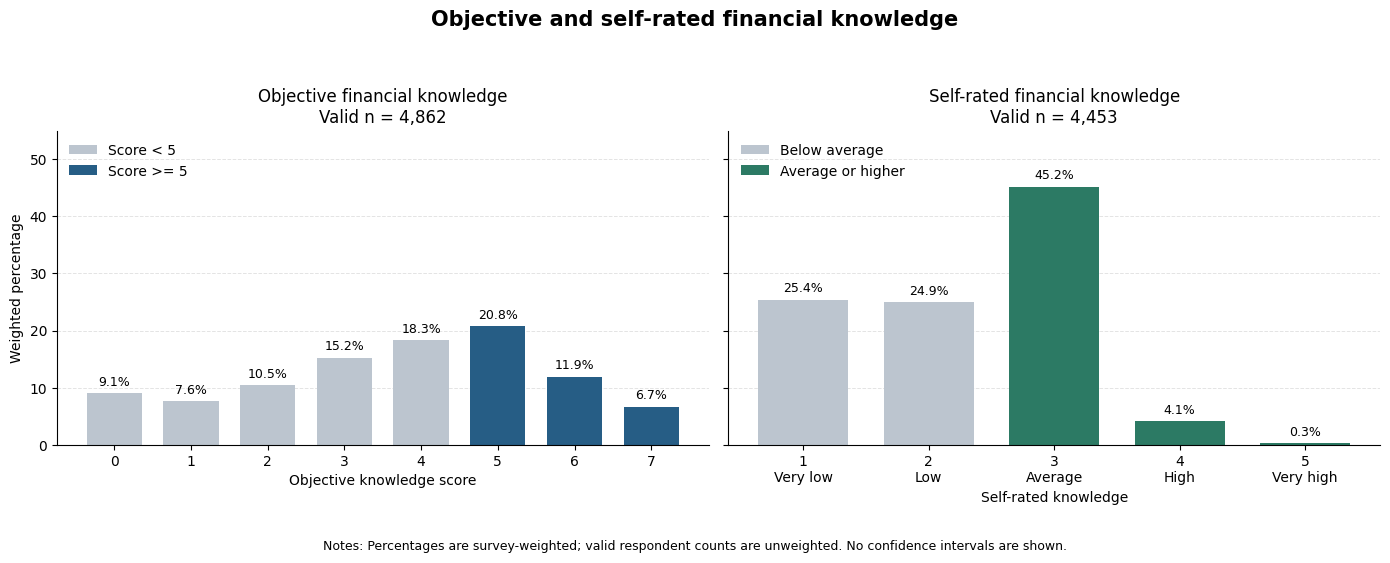

Module 3.2 figure saved successfully.


In [ ]:
# ============================================================
# Part 4: coordinated two-panel knowledge figure
# ============================================================

objective_plot = (
    objective_distribution
    .sort_values("category_order")
    .reset_index(drop=True)
)

self_rating_plot = (
    self_rated_distribution
    .sort_values("category_order")
    .reset_index(drop=True)
)


maximum_percentage = max(
    objective_plot["weighted_percent"].max(),
    self_rating_plot["weighted_percent"].max(),
)

y_axis_upper_limit = min(
    100,
    max(
        10,
        np.ceil(
            maximum_percentage
            * 1.18
            / 5
        )
        * 5,
    ),
)


with plt.rc_context(
    {
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
    }
):
    figure, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(14, 5.6),
        sharey=True,
    )

    objective_positions = np.arange(
        len(objective_plot)
    )

    objective_colours = [
        "#BCC5CF" if score < 5 else "#265D85"
        for score in objective_plot["category_code"]
    ]

    objective_bars = axes[0].bar(
        objective_positions,
        objective_plot["weighted_percent"],
        color=objective_colours,
        width=0.72,
    )

    axes[0].set_xticks(objective_positions)
    axes[0].set_xticklabels(
        objective_plot["category_code"]
        .astype(int)
        .astype(str)
    )

    axes[0].set_xlabel(
        "Objective knowledge score"
    )

    axes[0].set_ylabel(
        "Weighted percentage"
    )

    axes[0].set_title(
        "Objective financial knowledge\n"
        f"Valid n = "
        f"{objective_plot['valid_unweighted_n'].iloc[0]:,}"
    )

    axes[0].legend(
        handles=[
            Patch(
                facecolor="#BCC5CF",
                label="Score < 5",
            ),
            Patch(
                facecolor="#265D85",
                label="Score >= 5",
            ),
        ],
        frameon=False,
        loc="upper left",
    )


    self_rating_positions = np.arange(
        len(self_rating_plot)
    )

    self_rating_colours = [
        "#BCC5CF" if rating < 3 else "#2C7A64"
        for rating in self_rating_plot["category_code"]
    ]

    self_rating_bars = axes[1].bar(
        self_rating_positions,
        self_rating_plot["weighted_percent"],
        color=self_rating_colours,
        width=0.72,
    )

    axes[1].set_xticks(self_rating_positions)

    axes[1].set_xticklabels(
        [
            "1\nVery low",
            "2\nLow",
            "3\nAverage",
            "4\nHigh",
            "5\nVery high",
        ]
    )

    axes[1].set_xlabel(
        "Self-rated knowledge"
    )

    axes[1].set_title(
        "Self-rated financial knowledge\n"
        f"Valid n = "
        f"{self_rating_plot['valid_unweighted_n'].iloc[0]:,}"
    )

    axes[1].legend(
        handles=[
            Patch(
                facecolor="#BCC5CF",
                label="Below average",
            ),
            Patch(
                facecolor="#2C7A64",
                label="Average or higher",
            ),
        ],
        frameon=False,
        loc="upper left",
    )


    for axis, bars, percentages in [
        (
            axes[0],
            objective_bars,
            objective_plot["weighted_percent"],
        ),
        (
            axes[1],
            self_rating_bars,
            self_rating_plot["weighted_percent"],
        ),
    ]:
        axis.set_ylim(
            0,
            y_axis_upper_limit,
        )

        axis.set_axisbelow(True)

        axis.yaxis.grid(
            True,
            linestyle="--",
            linewidth=0.7,
            alpha=0.35,
        )

        for spine in ["top", "right"]:
            axis.spines[spine].set_visible(False)

        for bar, percentage in zip(
            bars,
            percentages,
        ):
            axis.text(
                bar.get_x()
                + bar.get_width() / 2,
                bar.get_height()
                + y_axis_upper_limit * 0.015,
                f"{percentage:.1f}%",
                ha="center",
                va="bottom",
                fontsize=9,
            )


    figure.suptitle(
        "Objective and self-rated financial knowledge",
        fontsize=15,
        fontweight="semibold",
    )

    figure.text(
        0.5,
        0.015,
        (
            "Notes: Percentages are survey-weighted; "
            "valid respondent counts are unweighted. "
            "No confidence intervals are shown."
        ),
        ha="center",
        fontsize=9,
    )

    figure.tight_layout(
        rect=(0, 0.07, 1, 0.93)
    )


figure_png_path = (
    figures_directory
    / "module_3_2_knowledge_distributions.png"
)

figure_pdf_path = (
    figures_directory
    / "module_3_2_knowledge_distributions.pdf"
)

figure.savefig(
    figure_png_path,
    dpi=300,
    bbox_inches="tight",
)

figure.savefig(
    figure_pdf_path,
    bbox_inches="tight",
)

plt.show()

assert figure_png_path.exists()
assert figure_pdf_path.exists()
assert figure_png_path.stat().st_size > 0
assert figure_pdf_path.stat().st_size > 0

print("Module 3.2 figure saved successfully.")

In [ ]:
# ============================================================
# Part 5: save and validate Module 3.2 outputs
# ============================================================

def assert_same_csv_values(
    reference,
    reloaded,
):
    """
    Compare table values while allowing dtype differences
    introduced by CSV storage.
    """

    assert reference.shape == reloaded.shape
    assert list(reference.columns) == list(
        reloaded.columns
    )

    for column in reference.columns:
        reference_series = reference[column]
        reloaded_series = reloaded[column]

        if pd.api.types.is_numeric_dtype(
            reference_series
        ):
            reference_values = (
                pd.to_numeric(
                    reference_series,
                    errors="coerce",
                )
                .astype("float64")
                .to_numpy()
            )

            reloaded_values = (
                pd.to_numeric(
                    reloaded_series,
                    errors="coerce",
                )
                .astype("float64")
                .to_numpy()
            )

            np.testing.assert_allclose(
                reference_values,
                reloaded_values,
                rtol=1e-12,
                atol=1e-12,
                equal_nan=True,
            )

        else:
            reference_values = (
                reference_series
                .astype("string")
                .fillna("<MISSING>")
                .tolist()
            )

            reloaded_values = (
                reloaded_series
                .astype("string")
                .fillna("<MISSING>")
                .tolist()
            )

            assert (
                reference_values
                == reloaded_values
            )


module_3_2_tables = {
    "module_3_2_objective_distribution.csv": (
        objective_distribution
    ),
    "module_3_2_objective_summary.csv": (
        objective_summary
    ),
    "module_3_2_self_rated_distribution.csv": (
        self_rated_distribution
    ),
    "module_3_2_self_rated_summary.csv": (
        self_rated_summary
    ),
}


manifest_rows = []

for filename, table in module_3_2_tables.items():
    output_path = (
        tables_directory
        / filename
    )

    table.to_csv(
        output_path,
        index=False,
        encoding="utf-8",
    )

    reloaded_table = pd.read_csv(
        output_path
    )

    assert_same_csv_values(
        table,
        reloaded_table,
    )

    manifest_rows.append(
        {
            "output_type": "Table",
            "filename": filename,
            "rows": table.shape[0],
            "columns": table.shape[1],
            "size_bytes": output_path.stat().st_size,
            "validation": "Passed",
        }
    )


for figure_path in [
    figure_png_path,
    figure_pdf_path,
]:
    assert figure_path.exists()
    assert figure_path.stat().st_size > 0

    manifest_rows.append(
        {
            "output_type": "Figure",
            "filename": figure_path.name,
            "rows": None,
            "columns": None,
            "size_bytes": figure_path.stat().st_size,
            "validation": "Passed",
        }
    )


module_3_2_manifest = pd.DataFrame(
    manifest_rows
)

assert len(module_3_2_manifest) == 6
assert (
    module_3_2_manifest["validation"]
    .eq("Passed")
    .all()
)

manifest_path = (
    tables_directory
    / "module_3_2_output_manifest.csv"
)

module_3_2_manifest.to_csv(
    manifest_path,
    index=False,
    encoding="utf-8",
)

display(module_3_2_manifest)

print(
    "Module 3.2 completed: all tables and figures "
    "were saved and validated."
)

,output_type,filename,rows,columns,size_bytes,validation
0,Table,module_3_2_objective_distribution.csv,8.0,8.0,858,Passed
1,Table,module_3_2_objective_summary.csv,1.0,12.0,295,Passed
2,Table,module_3_2_self_rated_distribution.csv,5.0,8.0,580,Passed
3,Table,module_3_2_self_rated_summary.csv,1.0,11.0,289,Passed
4,Figure,module_3_2_knowledge_distributions.png,NaN,NaN,278610,Passed
5,Figure,module_3_2_knowledge_distributions.pdf,NaN,NaN,27342,Passed


Module 3.2 completed: all tables and figures were saved and validated.


## 3.3 Knowledge–Confidence Profiles and Alternative Mismatch Definitions

**Purpose.** Describe the joint distribution of objective and self-rated
financial knowledge while keeping absolute adequacy, relative calibration, and
explicitly high confidence conceptually distinct.

Objective knowledge is classified relative to the OECD/INFE minimum target of
five correct answers out of seven. Self-rated knowledge is divided into below
average, average, and high or very high ratings. The neutral "Average" response
is retained separately because QK1 asks respondents to compare their knowledge
with that of other people.

Three non-equivalent mismatch definitions are compared:

1. an unrecognised adequacy gap: score < 5 and self-rating >= 3;
2. Banca-aligned relative overconfidence: score at or below the weighted
   national mean and self-rating >= 3;
3. a strict high-confidence mismatch: score < 5 and self-rating >= 4.

The second definition follows the relative-calibration approach used by
di Salvatore et al. (2018), while the first uses the OECD/INFE absolute
adequacy target. The broad adequacy gap is not interpreted as overconfidence.

Percentages are survey-weighted and respondent counts are unweighted. The
analysis is descriptive and does not include confidence intervals, hypothesis
tests, p-values, or causal claims. Profile categories support communication;
subsequent adjusted models retain the full objective score, ordinal
self-rating, and their interaction.

**Cross-cutting interpretation principle.** Analytical thresholds are selected
because they correspond to a stated construct and reference frame, not because
they produce a larger or smaller prevalence estimate. The OECD/INFE threshold
answers an absolute adequacy question, whereas the Banca d’Italia precedent
answers a relative-calibration question. Descriptive mismatch prevalence alone
does not demonstrate a behavioural "confidence trap". Evidence for a trap
requires the subsequent outcome analyses to show that knowledge–confidence
mismatch is associated with less prudent behaviour or adverse financial
experiences.


(di Salvatore, A., Franceschi, F., Neri, A., & Zanichelli, F. (2018).
Measuring the financial literacy of the adult population: the experience of
Banca d’Italia. Questioni di Economia e Finanza (Occasional Papers), No. 435,
Banca d’Italia.
https://www.bancaditalia.it/pubblicazioni/qef/2018-0435/QEF_435_18.pdf)

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


# ============================================================
# Module 3.3 — Revised knowledge-confidence profiles
# Part 1: load and validate the canonical checkpoint
# ============================================================

checkpoint_path = (
    Path(PROJECT_ROOT)
    / "data"
    / "processed"
    / "iacofi_analytical_checkpoint.parquet"
)

tables_directory = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "tables"
)

figures_directory = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "figures"
)

tables_directory.mkdir(
    parents=True,
    exist_ok=True,
)

figures_directory.mkdir(
    parents=True,
    exist_ok=True,
)


required_variables = [
    "respondent_id",
    "survey_weight",
    "objective_knowledge_score",
    "knowledge_target_met",
    "self_rated_knowledge",
    "self_rating_at_least_average",
]


assert checkpoint_path.exists(), (
    f"Checkpoint not found: {checkpoint_path}"
)

knowledge_df = pd.read_parquet(
    checkpoint_path,
    engine="pyarrow",
)

assert knowledge_df.shape == (4862, 22)

missing_variables = sorted(
    set(required_variables)
    - set(knowledge_df.columns)
)

assert not missing_variables, (
    "Missing Module 3.3 variables: "
    f"{missing_variables}"
)

assert knowledge_df["respondent_id"].notna().all()
assert knowledge_df["respondent_id"].is_unique

np.testing.assert_array_equal(
    knowledge_df["respondent_id"].to_numpy(),
    np.arange(1, 4863),
)


weights = pd.to_numeric(
    knowledge_df["survey_weight"],
    errors="coerce",
).astype(float)

objective_score = pd.to_numeric(
    knowledge_df["objective_knowledge_score"],
    errors="coerce",
)

objective_target = pd.to_numeric(
    knowledge_df["knowledge_target_met"],
    errors="coerce",
)

self_rating = pd.to_numeric(
    knowledge_df["self_rated_knowledge"],
    errors="coerce",
)

self_rating_target = pd.to_numeric(
    knowledge_df["self_rating_at_least_average"],
    errors="coerce",
)


assert weights.notna().all()
assert weights.gt(0).all()

assert objective_score.notna().all()
assert objective_score.isin(range(0, 8)).all()

assert self_rating.dropna().isin(range(1, 6)).all()

assert np.array_equal(
    objective_target.notna().to_numpy(),
    objective_score.notna().to_numpy(),
)

assert np.array_equal(
    self_rating_target.notna().to_numpy(),
    self_rating.notna().to_numpy(),
)

np.testing.assert_array_equal(
    objective_target.astype(int).to_numpy(),
    objective_score.ge(5).astype(int).to_numpy(),
)

self_rating_valid_mask = self_rating.notna()

np.testing.assert_array_equal(
    self_rating_target.loc[
        self_rating_valid_mask
    ].astype(int).to_numpy(),
    self_rating.loc[
        self_rating_valid_mask
    ].ge(3).astype(int).to_numpy(),
)


joint_valid_mask = (
    objective_score.notna()
    & self_rating.notna()
    & weights.notna()
    & weights.gt(0)
)

assert int(joint_valid_mask.sum()) == 4453
assert int((~self_rating.notna()).sum()) == 409


objective_population_mask = (
    objective_score.notna()
    & weights.notna()
    & weights.gt(0)
)

objective_weighted_national_mean = float(
    np.average(
        objective_score.loc[
            objective_population_mask
        ].astype(float),
        weights=weights.loc[
            objective_population_mask
        ],
    )
)

# The score is integer-valued. Therefore, scores less than or
# equal to the weighted national mean of 3.694... are 0–3.
banca_relative_score_cutoff = int(
    np.floor(
        objective_weighted_national_mean
    )
)

assert np.isclose(
    objective_weighted_national_mean,
    3.6941245412445065,
    atol=1e-9,
)

assert banca_relative_score_cutoff == 3


# The legacy checkpoint variable is retained for provenance.
# It corresponds to the policy-facing adequacy gap, not to the
# Banca-aligned relative-overconfidence definition.
if "confidence_trap_candidate" in knowledge_df.columns:
    legacy_candidate = pd.to_numeric(
        knowledge_df[
            "confidence_trap_candidate"
        ],
        errors="coerce",
    )

    assert np.array_equal(
        legacy_candidate.notna().to_numpy(),
        self_rating.notna().to_numpy(),
    )

    np.testing.assert_array_equal(
        legacy_candidate.loc[
            joint_valid_mask
        ].astype(int).to_numpy(),
        (
            objective_score.loc[
                joint_valid_mask
            ].lt(5)
            & self_rating.loc[
                joint_valid_mask
            ].ge(3)
        ).astype(int).to_numpy(),
    )


print(
    "Module 3.3 source validated successfully: "
    f"{int(joint_valid_mask.sum()):,} joint-valid respondents."
)

print(
    "Weighted national objective-knowledge mean: "
    f"{objective_weighted_national_mean:.4f}; "
    "Banca-aligned integer cutoff: score <= "
    f"{banca_relative_score_cutoff}."
)

Module 3.3 source validated successfully: 4,453 joint-valid respondents.
Weighted national objective-knowledge mean: 3.6941; Banca-aligned integer cutoff: score <= 3.


In [ ]:
# ============================================================
# Part 2: six-cell knowledge-confidence profile
# ============================================================

profile_source = pd.DataFrame(
    {
        "respondent_id": knowledge_df.loc[
            joint_valid_mask,
            "respondent_id",
        ].to_numpy(),
        "survey_weight": weights.loc[
            joint_valid_mask
        ].astype(float).to_numpy(),
        "objective_knowledge_score": (
            objective_score.loc[
                joint_valid_mask
            ].astype(int).to_numpy()
        ),
        "self_rated_knowledge": (
            self_rating.loc[
                joint_valid_mask
            ].astype(int).to_numpy()
        ),
    }
)


profile_source["objective_group_code"] = np.where(
    profile_source[
        "objective_knowledge_score"
    ].lt(5),
    "below_target",
    "meets_target",
)

profile_source["self_rating_tier_code"] = np.select(
    [
        profile_source[
            "self_rated_knowledge"
        ].le(2),
        profile_source[
            "self_rated_knowledge"
        ].eq(3),
        profile_source[
            "self_rated_knowledge"
        ].ge(4),
    ],
    [
        "below_average",
        "average",
        "high",
    ],
    default="invalid",
)

assert not profile_source[
    "self_rating_tier_code"
].eq("invalid").any()


objective_group_specification = [
    (
        "below_target",
        "Below adequacy target (score < 5)",
    ),
    (
        "meets_target",
        "Meets adequacy target (score >= 5)",
    ),
]

self_rating_tier_specification = [
    (
        "below_average",
        "Below average (ratings 1–2)",
    ),
    (
        "average",
        "Average (rating 3)",
    ),
    (
        "high",
        "High or very high (ratings 4–5)",
    ),
]


weighted_denominator = float(
    profile_source["survey_weight"].sum()
)

profile_rows = []

for objective_order, (
    objective_code,
    objective_label,
) in enumerate(
    objective_group_specification,
    start=1,
):
    for self_rating_order, (
        self_rating_code,
        self_rating_label,
    ) in enumerate(
        self_rating_tier_specification,
        start=1,
    ):
        cell_mask = (
            profile_source[
                "objective_group_code"
            ].eq(objective_code)
            & profile_source[
                "self_rating_tier_code"
            ].eq(self_rating_code)
        )

        cell_unweighted_n = int(
            cell_mask.sum()
        )

        cell_weight = float(
            profile_source.loc[
                cell_mask,
                "survey_weight",
            ].sum()
        )

        profile_rows.append(
            {
                "objective_group_order": (
                    objective_order
                ),
                "objective_group_code": (
                    objective_code
                ),
                "objective_group_label": (
                    objective_label
                ),
                "self_rating_tier_order": (
                    self_rating_order
                ),
                "self_rating_tier_code": (
                    self_rating_code
                ),
                "self_rating_tier_label": (
                    self_rating_label
                ),
                "unweighted_n": cell_unweighted_n,
                "valid_unweighted_n": int(
                    len(profile_source)
                ),
                "weighted_percent": (
                    100
                    * cell_weight
                    / weighted_denominator
                ),
            }
        )


confidence_profiles = pd.DataFrame(
    profile_rows
)

assert int(
    confidence_profiles[
        "unweighted_n"
    ].sum()
) == 4453

assert np.isclose(
    confidence_profiles[
        "weighted_percent"
    ].sum(),
    100,
    atol=1e-10,
)


def profile_cell(
    objective_code,
    self_rating_code,
    column,
):
    selected = confidence_profiles.loc[
        confidence_profiles[
            "objective_group_code"
        ].eq(objective_code)
        & confidence_profiles[
            "self_rating_tier_code"
        ].eq(self_rating_code),
        column,
    ]

    assert len(selected) == 1

    return selected.iloc[0]


# Previously validated counts, now with the neutral category
# separated from explicitly high self-ratings.
assert int(
    profile_cell(
        "below_target",
        "below_average",
        "unweighted_n",
    )
) == 1246

assert int(
    profile_cell(
        "below_target",
        "average",
        "unweighted_n",
    )
) == 1078

assert int(
    profile_cell(
        "below_target",
        "high",
        "unweighted_n",
    )
) == 106

assert int(
    profile_cell(
        "meets_target",
        "below_average",
        "unweighted_n",
    )
) == 736

assert (
    int(
        profile_cell(
            "meets_target",
            "average",
            "unweighted_n",
        )
    )
    + int(
        profile_cell(
            "meets_target",
            "high",
            "unweighted_n",
        )
    )
) == 1287


assert round(
    float(
        profile_cell(
            "below_target",
            "below_average",
            "weighted_percent",
        )
    ),
    1,
) == 33.4

assert round(
    float(
        profile_cell(
            "below_target",
            "average",
            "weighted_percent",
        )
        + profile_cell(
            "below_target",
            "high",
            "weighted_percent",
        )
    ),
    1,
) == 24.9

assert round(
    float(
        profile_cell(
            "meets_target",
            "below_average",
            "weighted_percent",
        )
    ),
    1,
) == 16.9

assert round(
    float(
        profile_cell(
            "meets_target",
            "average",
            "weighted_percent",
        )
        + profile_cell(
            "meets_target",
            "high",
            "weighted_percent",
        )
    ),
    1,
) == 24.7


confidence_profiles_display = (
    confidence_profiles.copy()
)

confidence_profiles_display[
    "weighted_percent"
] = confidence_profiles_display[
    "weighted_percent"
].round(1)

display(
    confidence_profiles_display[
        [
            "objective_group_label",
            "self_rating_tier_label",
            "unweighted_n",
            "valid_unweighted_n",
            "weighted_percent",
        ]
    ]
)

print("Six-cell profile checks passed.")

,objective_group_label,self_rating_tier_label,unweighted_n,valid_unweighted_n,weighted_percent
0,Below adequacy target (score < 5),Below average (ratings 1–2),1246,4453,33.4
1,Below adequacy target (score < 5),Average (rating 3),1078,4453,22.8
2,Below adequacy target (score < 5),High or very high (ratings 4–5),106,4453,2.1
3,Meets adequacy target (score >= 5),Below average (ratings 1–2),736,4453,16.9
4,Meets adequacy target (score >= 5),Average (rating 3),1167,4453,22.4
5,Meets adequacy target (score >= 5),High or very high (ratings 4–5),120,4453,2.3


Six-cell profile checks passed.


In [ ]:
# ============================================================
# Part 3: compare mismatch definitions without conflating them
# ============================================================

below_target_mask = profile_source[
    "objective_knowledge_score"
].lt(5)

average_or_higher_mask = profile_source[
    "self_rated_knowledge"
].ge(3)

explicitly_high_mask = profile_source[
    "self_rated_knowledge"
].ge(4)


unrecognised_adequacy_gap_mask = (
    below_target_mask
    & average_or_higher_mask
)

banca_relative_overconfidence_mask = (
    profile_source[
        "objective_knowledge_score"
    ].le(banca_relative_score_cutoff)
    & average_or_higher_mask
)

strict_high_confidence_mismatch_mask = (
    below_target_mask
    & explicitly_high_mask
)

score_4_boundary_mask = (
    profile_source[
        "objective_knowledge_score"
    ].eq(4)
    & average_or_higher_mask
)


assert not (
    banca_relative_overconfidence_mask
    & score_4_boundary_mask
).any()

np.testing.assert_array_equal(
    (
        banca_relative_overconfidence_mask
        | score_4_boundary_mask
    ).to_numpy(),
    unrecognised_adequacy_gap_mask.to_numpy(),
)

assert (
    strict_high_confidence_mismatch_mask
    <= unrecognised_adequacy_gap_mask
).all()


def mismatch_summary_row(
    measure,
    measure_label,
    analysis_role,
    definition,
    reference_frame,
    interpretation_limit,
    indicator_mask,
):
    indicator_values = (
        indicator_mask
        .astype(float)
        .to_numpy()
    )

    return {
        "measure": measure,
        "measure_label": measure_label,
        "analysis_role": analysis_role,
        "definition": definition,
        "reference_frame": reference_frame,
        "interpretation_limit": (
            interpretation_limit
        ),
        "unweighted_n": int(
            indicator_mask.sum()
        ),
        "valid_unweighted_n": int(
            len(profile_source)
        ),
        "weighted_percent": float(
            100
            * np.average(
                indicator_values,
                weights=profile_source[
                    "survey_weight"
                ].to_numpy(),
            )
        ),
    }


mismatch_definitions = pd.DataFrame(
    [
        mismatch_summary_row(
            measure=(
                "unrecognised_adequacy_gap"
            ),
            measure_label=(
                "Unrecognised adequacy gap"
            ),
            analysis_role=(
                "Secondary policy-facing summary"
            ),
            definition=(
                "Objective score < 5 and "
                "self-rating >= 3"
            ),
            reference_frame=(
                "OECD adequacy target combined with "
                "relative self-assessment"
            ),
            interpretation_limit=(
                "Not interpreted as overconfidence"
            ),
            indicator_mask=(
                unrecognised_adequacy_gap_mask
            ),
        ),
        mismatch_summary_row(
            measure=(
                "banca_aligned_relative_overconfidence"
            ),
            measure_label=(
                "Banca-aligned relative overconfidence"
            ),
            analysis_role=(
                "Published-precedent definition"
            ),
            definition=(
                "Objective score <= weighted national "
                f"mean ({objective_weighted_national_mean:.6f}; "
                "integer scores 0–3) and self-rating >= 3"
            ),
            reference_frame=(
                "Relative standing on both dimensions"
            ),
            interpretation_limit=(
                "Aligned with the 2018 Banca d'Italia "
                "paper; not a mandatory 2023 dataset rule"
            ),
            indicator_mask=(
                banca_relative_overconfidence_mask
            ),
        ),
        mismatch_summary_row(
            measure=(
                "strict_high_confidence_mismatch"
            ),
            measure_label=(
                "Strict high-confidence mismatch"
            ),
            analysis_role="Sensitivity check",
            definition=(
                "Objective score < 5 and "
                "self-rating >= 4"
            ),
            reference_frame=(
                "OECD adequacy target combined with "
                "explicitly high self-assessment"
            ),
            interpretation_limit=(
                "Narrow mismatch measure; not a causal claim"
            ),
            indicator_mask=(
                strict_high_confidence_mismatch_mask
            ),
        ),
        mismatch_summary_row(
            measure="score_4_boundary_component",
            measure_label=(
                "Score-4 boundary component"
            ),
            analysis_role=(
                "Threshold bridge; not a headline measure"
            ),
            definition=(
                "Objective score = 4 and "
                "self-rating >= 3"
            ),
            reference_frame=(
                "Above the national mean but below "
                "the OECD adequacy target"
            ),
            interpretation_limit=(
                "Explains the difference between the broad "
                "and Banca-aligned definitions"
            ),
            indicator_mask=score_4_boundary_mask,
        ),
    ]
)


def mismatch_value(
    measure,
    column,
):
    selected = mismatch_definitions.loc[
        mismatch_definitions[
            "measure"
        ].eq(measure),
        column,
    ]

    assert len(selected) == 1

    return selected.iloc[0]


assert int(
    mismatch_value(
        "unrecognised_adequacy_gap",
        "unweighted_n",
    )
) == 1184

assert round(
    float(
        mismatch_value(
            "unrecognised_adequacy_gap",
            "weighted_percent",
        )
    ),
    1,
) == 24.9

assert int(
    mismatch_value(
        "strict_high_confidence_mismatch",
        "unweighted_n",
    )
) == 106

assert round(
    float(
        mismatch_value(
            "strict_high_confidence_mismatch",
            "weighted_percent",
        )
    ),
    1,
) == 2.1


assert (
    int(
        mismatch_value(
            "banca_aligned_relative_overconfidence",
            "unweighted_n",
        )
    )
    + int(
        mismatch_value(
            "score_4_boundary_component",
            "unweighted_n",
        )
    )
) == int(
    mismatch_value(
        "unrecognised_adequacy_gap",
        "unweighted_n",
    )
)

assert np.isclose(
    float(
        mismatch_value(
            "banca_aligned_relative_overconfidence",
            "weighted_percent",
        )
    )
    + float(
        mismatch_value(
            "score_4_boundary_component",
            "weighted_percent",
        )
    ),
    float(
        mismatch_value(
            "unrecognised_adequacy_gap",
            "weighted_percent",
        )
    ),
    atol=1e-10,
)


mismatch_definitions_display = (
    mismatch_definitions.copy()
)

mismatch_definitions_display[
    "weighted_percent"
] = mismatch_definitions_display[
    "weighted_percent"
].round(1)

display(
    mismatch_definitions_display[
        [
            "measure_label",
            "analysis_role",
            "definition",
            "unweighted_n",
            "valid_unweighted_n",
            "weighted_percent",
        ]
    ]
)

print("Alternative-definition checks passed.")


,measure_label,analysis_role,definition,unweighted_n,valid_unweighted_n,weighted_percent
0,Unrecognised adequacy gap,Secondary policy-facing summary,Objective score < 5 and self-rating >= 3,1184,4453,24.9
1,Banca-aligned relative overconfidence,Published-precedent definition,Objective score <= weighted national mean (3.6...,712,4453,15.1
2,Strict high-confidence mismatch,Sensitivity check,Objective score < 5 and self-rating >= 4,106,4453,2.1
3,Score-4 boundary component,Threshold bridge; not a headline measure,Objective score = 4 and self-rating >= 3,472,4453,9.8


Alternative-definition checks passed.


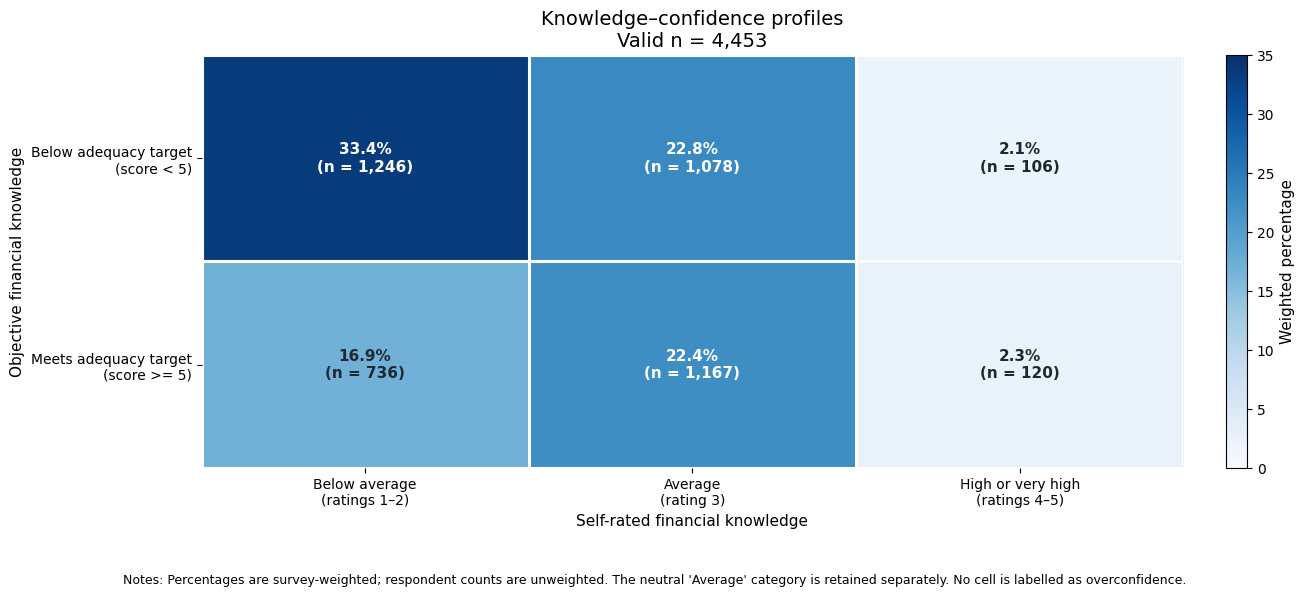

Revised Module 3.3 figure saved successfully.


In [ ]:
# ============================================================
# Part 4: neutral annotated 2 x 3 profile matrix
# ============================================================

objective_code_order = [
    code
    for code, _ in objective_group_specification
]

self_rating_code_order = [
    code
    for code, _ in self_rating_tier_specification
]

objective_axis_labels = [
    label
    for _, label in objective_group_specification
]

self_rating_axis_labels = [
    label
    for _, label in self_rating_tier_specification
]


percentage_matrix = (
    confidence_profiles.pivot(
        index="objective_group_code",
        columns="self_rating_tier_code",
        values="weighted_percent",
    )
    .reindex(
        index=objective_code_order,
        columns=self_rating_code_order,
    )
    .to_numpy(dtype=float)
)

count_matrix = (
    confidence_profiles.pivot(
        index="objective_group_code",
        columns="self_rating_tier_code",
        values="unweighted_n",
    )
    .reindex(
        index=objective_code_order,
        columns=self_rating_code_order,
    )
    .to_numpy(dtype=int)
)

assert percentage_matrix.shape == (2, 3)
assert count_matrix.shape == (2, 3)
assert np.isfinite(percentage_matrix).all()


colour_scale_maximum = max(
    5,
    float(
        np.ceil(
            percentage_matrix.max()
            / 5
        )
        * 5
    ),
)


with plt.rc_context(
    {
        "font.size": 10,
        "axes.titlesize": 14,
        "axes.labelsize": 11,
    }
):
    figure, axis = plt.subplots(
        figsize=(13.2, 6.1)
    )

    image = axis.imshow(
        percentage_matrix,
        cmap="Blues",
        vmin=0,
        vmax=colour_scale_maximum,
        aspect="auto",
    )

    axis.set_xticks(
        np.arange(
            len(self_rating_axis_labels)
        )
    )

    axis.set_xticklabels(
        [
            "Below average\n(ratings 1–2)",
            "Average\n(rating 3)",
            "High or very high\n(ratings 4–5)",
        ]
    )

    axis.set_yticks(
        np.arange(
            len(objective_axis_labels)
        )
    )

    axis.set_yticklabels(
        [
            "Below adequacy target\n(score < 5)",
            "Meets adequacy target\n(score >= 5)",
        ]
    )

    axis.set_xlabel(
        "Self-rated financial knowledge"
    )

    axis.set_ylabel(
        "Objective financial knowledge"
    )

    axis.set_title(
        "Knowledge–confidence profiles\n"
        f"Valid n = {len(profile_source):,}"
    )

    axis.set_xticks(
        np.arange(-0.5, 3, 1),
        minor=True,
    )

    axis.set_yticks(
        np.arange(-0.5, 2, 1),
        minor=True,
    )

    axis.grid(
        which="minor",
        color="white",
        linewidth=2.2,
    )

    axis.tick_params(
        which="minor",
        bottom=False,
        left=False,
    )

    for row_index in range(
        percentage_matrix.shape[0]
    ):
        for column_index in range(
            percentage_matrix.shape[1]
        ):
            percentage = percentage_matrix[
                row_index,
                column_index,
            ]

            unweighted_n = count_matrix[
                row_index,
                column_index,
            ]

            text_colour = (
                "white"
                if percentage
                >= colour_scale_maximum * 0.55
                else "#1F2933"
            )

            axis.text(
                column_index,
                row_index,
                (
                    f"{percentage:.1f}%\n"
                    f"(n = {unweighted_n:,})"
                ),
                ha="center",
                va="center",
                color=text_colour,
                fontsize=11,
                fontweight="semibold",
            )

    colour_bar = figure.colorbar(
        image,
        ax=axis,
        fraction=0.046,
        pad=0.04,
    )

    colour_bar.set_label(
        "Weighted percentage"
    )

    for spine in axis.spines.values():
        spine.set_visible(False)

    figure.text(
        0.5,
        0.015,
        (
            "Notes: Percentages are survey-weighted; "
            "respondent counts are unweighted. "
            "The neutral 'Average' category is retained "
            "separately. No cell is labelled as "
            "overconfidence."
        ),
        ha="center",
        fontsize=9,
    )

    figure.tight_layout(
        rect=(0, 0.08, 1, 0.98)
    )


figure_png_path = (
    figures_directory
    / "module_3_3_confidence_profile_matrix.png"
)

figure_pdf_path = (
    figures_directory
    / "module_3_3_confidence_profile_matrix.pdf"
)

figure.savefig(
    figure_png_path,
    dpi=300,
    bbox_inches="tight",
)

figure.savefig(
    figure_pdf_path,
    bbox_inches="tight",
)

plt.show()

assert figure_png_path.exists()
assert figure_pdf_path.exists()
assert figure_png_path.stat().st_size > 0
assert figure_pdf_path.stat().st_size > 0

print("Revised Module 3.3 figure saved successfully.")


In [ ]:
# ============================================================
# Part 5: save and validate revised Module 3.3 outputs
# ============================================================

def assert_same_csv_values(
    reference,
    reloaded,
):
    """Compare values while allowing CSV dtype changes."""

    assert reference.shape == reloaded.shape
    assert list(reference.columns) == list(
        reloaded.columns
    )

    for column in reference.columns:
        reference_series = reference[column]
        reloaded_series = reloaded[column]

        if pd.api.types.is_numeric_dtype(
            reference_series
        ):
            reference_values = (
                pd.to_numeric(
                    reference_series,
                    errors="coerce",
                )
                .astype("float64")
                .to_numpy()
            )

            reloaded_values = (
                pd.to_numeric(
                    reloaded_series,
                    errors="coerce",
                )
                .astype("float64")
                .to_numpy()
            )

            np.testing.assert_allclose(
                reference_values,
                reloaded_values,
                rtol=1e-12,
                atol=1e-12,
                equal_nan=True,
            )

        else:
            reference_values = (
                reference_series
                .astype("string")
                .fillna("<MISSING>")
                .tolist()
            )

            reloaded_values = (
                reloaded_series
                .astype("string")
                .fillna("<MISSING>")
                .tolist()
            )

            assert (
                reference_values
                == reloaded_values
            )


module_3_3_tables = {
    "module_3_3_confidence_profiles.csv": (
        confidence_profiles
    ),
    "module_3_3_mismatch_sensitivity.csv": (
        mismatch_definitions
    ),
}


manifest_rows = []

for filename, table in module_3_3_tables.items():
    output_path = (
        tables_directory
        / filename
    )

    table.to_csv(
        output_path,
        index=False,
        encoding="utf-8",
    )

    reloaded_table = pd.read_csv(
        output_path
    )

    assert_same_csv_values(
        table,
        reloaded_table,
    )

    manifest_rows.append(
        {
            "output_type": "Table",
            "filename": filename,
            "rows": table.shape[0],
            "columns": table.shape[1],
            "size_bytes": (
                output_path.stat().st_size
            ),
            "validation": "Passed",
        }
    )


for figure_path in [
    figure_png_path,
    figure_pdf_path,
]:
    assert figure_path.exists()
    assert figure_path.stat().st_size > 0

    manifest_rows.append(
        {
            "output_type": "Figure",
            "filename": figure_path.name,
            "rows": np.nan,
            "columns": np.nan,
            "size_bytes": (
                figure_path.stat().st_size
            ),
            "validation": "Passed",
        }
    )


module_3_3_manifest = pd.DataFrame(
    manifest_rows
)

assert len(module_3_3_manifest) == 4
assert (
    module_3_3_manifest[
        "validation"
    ].eq("Passed").all()
)

manifest_path = (
    tables_directory
    / "module_3_3_output_manifest.csv"
)

module_3_3_manifest.to_csv(
    manifest_path,
    index=False,
    encoding="utf-8",
)

display(module_3_3_manifest)

print(
    "Revised Module 3.3 completed: all outputs "
    "were saved and validated."
)


,output_type,filename,rows,columns,size_bytes,validation
0,Table,module_3_3_confidence_profiles.csv,6.0,9.0,876,Passed
1,Table,module_3_3_mismatch_sensitivity.csv,4.0,9.0,1281,Passed
2,Figure,module_3_3_confidence_profile_matrix.png,NaN,NaN,276932,Passed
3,Figure,module_3_3_confidence_profile_matrix.pdf,NaN,NaN,30259,Passed


Revised Module 3.3 completed: all outputs were saved and validated.


**Result summary.** The revised Module 3.3 was successfully
validated on 4,453 joint-valid respondents. The Banca-aligned relative-
overconfidence definition identified 712 respondents, corresponding to 15.1%
of the weighted population. The broader unrecognised adequacy gap was 24.9%
(n = 1,184), of which 9.8 percentage points (n = 472) consisted of respondents
with objective score 4: above the weighted national mean but below the
OECD/INFE adequacy target. The strict high-confidence mismatch was 2.1%
(n = 106). These results confirm that the three definitions capture distinct
constructs and must not be reported interchangeably.

## 3.4 Demographic Profiles of Knowledge–Confidence Mismatch

**Purpose.** Describe how two distinct forms of knowledge–confidence mismatch
vary across age, gender, education, and macro-region.

The unrecognised adequacy gap identifies respondents whose objective score is
below the OECD/INFE minimum target of five but who do not rate their knowledge
as below average. Banca-aligned relative overconfidence identifies respondents
whose objective score is at or below the weighted national mean and whose
self-rating is average or higher. These measures answer different questions
and are therefore reported separately.

Demographic comparisons use weighted prevalence within each category rather
than the demographic composition of the mismatch population. Unweighted valid
respondent counts and mismatch counts are reported alongside the weighted
percentages.

Age is grouped into 18–29, 30–49, 50–69, and 70–79. These boundaries can be
constructed exactly by merging the validated source age bands and therefore do
not require arbitrary allocation of respondents whose exact age is
unavailable.

Differences from the corresponding overall prevalence are descriptive.
No confidence intervals, hypothesis tests, p-values, causal interpretations,
or claims of statistical significance are included in this module.

In [ ]:
# ============================================================
# Module 3.4 — Demographic profiles of knowledge-confidence
# Part 1: load and validate the canonical checkpoint
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


checkpoint_path = (
    Path(PROJECT_ROOT)
    / "data"
    / "processed"
    / "iacofi_analytical_checkpoint.parquet"
)

tables_directory = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "tables"
)

figures_directory = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "figures"
)

tables_directory.mkdir(
    parents=True,
    exist_ok=True,
)

figures_directory.mkdir(
    parents=True,
    exist_ok=True,
)


required_variables = [
    "respondent_id",
    "survey_weight",
    "objective_knowledge_score",
    "self_rated_knowledge",
    "age_group",
    "gender",
    "education_group",
    "macro_region",
]


assert checkpoint_path.exists(), (
    f"Checkpoint not found: {checkpoint_path}"
)

demographic_df = pd.read_parquet(
    checkpoint_path,
    engine="pyarrow",
)

assert demographic_df.shape == (4862, 22)

missing_variables = sorted(
    set(required_variables)
    - set(demographic_df.columns)
)

assert not missing_variables, (
    f"Missing variables: {missing_variables}"
)

assert demographic_df["respondent_id"].notna().all()
assert demographic_df["respondent_id"].is_unique

np.testing.assert_array_equal(
    demographic_df["respondent_id"].to_numpy(),
    np.arange(1, 4863),
)


weights = pd.to_numeric(
    demographic_df["survey_weight"],
    errors="coerce",
).astype(float)

objective_score = pd.to_numeric(
    demographic_df["objective_knowledge_score"],
    errors="coerce",
)

self_rating = pd.to_numeric(
    demographic_df["self_rated_knowledge"],
    errors="coerce",
)


assert weights.notna().all()
assert weights.gt(0).all()

assert objective_score.notna().all()
assert objective_score.isin(range(0, 8)).all()

assert self_rating.dropna().isin(
    range(1, 6)
).all()


for variable in [
    "age_group",
    "gender",
    "education_group",
    "macro_region",
]:
    assert demographic_df[variable].notna().all(), (
        f"Unexpected missing values in {variable}"
    )


joint_valid_mask = (
    objective_score.notna()
    & self_rating.notna()
    & weights.notna()
    & weights.gt(0)
)

assert int(joint_valid_mask.sum()) == 4453

In [ ]:
# ============================================================
# Part 2: create data-compatible age groups and mismatch flags
# ============================================================

# Normalise only the dash character; category meaning is
# unchanged.

source_age_group = (
    demographic_df["age_group"]
    .astype("string")
    .str.strip()
    .str.replace(
        "–",
        "-",
        regex=False,
    )
)


expected_source_age_counts = {
    "18-19": 131,
    "20-29": 436,
    "30-39": 880,
    "40-49": 880,
    "50-59": 958,
    "60-69": 841,
    "70-79": 736,
}

observed_source_age_counts = {
    category: int(
        source_age_group.eq(category).sum()
    )
    for category in expected_source_age_counts
}

assert (
    observed_source_age_counts
    == expected_source_age_counts
)


age_group_profile_map = {
    "18-19": "18–29",
    "20-29": "18–29",
    "30-39": "30–49",
    "40-49": "30–49",
    "50-59": "50–69",
    "60-69": "50–69",
    "70-79": "70–79",
}

age_group_profile = source_age_group.map(
    age_group_profile_map
)

assert age_group_profile.notna().all()


expected_profile_age_counts = {
    "18–29": 567,
    "30–49": 1760,
    "50–69": 1799,
    "70–79": 736,
}

observed_profile_age_counts = {
    category: int(
        age_group_profile.eq(category).sum()
    )
    for category in expected_profile_age_counts
}

assert (
    observed_profile_age_counts
    == expected_profile_age_counts
)


objective_population_mean = float(
    np.average(
        objective_score.astype(float),
        weights=weights,
    )
)

banca_relative_cutoff = int(
    np.floor(
        objective_population_mean
    )
)


assert np.isclose(
    objective_population_mean,
    3.6941245412445065,
    atol=1e-9,
)

assert banca_relative_cutoff == 3


analysis_df = pd.DataFrame(
    {
        "respondent_id": (
            demographic_df.loc[
                joint_valid_mask,
                "respondent_id",
            ].to_numpy()
        ),
        "survey_weight": (
            weights.loc[
                joint_valid_mask
            ].to_numpy()
        ),
        "objective_knowledge_score": (
            objective_score.loc[
                joint_valid_mask
            ]
            .astype(int)
            .to_numpy()
        ),
        "self_rated_knowledge": (
            self_rating.loc[
                joint_valid_mask
            ]
            .astype(int)
            .to_numpy()
        ),
        "age_group_profile": (
            age_group_profile.loc[
                joint_valid_mask
            ].to_numpy()
        ),
        "gender": (
            demographic_df.loc[
                joint_valid_mask,
                "gender",
            ].to_numpy()
        ),
        "education_group": (
            demographic_df.loc[
                joint_valid_mask,
                "education_group",
            ].to_numpy()
        ),
        "macro_region": (
            demographic_df.loc[
                joint_valid_mask,
                "macro_region",
            ].to_numpy()
        ),
    }
)


analysis_df[
    "unrecognised_adequacy_gap"
] = (
    analysis_df[
        "objective_knowledge_score"
    ].lt(5)
    & analysis_df[
        "self_rated_knowledge"
    ].ge(3)
).astype(int)


analysis_df[
    "banca_aligned_relative_overconfidence"
] = (
    analysis_df[
        "objective_knowledge_score"
    ].le(
        banca_relative_cutoff
    )
    & analysis_df[
        "self_rated_knowledge"
    ].ge(3)
).astype(int)


measure_specifications = [
    {
        "variable": (
            "unrecognised_adequacy_gap"
        ),
        "label": (
            "Unrecognised adequacy gap"
        ),
        "expected_n": 1184,
        "expected_percent": 24.9,
    },
    {
        "variable": (
            "banca_aligned_relative_overconfidence"
        ),
        "label": (
            "Banca-aligned relative overconfidence"
        ),
        "expected_n": 712,
        "expected_percent": 15.1,
    },
]


for specification in measure_specifications:
    variable = specification["variable"]

    observed_n = int(
        analysis_df[variable].sum()
    )

    observed_percent = float(
        100
        * np.average(
            analysis_df[
                variable
            ].astype(float),
            weights=analysis_df[
                "survey_weight"
            ],
        )
    )

    assert (
        observed_n
        == specification["expected_n"]
    )

    assert round(
        observed_percent,
        1,
    ) == specification["expected_percent"]


print(
    "Module 3.4 source validated successfully: "
    f"{len(analysis_df):,} joint-valid respondents."
)

print(
    "Data-compatible age groups validated: "
    "18–29, 30–49, 50–69, and 70–79."
)

Module 3.4 source validated successfully: 4,453 joint-valid respondents.
Data-compatible age groups validated: 18–29, 30–49, 50–69, and 70–79.


In [ ]:
# ============================================================
# Part 3: within-group weighted prevalence
# ============================================================

demographic_specifications = [
    {
        "variable": "age_group_profile",
        "label": "Age group",
        "categories": [
            "18–29",
            "30–49",
            "50–69",
            "70–79",
        ],
    },
    {
        "variable": "gender",
        "label": "Gender",
        "categories": [
            "Women",
            "Men",
        ],
    },
    {
        "variable": "education_group",
        "label": "Education",
        "categories": [
            "Lower secondary or less",
            "Upper secondary",
            "Tertiary",
        ],
    },
    {
        "variable": "macro_region",
        "label": "Macro-region",
        "categories": [
            "North-West",
            "North-East",
            "Centre",
            "South",
            "Islands",
        ],
    },
]


profile_rows = []


for measure_order, measure_specification in enumerate(
    measure_specifications,
    start=1,
):
    measure = measure_specification["variable"]
    measure_label = measure_specification["label"]

    overall_weighted_percent = float(
        100
        * np.average(
            analysis_df[
                measure
            ].astype(float),
            weights=analysis_df[
                "survey_weight"
            ],
        )
    )

    for demographic_order, (
        demographic_specification
    ) in enumerate(
        demographic_specifications,
        start=1,
    ):
        demographic_variable = (
            demographic_specification[
                "variable"
            ]
        )

        demographic_label = (
            demographic_specification[
                "label"
            ]
        )

        assert analysis_df[
            demographic_variable
        ].isin(
            demographic_specification[
                "categories"
            ]
        ).all()

        for category_order, category in enumerate(
            demographic_specification[
                "categories"
            ],
            start=1,
        ):
            group_mask = analysis_df[
                demographic_variable
            ].eq(category)

            group_n = int(
                group_mask.sum()
            )

            group_mismatch_n = int(
                analysis_df.loc[
                    group_mask,
                    measure,
                ].sum()
            )

            group_weight = float(
                analysis_df.loc[
                    group_mask,
                    "survey_weight",
                ].sum()
            )

            mismatch_weight = float(
                analysis_df.loc[
                    (
                        group_mask
                        & analysis_df[
                            measure
                        ].eq(1)
                    ),
                    "survey_weight",
                ].sum()
            )

            assert group_n > 0
            assert group_weight > 0

            weighted_percent = (
                100
                * mismatch_weight
                / group_weight
            )

            profile_rows.append(
                {
                    "measure_order": (
                        measure_order
                    ),
                    "measure": measure,
                    "measure_label": (
                        measure_label
                    ),
                    "demographic_order": (
                        demographic_order
                    ),
                    "demographic_variable": (
                        demographic_variable
                    ),
                    "demographic_label": (
                        demographic_label
                    ),
                    "category_order": (
                        category_order
                    ),
                    "category": category,
                    "valid_unweighted_n": (
                        group_n
                    ),
                    "mismatch_unweighted_n": (
                        group_mismatch_n
                    ),
                    "weighted_denominator": (
                        group_weight
                    ),
                    "weighted_percent": (
                        weighted_percent
                    ),
                    "overall_weighted_percent": (
                        overall_weighted_percent
                    ),
                    "difference_from_overall_pp": (
                        weighted_percent
                        - overall_weighted_percent
                    ),
                }
            )


demographic_profiles = pd.DataFrame(
    profile_rows
)

demographic_profiles = (
    demographic_profiles
    .sort_values(
        [
            "measure_order",
            "demographic_order",
            "category_order",
        ]
    )
    .reset_index(drop=True)
)


expected_rows_per_measure = sum(
    len(
        specification["categories"]
    )
    for specification
    in demographic_specifications
)

assert expected_rows_per_measure == 14
assert demographic_profiles.shape[0] == 28


for measure_specification in (
    measure_specifications
):
    measure = measure_specification["variable"]

    measure_table = demographic_profiles.loc[
        demographic_profiles[
            "measure"
        ].eq(measure)
    ]

    for demographic_specification in (
        demographic_specifications
    ):
        demographic_variable = (
            demographic_specification[
                "variable"
            ]
        )

        variable_table = measure_table.loc[
            measure_table[
                "demographic_variable"
            ].eq(demographic_variable)
        ]

        assert int(
            variable_table[
                "valid_unweighted_n"
            ].sum()
        ) == 4453

        assert int(
            variable_table[
                "mismatch_unweighted_n"
            ].sum()
        ) == int(
            analysis_df[
                measure
            ].sum()
        )

        reconstructed_percent = float(
            np.average(
                variable_table[
                    "weighted_percent"
                ],
                weights=variable_table[
                    "weighted_denominator"
                ],
            )
        )

        assert np.isclose(
            reconstructed_percent,
            variable_table[
                "overall_weighted_percent"
            ].iloc[0],
            atol=1e-10,
        )


assert demographic_profiles[
    "weighted_percent"
].between(
    0,
    100,
).all()


assert np.isfinite(
    demographic_profiles[
        [
            "weighted_percent",
            "overall_weighted_percent",
            "difference_from_overall_pp",
        ]
    ].to_numpy(
        dtype=float
    )
).all()


demographic_profiles_display = (
    demographic_profiles.copy()
)

for column in [
    "weighted_percent",
    "overall_weighted_percent",
    "difference_from_overall_pp",
]:
    demographic_profiles_display[
        column
    ] = demographic_profiles_display[
        column
    ].round(1)


display(
    demographic_profiles_display[
        [
            "measure_label",
            "demographic_label",
            "category",
            "mismatch_unweighted_n",
            "valid_unweighted_n",
            "weighted_percent",
            "overall_weighted_percent",
            "difference_from_overall_pp",
        ]
    ]
)

print(
    "Within-group demographic prevalence checks passed."
)

,measure_label,demographic_label,category,mismatch_unweighted_n,valid_unweighted_n,weighted_percent,overall_weighted_percent,difference_from_overall_pp
0,Unrecognised adequacy gap,Age group,18–29,113,474,22.9,24.9,-2.0
1,Unrecognised adequacy gap,Age group,30–49,477,1646,27.2,24.9,2.2
2,Unrecognised adequacy gap,Age group,50–69,450,1658,25.5,24.9,0.6
3,Unrecognised adequacy gap,Age group,70–79,144,675,19.2,24.9,-5.7
4,Unrecognised adequacy gap,Gender,Women,531,2223,22.4,24.9,-2.6
5,Unrecognised adequacy gap,Gender,Men,653,2230,27.6,24.9,2.6
6,Unrecognised adequacy gap,Education,Lower secondary or less,182,922,19.7,24.9,-5.3
7,Unrecognised adequacy gap,Education,Upper secondary,747,2597,28.4,24.9,3.5
8,Unrecognised adequacy gap,Education,Tertiary,255,934,27.3,24.9,2.4
9,Unrecognised adequacy gap,Macro-region,North-West,347,1220,26.8,24.9,1.9


Within-group demographic prevalence checks passed.


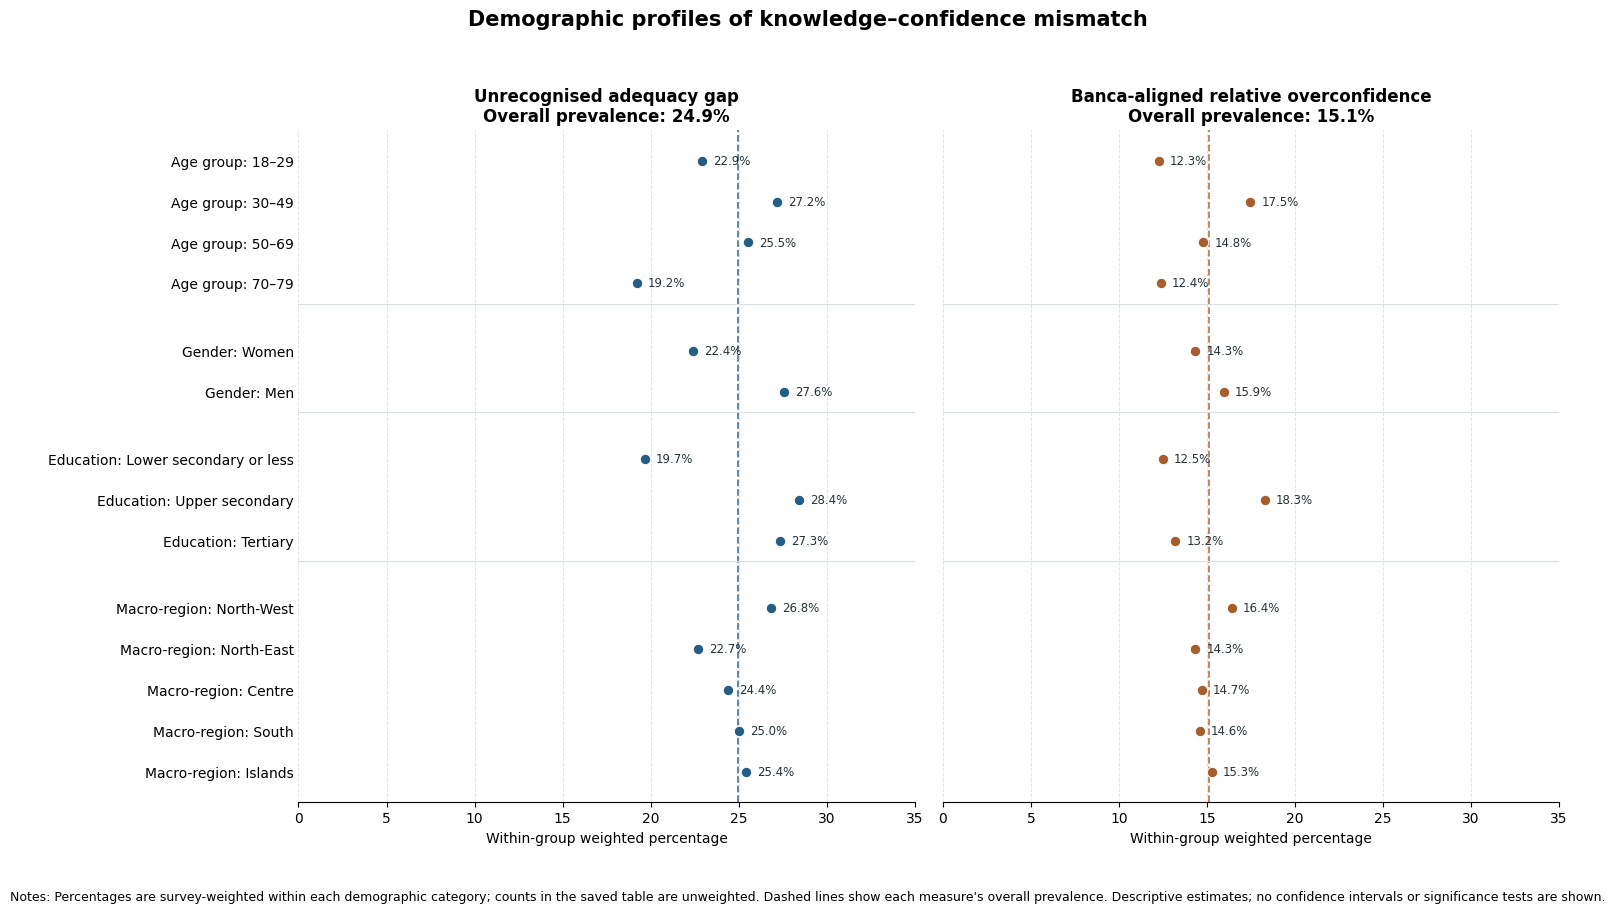

Module 3.4 figure saved successfully.


In [ ]:
# ============================================================
# Part 4: coordinated two-panel dot plot
# ============================================================

plot_category_rows = []
y_position = 0


for demographic_specification in (
    demographic_specifications
):
    demographic_variable = (
        demographic_specification[
            "variable"
        ]
    )

    demographic_label = (
        demographic_specification[
            "label"
        ]
    )

    for category in demographic_specification[
        "categories"
    ]:
        plot_category_rows.append(
            {
                "demographic_variable": (
                    demographic_variable
                ),
                "demographic_label": (
                    demographic_label
                ),
                "category": category,
                "axis_label": (
                    f"{demographic_label}: "
                    f"{category}"
                ),
                "y_position": y_position,
            }
        )

        y_position += 1

    y_position += 0.65


plot_categories = pd.DataFrame(
    plot_category_rows
)


plot_data = demographic_profiles.merge(
    plot_categories,
    on=[
        "demographic_variable",
        "demographic_label",
        "category",
    ],
    how="left",
    validate="many_to_one",
)

assert plot_data[
    "y_position"
].notna().all()


maximum_percentage = float(
    max(
        plot_data[
            "weighted_percent"
        ].max(),
        plot_data[
            "overall_weighted_percent"
        ].max(),
    )
)


x_axis_upper_limit = max(
    30,
    float(
        np.ceil(
            maximum_percentage
            * 1.18
            / 5
        )
        * 5
    ),
)


panel_colours = {
    "unrecognised_adequacy_gap": (
        "#265D85"
    ),
    "banca_aligned_relative_overconfidence": (
        "#A65E2E"
    ),
}


with plt.rc_context(
    {
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
    }
):
    figure, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(15.5, 9.2),
        sharex=True,
        sharey=True,
    )

    for axis, measure_specification in zip(
        axes,
        measure_specifications,
    ):
        measure = (
            measure_specification[
                "variable"
            ]
        )

        measure_label = (
            measure_specification[
                "label"
            ]
        )

        colour = panel_colours[
            measure
        ]

        panel_data = (
            plot_data.loc[
                plot_data[
                    "measure"
                ].eq(measure)
            ]
            .sort_values(
                "y_position"
            )
        )

        overall_percent = float(
            panel_data[
                "overall_weighted_percent"
            ].iloc[0]
        )

        axis.scatter(
            panel_data[
                "weighted_percent"
            ],
            panel_data[
                "y_position"
            ],
            s=58,
            color=colour,
            edgecolor="white",
            linewidth=0.8,
            zorder=3,
        )

        axis.axvline(
            overall_percent,
            color=colour,
            linestyle="--",
            linewidth=1.3,
            alpha=0.8,
        )

        for row in panel_data.itertuples(
            index=False
        ):
            axis.text(
                (
                    row.weighted_percent
                    + x_axis_upper_limit
                    * 0.018
                ),
                row.y_position,
                (
                    f"{row.weighted_percent:.1f}%"
                ),
                va="center",
                ha="left",
                fontsize=8.5,
                color="#263238",
            )

        axis.set_xlim(
            0,
            x_axis_upper_limit,
        )

        axis.set_xlabel(
            "Within-group weighted percentage"
        )

        axis.set_title(
            (
                f"{measure_label}\n"
                "Overall prevalence: "
                f"{overall_percent:.1f}%"
            ),
            fontweight="semibold",
        )

        axis.set_axisbelow(True)

        axis.xaxis.grid(
            True,
            linestyle="--",
            linewidth=0.7,
            alpha=0.35,
        )

        for spine in [
            "top",
            "right",
            "left",
        ]:
            axis.spines[
                spine
            ].set_visible(False)


    category_axis = (
        plot_categories
        .sort_values(
            "y_position"
        )
    )

    axes[0].set_yticks(
        category_axis[
            "y_position"
        ]
    )

    axes[0].set_yticklabels(
        category_axis[
            "axis_label"
        ]
    )

    axes[0].invert_yaxis()

    axes[0].tick_params(
        axis="y",
        length=0,
    )

    axes[1].tick_params(
        axis="y",
        length=0,
    )


    group_lengths = [
        len(
            specification[
                "categories"
            ]
        )
        for specification
        in demographic_specifications
    ]

    cumulative_position = 0

    for group_length in (
        group_lengths[:-1]
    ):
        cumulative_position += (
            group_length
        )

        separator_y = (
            cumulative_position
            - 0.5
        )

        for axis in axes:
            axis.axhline(
                separator_y,
                color="#D8DEE4",
                linewidth=0.8,
            )

        cumulative_position += 0.65


    figure.suptitle(
        (
            "Demographic profiles of "
            "knowledge–confidence mismatch"
        ),
        fontsize=15,
        fontweight="semibold",
    )

    figure.text(
        0.5,
        0.012,
        (
            "Notes: Percentages are survey-weighted "
            "within each demographic category; counts "
            "in the saved table are unweighted. Dashed "
            "lines show each measure's overall prevalence. "
            "Descriptive estimates; no confidence "
            "intervals or significance tests are shown."
        ),
        ha="center",
        fontsize=9,
    )

    figure.tight_layout(
        rect=(0, 0.055, 1, 0.95)
    )


figure_png_path = (
    figures_directory
    / "module_3_4_demographic_profiles.png"
)

figure_pdf_path = (
    figures_directory
    / "module_3_4_demographic_profiles.pdf"
)


figure.savefig(
    figure_png_path,
    dpi=300,
    bbox_inches="tight",
)

figure.savefig(
    figure_pdf_path,
    bbox_inches="tight",
)

plt.show()


assert figure_png_path.exists()
assert figure_png_path.stat().st_size > 0

assert figure_pdf_path.exists()
assert figure_pdf_path.stat().st_size > 0


print(
    "Module 3.4 figure saved successfully."
)

In [ ]:
# ============================================================
# Part 5: save and validate Module 3.4 outputs
# ============================================================

def assert_same_csv_values(
    reference,
    reloaded,
):
    """
    Compare values while allowing dtype differences
    introduced by CSV storage.
    """

    assert reference.shape == reloaded.shape

    assert list(
        reference.columns
    ) == list(
        reloaded.columns
    )

    for column in reference.columns:
        reference_series = (
            reference[column]
        )

        reloaded_series = (
            reloaded[column]
        )

        if pd.api.types.is_numeric_dtype(
            reference_series
        ):
            reference_values = (
                pd.to_numeric(
                    reference_series,
                    errors="coerce",
                )
                .astype("float64")
                .to_numpy()
            )

            reloaded_values = (
                pd.to_numeric(
                    reloaded_series,
                    errors="coerce",
                )
                .astype("float64")
                .to_numpy()
            )

            np.testing.assert_allclose(
                reference_values,
                reloaded_values,
                rtol=1e-12,
                atol=1e-12,
                equal_nan=True,
            )

        else:
            reference_values = (
                reference_series
                .astype("string")
                .fillna("<MISSING>")
                .tolist()
            )

            reloaded_values = (
                reloaded_series
                .astype("string")
                .fillna("<MISSING>")
                .tolist()
            )

            assert (
                reference_values
                == reloaded_values
            )


table_path = (
    tables_directory
    / "module_3_4_demographic_profiles.csv"
)

demographic_profiles.to_csv(
    table_path,
    index=False,
    encoding="utf-8",
)


reloaded_profiles = pd.read_csv(
    table_path
)

assert_same_csv_values(
    demographic_profiles,
    reloaded_profiles,
)


manifest_rows = [
    {
        "output_type": "Table",
        "filename": table_path.name,
        "rows": (
            demographic_profiles.shape[0]
        ),
        "columns": (
            demographic_profiles.shape[1]
        ),
        "size_bytes": (
            table_path.stat().st_size
        ),
        "validation": "Passed",
    }
]


for figure_path in [
    figure_png_path,
    figure_pdf_path,
]:
    manifest_rows.append(
        {
            "output_type": "Figure",
            "filename": figure_path.name,
            "rows": np.nan,
            "columns": np.nan,
            "size_bytes": (
                figure_path.stat().st_size
            ),
            "validation": "Passed",
        }
    )


module_3_4_manifest = pd.DataFrame(
    manifest_rows
)


assert len(module_3_4_manifest) == 3

assert (
    module_3_4_manifest[
        "validation"
    ].eq("Passed").all()
)


manifest_path = (
    tables_directory
    / "module_3_4_output_manifest.csv"
)

module_3_4_manifest.to_csv(
    manifest_path,
    index=False,
    encoding="utf-8",
)


display(module_3_4_manifest)

print(
    "Module 3.4 completed: all demographic-profile "
    "outputs were saved and validated."
)

,output_type,filename,rows,columns,size_bytes,validation
0,Table,module_3_4_demographic_profiles.csv,28.0,14.0,5505,Passed
1,Figure,module_3_4_demographic_profiles.png,NaN,NaN,502825,Passed
2,Figure,module_3_4_demographic_profiles.pdf,NaN,NaN,33901,Passed


Module 3.4 completed: all demographic-profile outputs were saved and validated.


**Result summary.** Module 3.4 was successfully validated on
4,453 joint-valid respondents. The highest prevalence under both mismatch
definitions was observed among respondents aged 30–49 and among those with
upper-secondary education. Men displayed a higher prevalence than women,
although the gender difference was substantially smaller under the
Banca-aligned definition.

The demographic profile was sensitive to the mismatch definition,
particularly for tertiary education: its unrecognised adequacy-gap prevalence
was 27.3%, compared with 13.2% for Banca-aligned relative overconfidence.
This divergence indicates that many tertiary-educated respondents classified
by the broad measure belong to the score-4 boundary group: above the national
objective-knowledge mean but below the OECD/INFE adequacy target.

These results are descriptive and unadjusted. Lower mismatch prevalence must
not be interpreted as higher financial knowledge or lower financial
vulnerability.

## 3.5 Weighted Outcome Distributions and Analytical-Sample Availability

**Purpose.** Describe the four approved binary outcomes and document the
outcome-specific samples available for subsequent adjusted analyses.

The original outcome directions are retained. `financial_incident_any = 1`
denotes an adverse event, whereas `careful_before_purchase = 1`,
`sets_long_term_goals = 1`, and `shopped_around = 1` denote prudent
behaviours. These outcomes must therefore not be interpreted as sharing a
common substantive direction merely because they all use the value one.

Each outcome uses its own valid-response denominator. The shopping-around
outcome is secondary and is restricted to respondents in the observed QP5
question universe after recently choosing a financial product. Structural
non-administration of QP5 is reported separately from non-substantive
responses.

Four samples are documented for each outcome:

1. the outcome-valid descriptive sample;
2. the core-model eligible sample, requiring valid objective knowledge,
   self-rated knowledge, survey weight, age group, gender, education, and
   macro-region;
3. the exposure-aware eligible sample, additionally requiring products held
   and Internet access;
4. the income-complete sensitivity sample, additionally requiring household
   income.

The exposure-aware and income-complete samples are separate branches from the
core sample. The income-complete sample is not restricted to respondents in
the exposure-aware sample.

The weight-only Kish effective sample size is calculated as

$$
n_{\mathrm{eff,Kish}}
=
\frac{\left(\sum_i w_i\right)^2}
{\sum_i w_i^2}
$$


It is reported only as a technical diagnostic of information loss associated
with unequal weights. It is not a design-based effective sample size, does not
replace unavailable strata or primary-sampling-unit information, and is not
used to alter prevalence estimates, determine significance, or select models.

Percentages are survey-weighted and respondent counts are unweighted.
Full-precision estimates are retained in saved CSV files. This module is
descriptive and includes no confidence intervals, hypothesis tests, p-values,
or causal claims.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D


# ============================================================
# Module 3.5 — Weighted outcome distributions and
# analytical-sample availability
# Part 1: load and validate the canonical checkpoint
# ============================================================

checkpoint_path = (
    Path(PROJECT_ROOT)
    / "data"
    / "processed"
    / "iacofi_analytical_checkpoint.parquet"
)
tables_directory = Path(PROJECT_ROOT) / "outputs" / "tables"
figures_directory = Path(PROJECT_ROOT) / "outputs" / "figures"

tables_directory.mkdir(parents=True, exist_ok=True)
figures_directory.mkdir(parents=True, exist_ok=True)

required_variables = [
    "respondent_id",
    "survey_weight",
    "objective_knowledge_score",
    "self_rated_knowledge",
    "financial_incident_any",
    "careful_before_purchase",
    "sets_long_term_goals",
    "shopped_around",
    "age_group",
    "gender",
    "education_group",
    "macro_region",
    "products_held_count",
    "internet_access",
    "household_income_group",
    "qs2_3",
    "qs1_8",
    "qp5",
]

outcome_variables = [
    "financial_incident_any",
    "careful_before_purchase",
    "sets_long_term_goals",
    "shopped_around",
]

assert checkpoint_path.exists(), (
    f"Checkpoint not found: {checkpoint_path}"
)

outcome_df = pd.read_parquet(
    checkpoint_path,
    engine="pyarrow",
)

assert outcome_df.shape == (4862, 22)

missing_variables = sorted(
    set(required_variables)
    - set(outcome_df.columns)
)

assert not missing_variables, (
    "Missing Module 3.5 variables: "
    f"{missing_variables}"
)

assert outcome_df["respondent_id"].notna().all()
assert outcome_df["respondent_id"].is_unique

np.testing.assert_array_equal(
    outcome_df["respondent_id"].to_numpy(),
    np.arange(1, 4863),
)

weights = pd.to_numeric(
    outcome_df["survey_weight"],
    errors="coerce",
).astype(float)

assert weights.notna().all()
assert np.isfinite(weights).all()
assert weights.gt(0).all()

outcome_series = {
    variable: pd.to_numeric(
        outcome_df[variable],
        errors="coerce",
    )
    for variable in outcome_variables
}

for variable, values in outcome_series.items():
    assert values.dropna().isin([0, 1]).all(), (
        f"Unexpected codes in {variable}"
    )

expected_valid_n = {
    "financial_incident_any": 4531,
    "careful_before_purchase": 4554,
    "sets_long_term_goals": 4320,
    "shopped_around": 1082,
}

observed_valid_n = {
    variable: int(values.notna().sum())
    for variable, values in outcome_series.items()
}

assert observed_valid_n == expected_valid_n


def assert_binary_recode(
    raw_values,
    derived_values,
    positive_codes,
    zero_codes,
):
    """
    Validate an approved binary recode from a retained
    raw item.
    """

    raw_numeric = pd.to_numeric(
        raw_values,
        errors="coerce",
    )

    expected = pd.Series(
        np.nan,
        index=raw_numeric.index,
        dtype="float64",
    )

    expected.loc[
        raw_numeric.isin(positive_codes)
    ] = 1.0

    expected.loc[
        raw_numeric.isin(zero_codes)
    ] = 0.0

    observed = pd.to_numeric(
        derived_values,
        errors="coerce",
    )

    np.testing.assert_array_equal(
        observed.notna().to_numpy(),
        expected.notna().to_numpy(),
    )

    valid_mask = expected.notna()

    np.testing.assert_array_equal(
        observed.loc[
            valid_mask
        ].astype(int).to_numpy(),
        expected.loc[
            valid_mask
        ].astype(int).to_numpy(),
    )


assert_binary_recode(
    outcome_df["qs2_3"],
    outcome_df["careful_before_purchase"],
    positive_codes=[1, 2],
    zero_codes=[3, 4, 5],
)

assert_binary_recode(
    outcome_df["qs1_8"],
    outcome_df["sets_long_term_goals"],
    positive_codes=[1, 2],
    zero_codes=[3, 4, 5],
)

assert_binary_recode(
    outcome_df["qp5"],
    outcome_df["shopped_around"],
    positive_codes=[1, 2],
    zero_codes=[3, 4],
)

# QP5 is administered only to recent product choosers.
raw_qp5 = pd.to_numeric(
    outcome_df["qp5"],
    errors="coerce",
)

shopping_universe_mask = raw_qp5.notna()
shopping_valid_mask = raw_qp5.isin(
    [1, 2, 3, 4]
)

assert int(shopping_universe_mask.sum()) == 1329
assert int((~shopping_universe_mask).sum()) == 3533
assert int(shopping_valid_mask.sum()) == 1082

assert int(
    (
        shopping_universe_mask
        & ~shopping_valid_mask
    ).sum()
) == 247

print(
    "Module 3.5 source and outcome codings "
    "validated successfully."
)

for variable in outcome_variables:
    print(
        f"{variable}: "
        f"valid n = {observed_valid_n[variable]:,}; "
        f"unavailable n = "
        f"{len(outcome_df) - observed_valid_n[variable]:,}."
    )

Module 3.5 source and outcome codings validated successfully.
financial_incident_any: valid n = 4,531; unavailable n = 331.
careful_before_purchase: valid n = 4,554; unavailable n = 308.
sets_long_term_goals: valid n = 4,320; unavailable n = 542.
shopped_around: valid n = 1,082; unavailable n = 3,780.


In [ ]:
# ============================================================
# Part 2: weighted outcome distributions
# ============================================================

outcome_specifications = [
    {
        "outcome_order": 1,
        "outcome": "financial_incident_any",
        "outcome_label": (
            "Reported at least one financial incident"
        ),
        "analysis_role": "Primary outcome",
        "outcome_1_meaning": (
            "Reported at least one incident"
        ),
        "substantive_direction": "Adverse event",
        "question_universe": "Full respondent sample",
        "availability_note": (
            "Valid only when all four incident "
            "components are valid."
        ),
    },
    {
        "outcome_order": 2,
        "outcome": "careful_before_purchase",
        "outcome_label": (
            "Carefully considers affordability"
        ),
        "analysis_role": "Primary outcome",
        "outcome_1_meaning": (
            "Always or often considers affordability"
        ),
        "substantive_direction": "Prudent behaviour",
        "question_universe": "Full respondent sample",
        "availability_note": (
            "Valid source responses are codes 1–5."
        ),
    },
    {
        "outcome_order": 3,
        "outcome": "sets_long_term_goals",
        "outcome_label": (
            "Sets and pursues long-term financial goals"
        ),
        "analysis_role": "Primary outcome",
        "outcome_1_meaning": (
            "Agrees or completely agrees"
        ),
        "substantive_direction": "Prudent behaviour",
        "question_universe": "Full respondent sample",
        "availability_note": (
            "Valid source responses are codes 1–5."
        ),
    },
    {
        "outcome_order": 4,
        "outcome": "shopped_around",
        "outcome_label": (
            "Compared options before choosing a product"
        ),
        "analysis_role": "Secondary outcome",
        "outcome_1_meaning": (
            "Considered multiple options before choosing"
        ),
        "substantive_direction": "Prudent behaviour",
        "question_universe": (
            "Recent product choosers only"
        ),
        "availability_note": (
            "Restricted to the observed QP5 question "
            "universe; structural non-administration is "
            "separated from non-substantive responses."
        ),
    },
]

expected_outcome_1_n = {
    "financial_incident_any": 675,
    "careful_before_purchase": 2172,
    "sets_long_term_goals": 1544,
    "shopped_around": 555,
}

expected_weighted_percent_1 = {
    "financial_incident_any": 14.4,
    "careful_before_purchase": 48.5,
    "sets_long_term_goals": 35.7,
    "shopped_around": 49.3,
}

full_sample_mask = pd.Series(
    True,
    index=outcome_df.index,
)

question_universe_masks = {
    "financial_incident_any": full_sample_mask,
    "careful_before_purchase": full_sample_mask,
    "sets_long_term_goals": full_sample_mask,
    "shopped_around": shopping_universe_mask,
}

outcome_distribution_rows = []

for specification in outcome_specifications:
    variable = specification["outcome"]
    values = outcome_series[variable]

    question_universe_mask = (
        question_universe_masks[variable]
    )

    valid_mask = (
        values.notna()
        & weights.notna()
        & weights.gt(0)
    )

    outcome_1_mask = (
        valid_mask
        & values.eq(1).fillna(False)
    )

    outcome_0_mask = (
        valid_mask
        & values.eq(0).fillna(False)
    )

    question_universe_n = int(
        question_universe_mask.sum()
    )

    not_administered_n = int(
        (~question_universe_mask).sum()
    )

    valid_n = int(valid_mask.sum())

    unavailable_within_universe_n = int(
        (
            question_universe_mask
            & ~valid_mask
        ).sum()
    )

    unavailable_n = (
        len(outcome_df)
        - valid_n
    )

    outcome_1_n = int(
        outcome_1_mask.sum()
    )

    outcome_0_n = int(
        outcome_0_mask.sum()
    )

    weighted_denominator = float(
        weights.loc[valid_mask].sum()
    )

    weighted_percent_1 = float(
        100
        * weights.loc[outcome_1_mask].sum()
        / weighted_denominator
    )

    weighted_percent_0 = float(
        100
        * weights.loc[outcome_0_mask].sum()
        / weighted_denominator
    )

    assert valid_n == expected_valid_n[variable]
    assert outcome_1_n == expected_outcome_1_n[variable]
    assert outcome_1_n + outcome_0_n == valid_n

    assert (
        question_universe_n
        + not_administered_n
        == len(outcome_df)
    )

    assert (
        valid_n
        + unavailable_within_universe_n
        == question_universe_n
    )

    assert unavailable_n == (
        not_administered_n
        + unavailable_within_universe_n
    )

    assert np.isclose(
        weighted_percent_1
        + weighted_percent_0,
        100,
        atol=1e-10,
    )

    assert round(
        weighted_percent_1,
        1,
    ) == expected_weighted_percent_1[variable]

    outcome_distribution_rows.append(
        {
            **specification,
            "question_universe_unweighted_n": (
                question_universe_n
            ),
            "not_administered_unweighted_n": (
                not_administered_n
            ),
            "valid_unweighted_n": valid_n,
            "unavailable_within_universe_n": (
                unavailable_within_universe_n
            ),
            "unavailable_total_unweighted_n": (
                unavailable_n
            ),
            "valid_percent_within_question_universe": (
                100
                * valid_n
                / question_universe_n
            ),
            "valid_percent_of_full_sample": (
                100
                * valid_n
                / len(outcome_df)
            ),
            "outcome_1_unweighted_n": outcome_1_n,
            "outcome_0_unweighted_n": outcome_0_n,
            "weighted_denominator": (
                weighted_denominator
            ),
            "weighted_percent_1": (
                weighted_percent_1
            ),
            "weighted_percent_0": (
                weighted_percent_0
            ),
        }
    )

outcome_distributions = (
    pd.DataFrame(outcome_distribution_rows)
    .sort_values("outcome_order")
    .reset_index(drop=True)
)

assert outcome_distributions.shape[0] == 4

assert outcome_distributions[
    "weighted_percent_1"
].between(0, 100).all()

assert outcome_distributions[
    "weighted_percent_0"
].between(0, 100).all()

outcome_distributions_display = (
    outcome_distributions.copy()
)

for column in [
    "valid_percent_within_question_universe",
    "valid_percent_of_full_sample",
    "weighted_percent_1",
    "weighted_percent_0",
]:
    outcome_distributions_display[column] = (
        outcome_distributions_display[column]
        .round(1)
    )

display(
    outcome_distributions_display[
        [
            "outcome_label",
            "analysis_role",
            "outcome_1_meaning",
            "substantive_direction",
            "question_universe_unweighted_n",
            "not_administered_unweighted_n",
            "unavailable_within_universe_n",
            "valid_unweighted_n",
            "valid_percent_within_question_universe",
            "outcome_1_unweighted_n",
            "weighted_percent_1",
        ]
    ]
)

print(
    "Weighted outcome-distribution checks passed."
)

,outcome_label,analysis_role,outcome_1_meaning,substantive_direction,question_universe_unweighted_n,not_administered_unweighted_n,unavailable_within_universe_n,valid_unweighted_n,valid_percent_within_question_universe,outcome_1_unweighted_n,weighted_percent_1
0,Reported at least one financial incident,Primary outcome,Reported at least one incident,Adverse event,4862,0,331,4531,93.2,675,14.4
1,Carefully considers affordability,Primary outcome,Always or often considers affordability,Prudent behaviour,4862,0,308,4554,93.7,2172,48.5
2,Sets and pursues long-term financial goals,Primary outcome,Agrees or completely agrees,Prudent behaviour,4862,0,542,4320,88.9,1544,35.7
3,Compared options before choosing a product,Secondary outcome,Considered multiple options before choosing,Prudent behaviour,1329,3533,247,1082,81.4,555,49.3


Weighted outcome-distribution checks passed.


In [ ]:
# ============================================================
# Part 3: outcome-specific analytical samples and
# weight-only Kish effective sample size
# ============================================================

objective_score = pd.to_numeric(
    outcome_df["objective_knowledge_score"],
    errors="coerce",
)

self_rating = pd.to_numeric(
    outcome_df["self_rated_knowledge"],
    errors="coerce",
)

products_held_count = pd.to_numeric(
    outcome_df["products_held_count"],
    errors="coerce",
)

internet_access = pd.to_numeric(
    outcome_df["internet_access"],
    errors="coerce",
)

assert objective_score.notna().all()
assert objective_score.isin(range(0, 8)).all()

assert int(self_rating.notna().sum()) == 4453
assert self_rating.dropna().isin(range(1, 6)).all()

for variable in [
    "age_group",
    "gender",
    "education_group",
    "macro_region",
]:
    assert outcome_df[variable].notna().all(), (
        f"Unexpected missing values in {variable}"
    )

assert int(
    products_held_count.notna().sum()
) == 4740

assert int(
    internet_access.notna().sum()
) == 4842

assert int(
    outcome_df[
        "household_income_group"
    ].notna().sum()
) == 3349

valid_weight_mask = (
    weights.notna()
    & weights.gt(0)
)

valid_focal_mask = (
    objective_score.notna()
    & self_rating.notna()
)

valid_core_covariates_mask = (
    outcome_df[
        [
            "age_group",
            "gender",
            "education_group",
            "macro_region",
        ]
    ]
    .notna()
    .all(axis=1)
)

valid_exposure_covariates_mask = (
    products_held_count.notna()
    & internet_access.notna()
)

valid_income_mask = outcome_df[
    "household_income_group"
].notna()


def weight_only_kish_effective_n(
    sample_weights,
):
    """
    Return (sum w)^2 / sum(w^2).

    This is a weight-dispersion audit diagnostic,
    not a substitute for a design-based effective
    sample size.
    """

    weight_array = np.asarray(
        sample_weights,
        dtype=float,
    )

    assert weight_array.ndim == 1
    assert len(weight_array) > 0
    assert np.isfinite(weight_array).all()
    assert (weight_array > 0).all()

    return float(
        weight_array.sum() ** 2
        / np.square(weight_array).sum()
    )


sample_specifications = [
    {
        "sample_order": 1,
        "sample_code": (
            "outcome_valid_descriptive"
        ),
        "sample_label": (
            "Outcome-valid descriptive sample"
        ),
        "parent_sample": (
            "Outcome-specific question universe"
        ),
        "analysis_purpose": (
            "Weighted outcome prevalence"
        ),
    },
    {
        "sample_order": 2,
        "sample_code": "core_model_eligible",
        "sample_label": (
            "Core-model eligible sample"
        ),
        "parent_sample": (
            "Outcome-valid descriptive sample"
        ),
        "analysis_purpose": (
            "Primary adjusted model"
        ),
    },
    {
        "sample_order": 3,
        "sample_code": (
            "exposure_aware_eligible"
        ),
        "sample_label": (
            "Exposure-aware eligible sample"
        ),
        "parent_sample": (
            "Core-model eligible sample"
        ),
        "analysis_purpose": (
            "Alternative exposure-aware model"
        ),
    },
    {
        "sample_order": 4,
        "sample_code": (
            "income_complete_sensitivity"
        ),
        "sample_label": (
            "Income-complete sensitivity sample"
        ),
        "parent_sample": (
            "Core-model eligible sample"
        ),
        "analysis_purpose": (
            "Alternative income-complete sensitivity"
        ),
    },
]

sample_availability_rows = []

for outcome_specification in outcome_specifications:
    variable = outcome_specification["outcome"]

    question_universe_mask = (
        question_universe_masks[variable]
    )

    outcome_valid_mask = (
        outcome_series[variable].notna()
        & valid_weight_mask
    )

    core_model_mask = (
        outcome_valid_mask
        & valid_focal_mask
        & valid_core_covariates_mask
    )

    exposure_aware_mask = (
        core_model_mask
        & valid_exposure_covariates_mask
    )

    # Income-complete and exposure-aware samples are
    # separate branches from the core-model sample.
    # They are not applied sequentially.
    income_complete_mask = (
        core_model_mask
        & valid_income_mask
    )

    sample_masks = {
        "outcome_valid_descriptive": (
            outcome_valid_mask
        ),
        "core_model_eligible": (
            core_model_mask
        ),
        "exposure_aware_eligible": (
            exposure_aware_mask
        ),
        "income_complete_sensitivity": (
            income_complete_mask
        ),
    }

    parent_masks = {
        "outcome_valid_descriptive": (
            question_universe_mask
        ),
        "core_model_eligible": (
            outcome_valid_mask
        ),
        "exposure_aware_eligible": (
            core_model_mask
        ),
        "income_complete_sensitivity": (
            core_model_mask
        ),
    }

    assert int(
        outcome_valid_mask.sum()
    ) == expected_valid_n[variable]

    assert not (
        core_model_mask
        & ~outcome_valid_mask
    ).any()

    assert not (
        exposure_aware_mask
        & ~core_model_mask
    ).any()

    assert not (
        income_complete_mask
        & ~core_model_mask
    ).any()

    outcome_valid_n = int(
        outcome_valid_mask.sum()
    )

    for sample_specification in (
        sample_specifications
    ):
        sample_code = sample_specification[
            "sample_code"
        ]

        sample_mask = sample_masks[
            sample_code
        ]

        parent_mask = parent_masks[
            sample_code
        ]

        sample_n = int(
            sample_mask.sum()
        )

        parent_n = int(
            parent_mask.sum()
        )

        assert 0 < sample_n <= parent_n

        sample_weights = (
            weights.loc[
                sample_mask
            ]
            .astype(float)
            .to_numpy()
        )

        kish_effective_n = (
            weight_only_kish_effective_n(
                sample_weights
            )
        )

        assert 0 < kish_effective_n
        assert (
            kish_effective_n
            <= sample_n + 1e-8
        )

        sample_availability_rows.append(
            {
                "outcome_order": (
                    outcome_specification[
                        "outcome_order"
                    ]
                ),
                "outcome": variable,
                "outcome_label": (
                    outcome_specification[
                        "outcome_label"
                    ]
                ),
                "analysis_role": (
                    outcome_specification[
                        "analysis_role"
                    ]
                ),
                **sample_specification,
                "unweighted_n": sample_n,
                "parent_unweighted_n": parent_n,
                "excluded_from_parent_n": (
                    parent_n - sample_n
                ),
                "retained_percent_of_parent": (
                    100
                    * sample_n
                    / parent_n
                ),
                "retained_percent_of_outcome_valid": (
                    100
                    * sample_n
                    / outcome_valid_n
                ),
                "sum_of_weights": float(
                    sample_weights.sum()
                ),
                "weight_only_kish_effective_n": (
                    kish_effective_n
                ),
                "weight_only_kish_efficiency_percent": (
                    100
                    * kish_effective_n
                    / sample_n
                ),
            }
        )

analytical_sample_availability = (
    pd.DataFrame(sample_availability_rows)
    .sort_values(
        [
            "outcome_order",
            "sample_order",
        ]
    )
    .reset_index(drop=True)
)

assert (
    analytical_sample_availability.shape[0]
    == 16
)

assert analytical_sample_availability[
    "weight_only_kish_efficiency_percent"
].between(
    0,
    100 + 1e-8,
).all()

for variable in outcome_variables:
    outcome_sample_table = (
        analytical_sample_availability.loc[
            analytical_sample_availability[
                "outcome"
            ].eq(variable)
        ]
    )

    assert outcome_sample_table[
        "sample_order"
    ].tolist() == [1, 2, 3, 4]

    descriptive_n = int(
        outcome_sample_table.loc[
            outcome_sample_table[
                "sample_code"
            ].eq(
                "outcome_valid_descriptive"
            ),
            "unweighted_n",
        ].iloc[0]
    )

    assert (
        descriptive_n
        == expected_valid_n[variable]
    )

analytical_sample_availability_display = (
    analytical_sample_availability.copy()
)

for column in [
    "retained_percent_of_parent",
    "retained_percent_of_outcome_valid",
    "sum_of_weights",
    "weight_only_kish_effective_n",
    "weight_only_kish_efficiency_percent",
]:
    analytical_sample_availability_display[
        column
    ] = analytical_sample_availability_display[
        column
    ].round(1)

display(
    analytical_sample_availability_display[
        [
            "outcome_label",
            "sample_label",
            "parent_sample",
            "unweighted_n",
            "excluded_from_parent_n",
            "retained_percent_of_parent",
            "retained_percent_of_outcome_valid",
            "weight_only_kish_effective_n",
            "weight_only_kish_efficiency_percent",
        ]
    ]
)

print(
    "Outcome-specific sample and "
    "weight-dispersion checks passed."
)

,outcome_label,sample_label,parent_sample,unweighted_n,excluded_from_parent_n,retained_percent_of_parent,retained_percent_of_outcome_valid,weight_only_kish_effective_n,weight_only_kish_efficiency_percent
0,Reported at least one financial incident,Outcome-valid descriptive sample,Outcome-specific question universe,4531,331,93.2,100.0,3326.5,73.4
1,Reported at least one financial incident,Core-model eligible sample,Outcome-valid descriptive sample,4204,327,92.8,92.8,3089.2,73.5
2,Reported at least one financial incident,Exposure-aware eligible sample,Core-model eligible sample,4143,61,98.5,91.4,3045.8,73.5
3,Reported at least one financial incident,Income-complete sensitivity sample,Core-model eligible sample,3034,1170,72.2,67.0,2281.0,75.2
4,Carefully considers affordability,Outcome-valid descriptive sample,Outcome-specific question universe,4554,308,93.7,100.0,3381.5,74.3
5,Carefully considers affordability,Core-model eligible sample,Outcome-valid descriptive sample,4276,278,93.9,93.9,3176.1,74.3
6,Carefully considers affordability,Exposure-aware eligible sample,Core-model eligible sample,4170,106,97.5,91.6,3096.6,74.3
7,Carefully considers affordability,Income-complete sensitivity sample,Core-model eligible sample,3095,1181,72.4,68.0,2318.7,74.9
8,Sets and pursues long-term financial goals,Outcome-valid descriptive sample,Outcome-specific question universe,4320,542,88.9,100.0,3185.5,73.7
9,Sets and pursues long-term financial goals,Core-model eligible sample,Outcome-valid descriptive sample,4080,240,94.4,94.4,3010.6,73.8


Outcome-specific sample and weight-dispersion checks passed.


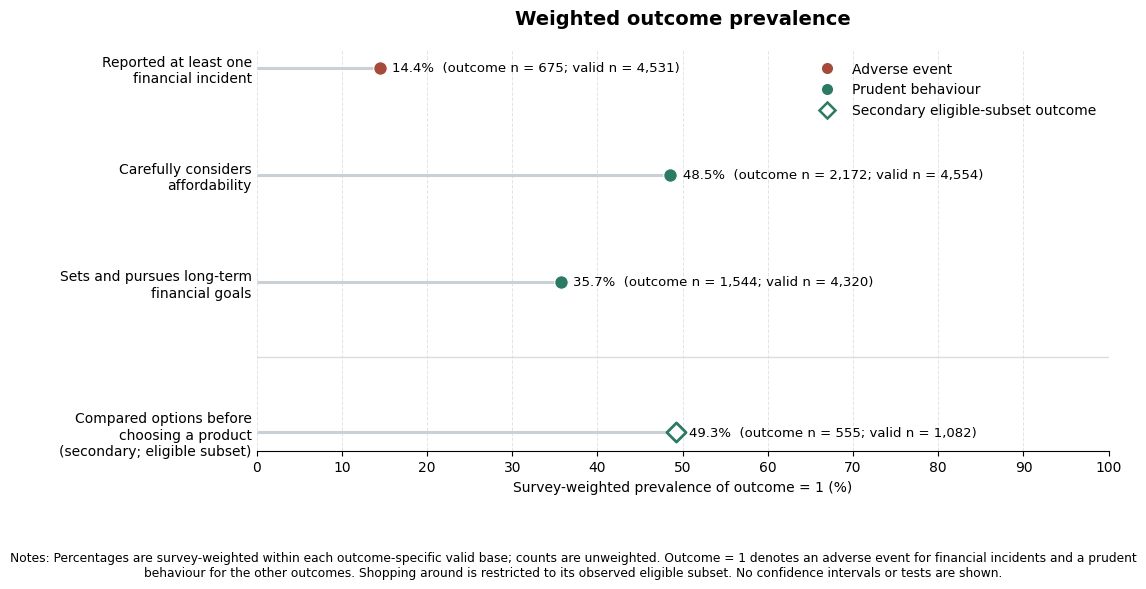

Module 3.5 figure saved successfully.


In [ ]:
# ============================================================
# Part 4: weighted outcome-prevalence dot plot
# ============================================================

outcome_plot = (
    outcome_distributions
    .sort_values("outcome_order")
    .reset_index(drop=True)
)

plot_labels = [
    (
        "Reported at least one\n"
        "financial incident"
    ),
    (
        "Carefully considers\n"
        "affordability"
    ),
    (
        "Sets and pursues long-term\n"
        "financial goals"
    ),
    (
        "Compared options before\n"
        "choosing a product\n"
        "(secondary; eligible subset)"
    ),
]

y_positions = np.array(
    [3.4, 2.4, 1.4, 0.0]
)

plot_colours = [
    "#A64B3C",
    "#2C7A64",
    "#2C7A64",
    "#2C7A64",
]

with plt.rc_context(
    {
        "font.size": 10,
        "axes.titlesize": 14,
        "axes.labelsize": 10,
    }
):
    figure, axis = plt.subplots(
        figsize=(11.5, 6.2)
    )

    for row_index, row in (
        outcome_plot.iterrows()
    ):
        y_position = y_positions[
            row_index
        ]

        percentage = float(
            row["weighted_percent_1"]
        )

        axis.hlines(
            y=y_position,
            xmin=0,
            xmax=percentage,
            color="#C9D0D6",
            linewidth=2.2,
            zorder=1,
        )

        if (
            row["outcome"]
            == "shopped_around"
        ):
            axis.scatter(
                percentage,
                y_position,
                s=95,
                marker="D",
                facecolor="white",
                edgecolor=(
                    plot_colours[row_index]
                ),
                linewidth=2.0,
                zorder=3,
            )
        else:
            axis.scatter(
                percentage,
                y_position,
                s=95,
                marker="o",
                color=(
                    plot_colours[row_index]
                ),
                edgecolor="white",
                linewidth=0.8,
                zorder=3,
            )

        if percentage <= 76:
            annotation_x = (
                percentage + 1.5
            )
            horizontal_alignment = "left"
        else:
            annotation_x = (
                percentage - 1.5
            )
            horizontal_alignment = "right"

        axis.text(
            annotation_x,
            y_position,
            (
                f"{percentage:.1f}%  "
                f"(outcome n = "
                f"{int(row['outcome_1_unweighted_n']):,}; "
                f"valid n = "
                f"{int(row['valid_unweighted_n']):,})"
            ),
            ha=horizontal_alignment,
            va="center",
            fontsize=9.5,
        )

    axis.axhline(
        0.7,
        color="#D7DCE1",
        linewidth=1.0,
    )

    axis.set_yticks(y_positions)
    axis.set_yticklabels(plot_labels)

    axis.set_xlim(0, 100)
    axis.set_xticks(
        np.arange(0, 101, 10)
    )

    axis.set_xlabel(
        "Survey-weighted prevalence "
        "of outcome = 1 (%)"
    )

    axis.set_title(
        "Weighted outcome prevalence",
        fontweight="semibold",
        pad=18,
    )

    axis.set_axisbelow(True)

    axis.xaxis.grid(
        True,
        linestyle="--",
        linewidth=0.7,
        alpha=0.35,
    )

    axis.yaxis.grid(False)

    for spine in [
        "top",
        "right",
        "left",
    ]:
        axis.spines[
            spine
        ].set_visible(False)

    axis.tick_params(
        axis="y",
        length=0,
    )

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor="#A64B3C",
            markeredgecolor="white",
            markersize=9,
            label="Adverse event",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor="#2C7A64",
            markeredgecolor="white",
            markersize=9,
            label="Prudent behaviour",
        ),
        Line2D(
            [0],
            [0],
            marker="D",
            color="none",
            markerfacecolor="white",
            markeredgecolor="#2C7A64",
            markeredgewidth=1.8,
            markersize=8,
            label=(
                "Secondary eligible-subset "
                "outcome"
            ),
        ),
    ]

    axis.legend(
        handles=legend_handles,
        frameon=False,
        loc="upper right",
    )

    figure.text(
        0.5,
        0.025,
        (
            "Notes: Percentages are survey-weighted "
            "within each outcome-specific valid base; "
            "counts are unweighted. Outcome = 1 denotes "
            "an adverse event for financial incidents "
            "and a prudent behaviour for the other "
            "outcomes. Shopping around is restricted "
            "to its observed eligible subset. No "
            "confidence intervals or tests are shown."
        ),
        ha="center",
        fontsize=8.8,
        wrap=True,
    )

    figure.tight_layout(
        rect=(0.04, 0.13, 0.99, 0.96)
    )

figure_png_path = (
    figures_directory
    / "module_3_5_outcome_prevalence.png"
)

figure_pdf_path = (
    figures_directory
    / "module_3_5_outcome_prevalence.pdf"
)

figure.savefig(
    figure_png_path,
    dpi=300,
    bbox_inches="tight",
)

figure.savefig(
    figure_pdf_path,
    bbox_inches="tight",
)

plt.show()

assert figure_png_path.exists()
assert figure_png_path.stat().st_size > 0

assert figure_pdf_path.exists()
assert figure_pdf_path.stat().st_size > 0

print(
    "Module 3.5 figure saved successfully."
)

In [ ]:
# ============================================================
# Part 5: save and validate Module 3.5 outputs
# ============================================================

def assert_same_csv_values(
    reference,
    reloaded,
):
    """
    Compare values while allowing dtype changes
    introduced by CSV storage.
    """

    assert reference.shape == reloaded.shape

    assert list(
        reference.columns
    ) == list(
        reloaded.columns
    )

    for column in reference.columns:
        reference_series = reference[column]
        reloaded_series = reloaded[column]

        if pd.api.types.is_numeric_dtype(
            reference_series
        ):
            reference_values = (
                pd.to_numeric(
                    reference_series,
                    errors="coerce",
                )
                .astype("float64")
                .to_numpy()
            )

            reloaded_values = (
                pd.to_numeric(
                    reloaded_series,
                    errors="coerce",
                )
                .astype("float64")
                .to_numpy()
            )

            np.testing.assert_allclose(
                reference_values,
                reloaded_values,
                rtol=1e-12,
                atol=1e-12,
                equal_nan=True,
            )

        else:
            reference_values = (
                reference_series
                .astype("string")
                .fillna("<MISSING>")
                .tolist()
            )

            reloaded_values = (
                reloaded_series
                .astype("string")
                .fillna("<MISSING>")
                .tolist()
            )

            assert (
                reference_values
                == reloaded_values
            )


module_3_5_tables = {
    "module_3_5_outcome_distributions.csv": (
        outcome_distributions
    ),
    "module_3_5_sample_availability.csv": (
        analytical_sample_availability
    ),
}

manifest_rows = []

for filename, table in (
    module_3_5_tables.items()
):
    output_path = (
        tables_directory
        / filename
    )

    table.to_csv(
        output_path,
        index=False,
        encoding="utf-8",
    )

    reloaded_table = pd.read_csv(
        output_path
    )

    assert_same_csv_values(
        table,
        reloaded_table,
    )

    manifest_rows.append(
        {
            "output_type": "Table",
            "filename": filename,
            "rows": table.shape[0],
            "columns": table.shape[1],
            "size_bytes": (
                output_path.stat().st_size
            ),
            "validation": "Passed",
        }
    )

for figure_path in [
    figure_png_path,
    figure_pdf_path,
]:
    assert figure_path.exists()
    assert figure_path.stat().st_size > 0

    manifest_rows.append(
        {
            "output_type": "Figure",
            "filename": figure_path.name,
            "rows": None,
            "columns": None,
            "size_bytes": (
                figure_path.stat().st_size
            ),
            "validation": "Passed",
        }
    )

module_3_5_manifest = pd.DataFrame(
    manifest_rows
)

assert len(module_3_5_manifest) == 4

assert (
    module_3_5_manifest[
        "validation"
    ]
    .eq("Passed")
    .all()
)

manifest_path = (
    tables_directory
    / "module_3_5_output_manifest.csv"
)

module_3_5_manifest.to_csv(
    manifest_path,
    index=False,
    encoding="utf-8",
)

display(module_3_5_manifest)

print(
    "Module 3.5 completed: all outcome and "
    "sample-availability outputs were saved "
    "and validated."
)

,output_type,filename,rows,columns,size_bytes,validation
0,Table,module_3_5_outcome_distributions.csv,4.0,20.0,1813,Passed
1,Table,module_3_5_sample_availability.csv,16.0,17.0,5123,Passed
2,Figure,module_3_5_outcome_prevalence.png,NaN,NaN,343349,Passed
3,Figure,module_3_5_outcome_prevalence.pdf,NaN,NaN,26759,Passed


Module 3.5 completed: all outcome and sample-availability outputs were saved and validated.


## 3.6 Knowledge Calibration and Unadjusted Outcome Profiles

**Purpose.** Complete the descriptive analysis by examining the full
alignment between objective and self-rated financial knowledge and by
describing unadjusted outcome prevalence across the six approved
knowledge-confidence profiles.

The calibration analysis retains all eight objective scores from 0 to 7
and all five ordered self-rating categories from 1 (very low) to 5
(very high). The primary heatmap reports survey-weighted percentages
within each objective-score row. Each row therefore describes how
respondents with the same objective score rate their own knowledge.
Joint weighted percentages and unweighted cell counts are retained in
the saved table.

The monotonic relationship between the two measures is summarised using
a weighted Spearman-type rank association. Weighted fractional
mid-ranks are calculated for both ordered variables and their weighted
correlation is then obtained. This avoids treating the distances between
adjacent self-rating categories as necessarily equal. The coefficient is
descriptive; no confidence interval or p-value is reported.

Unadjusted outcome prevalence is reported across six profiles formed by:

- objective knowledge below the adequacy target versus meeting the target;
- self-rated knowledge below average, exactly average, or high/very high.

The exactly average category remains separate. Consequently, respondents
with a neutral self-rating are not combined with those reporting high or
very high knowledge. The Banca-aligned relative-overconfidence measure
remains a policy-facing secondary summary from Module 3.3 and is not used
to compress these outcome comparisons.

Each outcome uses its own valid-response denominator. Shopping around
remains a secondary outcome restricted to its eligible subset.

Calibration cells with an unweighted count below 30 are flagged.
Outcome-profile cells are flagged when the profile denominator is below
50 or either binary outcome count is below 30. These are transparency
diagnostics only: no observation or cell is excluded.

Percentages are survey-weighted and respondent counts are unweighted.
Results are unadjusted, descriptive, and non-causal. No confidence
intervals, hypothesis tests, p-values, or claims of statistical
significance are reported.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D


# ============================================================
# Module 3.6 — Knowledge calibration and unadjusted
# outcome profiles
# Part 1: load and validate the canonical checkpoint
# ============================================================

checkpoint_path = (
    Path(PROJECT_ROOT)
    / "data"
    / "processed"
    / "iacofi_analytical_checkpoint.parquet"
)

tables_directory = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "tables"
)

figures_directory = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "figures"
)

tables_directory.mkdir(
    parents=True,
    exist_ok=True,
)

figures_directory.mkdir(
    parents=True,
    exist_ok=True,
)

required_variables = [
    "respondent_id",
    "survey_weight",
    "objective_knowledge_score",
    "self_rated_knowledge",
    "financial_incident_any",
    "careful_before_purchase",
    "sets_long_term_goals",
    "shopped_around",
]

outcome_variables = [
    "financial_incident_any",
    "careful_before_purchase",
    "sets_long_term_goals",
    "shopped_around",
]

assert checkpoint_path.exists(), (
    f"Checkpoint not found: {checkpoint_path}"
)

calibration_df = pd.read_parquet(
    checkpoint_path,
    engine="pyarrow",
)

assert calibration_df.shape == (4862, 22)

missing_variables = sorted(
    set(required_variables)
    - set(calibration_df.columns)
)

assert not missing_variables, (
    "Missing Module 3.6 variables: "
    f"{missing_variables}"
)

assert calibration_df[
    "respondent_id"
].notna().all()

assert calibration_df[
    "respondent_id"
].is_unique

np.testing.assert_array_equal(
    calibration_df[
        "respondent_id"
    ].to_numpy(),
    np.arange(1, 4863),
)

weights = pd.to_numeric(
    calibration_df["survey_weight"],
    errors="coerce",
).astype(float)

objective_score = pd.to_numeric(
    calibration_df[
        "objective_knowledge_score"
    ],
    errors="coerce",
)

self_rating = pd.to_numeric(
    calibration_df[
        "self_rated_knowledge"
    ],
    errors="coerce",
)

outcome_series = {
    variable: pd.to_numeric(
        calibration_df[variable],
        errors="coerce",
    )
    for variable in outcome_variables
}

assert weights.notna().all()
assert np.isfinite(weights).all()
assert weights.gt(0).all()

assert objective_score.notna().all()
assert objective_score.isin(
    range(0, 8)
).all()

assert self_rating.dropna().isin(
    range(1, 6)
).all()

for variable, values in (
    outcome_series.items()
):
    assert values.dropna().isin(
        [0, 1]
    ).all(), (
        f"Unexpected codes in {variable}"
    )

joint_knowledge_mask = (
    objective_score.notna()
    & self_rating.notna()
    & weights.notna()
    & weights.gt(0)
)

assert int(
    joint_knowledge_mask.sum()
) == 4453

assert int(
    (~self_rating.notna()).sum()
) == 409

expected_joint_score_counts = {
    0: 192,
    1: 274,
    2: 448,
    3: 693,
    4: 823,
    5: 1042,
    6: 622,
    7: 359,
}

observed_joint_score_counts = {
    score: int(
        (
            joint_knowledge_mask
            & objective_score.eq(score)
        ).sum()
    )
    for score in range(0, 8)
}

assert (
    observed_joint_score_counts
    == expected_joint_score_counts
)

expected_self_rating_counts = {
    1: 946,
    2: 1036,
    3: 2245,
    4: 214,
    5: 12,
}

observed_self_rating_counts = {
    rating: int(
        (
            joint_knowledge_mask
            & self_rating.eq(rating)
        ).sum()
    )
    for rating in range(1, 6)
}

assert (
    observed_self_rating_counts
    == expected_self_rating_counts
)

expected_outcome_valid_n = {
    "financial_incident_any": 4531,
    "careful_before_purchase": 4554,
    "sets_long_term_goals": 4320,
    "shopped_around": 1082,
}

observed_outcome_valid_n = {
    variable: int(
        values.notna().sum()
    )
    for variable, values in (
        outcome_series.items()
    )
}

assert (
    observed_outcome_valid_n
    == expected_outcome_valid_n
)

print(
    "Module 3.6 source validated successfully: "
    f"{int(joint_knowledge_mask.sum()):,} "
    "respondents have jointly valid "
    "knowledge measures."
)

Module 3.6 source validated successfully: 4,453 respondents have jointly valid knowledge measures.


In [ ]:
# ============================================================
# Part 2: full calibration table and weighted
# rank association
# ============================================================

self_rating_labels = {
    1: "Very low",
    2: "Low",
    3: "Average",
    4: "High",
    5: "Very high",
}

calibration_rows = []

joint_weighted_denominator = float(
    weights.loc[
        joint_knowledge_mask
    ].sum()
)

for score in range(0, 8):
    score_mask = (
        joint_knowledge_mask
        & objective_score.eq(score)
    )

    score_n = int(
        score_mask.sum()
    )

    score_weighted_denominator = float(
        weights.loc[
            score_mask
        ].sum()
    )

    assert (
        score_n
        == expected_joint_score_counts[score]
    )

    assert score_weighted_denominator > 0

    for rating in range(1, 6):
        cell_mask = (
            score_mask
            & self_rating.eq(rating)
        )

        cell_n = int(
            cell_mask.sum()
        )

        weighted_cell_sum = float(
            weights.loc[
                cell_mask
            ].sum()
        )

        calibration_rows.append(
            {
                "objective_score": score,
                "objective_target_group": (
                    "Below adequacy target "
                    "(score < 5)"
                    if score < 5
                    else
                    "Meets adequacy target "
                    "(score >= 5)"
                ),
                "self_rating": rating,
                "self_rating_label": (
                    self_rating_labels[rating]
                ),
                "cell_unweighted_n": cell_n,
                "score_unweighted_n": score_n,
                "joint_valid_unweighted_n": int(
                    joint_knowledge_mask.sum()
                ),
                "weighted_cell_sum": (
                    weighted_cell_sum
                ),
                "score_weighted_denominator": (
                    score_weighted_denominator
                ),
                "joint_weighted_denominator": (
                    joint_weighted_denominator
                ),
                "within_score_weighted_percent": (
                    100
                    * weighted_cell_sum
                    / score_weighted_denominator
                ),
                "joint_weighted_percent": (
                    100
                    * weighted_cell_sum
                    / joint_weighted_denominator
                ),
                "small_cell_flag": (
                    cell_n < 30
                ),
                "small_cell_rule": (
                    "Unweighted cell n < 30"
                ),
            }
        )

knowledge_calibration = pd.DataFrame(
    calibration_rows
)

assert knowledge_calibration.shape[0] == 40

assert int(
    knowledge_calibration[
        "cell_unweighted_n"
    ].sum()
) == 4453

assert np.isclose(
    knowledge_calibration[
        "joint_weighted_percent"
    ].sum(),
    100,
    atol=1e-10,
)

for score in range(0, 8):
    score_table = (
        knowledge_calibration.loc[
            knowledge_calibration[
                "objective_score"
            ].eq(score)
        ]
    )

    assert int(
        score_table[
            "cell_unweighted_n"
        ].sum()
    ) == expected_joint_score_counts[score]

    assert np.isclose(
        score_table[
            "within_score_weighted_percent"
        ].sum(),
        100,
        atol=1e-10,
    )


def weighted_fractional_midranks(
    values,
    rank_weights,
):
    """
    Return weighted fractional mid-ranks for
    an ordered variable.
    """

    values = np.asarray(
        values,
        dtype=float,
    )

    rank_weights = np.asarray(
        rank_weights,
        dtype=float,
    )

    assert values.ndim == 1
    assert rank_weights.ndim == 1
    assert len(values) == len(rank_weights)
    assert len(values) > 0

    assert np.isfinite(values).all()
    assert np.isfinite(
        rank_weights
    ).all()

    assert (
        rank_weights > 0
    ).all()

    category_table = (
        pd.DataFrame(
            {
                "value": values,
                "weight": rank_weights,
            }
        )
        .groupby(
            "value",
            as_index=False,
            sort=True,
        )["weight"]
        .sum()
    )

    category_table[
        "cumulative_weight"
    ] = category_table[
        "weight"
    ].cumsum()

    category_table[
        "fractional_midrank"
    ] = (
        category_table[
            "cumulative_weight"
        ]
        - 0.5
        * category_table["weight"]
    ) / category_table[
        "weight"
    ].sum()

    midrank_map = dict(
        zip(
            category_table["value"],
            category_table[
                "fractional_midrank"
            ],
        )
    )

    return np.asarray(
        [
            midrank_map[value]
            for value in values
        ],
        dtype=float,
    )


def weighted_correlation(
    x_values,
    y_values,
    correlation_weights,
):
    """
    Return the weighted Pearson correlation
    of two numeric arrays.
    """

    x_values = np.asarray(
        x_values,
        dtype=float,
    )

    y_values = np.asarray(
        y_values,
        dtype=float,
    )

    correlation_weights = np.asarray(
        correlation_weights,
        dtype=float,
    )

    assert (
        x_values.shape
        == y_values.shape
        == correlation_weights.shape
    )

    assert len(x_values) > 0
    assert np.isfinite(x_values).all()
    assert np.isfinite(y_values).all()
    assert np.isfinite(
        correlation_weights
    ).all()

    assert (
        correlation_weights > 0
    ).all()

    x_mean = np.average(
        x_values,
        weights=correlation_weights,
    )

    y_mean = np.average(
        y_values,
        weights=correlation_weights,
    )

    x_centred = (
        x_values
        - x_mean
    )

    y_centred = (
        y_values
        - y_mean
    )

    numerator = np.sum(
        correlation_weights
        * x_centred
        * y_centred
    )

    denominator = np.sqrt(
        np.sum(
            correlation_weights
            * x_centred**2
        )
        * np.sum(
            correlation_weights
            * y_centred**2
        )
    )

    assert denominator > 0

    return float(
        numerator
        / denominator
    )


joint_objective_values = (
    objective_score.loc[
        joint_knowledge_mask
    ]
    .astype(float)
    .to_numpy()
)

joint_self_rating_values = (
    self_rating.loc[
        joint_knowledge_mask
    ]
    .astype(float)
    .to_numpy()
)

joint_weights = (
    weights.loc[
        joint_knowledge_mask
    ]
    .astype(float)
    .to_numpy()
)

objective_weighted_midranks = (
    weighted_fractional_midranks(
        joint_objective_values,
        joint_weights,
    )
)

self_rating_weighted_midranks = (
    weighted_fractional_midranks(
        joint_self_rating_values,
        joint_weights,
    )
)

weighted_spearman_type_rho = (
    weighted_correlation(
        objective_weighted_midranks,
        self_rating_weighted_midranks,
        joint_weights,
    )
)

assert np.isclose(
    weighted_spearman_type_rho,
    0.24608051322674868,
    atol=1e-12,
)

alignment_summary = pd.DataFrame(
    [
        {
            "measure": (
                "Weighted Spearman-type "
                "rank association"
            ),
            "valid_unweighted_n": int(
                joint_knowledge_mask.sum()
            ),
            "estimate": (
                weighted_spearman_type_rho
            ),
            "method": (
                "Weighted Pearson correlation "
                "between weighted fractional "
                "mid-ranks of the two ordered "
                "measures"
            ),
            "direction": "Positive",
            "interpretation": (
                "Higher objective scores tend "
                "to accompany higher self-ratings, "
                "but alignment is far from exact."
            ),
            "inference": (
                "Descriptive only; no confidence "
                "interval or p-value"
            ),
        }
    ]
)

knowledge_calibration_display = (
    knowledge_calibration.copy()
)

for column in [
    "within_score_weighted_percent",
    "joint_weighted_percent",
]:
    knowledge_calibration_display[
        column
    ] = knowledge_calibration_display[
        column
    ].round(1)

alignment_summary_display = (
    alignment_summary.copy()
)

alignment_summary_display[
    "estimate"
] = alignment_summary_display[
    "estimate"
].round(3)

display(
    knowledge_calibration_display[
        [
            "objective_score",
            "self_rating",
            "self_rating_label",
            "cell_unweighted_n",
            "score_unweighted_n",
            "within_score_weighted_percent",
            "joint_weighted_percent",
            "small_cell_flag",
        ]
    ]
)

display(
    alignment_summary_display
)

print(
    "Knowledge-calibration and "
    "rank-association checks passed."
)

,objective_score,self_rating,self_rating_label,cell_unweighted_n,score_unweighted_n,within_score_weighted_percent,joint_weighted_percent,small_cell_flag
0,0,1,Very low,113,192,62.9,3.6,False
1,0,2,Low,37,192,21.1,1.2,False
2,0,3,Average,39,192,15.1,0.9,False
3,0,4,High,3,192,0.9,0.1,True
4,0,5,Very high,0,192,0.0,0.0,True
5,1,1,Very low,118,274,43.2,3.0,False
6,1,2,Low,66,274,27.0,1.9,False
7,1,3,Average,81,274,27.7,1.9,False
8,1,4,High,9,274,2.1,0.1,True
9,1,5,Very high,0,274,0.0,0.0,True


,measure,valid_unweighted_n,estimate,method,direction,interpretation,inference
0,Weighted Spearman-type rank association,4453,0.246,Weighted Pearson correlation between weighted ...,Positive,Higher objective scores tend to accompany high...,Descriptive only; no confidence interval or p-...


Knowledge-calibration and rank-association checks passed.


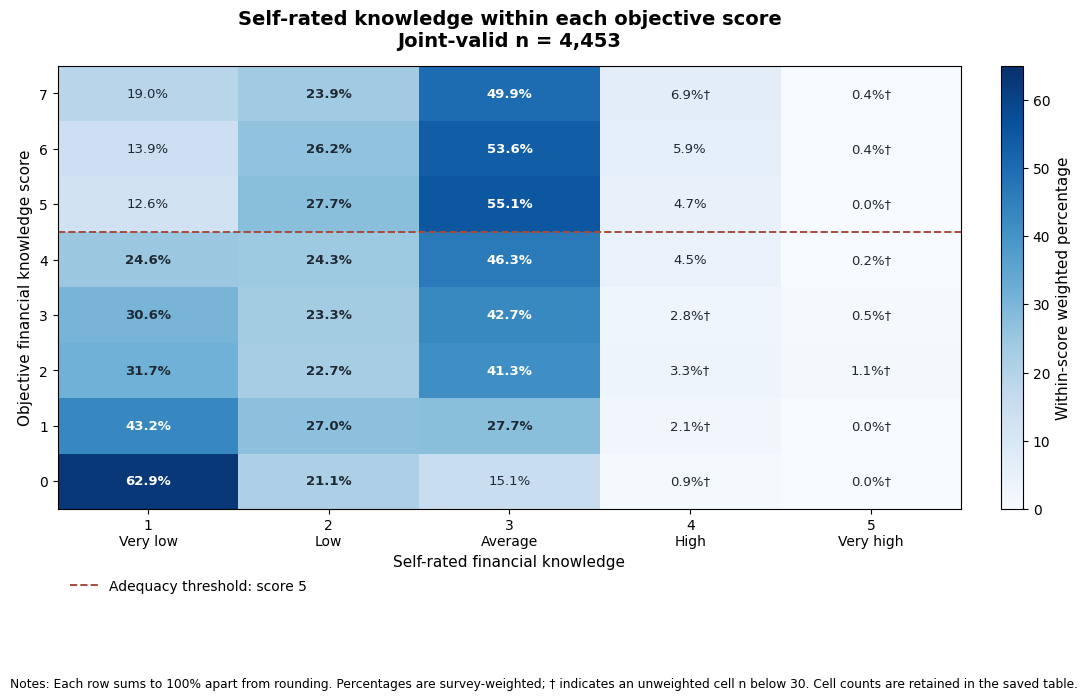

Module 3.6 calibration figure saved successfully.


In [ ]:
# ============================================================
# Part 3: full 8-by-5 calibration heatmap
# ============================================================

calibration_matrix = (
    knowledge_calibration
    .pivot(
        index="objective_score",
        columns="self_rating",
        values=(
            "within_score_weighted_percent"
        ),
    )
    .reindex(
        index=range(0, 8),
        columns=range(1, 6),
    )
)

small_cell_matrix = (
    knowledge_calibration
    .pivot(
        index="objective_score",
        columns="self_rating",
        values="small_cell_flag",
    )
    .reindex(
        index=range(0, 8),
        columns=range(1, 6),
    )
)

assert calibration_matrix.notna().all().all()
assert small_cell_matrix.notna().all().all()

colour_scale_maximum = float(
    np.ceil(
        calibration_matrix
        .to_numpy()
        .max()
        / 5
    )
    * 5
)

with plt.rc_context(
    {
        "font.size": 10,
        "axes.titlesize": 14,
        "axes.labelsize": 11,
    }
):
    calibration_figure, calibration_axis = (
        plt.subplots(
            figsize=(11.5, 7.2)
        )
    )

    heatmap = calibration_axis.imshow(
        calibration_matrix.to_numpy(),
        origin="lower",
        aspect="auto",
        cmap="Blues",
        vmin=0,
        vmax=colour_scale_maximum,
    )

    calibration_axis.set_xticks(
        np.arange(5)
    )

    calibration_axis.set_xticklabels(
        [
            "1\nVery low",
            "2\nLow",
            "3\nAverage",
            "4\nHigh",
            "5\nVery high",
        ]
    )

    calibration_axis.set_yticks(
        np.arange(8)
    )

    calibration_axis.set_yticklabels(
        range(0, 8)
    )

    calibration_axis.set_xlabel(
        "Self-rated financial knowledge"
    )

    calibration_axis.set_ylabel(
        "Objective financial knowledge score"
    )

    calibration_axis.set_title(
        "Self-rated knowledge within each "
        "objective score\n"
        f"Joint-valid n = "
        f"{int(joint_knowledge_mask.sum()):,}",
        fontweight="semibold",
        pad=14,
    )

    for score_index in range(8):
        for rating_index in range(5):
            percentage = float(
                calibration_matrix.iloc[
                    score_index,
                    rating_index,
                ]
            )

            small_cell = bool(
                small_cell_matrix.iloc[
                    score_index,
                    rating_index,
                ]
            )

            annotation = (
                f"{percentage:.1f}%"
            )

            if small_cell:
                annotation += "†"

            text_colour = (
                "white"
                if percentage
                >= 0.52
                * colour_scale_maximum
                else "#1F2933"
            )

            calibration_axis.text(
                rating_index,
                score_index,
                annotation,
                ha="center",
                va="center",
                color=text_colour,
                fontsize=9.5,
                fontweight=(
                    "semibold"
                    if percentage >= 20
                    else "normal"
                ),
            )

    calibration_axis.axhline(
        4.5,
        color="#A64B3C",
        linestyle="--",
        linewidth=1.4,
    )

    calibration_axis.legend(
        handles=[
            Line2D(
                [0],
                [0],
                color="#A64B3C",
                linestyle="--",
                linewidth=1.4,
                label=(
                    "Adequacy threshold: "
                    "score 5"
                ),
            )
        ],
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(0, -0.13),
    )

    colour_bar = (
        calibration_figure.colorbar(
            heatmap,
            ax=calibration_axis,
            fraction=0.046,
            pad=0.04,
        )
    )

    colour_bar.set_label(
        "Within-score weighted percentage"
    )

    calibration_figure.text(
        0.5,
        0.018,
        (
            "Notes: Each row sums to 100% apart "
            "from rounding. Percentages are "
            "survey-weighted; † indicates an "
            "unweighted cell n below 30. Cell "
            "counts are retained in the saved "
            "table."
        ),
        ha="center",
        fontsize=8.8,
        wrap=True,
    )

    calibration_figure.tight_layout(
        rect=(0.03, 0.10, 0.98, 0.98)
    )

calibration_png_path = (
    figures_directory
    / "module_3_6_knowledge_calibration.png"
)

calibration_pdf_path = (
    figures_directory
    / "module_3_6_knowledge_calibration.pdf"
)

calibration_figure.savefig(
    calibration_png_path,
    dpi=300,
    bbox_inches="tight",
)

calibration_figure.savefig(
    calibration_pdf_path,
    bbox_inches="tight",
)

plt.show()

assert calibration_png_path.exists()
assert calibration_png_path.stat().st_size > 0

assert calibration_pdf_path.exists()
assert calibration_pdf_path.stat().st_size > 0

print(
    "Module 3.6 calibration figure "
    "saved successfully."
)

In [ ]:
# ============================================================
# Part 4: unadjusted outcome prevalence across
# six profiles
# ============================================================

objective_group_code = pd.Series(
    pd.NA,
    index=calibration_df.index,
    dtype="string",
)

objective_group_code.loc[
    joint_knowledge_mask
    & objective_score.lt(5)
] = "below_target"

objective_group_code.loc[
    joint_knowledge_mask
    & objective_score.ge(5)
] = "meets_target"

self_rating_tier_code = pd.Series(
    pd.NA,
    index=calibration_df.index,
    dtype="string",
)

self_rating_tier_code.loc[
    joint_knowledge_mask
    & self_rating.le(2)
] = "below_average"

self_rating_tier_code.loc[
    joint_knowledge_mask
    & self_rating.eq(3)
] = "average"

self_rating_tier_code.loc[
    joint_knowledge_mask
    & self_rating.ge(4)
] = "high"

assert objective_group_code.loc[
    joint_knowledge_mask
].notna().all()

assert self_rating_tier_code.loc[
    joint_knowledge_mask
].notna().all()

profile_specifications = [
    {
        "profile_order": 1,
        "objective_group_code": (
            "below_target"
        ),
        "objective_group_label": (
            "Below adequacy target "
            "(score < 5)"
        ),
        "self_rating_tier_code": (
            "below_average"
        ),
        "self_rating_tier_label": (
            "Below average (ratings 1–2)"
        ),
        "profile_label": (
            "Below target / below average"
        ),
    },
    {
        "profile_order": 2,
        "objective_group_code": (
            "below_target"
        ),
        "objective_group_label": (
            "Below adequacy target "
            "(score < 5)"
        ),
        "self_rating_tier_code": "average",
        "self_rating_tier_label": (
            "Average (rating 3)"
        ),
        "profile_label": (
            "Below target / average"
        ),
    },
    {
        "profile_order": 3,
        "objective_group_code": (
            "below_target"
        ),
        "objective_group_label": (
            "Below adequacy target "
            "(score < 5)"
        ),
        "self_rating_tier_code": "high",
        "self_rating_tier_label": (
            "High or very high "
            "(ratings 4–5)"
        ),
        "profile_label": (
            "Below target / "
            "high or very high"
        ),
    },
    {
        "profile_order": 4,
        "objective_group_code": (
            "meets_target"
        ),
        "objective_group_label": (
            "Meets adequacy target "
            "(score >= 5)"
        ),
        "self_rating_tier_code": (
            "below_average"
        ),
        "self_rating_tier_label": (
            "Below average (ratings 1–2)"
        ),
        "profile_label": (
            "Meets target / below average"
        ),
    },
    {
        "profile_order": 5,
        "objective_group_code": (
            "meets_target"
        ),
        "objective_group_label": (
            "Meets adequacy target "
            "(score >= 5)"
        ),
        "self_rating_tier_code": "average",
        "self_rating_tier_label": (
            "Average (rating 3)"
        ),
        "profile_label": (
            "Meets target / average"
        ),
    },
    {
        "profile_order": 6,
        "objective_group_code": (
            "meets_target"
        ),
        "objective_group_label": (
            "Meets adequacy target "
            "(score >= 5)"
        ),
        "self_rating_tier_code": "high",
        "self_rating_tier_label": (
            "High or very high "
            "(ratings 4–5)"
        ),
        "profile_label": (
            "Meets target / "
            "high or very high"
        ),
    },
]

outcome_specifications = [
    {
        "outcome_order": 1,
        "outcome": (
            "financial_incident_any"
        ),
        "outcome_label": (
            "Reported at least one "
            "financial incident"
        ),
        "panel_title": (
            "Financial incident "
            "(1 = adverse)"
        ),
        "analysis_role": (
            "Primary outcome"
        ),
    },
    {
        "outcome_order": 2,
        "outcome": (
            "careful_before_purchase"
        ),
        "outcome_label": (
            "Carefully considers "
            "affordability"
        ),
        "panel_title": (
            "Careful purchase "
            "(1 = prudent)"
        ),
        "analysis_role": (
            "Primary outcome"
        ),
    },
    {
        "outcome_order": 3,
        "outcome": (
            "sets_long_term_goals"
        ),
        "outcome_label": (
            "Sets and pursues long-term "
            "financial goals"
        ),
        "panel_title": (
            "Long-term goals "
            "(1 = prudent)"
        ),
        "analysis_role": (
            "Primary outcome"
        ),
    },
    {
        "outcome_order": 4,
        "outcome": "shopped_around",
        "outcome_label": (
            "Compared options before "
            "choosing a product"
        ),
        "panel_title": (
            "Compared options "
            "(1 = prudent; secondary)"
        ),
        "analysis_role": (
            "Secondary eligible-subset "
            "outcome"
        ),
    },
]

expected_profile_analysis_n = {
    "financial_incident_any": 4204,
    "careful_before_purchase": 4276,
    "sets_long_term_goals": 4080,
    "shopped_around": 1056,
}

outcome_profile_rows = []

for outcome_specification in (
    outcome_specifications
):
    variable = outcome_specification[
        "outcome"
    ]

    values = outcome_series[variable]

    analysis_mask = (
        joint_knowledge_mask
        & values.notna()
    )

    analysis_n = int(
        analysis_mask.sum()
    )

    analysis_weight = float(
        weights.loc[
            analysis_mask
        ].sum()
    )

    overall_outcome_1_n = int(
        (
            analysis_mask
            & values.eq(1).fillna(False)
        ).sum()
    )

    overall_weighted_percent_1 = float(
        100
        * weights.loc[
            analysis_mask
            & values.eq(1).fillna(False)
        ].sum()
        / analysis_weight
    )

    assert (
        analysis_n
        == expected_profile_analysis_n[
            variable
        ]
    )

    assert analysis_weight > 0

    for profile_specification in (
        profile_specifications
    ):
        profile_mask = (
            analysis_mask
            & objective_group_code.eq(
                profile_specification[
                    "objective_group_code"
                ]
            ).fillna(False)
            & self_rating_tier_code.eq(
                profile_specification[
                    "self_rating_tier_code"
                ]
            ).fillna(False)
        )

        cell_n = int(
            profile_mask.sum()
        )

        outcome_1_mask = (
            profile_mask
            & values.eq(1).fillna(False)
        )

        outcome_0_mask = (
            profile_mask
            & values.eq(0).fillna(False)
        )

        outcome_1_n = int(
            outcome_1_mask.sum()
        )

        outcome_0_n = int(
            outcome_0_mask.sum()
        )

        weighted_denominator = float(
            weights.loc[
                profile_mask
            ].sum()
        )

        weighted_percent_1 = float(
            100
            * weights.loc[
                outcome_1_mask
            ].sum()
            / weighted_denominator
        )

        assert cell_n > 0
        assert weighted_denominator > 0

        assert (
            outcome_1_n
            + outcome_0_n
            == cell_n
        )

        sparse_reasons = []

        if cell_n < 50:
            sparse_reasons.append(
                "Profile denominator n < 50"
            )

        if min(
            outcome_1_n,
            outcome_0_n,
        ) < 30:
            sparse_reasons.append(
                "One binary outcome count n < 30"
            )

        outcome_profile_rows.append(
            {
                "outcome_order": (
                    outcome_specification[
                        "outcome_order"
                    ]
                ),
                "outcome": variable,
                "outcome_label": (
                    outcome_specification[
                        "outcome_label"
                    ]
                ),
                "panel_title": (
                    outcome_specification[
                        "panel_title"
                    ]
                ),
                "analysis_role": (
                    outcome_specification[
                        "analysis_role"
                    ]
                ),
                **profile_specification,
                "cell_unweighted_n": cell_n,
                "outcome_1_unweighted_n": (
                    outcome_1_n
                ),
                "outcome_0_unweighted_n": (
                    outcome_0_n
                ),
                "analysis_valid_unweighted_n": (
                    analysis_n
                ),
                "weighted_denominator": (
                    weighted_denominator
                ),
                "weighted_percent_1": (
                    weighted_percent_1
                ),
                "overall_outcome_1_unweighted_n": (
                    overall_outcome_1_n
                ),
                "overall_weighted_percent_1": (
                    overall_weighted_percent_1
                ),
                "difference_from_overall_pp": (
                    weighted_percent_1
                    - overall_weighted_percent_1
                ),
                "sparse_cell_flag": bool(
                    sparse_reasons
                ),
                "sparse_cell_reason": (
                    "; ".join(
                        sparse_reasons
                    )
                    if sparse_reasons
                    else "No"
                ),
            }
        )

unadjusted_outcome_profiles = (
    pd.DataFrame(
        outcome_profile_rows
    )
    .sort_values(
        [
            "outcome_order",
            "profile_order",
        ]
    )
    .reset_index(drop=True)
)

assert (
    unadjusted_outcome_profiles.shape[0]
    == 24
)

for outcome_specification in (
    outcome_specifications
):
    variable = outcome_specification[
        "outcome"
    ]

    outcome_table = (
        unadjusted_outcome_profiles.loc[
            unadjusted_outcome_profiles[
                "outcome"
            ].eq(variable)
        ]
    )

    assert outcome_table[
        "profile_order"
    ].tolist() == [1, 2, 3, 4, 5, 6]

    assert int(
        outcome_table[
            "cell_unweighted_n"
        ].sum()
    ) == expected_profile_analysis_n[
        variable
    ]

    assert int(
        outcome_table[
            "outcome_1_unweighted_n"
        ].sum()
    ) == int(
        outcome_table[
            "overall_outcome_1_unweighted_n"
        ].iloc[0]
    )

    reconstructed_overall = float(
        np.average(
            outcome_table[
                "weighted_percent_1"
            ],
            weights=outcome_table[
                "weighted_denominator"
            ],
        )
    )

    assert np.isclose(
        reconstructed_overall,
        outcome_table[
            "overall_weighted_percent_1"
        ].iloc[0],
        atol=1e-10,
    )

unadjusted_outcome_profiles_display = (
    unadjusted_outcome_profiles.copy()
)

for column in [
    "weighted_percent_1",
    "overall_weighted_percent_1",
    "difference_from_overall_pp",
]:
    unadjusted_outcome_profiles_display[
        column
    ] = unadjusted_outcome_profiles_display[
        column
    ].round(1)

display(
    unadjusted_outcome_profiles_display[
        [
            "outcome_label",
            "profile_label",
            "outcome_1_unweighted_n",
            "cell_unweighted_n",
            "analysis_valid_unweighted_n",
            "weighted_percent_1",
            "overall_weighted_percent_1",
            "difference_from_overall_pp",
            "sparse_cell_flag",
            "sparse_cell_reason",
        ]
    ]
)

print(
    "Unadjusted six-profile outcome "
    "checks passed."
)

,outcome_label,profile_label,outcome_1_unweighted_n,cell_unweighted_n,analysis_valid_unweighted_n,weighted_percent_1,overall_weighted_percent_1,difference_from_overall_pp,sparse_cell_flag,sparse_cell_reason
0,Reported at least one financial incident,Below target / below average,133,1158,4204,11.4,14.8,-3.5,False,No
1,Reported at least one financial incident,Below target / average,202,961,4204,21.9,14.8,7.1,False,No
2,Reported at least one financial incident,Below target / high or very high,26,97,4204,26.8,14.8,12.0,True,One binary outcome count n < 30
3,Reported at least one financial incident,Meets target / below average,115,722,4204,13.3,14.8,-1.5,False,No
4,Reported at least one financial incident,Meets target / average,146,1148,4204,12.7,14.8,-2.1,False,No
5,Reported at least one financial incident,Meets target / high or very high,26,118,4204,20.5,14.8,5.6,True,One binary outcome count n < 30
6,Carefully considers affordability,Below target / below average,586,1139,4276,53.0,49.1,4.0,False,No
7,Carefully considers affordability,Below target / average,360,1051,4276,36.2,49.1,-12.9,False,No
8,Carefully considers affordability,Below target / high or very high,35,103,4276,36.0,49.1,-13.1,False,No
9,Carefully considers affordability,Meets target / below average,445,713,4276,61.2,49.1,12.1,False,No


Unadjusted six-profile outcome checks passed.


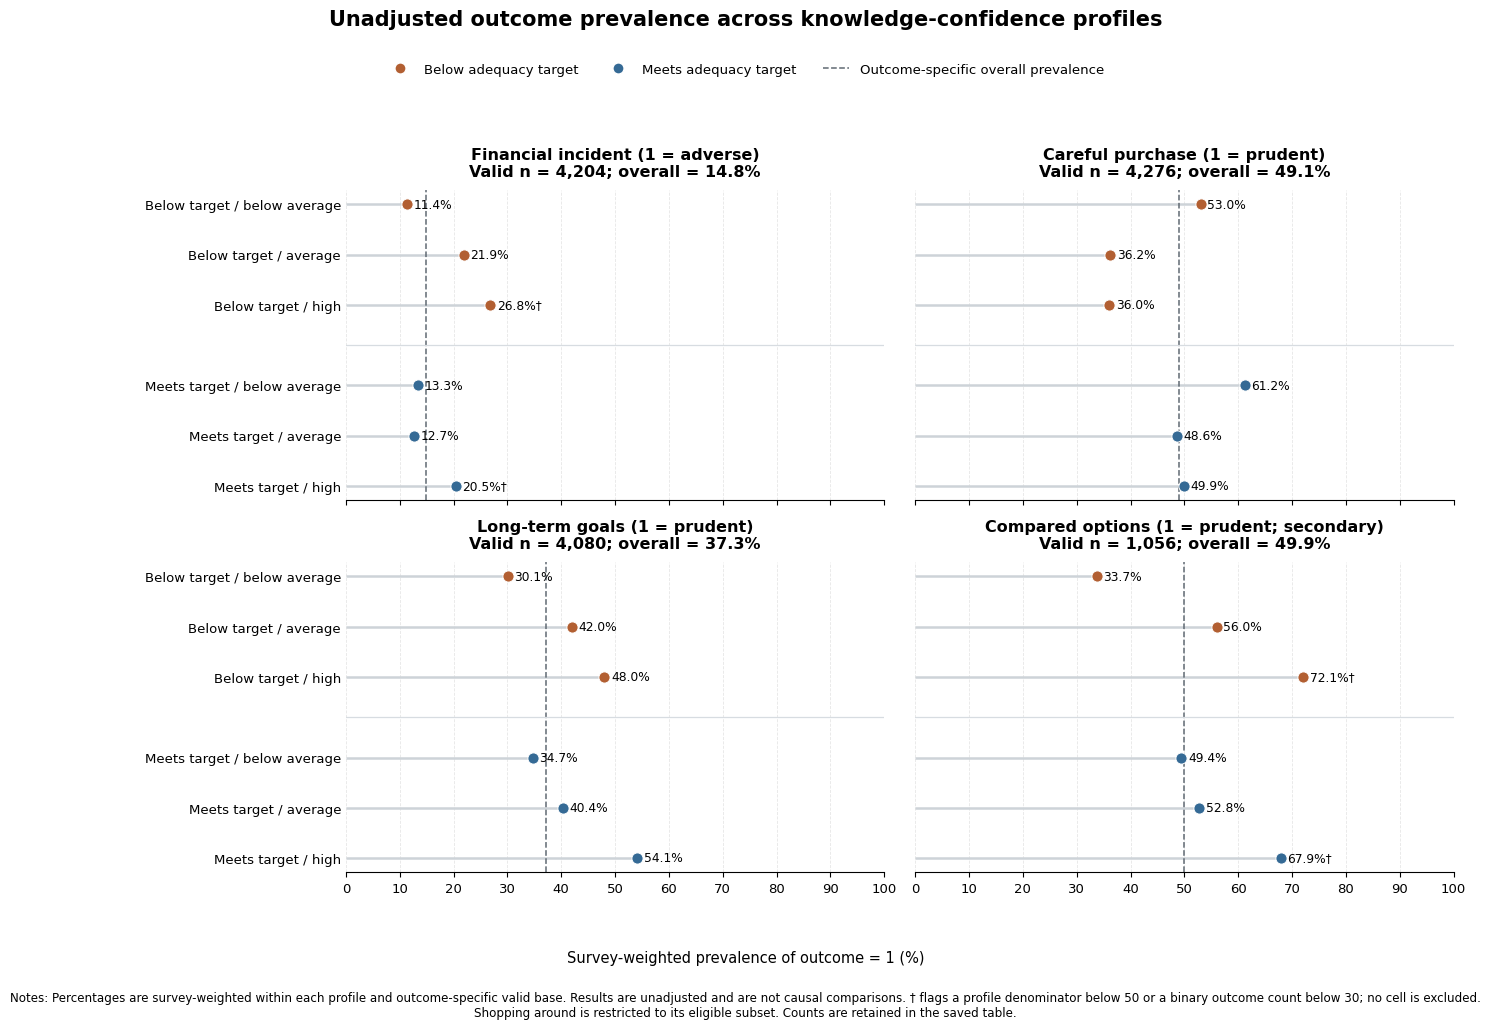

Module 3.6 outcome-profile figure saved successfully.


In [ ]:
# ============================================================
# Part 5: coordinated four-panel
# outcome-profile figure
# ============================================================

profile_plot_labels = [
    "Below target / below average",
    "Below target / average",
    "Below target / high",
    "Meets target / below average",
    "Meets target / average",
    "Meets target / high",
]

profile_y_positions = np.array(
    [5.4, 4.4, 3.4, 1.8, 0.8, -0.2]
)

with plt.rc_context(
    {
        "font.size": 9.5,
        "axes.titlesize": 11.5,
        "axes.labelsize": 10,
    }
):
    outcome_figure, outcome_axes = (
        plt.subplots(
            nrows=2,
            ncols=2,
            figsize=(15, 10.5),
            sharex=True,
            sharey=True,
        )
    )

    outcome_axes = (
        outcome_axes.flatten()
    )

    for axis, outcome_specification in zip(
        outcome_axes,
        outcome_specifications,
    ):
        variable = outcome_specification[
            "outcome"
        ]

        panel_table = (
            unadjusted_outcome_profiles.loc[
                unadjusted_outcome_profiles[
                    "outcome"
                ].eq(variable)
            ]
            .sort_values("profile_order")
            .reset_index(drop=True)
        )

        overall_percentage = float(
            panel_table[
                "overall_weighted_percent_1"
            ].iloc[0]
        )

        valid_n = int(
            panel_table[
                "analysis_valid_unweighted_n"
            ].iloc[0]
        )

        for row_index, row in (
            panel_table.iterrows()
        ):
            y_position = (
                profile_y_positions[
                    row_index
                ]
            )

            percentage = float(
                row["weighted_percent_1"]
            )

            objective_code = row[
                "objective_group_code"
            ]

            point_colour = (
                "#B25F32"
                if objective_code
                == "below_target"
                else "#356A95"
            )

            axis.hlines(
                y=y_position,
                xmin=0,
                xmax=percentage,
                color="#CDD3D8",
                linewidth=1.8,
                zorder=1,
            )

            axis.scatter(
                percentage,
                y_position,
                s=65,
                color=point_colour,
                edgecolor="white",
                linewidth=0.7,
                zorder=3,
            )

            annotation = (
                f"{percentage:.1f}%"
            )

            if bool(
                row["sparse_cell_flag"]
            ):
                annotation += "†"

            axis.text(
                percentage + 1.2,
                y_position,
                annotation,
                ha="left",
                va="center",
                fontsize=8.8,
            )

        axis.axvline(
            overall_percentage,
            color="#606A73",
            linestyle="--",
            linewidth=1.1,
        )

        axis.axhline(
            2.6,
            color="#D7DCE1",
            linewidth=0.9,
        )

        axis.set_title(
            f"{outcome_specification['panel_title']}\n"
            f"Valid n = {valid_n:,}; "
            f"overall = "
            f"{overall_percentage:.1f}%",
            fontweight="semibold",
            pad=10,
        )

        axis.set_xlim(0, 100)

        axis.set_xticks(
            np.arange(0, 101, 10)
        )

        axis.set_yticks(
            profile_y_positions
        )

        axis.set_yticklabels(
            profile_plot_labels
        )

        axis.set_axisbelow(True)

        axis.xaxis.grid(
            True,
            linestyle="--",
            linewidth=0.6,
            alpha=0.30,
        )

        axis.yaxis.grid(False)

        axis.tick_params(
            axis="y",
            length=0,
        )

        for spine in [
            "top",
            "right",
            "left",
        ]:
            axis.spines[
                spine
            ].set_visible(False)

    outcome_figure.suptitle(
        "Unadjusted outcome prevalence across "
        "knowledge-confidence profiles",
        fontsize=15,
        fontweight="semibold",
        y=0.975,
    )

    outcome_figure.supxlabel(
        "Survey-weighted prevalence "
        "of outcome = 1 (%)",
        fontsize=10.5,
        y=0.065,
    )

    outcome_figure.legend(
        handles=[
            Line2D(
                [0],
                [0],
                marker="o",
                color="none",
                markerfacecolor="#B25F32",
                markeredgecolor="white",
                markersize=8,
                label=(
                    "Below adequacy target"
                ),
            ),
            Line2D(
                [0],
                [0],
                marker="o",
                color="none",
                markerfacecolor="#356A95",
                markeredgecolor="white",
                markersize=8,
                label=(
                    "Meets adequacy target"
                ),
            ),
            Line2D(
                [0],
                [0],
                color="#606A73",
                linestyle="--",
                linewidth=1.1,
                label=(
                    "Outcome-specific "
                    "overall prevalence"
                ),
            ),
        ],
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.935),
        ncol=3,
    )

    outcome_figure.text(
        0.5,
        0.018,
        (
            "Notes: Percentages are survey-weighted "
            "within each profile and outcome-specific "
            "valid base. Results are unadjusted and "
            "are not causal comparisons. † flags a "
            "profile denominator below 50 or a binary "
            "outcome count below 30; no cell is "
            "excluded. Shopping around is restricted "
            "to its eligible subset. Counts are "
            "retained in the saved table."
        ),
        ha="center",
        fontsize=8.6,
        wrap=True,
    )

    outcome_figure.tight_layout(
        rect=(0.09, 0.09, 0.99, 0.89)
    )

outcome_profiles_png_path = (
    figures_directory
    / "module_3_6_unadjusted_outcome_profiles.png"
)

outcome_profiles_pdf_path = (
    figures_directory
    / "module_3_6_unadjusted_outcome_profiles.pdf"
)

outcome_figure.savefig(
    outcome_profiles_png_path,
    dpi=300,
    bbox_inches="tight",
)

outcome_figure.savefig(
    outcome_profiles_pdf_path,
    bbox_inches="tight",
)

plt.show()

assert outcome_profiles_png_path.exists()
assert (
    outcome_profiles_png_path.stat().st_size
    > 0
)

assert outcome_profiles_pdf_path.exists()
assert (
    outcome_profiles_pdf_path.stat().st_size
    > 0
)

print(
    "Module 3.6 outcome-profile figure "
    "saved successfully."
)

In [ ]:
# ============================================================
# Part 6: save and validate Module 3.6 outputs
# ============================================================

def assert_same_csv_values(
    reference,
    reloaded,
):
    """
    Compare values while allowing dtype changes
    introduced by CSV storage.
    """

    assert reference.shape == reloaded.shape

    assert list(
        reference.columns
    ) == list(
        reloaded.columns
    )

    for column in reference.columns:
        reference_series = (
            reference[column]
        )

        reloaded_series = (
            reloaded[column]
        )

        if pd.api.types.is_numeric_dtype(
            reference_series
        ):
            reference_values = (
                pd.to_numeric(
                    reference_series,
                    errors="coerce",
                )
                .astype("float64")
                .to_numpy()
            )

            reloaded_values = (
                pd.to_numeric(
                    reloaded_series,
                    errors="coerce",
                )
                .astype("float64")
                .to_numpy()
            )

            np.testing.assert_allclose(
                reference_values,
                reloaded_values,
                rtol=1e-12,
                atol=1e-12,
                equal_nan=True,
            )

        else:
            reference_values = (
                reference_series
                .astype("string")
                .fillna("<MISSING>")
                .tolist()
            )

            reloaded_values = (
                reloaded_series
                .astype("string")
                .fillna("<MISSING>")
                .tolist()
            )

            assert (
                reference_values
                == reloaded_values
            )


module_3_6_tables = {
    "module_3_6_knowledge_calibration.csv": (
        knowledge_calibration
    ),
    "module_3_6_alignment_summary.csv": (
        alignment_summary
    ),
    "module_3_6_unadjusted_outcome_profiles.csv": (
        unadjusted_outcome_profiles
    ),
}

module_3_6_figures = [
    calibration_png_path,
    calibration_pdf_path,
    outcome_profiles_png_path,
    outcome_profiles_pdf_path,
]

manifest_rows = []

for filename, table in (
    module_3_6_tables.items()
):
    output_path = (
        tables_directory
        / filename
    )

    table.to_csv(
        output_path,
        index=False,
        encoding="utf-8",
    )

    reloaded_table = pd.read_csv(
        output_path
    )

    assert_same_csv_values(
        table,
        reloaded_table,
    )

    manifest_rows.append(
        {
            "output_type": "Table",
            "filename": filename,
            "rows": table.shape[0],
            "columns": table.shape[1],
            "size_bytes": (
                output_path.stat().st_size
            ),
            "validation": "Passed",
        }
    )

for figure_path in module_3_6_figures:
    assert figure_path.exists()
    assert figure_path.stat().st_size > 0

    manifest_rows.append(
        {
            "output_type": "Figure",
            "filename": figure_path.name,
            "rows": None,
            "columns": None,
            "size_bytes": (
                figure_path.stat().st_size
            ),
            "validation": "Passed",
        }
    )

module_3_6_manifest = pd.DataFrame(
    manifest_rows
)

assert len(module_3_6_manifest) == 7

assert (
    module_3_6_manifest[
        "validation"
    ]
    .eq("Passed")
    .all()
)

manifest_path = (
    tables_directory
    / "module_3_6_output_manifest.csv"
)

module_3_6_manifest.to_csv(
    manifest_path,
    index=False,
    encoding="utf-8",
)

display(
    module_3_6_manifest
)

print(
    "Module 3.6 completed: calibration, "
    "rank association, and unadjusted "
    "outcome-profile outputs were saved "
    "and validated."
)

,output_type,filename,rows,columns,size_bytes,validation
0,Table,module_3_6_knowledge_calibration.csv,40.0,14.0,7305,Passed
1,Table,module_3_6_alignment_summary.csv,1.0,7.0,397,Passed
2,Table,module_3_6_unadjusted_outcome_profiles.csv,24.0,22.0,8668,Passed
3,Figure,module_3_6_knowledge_calibration.png,NaN,NaN,370744,Passed
4,Figure,module_3_6_knowledge_calibration.pdf,NaN,NaN,39466,Passed
5,Figure,module_3_6_unadjusted_outcome_profiles.png,NaN,NaN,595244,Passed
6,Figure,module_3_6_unadjusted_outcome_profiles.pdf,NaN,NaN,41334,Passed


Module 3.6 completed: calibration, rank association, and unadjusted outcome-profile outputs were saved and validated.


# Module 4 — Adjusted Profiling, Financial Outcomes, and Robustness

## 4.1 — Model Specification and Estimability Audit

This module freezes the multivariable model specifications and verifies their
analytical samples, focal-variable support, survey-weight dispersion, and
design-matrix estimability before any model is fitted.

The primary mismatch-profiling outcome is the Banca-aligned relative
overconfidence definition. The broader unrecognised adequacy gap is retained
as a threshold sensitivity under the core specification, while the strict
high-confidence mismatch remains a descriptive sparse sensitivity and is not
assigned a primary multivariable model.

Behavioural-outcome models use the centred objective-knowledge score, the
four-level self-rating variable, and their interaction. Core adjustment
includes age group, gender, education, and macro-region. Product holdings and
Internet access form an exposure-aware extension, while household income is
examined in a separate income-adjusted sensitivity branch.

Under the paired common-sample design, sample restrictions and adjustment terms are represented
separately. Each extended specification has a core-only anchor estimated on
the identical restricted sample:

1. the full core model is the main estimate;
2. the exposure-complete core anchor isolates the effect of restricting the
   sample to respondents with valid exposure covariates;
3. the exposure-aware model adds product holdings and Internet access on that
   same exposure-complete sample;
4. the income-complete core anchor isolates the effect of restricting the
   sample to respondents with valid income;
5. the income-adjusted model adds household income on that same
   income-complete sample.

Therefore, a full-core-to-anchor comparison reflects sample composition,
whereas an anchor-to-extended comparison reflects added adjustment on a
common sample. The anchors are technical comparators rather than additional
substantive hypotheses.

The resulting registry contains 26 specifications: five for the primary
Banca-aligned mismatch, one core threshold-sensitivity model, and five for
each of the four behavioural outcomes.

Survey weights will be normalised to mean one within each model-specific
sample when models are fitted. Weight-only Kish effective sample sizes are
reported only as weight-dispersion diagnostics. This module performs no model
fitting and no inferential testing.

In [ ]:
# ============================================================
# Module 4.1 — Model specification and estimability audit
# Part 1: load and validate the canonical checkpoint
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


checkpoint_path = (
    Path(PROJECT_ROOT)
    / "data"
    / "processed"
    / "iacofi_analytical_checkpoint.parquet"
)

tables_directory = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "tables"
)

tables_directory.mkdir(
    parents=True,
    exist_ok=True,
)


required_variables = [
    "respondent_id",
    "survey_weight",
    "objective_knowledge_score",
    "knowledge_target_met",
    "self_rated_knowledge",
    "self_rating_at_least_average",
    "confidence_trap_candidate",
    "financial_incident_any",
    "careful_before_purchase",
    "sets_long_term_goals",
    "shopped_around",
    "age_group",
    "gender",
    "education_group",
    "macro_region",
    "products_held_count",
    "internet_access",
    "household_income_group",
]

outcome_variables = [
    "financial_incident_any",
    "careful_before_purchase",
    "sets_long_term_goals",
    "shopped_around",
]


assert checkpoint_path.exists(), (
    f"Checkpoint not found: {checkpoint_path}"
)

model_source = pd.read_parquet(
    checkpoint_path,
    engine="pyarrow",
)

assert model_source.shape == (4862, 22)

missing_variables = sorted(
    set(required_variables)
    - set(model_source.columns)
)

assert not missing_variables, (
    "Missing Module 4.1 variables: "
    f"{missing_variables}"
)

assert model_source["respondent_id"].notna().all()
assert model_source["respondent_id"].is_unique

np.testing.assert_array_equal(
    model_source["respondent_id"].to_numpy(),
    np.arange(1, 4863),
)


def numeric_series(variable):
    return pd.to_numeric(
        model_source[variable],
        errors="coerce",
    )


weights = numeric_series(
    "survey_weight"
).astype(float)

objective_score = numeric_series(
    "objective_knowledge_score"
)

self_rating = numeric_series(
    "self_rated_knowledge"
)

objective_target = numeric_series(
    "knowledge_target_met"
)

self_rating_target = numeric_series(
    "self_rating_at_least_average"
)

legacy_broad_candidate = numeric_series(
    "confidence_trap_candidate"
)

products_held_count = numeric_series(
    "products_held_count"
)

internet_access = numeric_series(
    "internet_access"
)

outcome_series = {
    variable: numeric_series(variable)
    for variable in outcome_variables
}


assert weights.notna().all()
assert np.isfinite(weights).all()
assert weights.gt(0).all()

assert objective_score.notna().all()
assert objective_score.isin(range(0, 8)).all()

assert self_rating.dropna().isin(
    range(1, 6)
).all()


np.testing.assert_array_equal(
    objective_target.astype(int).to_numpy(),
    objective_score.ge(5).astype(int).to_numpy(),
)


self_rating_valid_mask = (
    self_rating.notna()
)

assert np.array_equal(
    self_rating_target.notna().to_numpy(),
    self_rating_valid_mask.to_numpy(),
)

assert np.array_equal(
    legacy_broad_candidate.notna().to_numpy(),
    self_rating_valid_mask.to_numpy(),
)


np.testing.assert_array_equal(
    self_rating_target.loc[
        self_rating_valid_mask
    ]
    .astype(int)
    .to_numpy(),
    self_rating.loc[
        self_rating_valid_mask
    ]
    .ge(3)
    .astype(int)
    .to_numpy(),
)

np.testing.assert_array_equal(
    legacy_broad_candidate.loc[
        self_rating_valid_mask
    ]
    .astype(int)
    .to_numpy(),
    (
        objective_score.loc[
            self_rating_valid_mask
        ].lt(5)
        & self_rating.loc[
            self_rating_valid_mask
        ].ge(3)
    )
    .astype(int)
    .to_numpy(),
)


expected_self_rating_counts = {
    1: 946,
    2: 1036,
    3: 2245,
    4: 214,
    5: 12,
}

observed_self_rating_counts = {
    rating: int(
        (
            self_rating_valid_mask
            & self_rating.eq(rating)
        ).sum()
    )
    for rating in range(1, 6)
}

assert (
    observed_self_rating_counts
    == expected_self_rating_counts
)

assert int(
    self_rating_valid_mask.sum()
) == 4453


expected_outcome_valid_n = {
    "financial_incident_any": 4531,
    "careful_before_purchase": 4554,
    "sets_long_term_goals": 4320,
    "shopped_around": 1082,
}

for variable, values in (
    outcome_series.items()
):
    assert values.dropna().isin([0, 1]).all()

    assert int(
        values.notna().sum()
    ) == expected_outcome_valid_n[variable]


source_age_group = (
    model_source["age_group"]
    .astype("string")
    .str.strip()
    .str.replace(
        "–",
        "-",
        regex=False,
    )
)

expected_source_age_counts = {
    "18-19": 131,
    "20-29": 436,
    "30-39": 880,
    "40-49": 880,
    "50-59": 958,
    "60-69": 841,
    "70-79": 736,
}

observed_source_age_counts = {
    category: int(
        source_age_group.eq(category).sum()
    )
    for category in expected_source_age_counts
}

assert (
    observed_source_age_counts
    == expected_source_age_counts
)


expected_categories = {
    "gender": {
        "Women",
        "Men",
    },
    "education_group": {
        "Lower secondary or less",
        "Upper secondary",
        "Tertiary",
    },
    "macro_region": {
        "North-West",
        "North-East",
        "Centre",
        "South",
        "Islands",
    },
}

for variable, categories in (
    expected_categories.items()
):
    values = (
        model_source[variable]
        .astype("string")
        .str.strip()
    )

    assert values.notna().all()
    assert set(values.unique()) == categories


assert int(
    products_held_count.notna().sum()
) == 4740

assert products_held_count.dropna().between(
    0,
    19,
).all()

assert int(
    internet_access.notna().sum()
) == 4842

assert internet_access.dropna().isin(
    [0, 1]
).all()

assert int(
    model_source[
        "household_income_group"
    ].notna().sum()
) == 3349


print(
    "Module 4.1 source validated successfully: "
    "all focal variables, outcomes, and covariates "
    "match the approved checkpoint definitions."
)

Module 4.1 source validated successfully: all focal variables, outcomes, and covariates match the approved checkpoint definitions.


In [ ]:
# ============================================================
# Module 4.1 — Model Specification and Estimability Audit
# Part 2: freeze model variables and mismatch definitions
# ============================================================

valid_weight_mask = (
    weights.notna()
    & np.isfinite(weights)
    & weights.gt(0)
)


objective_weighted_mean = float(
    np.average(
        objective_score.astype(float),
        weights=weights,
    )
)

banca_relative_cutoff = int(
    np.floor(
        objective_weighted_mean
    )
)


assert np.isclose(
    objective_weighted_mean,
    3.6941245412445065,
    atol=1e-9,
)

assert banca_relative_cutoff == 3


age_model_map = {
    "18-19": "18–29",
    "20-29": "18–29",
    "30-39": "30–49",
    "40-49": "30–49",
    "50-59": "50–69",
    "60-69": "50–69",
    "70-79": "70–79",
}

self_rating_model_map = {
    1: "Very low",
    2: "Low",
    3: "Average",
    4: "High or very high",
    5: "High or very high",
}

self_rating_source_labels = {
    1: "Very low",
    2: "Low",
    3: "Average",
    4: "High",
    5: "Very high",
}


products_valid_mask = (
    products_held_count.notna()
    & valid_weight_mask
)

products_weighted_mean = float(
    np.average(
        products_held_count.loc[
            products_valid_mask
        ].astype(float),
        weights=weights.loc[
            products_valid_mask
        ],
    )
)


def cleaned_string(variable):
    return (
        model_source[variable]
        .astype("string")
        .str.strip()
    )


model_df = pd.DataFrame(
    {
        "respondent_id": (
            model_source[
                "respondent_id"
            ].astype(int)
        ),
        "survey_weight": weights,
        "objective_knowledge_score": (
            objective_score.astype(float)
        ),
        "objective_score_centered": (
            objective_score.astype(float)
            - objective_weighted_mean
        ),
        "self_rated_knowledge": (
            self_rating
        ),
        "self_rating_model": (
            self_rating.map(
                self_rating_model_map
            )
        ),
        "age_model_group": (
            source_age_group.map(
                age_model_map
            )
        ),
        "gender": cleaned_string(
            "gender"
        ),
        "education_group": cleaned_string(
            "education_group"
        ),
        "macro_region": cleaned_string(
            "macro_region"
        ),
        "products_held_count": (
            products_held_count
        ),
        "products_held_centered": (
            products_held_count.astype(float)
            - products_weighted_mean
        ),
        "internet_access": (
            internet_access
        ),
        "household_income_group": (
            cleaned_string(
                "household_income_group"
            )
        ),
        **outcome_series,
    },
    index=model_source.index,
)


joint_focal_mask = (
    model_df[
        "objective_knowledge_score"
    ].notna()
    & model_df[
        "self_rated_knowledge"
    ].notna()
    & valid_weight_mask
)


def binary_with_missingness(
    valid_mask,
    positive_mask,
):
    """
    Return a 0/1 indicator only on its
    documented valid base.
    """

    result = pd.Series(
        np.nan,
        index=model_df.index,
        dtype="float64",
    )

    result.loc[valid_mask] = (
        positive_mask.loc[
            valid_mask
        ]
        .astype(int)
        .to_numpy()
    )

    return result


model_df[
    "unrecognised_adequacy_gap"
] = binary_with_missingness(
    joint_focal_mask,
    (
        model_df[
            "objective_knowledge_score"
        ].lt(5)
        & model_df[
            "self_rated_knowledge"
        ].ge(3)
    ),
)

model_df[
    "banca_aligned_relative_overconfidence"
] = binary_with_missingness(
    joint_focal_mask,
    (
        model_df[
            "objective_knowledge_score"
        ].le(
            banca_relative_cutoff
        )
        & model_df[
            "self_rated_knowledge"
        ].ge(3)
    ),
)

model_df[
    "strict_high_confidence_mismatch"
] = binary_with_missingness(
    joint_focal_mask,
    (
        model_df[
            "objective_knowledge_score"
        ].lt(5)
        & model_df[
            "self_rated_knowledge"
        ].ge(4)
    ),
)


mismatch_specs = [
    {
        "measure_order": 1,
        "measure": (
            "banca_aligned_relative_overconfidence"
        ),
        "measure_label": (
            "Banca-aligned relative overconfidence"
        ),
        "analysis_role": (
            "Primary adjusted profiling outcome"
        ),
        "definition": (
            "Objective score <= weighted national mean "
            "integer cutoff (score <= 3) and "
            "self-rating >= 3"
        ),
        "planned_use": (
            "Primary adjusted demographic profiling"
        ),
    },
    {
        "measure_order": 2,
        "measure": (
            "unrecognised_adequacy_gap"
        ),
        "measure_label": (
            "Unrecognised adequacy gap"
        ),
        "analysis_role": (
            "Threshold sensitivity outcome"
        ),
        "definition": (
            "Objective score < 5 and self-rating >= 3"
        ),
        "planned_use": (
            "Sensitivity analysis; not labelled "
            "as overconfidence"
        ),
    },
    {
        "measure_order": 3,
        "measure": (
            "strict_high_confidence_mismatch"
        ),
        "measure_label": (
            "Strict high-confidence mismatch"
        ),
        "analysis_role": (
            "Descriptive sparse sensitivity"
        ),
        "definition": (
            "Objective score < 5 and self-rating >= 4"
        ),
        "planned_use": (
            "Descriptive benchmark; no primary "
            "multivariable model"
        ),
    },
]


mismatch_rows = []

for specification in mismatch_specs:
    variable = specification["measure"]

    valid_mask = (
        model_df[variable].notna()
        & valid_weight_mask
    )

    positive_mask = (
        valid_mask
        & model_df[variable].eq(1)
    )

    mismatch_rows.append(
        {
            **specification,
            "valid_unweighted_n": int(
                valid_mask.sum()
            ),
            "positive_unweighted_n": int(
                positive_mask.sum()
            ),
            "weighted_percent": float(
                100
                * weights.loc[
                    positive_mask
                ].sum()
                / weights.loc[
                    valid_mask
                ].sum()
            ),
        }
    )


mismatch_definition_registry = (
    pd.DataFrame(
        mismatch_rows
    )
    .sort_values(
        "measure_order"
    )
    .reset_index(drop=True)
)


expected_mismatch_results = {
    "banca_aligned_relative_overconfidence": (
        712,
        15.1,
    ),
    "unrecognised_adequacy_gap": (
        1184,
        24.9,
    ),
    "strict_high_confidence_mismatch": (
        106,
        2.1,
    ),
}

for variable, (
    expected_n,
    expected_percent,
) in expected_mismatch_results.items():
    observed = (
        mismatch_definition_registry.loc[
            mismatch_definition_registry[
                "measure"
            ].eq(variable)
        ]
        .iloc[0]
    )

    assert int(
        observed[
            "valid_unweighted_n"
        ]
    ) == 4453

    assert int(
        observed[
            "positive_unweighted_n"
        ]
    ) == expected_n

    assert round(
        float(
            observed[
                "weighted_percent"
            ]
        ),
        1,
    ) == expected_percent


focal_support_rows = []

for source_code in range(1, 6):
    source_mask = (
        joint_focal_mask
        & model_df[
            "self_rated_knowledge"
        ].eq(source_code)
    )

    model_level = (
        self_rating_model_map[
            source_code
        ]
    )

    model_level_mask = (
        joint_focal_mask
        & model_df[
            "self_rating_model"
        ].eq(model_level)
    )

    score_cell_counts = [
        int(
            (
                model_level_mask
                & model_df[
                    "objective_knowledge_score"
                ].eq(score)
            ).sum()
        )
        for score in range(0, 8)
    ]

    focal_support_rows.append(
        {
            "source_rating_code": (
                source_code
            ),
            "source_rating_label": (
                self_rating_source_labels[
                    source_code
                ]
            ),
            "model_rating_level": (
                model_level
            ),
            "source_unweighted_n": int(
                source_mask.sum()
            ),
            "source_weighted_percent": float(
                100
                * weights.loc[
                    source_mask
                ].sum()
                / weights.loc[
                    joint_focal_mask
                ].sum()
            ),
            "source_category_below_30": (
                int(source_mask.sum()) < 30
            ),
            "model_level_unweighted_n": int(
                model_level_mask.sum()
            ),
            "model_level_score_minimum": int(
                model_df.loc[
                    model_level_mask,
                    "objective_knowledge_score",
                ].min()
            ),
            "model_level_score_maximum": int(
                model_df.loc[
                    model_level_mask,
                    "objective_knowledge_score",
                ].max()
            ),
            "model_level_observed_score_values": int(
                model_df.loc[
                    model_level_mask,
                    "objective_knowledge_score",
                ].nunique()
            ),
            "minimum_score_cell_unweighted_n": (
                min(score_cell_counts)
            ),
            "score_cells_below_30": int(
                sum(
                    count < 30
                    for count in score_cell_counts
                )
            ),
        }
    )


focal_coding_support = (
    pd.DataFrame(
        focal_support_rows
    )
    .sort_values(
        "source_rating_code"
    )
    .reset_index(drop=True)
)


assert focal_coding_support[
    "source_unweighted_n"
].tolist() == [
    946,
    1036,
    2245,
    214,
    12,
]

assert (
    focal_coding_support.loc[
        focal_coding_support[
            "source_rating_code"
        ].isin([4, 5]),
        "model_level_unweighted_n",
    ]
    .eq(226)
    .all()
)

assert (
    focal_coding_support[
        "model_level_observed_score_values"
    ]
    .eq(8)
    .all()
)


mismatch_display = (
    mismatch_definition_registry.copy()
)

mismatch_display[
    "weighted_percent"
] = mismatch_display[
    "weighted_percent"
].round(1)

focal_support_display = (
    focal_coding_support.copy()
)

focal_support_display[
    "source_weighted_percent"
] = focal_support_display[
    "source_weighted_percent"
].round(1)


display(
    mismatch_display[
        [
            "measure_label",
            "analysis_role",
            "positive_unweighted_n",
            "valid_unweighted_n",
            "weighted_percent",
            "planned_use",
        ]
    ]
)

display(
    focal_support_display
)

print(
    "Frozen mismatch definitions and four-level "
    "model coding validated successfully."
)

,measure_label,analysis_role,positive_unweighted_n,valid_unweighted_n,weighted_percent,planned_use
0,Banca-aligned relative overconfidence,Primary adjusted profiling outcome,712,4453,15.1,Primary adjusted demographic profiling
1,Unrecognised adequacy gap,Threshold sensitivity outcome,1184,4453,24.9,Sensitivity analysis; not labelled as overconf...
2,Strict high-confidence mismatch,Descriptive sparse sensitivity,106,4453,2.1,Descriptive benchmark; no primary multivariabl...


,source_rating_code,source_rating_label,model_rating_level,source_unweighted_n,source_weighted_percent,source_category_below_30,model_level_unweighted_n,model_level_score_minimum,model_level_score_maximum,model_level_observed_score_values,minimum_score_cell_unweighted_n,score_cells_below_30
0,1,Very low,Very low,946,25.4,False,946,0,7,8,59,0
1,2,Low,Low,1036,24.9,False,1036,0,7,8,37,0
2,3,Average,Average,2245,45.2,False,2245,0,7,8,39,0
3,4,High,High or very high,214,4.1,False,226,0,7,8,3,3
4,5,Very high,High or very high,12,0.3,True,226,0,7,8,3,3


Frozen mismatch definitions and four-level model coding validated successfully.


In [ ]:
# ============================================================
# Part 3: register model scenarios and audit analytical samples
# ============================================================

core_covariate_text = (
    "age_model_group + gender + education_group + macro_region"
)
outcome_focal_text = (
    "objective_score_centered * self_rating_model"
)

model_scenarios = [
    {
        "scenario_order": 1,
        "scenario_code": "full_core",
        "scenario_label": "Full core model",
        "sample_basis": "core",
        "adjustment_specification": "core",
        "comparison_pair": "Primary core estimate",
        "technical_role": "Primary specification",
        "additional_terms": "No additional terms",
        "sample_rule": (
            "Valid dependent variable, focal variables, weight, and "
            "core demographic covariates"
        ),
    },
    {
        "scenario_order": 2,
        "scenario_code": "exposure_complete_anchor",
        "scenario_label": "Exposure-complete core anchor",
        "sample_basis": "exposure_complete",
        "adjustment_specification": "core",
        "comparison_pair": "Exposure common-sample comparison",
        "technical_role": "Restricted-sample anchor",
        "additional_terms": "No additional terms",
        "sample_rule": (
            "Core requirements plus valid products held and Internet"
        ),
    },
    {
        "scenario_order": 3,
        "scenario_code": "exposure_aware",
        "scenario_label": "Exposure-aware model",
        "sample_basis": "exposure_complete",
        "adjustment_specification": "exposure_aware",
        "comparison_pair": "Exposure common-sample comparison",
        "technical_role": "Extended adjustment",
        "additional_terms": (
            "products_held_centered + internet_access"
        ),
        "sample_rule": (
            "Core requirements plus valid products held and Internet"
        ),
    },
    {
        "scenario_order": 4,
        "scenario_code": "income_complete_anchor",
        "scenario_label": "Income-complete core anchor",
        "sample_basis": "income_complete",
        "adjustment_specification": "core",
        "comparison_pair": "Income common-sample comparison",
        "technical_role": "Restricted-sample anchor",
        "additional_terms": "No additional terms",
        "sample_rule": (
            "Core requirements plus valid household income"
        ),
    },
    {
        "scenario_order": 5,
        "scenario_code": "income_adjusted",
        "scenario_label": "Income-adjusted model",
        "sample_basis": "income_complete",
        "adjustment_specification": "income_adjusted",
        "comparison_pair": "Income common-sample comparison",
        "technical_role": "Extended adjustment",
        "additional_terms": "household_income_group",
        "sample_rule": (
            "Core requirements plus valid household income"
        ),
    },
]

outcome_specifications = [
    {
        "outcome_order": 1,
        "dependent_variable": "financial_incident_any",
        "dependent_label": "Reported at least one financial incident",
        "analysis_role": "Primary outcome",
        "outcome_1_meaning": "Adverse event",
        "question_universe": "Full respondent sample",
    },
    {
        "outcome_order": 2,
        "dependent_variable": "careful_before_purchase",
        "dependent_label": "Carefully considers affordability",
        "analysis_role": "Primary outcome",
        "outcome_1_meaning": "Prudent behaviour",
        "question_universe": "Full respondent sample",
    },
    {
        "outcome_order": 3,
        "dependent_variable": "sets_long_term_goals",
        "dependent_label": (
            "Sets and pursues long-term financial goals"
        ),
        "analysis_role": "Primary outcome",
        "outcome_1_meaning": "Prudent behaviour",
        "question_universe": "Full respondent sample",
    },
    {
        "outcome_order": 4,
        "dependent_variable": "shopped_around",
        "dependent_label": (
            "Compared options before choosing a product"
        ),
        "analysis_role": "Secondary outcome",
        "outcome_1_meaning": "Prudent behaviour",
        "question_universe": "Recent product choosers only",
    },
]


def model_terms(
    model_family,
    adjustment_specification,
):
    terms = core_covariate_text

    if adjustment_specification == "exposure_aware":
        terms += (
            " + products_held_centered + internet_access"
        )
    elif adjustment_specification == "income_adjusted":
        terms += " + household_income_group"
    elif adjustment_specification != "core":
        raise ValueError(
            "Unknown adjustment specification: "
            f"{adjustment_specification}"
        )

    if model_family == "Outcome association":
        terms = outcome_focal_text + " + " + terms
    elif model_family != "Mismatch profiling":
        raise ValueError(
            f"Unknown model family: {model_family}"
        )

    return terms


def paired_anchor_id(
    model_prefix,
    scenario_code,
):
    if scenario_code in {
        "exposure_complete_anchor",
        "exposure_aware",
    }:
        return (
            f"{model_prefix}_exposure_complete_anchor"
        )

    if scenario_code in {
        "income_complete_anchor",
        "income_adjusted",
    }:
        return (
            f"{model_prefix}_income_complete_anchor"
        )

    return "Not applicable"


def comparison_contrast(scenario_code):
    contrasts = {
        "full_core": (
            "Primary estimate on the full core sample"
        ),
        "full_core_sensitivity": (
            "Threshold sensitivity estimate on the full core sample"
        ),
        "exposure_complete_anchor": (
            "Full core versus exposure-complete core anchor "
            "isolates sample composition"
        ),
        "exposure_aware": (
            "Exposure-complete core anchor versus "
            "exposure-aware model isolates added exposure "
            "adjustment"
        ),
        "income_complete_anchor": (
            "Full core versus income-complete core anchor "
            "isolates sample composition"
        ),
        "income_adjusted": (
            "Income-complete core anchor versus "
            "income-adjusted model isolates added income "
            "adjustment"
        ),
    }

    return contrasts[scenario_code]


def append_model(
    rows,
    model_order,
    model_id,
    model_prefix,
    model_family,
    dependent_variable,
    dependent_label,
    analysis_role,
    outcome_1_meaning,
    question_universe,
    scenario,
    focal_specification,
    reporting_scale,
):
    adjustment_specification = (
        scenario["adjustment_specification"]
    )

    rows.append(
        {
            "model_order": model_order,
            "model_id": model_id,
            "model_family": model_family,
            "dependent_variable": dependent_variable,
            "dependent_label": dependent_label,
            "analysis_role": analysis_role,
            "outcome_1_meaning": outcome_1_meaning,
            "question_universe": question_universe,
            **scenario,
            "paired_anchor_model_id": paired_anchor_id(
                model_prefix,
                scenario["scenario_code"],
            ),
            "comparison_contrast": comparison_contrast(
                scenario["scenario_code"]
            ),
            "focal_specification": focal_specification,
            "formula": (
                f"{dependent_variable} ~ "
                + model_terms(
                    model_family,
                    adjustment_specification,
                )
            ),
            "primary_reporting_scale": reporting_scale,
        }
    )


model_registry_rows = []
model_order = 0

for scenario in model_scenarios:
    model_order += 1

    model_prefix = "profile_banca"
    model_id = (
        f"{model_prefix}_{scenario['scenario_code']}"
    )

    append_model(
        model_registry_rows,
        model_order,
        model_id,
        model_prefix,
        "Mismatch profiling",
        "banca_aligned_relative_overconfidence",
        "Banca-aligned relative overconfidence",
        "Primary profiling model",
        "Meets the Banca-aligned mismatch definition",
        "Joint-valid knowledge sample",
        scenario,
        "Demographic and socioeconomic profiling",
        (
            "Adjusted marginal prevalence and "
            "percentage-point differences"
        ),
    )


model_order += 1

broad_scenario = model_scenarios[0].copy()
broad_scenario["scenario_code"] = (
    "full_core_sensitivity"
)
broad_scenario["scenario_label"] = (
    "Full core threshold sensitivity"
)
broad_scenario["comparison_pair"] = (
    "Threshold-definition sensitivity"
)
broad_scenario["technical_role"] = (
    "Threshold sensitivity"
)

append_model(
    model_registry_rows,
    model_order,
    "profile_broad_full_core_sensitivity",
    "profile_broad",
    "Mismatch profiling",
    "unrecognised_adequacy_gap",
    "Unrecognised adequacy gap",
    "Threshold sensitivity profiling model",
    "Below target with an average-or-higher self-rating",
    "Joint-valid knowledge sample",
    broad_scenario,
    (
        "Demographic profiling under the broader "
        "score < 5 rule"
    ),
    (
        "Sensitivity marginal prevalence and "
        "percentage-point differences"
    ),
)


for outcome_specification in outcome_specifications:
    dependent_variable = outcome_specification[
        "dependent_variable"
    ]
    model_prefix = dependent_variable

    for scenario in model_scenarios:
        model_order += 1
        model_id = (
            f"{model_prefix}_{scenario['scenario_code']}"
        )

        append_model(
            model_registry_rows,
            model_order,
            model_id,
            model_prefix,
            "Outcome association",
            dependent_variable,
            outcome_specification["dependent_label"],
            outcome_specification["analysis_role"],
            outcome_specification["outcome_1_meaning"],
            outcome_specification["question_universe"],
            scenario,
            (
                "Centred objective score, four-level "
                "self-rating, and their interaction"
            ),
            (
                "Standardised marginal probabilities and "
                "percentage-point differences"
            ),
        )


model_registry = (
    pd.DataFrame(model_registry_rows)
    .sort_values("model_order")
    .reset_index(drop=True)
)

assert model_registry.shape[0] == 26
assert model_registry["model_id"].is_unique

assert int(
    model_registry["model_family"]
    .eq("Mismatch profiling")
    .sum()
) == 6

assert int(
    model_registry["model_family"]
    .eq("Outcome association")
    .sum()
) == 20

assert int(
    model_registry["sample_basis"].eq("core").sum()
) == 6

assert int(
    model_registry["sample_basis"]
    .eq("exposure_complete")
    .sum()
) == 10

assert int(
    model_registry["sample_basis"]
    .eq("income_complete")
    .sum()
) == 10

assert int(
    model_registry["technical_role"]
    .eq("Restricted-sample anchor")
    .sum()
) == 10

assert int(
    model_registry["technical_role"]
    .eq("Extended adjustment")
    .sum()
) == 10


core_covariate_mask = (
    model_df[
        [
            "age_model_group",
            "gender",
            "education_group",
            "macro_region",
        ]
    ]
    .notna()
    .all(axis=1)
)

exposure_covariate_mask = (
    model_df[
        [
            "products_held_centered",
            "internet_access",
        ]
    ]
    .notna()
    .all(axis=1)
)

income_covariate_mask = (
    model_df[
        ["household_income_group"]
    ]
    .notna()
    .all(axis=1)
)


def get_model_sample_mask(registry_row):
    dependent_variable = (
        registry_row["dependent_variable"]
    )

    core_mask = (
        valid_weight_mask
        & joint_focal_mask
        & core_covariate_mask
        & model_df[dependent_variable].notna()
    )

    sample_basis = registry_row["sample_basis"]

    if sample_basis == "core":
        return core_mask

    if sample_basis == "exposure_complete":
        return (
            core_mask
            & exposure_covariate_mask
        )

    if sample_basis == "income_complete":
        return (
            core_mask
            & income_covariate_mask
        )

    raise ValueError(
        f"Unknown sample basis: {sample_basis}"
    )


def get_parent_sample_mask(registry_row):
    dependent_variable = (
        registry_row["dependent_variable"]
    )
    technical_role = (
        registry_row["technical_role"]
    )

    if registry_row["sample_basis"] == "core":
        return (
            valid_weight_mask
            & model_df[dependent_variable].notna()
        )

    if technical_role == "Restricted-sample anchor":
        full_core_row = registry_row.copy()
        full_core_row["sample_basis"] = "core"

        return get_model_sample_mask(
            full_core_row
        )

    if technical_role == "Extended adjustment":
        return get_model_sample_mask(
            registry_row
        )

    raise ValueError(
        "Unexpected role for a restricted sample: "
        f"{technical_role}"
    )


def weight_only_kish_effective_n(
    sample_weights,
):
    weight_array = np.asarray(
        sample_weights,
        dtype=float,
    )

    assert (
        weight_array.ndim == 1
        and len(weight_array) > 0
    )
    assert np.isfinite(weight_array).all()
    assert (weight_array > 0).all()

    return float(
        weight_array.sum() ** 2
        / np.square(weight_array).sum()
    )


expected_counts_by_dependent = {
    "banca_aligned_relative_overconfidence": {
        "core": (4453, 712),
        "exposure_complete": (4338, 655),
        "income_complete": (3189, 419),
    },
    "unrecognised_adequacy_gap": {
        "core": (4453, 1184),
    },
    "financial_incident_any": {
        "core": (4204, 648),
        "exposure_complete": (4143, 641),
        "income_complete": (3034, 550),
    },
    "careful_before_purchase": {
        "core": (4276, 2054),
        "exposure_complete": (4170, 2005),
        "income_complete": (3095, 1587),
    },
    "sets_long_term_goals": {
        "core": (4080, 1516),
        "exposure_complete": (3982, 1490),
        "income_complete": (2976, 1166),
    },
    "shopped_around": {
        "core": (1056, 546),
        "exposure_complete": (1015, 528),
        "income_complete": (771, 433),
    },
}


def registry_row_for(model_id):
    matches = model_registry.loc[
        model_registry["model_id"].eq(
            model_id
        )
    ]

    assert len(matches) == 1

    return matches.iloc[0]


sample_audit_rows = []

for _, registry_row in model_registry.iterrows():
    model_id = registry_row["model_id"]
    dependent_variable = (
        registry_row["dependent_variable"]
    )
    sample_basis = (
        registry_row["sample_basis"]
    )
    technical_role = (
        registry_row["technical_role"]
    )

    sample_mask = get_model_sample_mask(
        registry_row
    )
    parent_mask = get_parent_sample_mask(
        registry_row
    )

    assert not (
        sample_mask
        & ~parent_mask
    ).any()

    if technical_role == "Extended adjustment":
        anchor_row = registry_row_for(
            registry_row[
                "paired_anchor_model_id"
            ]
        )

        anchor_mask = get_model_sample_mask(
            anchor_row
        )

        np.testing.assert_array_equal(
            model_df.loc[
                sample_mask,
                "respondent_id",
            ].to_numpy(),
            model_df.loc[
                anchor_mask,
                "respondent_id",
            ].to_numpy(),
        )

        np.testing.assert_allclose(
            weights.loc[
                sample_mask
            ].to_numpy(dtype=float),
            weights.loc[
                anchor_mask
            ].to_numpy(dtype=float),
            rtol=0,
            atol=0,
        )

        paired_sample_status = (
            "Passed: identical to anchor"
        )
        parent_label = (
            "Paired restricted-sample anchor"
        )

    elif (
        technical_role
        == "Restricted-sample anchor"
    ):
        assert (
            registry_row[
                "paired_anchor_model_id"
            ]
            == model_id
        )

        paired_sample_status = "Anchor sample"
        parent_label = "Full core model sample"

    else:
        assert (
            registry_row[
                "paired_anchor_model_id"
            ]
            == "Not applicable"
        )

        paired_sample_status = (
            "Not applicable"
        )
        parent_label = (
            "Dependent-variable valid base"
        )

    outcome_values = model_df.loc[
        sample_mask,
        dependent_variable,
    ].astype(int)

    sample_n = int(sample_mask.sum())
    parent_n = int(parent_mask.sum())

    outcome_1_n = int(
        outcome_values.eq(1).sum()
    )
    outcome_0_n = int(
        outcome_values.eq(0).sum()
    )

    assert (
        outcome_1_n + outcome_0_n
        == sample_n
    )

    assert (
        sample_n,
        outcome_1_n,
    ) == expected_counts_by_dependent[
        dependent_variable
    ][sample_basis]

    sample_weights = (
        weights.loc[sample_mask]
        .astype(float)
        .to_numpy()
    )

    normalised_weights = (
        sample_weights
        / sample_weights.mean()
    )

    kish_effective_n = (
        weight_only_kish_effective_n(
            sample_weights
        )
    )

    sample_audit_rows.append(
        {
            "model_order": (
                registry_row["model_order"]
            ),
            "model_id": model_id,
            "model_family": (
                registry_row["model_family"]
            ),
            "dependent_variable": (
                dependent_variable
            ),
            "dependent_label": (
                registry_row[
                    "dependent_label"
                ]
            ),
            "analysis_role": (
                registry_row["analysis_role"]
            ),
            "scenario_code": (
                registry_row["scenario_code"]
            ),
            "scenario_label": (
                registry_row[
                    "scenario_label"
                ]
            ),
            "sample_basis": sample_basis,
            "adjustment_specification": (
                registry_row[
                    "adjustment_specification"
                ]
            ),
            "comparison_pair": (
                registry_row[
                    "comparison_pair"
                ]
            ),
            "technical_role": technical_role,
            "paired_anchor_model_id": (
                registry_row[
                    "paired_anchor_model_id"
                ]
            ),
            "paired_sample_status": (
                paired_sample_status
            ),
            "parent_sample_label": (
                parent_label
            ),
            "parent_unweighted_n": (
                parent_n
            ),
            "sample_unweighted_n": (
                sample_n
            ),
            "excluded_from_parent_n": (
                parent_n - sample_n
            ),
            "retained_percent_of_parent": (
                100 * sample_n / parent_n
            ),
            "outcome_1_unweighted_n": (
                outcome_1_n
            ),
            "outcome_0_unweighted_n": (
                outcome_0_n
            ),
            "weighted_percent_1": float(
                100
                * np.average(
                    outcome_values.astype(float),
                    weights=sample_weights,
                )
            ),
            "sum_of_weights": float(
                sample_weights.sum()
            ),
            "normalised_weight_mean": float(
                normalised_weights.mean()
            ),
            "normalised_weight_minimum": float(
                normalised_weights.min()
            ),
            "normalised_weight_maximum": float(
                normalised_weights.max()
            ),
            "weight_only_kish_effective_n": (
                kish_effective_n
            ),
            "weight_only_kish_efficiency_percent": (
                100
                * kish_effective_n
                / sample_n
            ),
            "global_binary_count_below_30": (
                min(
                    outcome_1_n,
                    outcome_0_n,
                )
                < 30
            ),
        }
    )


model_sample_audit = (
    pd.DataFrame(sample_audit_rows)
    .sort_values("model_order")
    .reset_index(drop=True)
)

assert model_sample_audit.shape[0] == 26

assert np.allclose(
    model_sample_audit[
        "normalised_weight_mean"
    ],
    1.0,
    atol=1e-12,
)

assert not model_sample_audit[
    "global_binary_count_below_30"
].any()

assert model_sample_audit[
    "weight_only_kish_efficiency_percent"
].between(
    0,
    100 + 1e-8,
).all()

assert model_sample_audit.loc[
    model_sample_audit[
        "technical_role"
    ].eq("Extended adjustment"),
    "paired_sample_status",
].eq(
    "Passed: identical to anchor"
).all()


display(
    model_registry[
        [
            "model_id",
            "model_family",
            "dependent_label",
            "scenario_label",
            "sample_basis",
            "adjustment_specification",
            "technical_role",
            "paired_anchor_model_id",
        ]
    ]
)


sample_audit_display = (
    model_sample_audit.copy()
)

for column in [
    "retained_percent_of_parent",
    "weighted_percent_1",
    "weight_only_kish_effective_n",
    "weight_only_kish_efficiency_percent",
]:
    sample_audit_display[column] = (
        sample_audit_display[column]
        .round(1)
    )


display(
    sample_audit_display[
        [
            "model_id",
            "sample_basis",
            "adjustment_specification",
            "sample_unweighted_n",
            "outcome_1_unweighted_n",
            "weighted_percent_1",
            "retained_percent_of_parent",
            "paired_sample_status",
            "weight_only_kish_effective_n",
            "weight_only_kish_efficiency_percent",
        ]
    ]
)


print(
    "Twenty-six planned specifications were registered. "
    "All exposure and income comparisons use identical paired "
    "respondent samples and weights."
)

,model_id,model_family,dependent_label,scenario_label,sample_basis,adjustment_specification,technical_role,paired_anchor_model_id
0,profile_banca_full_core,Mismatch profiling,Banca-aligned relative overconfidence,Full core model,core,core,Primary specification,Not applicable
1,profile_banca_exposure_complete_anchor,Mismatch profiling,Banca-aligned relative overconfidence,Exposure-complete core anchor,exposure_complete,core,Restricted-sample anchor,profile_banca_exposure_complete_anchor
2,profile_banca_exposure_aware,Mismatch profiling,Banca-aligned relative overconfidence,Exposure-aware model,exposure_complete,exposure_aware,Extended adjustment,profile_banca_exposure_complete_anchor
3,profile_banca_income_complete_anchor,Mismatch profiling,Banca-aligned relative overconfidence,Income-complete core anchor,income_complete,core,Restricted-sample anchor,profile_banca_income_complete_anchor
4,profile_banca_income_adjusted,Mismatch profiling,Banca-aligned relative overconfidence,Income-adjusted model,income_complete,income_adjusted,Extended adjustment,profile_banca_income_complete_anchor
5,profile_broad_full_core_sensitivity,Mismatch profiling,Unrecognised adequacy gap,Full core threshold sensitivity,core,core,Threshold sensitivity,Not applicable
6,financial_incident_any_full_core,Outcome association,Reported at least one financial incident,Full core model,core,core,Primary specification,Not applicable
7,financial_incident_any_exposure_complete_anchor,Outcome association,Reported at least one financial incident,Exposure-complete core anchor,exposure_complete,core,Restricted-sample anchor,financial_incident_any_exposure_complete_anchor
8,financial_incident_any_exposure_aware,Outcome association,Reported at least one financial incident,Exposure-aware model,exposure_complete,exposure_aware,Extended adjustment,financial_incident_any_exposure_complete_anchor
9,financial_incident_any_income_complete_anchor,Outcome association,Reported at least one financial incident,Income-complete core anchor,income_complete,core,Restricted-sample anchor,financial_incident_any_income_complete_anchor


,model_id,sample_basis,adjustment_specification,sample_unweighted_n,outcome_1_unweighted_n,weighted_percent_1,retained_percent_of_parent,paired_sample_status,weight_only_kish_effective_n,weight_only_kish_efficiency_percent
0,profile_banca_full_core,core,core,4453,712,15.1,100.0,Not applicable,3254.9,73.1
1,profile_banca_exposure_complete_anchor,exposure_complete,core,4338,655,14.3,97.4,Anchor sample,3168.2,73.0
2,profile_banca_exposure_aware,exposure_complete,exposure_aware,4338,655,14.3,100.0,Passed: identical to anchor,3168.2,73.0
3,profile_banca_income_complete_anchor,income_complete,core,3189,419,12.4,71.6,Anchor sample,2375.7,74.5
4,profile_banca_income_adjusted,income_complete,income_adjusted,3189,419,12.4,100.0,Passed: identical to anchor,2375.7,74.5
5,profile_broad_full_core_sensitivity,core,core,4453,1184,24.9,100.0,Not applicable,3254.9,73.1
6,financial_incident_any_full_core,core,core,4204,648,14.8,92.8,Not applicable,3089.2,73.5
7,financial_incident_any_exposure_complete_anchor,exposure_complete,core,4143,641,14.9,98.5,Anchor sample,3045.8,73.5
8,financial_incident_any_exposure_aware,exposure_complete,exposure_aware,4143,641,14.9,100.0,Passed: identical to anchor,3045.8,73.5
9,financial_incident_any_income_complete_anchor,income_complete,core,3034,550,17.2,72.2,Anchor sample,2281.0,75.2


Twenty-six planned specifications were registered. All exposure and income comparisons use identical paired respondent samples and weights.


In [ ]:
# ============================================================
# Part 4: audit focal support and design-matrix estimability
# ============================================================

model_rating_levels = [
    "Very low",
    "Low",
    "Average",
    "High or very high",
]

outcome_focal_rows = []

for outcome_specification in outcome_specifications:
    dependent_variable = outcome_specification[
        "dependent_variable"
    ]

    registry_row = registry_row_for(
        f"{dependent_variable}_full_core"
    )

    core_mask = get_model_sample_mask(
        registry_row
    )

    for rating_order, rating_level in enumerate(
        model_rating_levels,
        start=1,
    ):
        group_mask = (
            core_mask
            & model_df[
                "self_rating_model"
            ].eq(rating_level)
        )

        group_outcome = model_df.loc[
            group_mask,
            dependent_variable,
        ].astype(int)

        group_n = int(
            group_mask.sum()
        )

        outcome_1_n = int(
            group_outcome.eq(1).sum()
        )
        outcome_0_n = int(
            group_outcome.eq(0).sum()
        )

        score_counts = [
            int(
                (
                    group_mask
                    & model_df[
                        "objective_knowledge_score"
                    ].eq(score)
                ).sum()
            )
            for score in range(0, 8)
        ]

        reasons = []

        if group_n < 50:
            reasons.append(
                "Rating-level denominator n < 50"
            )

        if min(
            outcome_1_n,
            outcome_0_n,
        ) < 30:
            reasons.append(
                "One binary outcome count n < 30"
            )

        if min(score_counts) < 30:
            reasons.append(
                "At least one score-by-rating cell n < 30"
            )

        outcome_focal_rows.append(
            {
                "outcome_order": (
                    outcome_specification[
                        "outcome_order"
                    ]
                ),
                "dependent_variable": (
                    dependent_variable
                ),
                "dependent_label": (
                    outcome_specification[
                        "dependent_label"
                    ]
                ),
                "analysis_role": (
                    outcome_specification[
                        "analysis_role"
                    ]
                ),
                "rating_order": rating_order,
                "self_rating_model": (
                    rating_level
                ),
                "core_sample_unweighted_n": (
                    int(core_mask.sum())
                ),
                "rating_level_unweighted_n": (
                    group_n
                ),
                "outcome_1_unweighted_n": (
                    outcome_1_n
                ),
                "outcome_0_unweighted_n": (
                    outcome_0_n
                ),
                "weighted_percent_1": float(
                    100
                    * np.average(
                        group_outcome.astype(float),
                        weights=weights.loc[
                            group_mask
                        ],
                    )
                ),
                "observed_objective_score_values": int(
                    model_df.loc[
                        group_mask,
                        "objective_knowledge_score",
                    ].nunique()
                ),
                "minimum_score_cell_unweighted_n": (
                    min(score_counts)
                ),
                "binary_support_flag": (
                    group_n < 50
                    or min(
                        outcome_1_n,
                        outcome_0_n,
                    )
                    < 30
                ),
                "local_score_sparsity_flag": (
                    min(score_counts) < 30
                ),
                "diagnostic_note": (
                    "; ".join(reasons)
                    if reasons
                    else (
                        "No pre-specified "
                        "support flag"
                    )
                ),
            }
        )


outcome_focal_support = (
    pd.DataFrame(outcome_focal_rows)
    .sort_values(
        [
            "outcome_order",
            "rating_order",
        ]
    )
    .reset_index(drop=True)
)

assert outcome_focal_support.shape[0] == 16

assert outcome_focal_support[
    "observed_objective_score_values"
].eq(8).all()

assert int(
    outcome_focal_support[
        "binary_support_flag"
    ].sum()
) == 1


def add_reference_coded_block(
    matrix,
    values,
    column_mapping,
):
    for category, column_name in (
        column_mapping.items()
    ):
        matrix[column_name] = (
            values.eq(category)
            .astype(float)
        )


def build_frozen_design_matrix(
    analysis_data,
    model_family,
    adjustment_specification,
):
    matrix = pd.DataFrame(
        {
            "Intercept": np.ones(
                len(analysis_data),
                dtype=float,
            )
        },
        index=analysis_data.index,
    )

    if model_family == "Outcome association":
        matrix[
            "objective_score_centered"
        ] = analysis_data[
            "objective_score_centered"
        ].astype(float)

        self_rating_columns = {
            "Very low": (
                "self_rating__very_low"
            ),
            "Low": (
                "self_rating__low"
            ),
            "High or very high": (
                "self_rating__high_or_very_high"
            ),
        }

        add_reference_coded_block(
            matrix,
            analysis_data[
                "self_rating_model"
            ],
            self_rating_columns,
        )

        for column_name in (
            self_rating_columns.values()
        ):
            matrix[
                f"objective_score_x_{column_name}"
            ] = (
                matrix[
                    "objective_score_centered"
                ]
                * matrix[column_name]
            )

    elif model_family != "Mismatch profiling":
        raise ValueError(
            f"Unknown model family: {model_family}"
        )

    add_reference_coded_block(
        matrix,
        analysis_data["age_model_group"],
        {
            "30–49": "age__30_49",
            "50–69": "age__50_69",
            "70–79": "age__70_79",
        },
    )

    add_reference_coded_block(
        matrix,
        analysis_data["gender"],
        {
            "Men": "gender__men",
        },
    )

    add_reference_coded_block(
        matrix,
        analysis_data["education_group"],
        {
            "Upper secondary": (
                "education__upper_secondary"
            ),
            "Tertiary": (
                "education__tertiary"
            ),
        },
    )

    add_reference_coded_block(
        matrix,
        analysis_data["macro_region"],
        {
            "North-East": (
                "region__north_east"
            ),
            "Centre": (
                "region__centre"
            ),
            "South": (
                "region__south"
            ),
            "Islands": (
                "region__islands"
            ),
        },
    )

    if (
        adjustment_specification
        == "exposure_aware"
    ):
        matrix[
            "products_held_centered"
        ] = analysis_data[
            "products_held_centered"
        ].astype(float)

        matrix[
            "internet_access"
        ] = analysis_data[
            "internet_access"
        ].astype(float)

    elif (
        adjustment_specification
        == "income_adjusted"
    ):
        add_reference_coded_block(
            matrix,
            analysis_data[
                "household_income_group"
            ],
            {
                "Middle": "income__middle",
                "High": "income__high",
            },
        )

    elif adjustment_specification != "core":
        raise ValueError(
            "Unknown adjustment specification: "
            f"{adjustment_specification}"
        )

    matrix = matrix.astype(float)

    assert matrix.notna().all().all()
    assert np.isfinite(
        matrix.to_numpy()
    ).all()

    return matrix


expected_parameter_counts = {
    (
        "Mismatch profiling",
        "core",
    ): 11,
    (
        "Mismatch profiling",
        "exposure_aware",
    ): 13,
    (
        "Mismatch profiling",
        "income_adjusted",
    ): 13,
    (
        "Outcome association",
        "core",
    ): 18,
    (
        "Outcome association",
        "exposure_aware",
    ): 20,
    (
        "Outcome association",
        "income_adjusted",
    ): 20,
}


design_audit_rows = []

for _, registry_row in model_registry.iterrows():
    sample_mask = get_model_sample_mask(
        registry_row
    )

    analysis_data = model_df.loc[
        sample_mask
    ].copy()

    adjustment_specification = (
        registry_row[
            "adjustment_specification"
        ]
    )

    design_matrix = (
        build_frozen_design_matrix(
            analysis_data,
            registry_row["model_family"],
            adjustment_specification,
        )
    )

    sample_weights = (
        weights.loc[sample_mask]
        .astype(float)
        .to_numpy()
    )

    normalised_weights = (
        sample_weights
        / sample_weights.mean()
    )

    weighted_design = (
        design_matrix.to_numpy(dtype=float)
        * np.sqrt(
            normalised_weights
        )[:, None]
    )

    singular_values = np.linalg.svd(
        weighted_design,
        compute_uv=False,
    )

    matrix_rank = int(
        np.linalg.matrix_rank(
            weighted_design
        )
    )

    parameter_n = int(
        design_matrix.shape[1]
    )
    sample_n = int(
        design_matrix.shape[0]
    )

    assert parameter_n == (
        expected_parameter_counts[
            (
                registry_row["model_family"],
                adjustment_specification,
            )
        ]
    )

    outcome_values = model_df.loc[
        sample_mask,
        registry_row["dependent_variable"],
    ].astype(int)

    minimum_binary_count = int(
        min(
            outcome_values.eq(1).sum(),
            outcome_values.eq(0).sum(),
        )
    )

    kish_effective_n = (
        weight_only_kish_effective_n(
            sample_weights
        )
    )

    paired_sample_status = (
        model_sample_audit.loc[
            model_sample_audit[
                "model_id"
            ].eq(
                registry_row["model_id"]
            ),
            "paired_sample_status",
        ].iloc[0]
    )

    design_audit_rows.append(
        {
            "model_order": (
                registry_row["model_order"]
            ),
            "model_id": (
                registry_row["model_id"]
            ),
            "model_family": (
                registry_row["model_family"]
            ),
            "scenario_code": (
                registry_row["scenario_code"]
            ),
            "sample_basis": (
                registry_row["sample_basis"]
            ),
            "adjustment_specification": (
                adjustment_specification
            ),
            "comparison_pair": (
                registry_row[
                    "comparison_pair"
                ]
            ),
            "technical_role": (
                registry_row[
                    "technical_role"
                ]
            ),
            "paired_anchor_model_id": (
                registry_row[
                    "paired_anchor_model_id"
                ]
            ),
            "paired_sample_status": (
                paired_sample_status
            ),
            "sample_unweighted_n": (
                sample_n
            ),
            "parameter_n_including_intercept": (
                parameter_n
            ),
            "residual_degrees_of_freedom": (
                sample_n - parameter_n
            ),
            "matrix_rank": matrix_rank,
            "full_column_rank": (
                matrix_rank == parameter_n
            ),
            "weighted_condition_number": float(
                singular_values.max()
                / singular_values.min()
            ),
            "minimum_binary_outcome_count": (
                minimum_binary_count
            ),
            "minimum_binary_count_per_parameter": (
                minimum_binary_count
                / parameter_n
            ),
            "ten_per_parameter_heuristic_passed": (
                minimum_binary_count
                >= 10 * parameter_n
            ),
            "weight_only_kish_effective_n": (
                kish_effective_n
            ),
            "kish_effective_n_per_parameter": (
                kish_effective_n
                / parameter_n
            ),
            "design_columns": " | ".join(
                design_matrix.columns
            ),
            "fit_status": (
                "Not fitted in Module 4.1"
            ),
        }
    )


design_matrix_audit = (
    pd.DataFrame(design_audit_rows)
    .sort_values("model_order")
    .reset_index(drop=True)
)

assert design_matrix_audit.shape[0] == 26
assert design_matrix_audit[
    "full_column_rank"
].all()

assert design_matrix_audit[
    "residual_degrees_of_freedom"
].gt(0).all()

assert design_matrix_audit[
    "ten_per_parameter_heuristic_passed"
].all()


for _, extended_row in model_registry.loc[
    model_registry[
        "technical_role"
    ].eq("Extended adjustment")
].iterrows():
    extended_audit = (
        design_matrix_audit.loc[
            design_matrix_audit[
                "model_id"
            ].eq(
                extended_row["model_id"]
            )
        ].iloc[0]
    )

    anchor_audit = (
        design_matrix_audit.loc[
            design_matrix_audit[
                "model_id"
            ].eq(
                extended_row[
                    "paired_anchor_model_id"
                ]
            )
        ].iloc[0]
    )

    assert int(
        extended_audit[
            "sample_unweighted_n"
        ]
    ) == int(
        anchor_audit[
            "sample_unweighted_n"
        ]
    )

    assert int(
        extended_audit[
            "parameter_n_including_intercept"
        ]
    ) == (
        int(
            anchor_audit[
                "parameter_n_including_intercept"
            ]
        )
        + 2
    )

    anchor_columns = set(
        anchor_audit[
            "design_columns"
        ].split(" | ")
    )

    extended_columns = set(
        extended_audit[
            "design_columns"
        ].split(" | ")
    )

    assert (
        anchor_columns
        < extended_columns
    )


outcome_focal_display = (
    outcome_focal_support.copy()
)

outcome_focal_display[
    "weighted_percent_1"
] = outcome_focal_display[
    "weighted_percent_1"
].round(1)


display(
    outcome_focal_display[
        [
            "dependent_label",
            "self_rating_model",
            "rating_level_unweighted_n",
            "outcome_1_unweighted_n",
            "outcome_0_unweighted_n",
            "weighted_percent_1",
            "minimum_score_cell_unweighted_n",
            "binary_support_flag",
            "local_score_sparsity_flag",
            "diagnostic_note",
        ]
    ]
)


design_audit_display = (
    design_matrix_audit.copy()
)

for column in [
    "weighted_condition_number",
    "minimum_binary_count_per_parameter",
    "weight_only_kish_effective_n",
    "kish_effective_n_per_parameter",
]:
    design_audit_display[column] = (
        design_audit_display[column]
        .round(1)
    )


display(
    design_audit_display[
        [
            "model_id",
            "sample_basis",
            "adjustment_specification",
            "sample_unweighted_n",
            "parameter_n_including_intercept",
            "matrix_rank",
            "full_column_rank",
            "weighted_condition_number",
            "minimum_binary_outcome_count",
            "minimum_binary_count_per_parameter",
            "ten_per_parameter_heuristic_passed",
            "kish_effective_n_per_parameter",
            "paired_sample_status",
            "fit_status",
        ]
    ]
)


print(
    "All twenty-six frozen design matrices are full rank. "
    "Every extended specification adds exactly two columns "
    "to its paired core anchor on the same observations. "
    "The secondary shopping model retains its documented "
    "local support warning. No model has yet been fitted."
)

,dependent_label,self_rating_model,rating_level_unweighted_n,outcome_1_unweighted_n,outcome_0_unweighted_n,weighted_percent_1,minimum_score_cell_unweighted_n,binary_support_flag,local_score_sparsity_flag,diagnostic_note
0,Reported at least one financial incident,Very low,892,86,806,8.8,57,False,False,No pre-specified support flag
1,Reported at least one financial incident,Low,988,162,826,15.3,31,False,False,No pre-specified support flag
2,Reported at least one financial incident,Average,2109,348,1761,17.1,28,False,True,At least one score-by-rating cell n < 30
3,Reported at least one financial incident,High or very high,215,52,163,23.3,2,False,True,At least one score-by-rating cell n < 30
4,Carefully considers affordability,Very low,855,518,337,62.3,57,False,False,No pre-specified support flag
5,Carefully considers affordability,Low,997,513,484,49.8,31,False,False,No pre-specified support flag
6,Carefully considers affordability,Average,2202,928,1274,42.4,33,False,False,No pre-specified support flag
7,Carefully considers affordability,High or very high,222,95,127,43.6,2,False,True,At least one score-by-rating cell n < 30
8,Sets and pursues long-term financial goals,Very low,736,159,577,22.8,52,False,False,No pre-specified support flag
9,Sets and pursues long-term financial goals,Low,962,371,591,39.4,26,False,True,At least one score-by-rating cell n < 30


,model_id,sample_basis,adjustment_specification,sample_unweighted_n,parameter_n_including_intercept,matrix_rank,full_column_rank,weighted_condition_number,minimum_binary_outcome_count,minimum_binary_count_per_parameter,ten_per_parameter_heuristic_passed,kish_effective_n_per_parameter,paired_sample_status,fit_status
0,profile_banca_full_core,core,core,4453,11,11,True,8.9,712,64.7,True,295.9,Not applicable,Not fitted in Module 4.1
1,profile_banca_exposure_complete_anchor,exposure_complete,core,4338,11,11,True,8.8,655,59.5,True,288.0,Anchor sample,Not fitted in Module 4.1
2,profile_banca_exposure_aware,exposure_complete,exposure_aware,4338,13,13,True,13.5,655,50.4,True,243.7,Passed: identical to anchor,Not fitted in Module 4.1
3,profile_banca_income_complete_anchor,income_complete,core,3189,11,11,True,10.1,419,38.1,True,216.0,Anchor sample,Not fitted in Module 4.1
4,profile_banca_income_adjusted,income_complete,income_adjusted,3189,13,13,True,10.7,419,32.2,True,182.7,Passed: identical to anchor,Not fitted in Module 4.1
5,profile_broad_full_core_sensitivity,core,core,4453,11,11,True,8.9,1184,107.6,True,295.9,Not applicable,Not fitted in Module 4.1
6,financial_incident_any_full_core,core,core,4204,18,18,True,13.6,648,36.0,True,171.6,Not applicable,Not fitted in Module 4.1
7,financial_incident_any_exposure_complete_anchor,exposure_complete,core,4143,18,18,True,13.6,641,35.6,True,169.2,Anchor sample,Not fitted in Module 4.1
8,financial_incident_any_exposure_aware,exposure_complete,exposure_aware,4143,20,20,True,17.3,641,32.0,True,152.3,Passed: identical to anchor,Not fitted in Module 4.1
9,financial_incident_any_income_complete_anchor,income_complete,core,3034,18,18,True,15.0,550,30.6,True,126.7,Anchor sample,Not fitted in Module 4.1


All twenty-six frozen design matrices are full rank. Every extended specification adds exactly two columns to its paired core anchor on the same observations. The secondary shopping model retains its documented local support warning. No model has yet been fitted.


In [ ]:
# ============================================================
# Part 5: save and validate Module 4.1 outputs
# ============================================================


def assert_same_csv_values(
    reference,
    reloaded,
):
    assert reference.shape == reloaded.shape

    assert list(
        reference.columns
    ) == list(
        reloaded.columns
    )

    for column in reference.columns:
        reference_series = reference[column]
        reloaded_series = reloaded[column]

        if pd.api.types.is_bool_dtype(
            reference_series
        ):
            reference_values = (
                reference_series
                .astype("string")
                .fillna("<MISSING>")
                .tolist()
            )

            reloaded_values = (
                reloaded_series
                .astype("string")
                .fillna("<MISSING>")
                .tolist()
            )

            assert (
                reference_values
                == reloaded_values
            )

        elif pd.api.types.is_numeric_dtype(
            reference_series
        ):
            reference_values = (
                pd.to_numeric(
                    reference_series,
                    errors="coerce",
                )
                .to_numpy(dtype="float64")
            )

            reloaded_values = (
                pd.to_numeric(
                    reloaded_series,
                    errors="coerce",
                )
                .to_numpy(dtype="float64")
            )

            np.testing.assert_allclose(
                reference_values,
                reloaded_values,
                rtol=1e-12,
                atol=1e-12,
                equal_nan=True,
            )

        else:
            reference_values = (
                reference_series
                .astype("string")
                .fillna("<MISSING>")
                .tolist()
            )

            reloaded_values = (
                reloaded_series
                .astype("string")
                .fillna("<MISSING>")
                .tolist()
            )

            assert (
                reference_values
                == reloaded_values
            )


module_4_1_tables = {
    (
        "module_4_1_"
        "mismatch_definition_registry.csv"
    ): mismatch_definition_registry,
    (
        "module_4_1_"
        "focal_coding_support.csv"
    ): focal_coding_support,
    (
        "module_4_1_"
        "model_registry.csv"
    ): model_registry,
    (
        "module_4_1_"
        "model_sample_audit.csv"
    ): model_sample_audit,
    (
        "module_4_1_"
        "outcome_focal_support.csv"
    ): outcome_focal_support,
    (
        "module_4_1_"
        "design_matrix_audit.csv"
    ): design_matrix_audit,
}


assert model_registry.shape[0] == 26
assert model_sample_audit.shape[0] == 26
assert design_matrix_audit.shape[0] == 26


manifest_rows = []

for filename, table in (
    module_4_1_tables.items()
):
    output_path = (
        tables_directory
        / filename
    )

    table.to_csv(
        output_path,
        index=False,
        encoding="utf-8",
    )

    reloaded_table = pd.read_csv(
        output_path
    )

    assert_same_csv_values(
        table,
        reloaded_table,
    )

    manifest_rows.append(
        {
            "output_type": "Table",
            "filename": filename,
            "rows": table.shape[0],
            "columns": table.shape[1],
            "size_bytes": (
                output_path.stat().st_size
            ),
            "validation": "Passed",
        }
    )


module_4_1_manifest = pd.DataFrame(
    manifest_rows
)

assert len(module_4_1_manifest) == 6

assert module_4_1_manifest[
    "validation"
].eq("Passed").all()


manifest_path = (
    tables_directory
    / "module_4_1_output_manifest.csv"
)

module_4_1_manifest.to_csv(
    manifest_path,
    index=False,
    encoding="utf-8",
)


display(module_4_1_manifest)


print(
    "Revised Module 4.1 completed: paired sample anchors, "
    "model definitions, analytical samples, focal support, "
    "and design matrices were saved and validated without "
    "fitting any model."
)

,output_type,filename,rows,columns,size_bytes,validation
0,Table,module_4_1_mismatch_definition_registry.csv,3,9,828,Passed
1,Table,module_4_1_focal_coding_support.csv,5,12,611,Passed
2,Table,module_4_1_model_registry.csv,26,22,20430,Passed
3,Table,module_4_1_model_sample_audit.csv,26,29,13626,Passed
4,Table,module_4_1_outcome_focal_support.csv,16,16,3236,Passed
5,Table,module_4_1_design_matrix_audit.csv,26,23,19072,Passed


Revised Module 4.1 completed: paired sample anchors, model definitions, analytical samples, focal support, and design matrices were saved and validated without fitting any model.


## 4.2 — Weighted Logistic Estimation and Essential Diagnostics

This module fits the 26 specifications frozen in Module 4.1. The number of fitted models reflects paired-sample controls and predefined sensitivity checks; it does not represent 26 separate substantive findings.

The four report-priority models are:

1. the full-core model profiling Banca-aligned relative overconfidence;
2. the full-core financial-incident model;
3. the full-core affordability-consideration model;
4. the full-core long-term-goals model.

The shopping-around models remain secondary. Restricted-sample anchors and extended-adjustment models are technical sensitivity checks.

Survey weights are normalised to have mean one within each analytical sample. For respondent \(i\), the robust score contribution is

$$
u_i = \widetilde{w}_i x_i(y_i-\widehat{p}_i).
$$

The respondent-level HC1 sandwich covariance estimator is

$$
\widehat{\operatorname{Var}}_{\mathrm{HC1}}(\widehat{\beta})
=
\frac{n}{n-p}
B^{-1}
\left(
\sum_{i=1}^{n}u_i u_i^{\mathsf{T}}
\right)
B^{-1},
$$

where

$$
B =
\sum_{i=1}^{n}
\widetilde{w}_i
\widehat{p}_i(1-\widehat{p}_i)
x_i x_i^{\mathsf{T}}.
$$

These are weighted associational models, not causal or individual-level prediction models. Coefficients are retained as a technical reproducibility output, while stakeholder-facing interpretation will use marginal probabilities in Module 4.3.

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import statsmodels.api as sm

from IPython.display import display
from scipy.special import expit
from scipy.stats import norm


# ============================================================
# Module 4.2 — Weighted logit estimation and essential checks
# Part 1: validate the frozen Module 4.1 inputs
# ============================================================

required_module_4_1_objects = [
    "PROJECT_ROOT",
    "model_df",
    "model_registry",
    "model_sample_audit",
    "design_matrix_audit",
    "get_model_sample_mask",
    "build_frozen_design_matrix",
    "assert_same_csv_values",
]

missing_module_4_1_objects = [
    name
    for name in required_module_4_1_objects
    if name not in globals()
]

assert not missing_module_4_1_objects, (
    "Run the revised Module 4.1 before Module 4.2. "
    f"Missing objects: {missing_module_4_1_objects}"
)

tables_directory = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "tables"
)
tables_directory.mkdir(
    parents=True,
    exist_ok=True,
)

assert model_registry.shape[0] == 26
assert model_registry["model_id"].is_unique

assert set(model_registry["model_id"]) == set(
    model_sample_audit["model_id"]
)
assert set(model_registry["model_id"]) == set(
    design_matrix_audit["model_id"]
)

assert design_matrix_audit[
    "full_column_rank"
].all()

allowed_pairing_statuses = {
    "Not applicable",
    "Anchor sample",
    "Passed: identical to anchor",
}

assert set(
    model_sample_audit["paired_sample_status"]
).issubset(allowed_pairing_statuses)

report_priority_model_ids = {
    "profile_banca_full_core",
    "financial_incident_any_full_core",
    "careful_before_purchase_full_core",
    "sets_long_term_goals_full_core",
}

assert report_priority_model_ids.issubset(
    set(model_registry["model_id"])
)

print(
    "Module 4.2 inputs validated: 26 frozen specifications, "
    "of which four are report-priority models."
)

Module 4.2 inputs validated: 26 frozen specifications, of which four are report-priority models.


In [ ]:
# ============================================================
# Part 2: weighted-logit and HC1 sandwich functions
# ============================================================

MODEL_4_2_MAX_ITERATIONS = 200
MODEL_4_2_TOLERANCE = 1e-10
WALD_95_CRITICAL_VALUE = float(
    norm.ppf(0.975)
)


def module_4_2_reporting_tier(registry_row):
    model_id = registry_row["model_id"]

    if (
        registry_row["technical_role"]
        == "Restricted-sample anchor"
    ):
        return "Technical anchor"

    if (
        registry_row["dependent_variable"]
        == "shopped_around"
    ):
        return "Secondary outcome"

    if model_id == "profile_banca_full_core":
        return "Primary profiling result"

    if (
        registry_row["model_family"]
        == "Outcome association"
        and registry_row["analysis_role"]
        == "Primary outcome"
        and registry_row["technical_role"]
        == "Primary specification"
    ):
        return "Primary outcome result"

    return "Sensitivity analysis"


def module_4_2_term_role(term):
    if term == "Intercept":
        return "Intercept"

    if (
        term.startswith("objective_score")
        or term.startswith("self_rating")
    ):
        return "Knowledge-confidence focal term"

    if (
        term.startswith("age__")
        or term == "gender__men"
        or term.startswith("education__")
        or term.startswith("region__")
    ):
        return "Core adjustment"

    if term in {
        "products_held_centered",
        "internet_access",
    }:
        return "Exposure adjustment"

    if term.startswith("income__"):
        return "Income sensitivity adjustment"

    return "Other registered term"


def fit_weighted_logit_hc1(registry_row):
    model_id = registry_row["model_id"]
    dependent_variable = registry_row[
        "dependent_variable"
    ]

    sample_mask = get_model_sample_mask(
        registry_row
    )
    analysis_data = model_df.loc[
        sample_mask
    ].copy()

    design_matrix = build_frozen_design_matrix(
        analysis_data,
        registry_row["model_family"],
        registry_row["adjustment_specification"],
    )

    design_columns = (
        design_matrix.columns.tolist()
    )
    x = design_matrix.to_numpy(dtype=float)

    y = pd.to_numeric(
        analysis_data[dependent_variable],
        errors="raise",
    ).to_numpy(dtype=float)

    raw_weights = pd.to_numeric(
        analysis_data["survey_weight"],
        errors="raise",
    ).to_numpy(dtype=float)

    normalised_weights = (
        raw_weights / raw_weights.mean()
    )

    sample_audit_row = model_sample_audit.loc[
        model_sample_audit["model_id"].eq(
            model_id
        )
    ].iloc[0]

    design_audit_row = design_matrix_audit.loc[
        design_matrix_audit["model_id"].eq(
            model_id
        )
    ].iloc[0]

    assert len(y) == int(
        sample_audit_row["sample_unweighted_n"]
    )

    assert x.shape[1] == int(
        design_audit_row[
            "parameter_n_including_intercept"
        ]
    )

    expected_design_columns = str(
        design_audit_row["design_columns"]
    ).split(" | ")

    assert design_columns == expected_design_columns
    assert np.isin(y, [0.0, 1.0]).all()
    assert np.isfinite(x).all()
    assert np.isfinite(normalised_weights).all()
    assert (normalised_weights > 0).all()
    assert np.isclose(
        normalised_weights.mean(),
        1.0,
        atol=1e-12,
    )

    with warnings.catch_warnings(
        record=True
    ) as captured_warnings:
        warnings.simplefilter("always")

        glm = sm.GLM(
            y,
            x,
            family=sm.families.Binomial(),
            freq_weights=normalised_weights,
        )

        fitted = glm.fit(
            method="irls",
            maxiter=MODEL_4_2_MAX_ITERATIONS,
            tol=MODEL_4_2_TOLERANCE,
        )

    warning_messages = list(
        dict.fromkeys(
            str(item.message)
            for item in captured_warnings
        )
    )

    warning_text = (
        " | ".join(warning_messages)
        if warning_messages
        else "None"
    )

    separation_warning = any(
        (
            "separation" in message.lower()
            or "perfect prediction"
            in message.lower()
        )
        for message in warning_messages
    )

    parameters = np.asarray(
        fitted.params,
        dtype=float,
    )

    linear_predictor = x @ parameters
    fitted_probabilities = expit(
        linear_predictor
    )

    # Negative expected Hessian.
    variance_weights = (
        normalised_weights
        * fitted_probabilities
        * (1.0 - fitted_probabilities)
    )

    bread = x.T @ (
        x * variance_weights[:, None]
    )

    # One independent score contribution per respondent.
    respondent_scores = x * (
        normalised_weights
        * (y - fitted_probabilities)
    )[:, None]

    meat = (
        respondent_scores.T
        @ respondent_scores
    )

    n_observations, n_parameters = x.shape

    assert n_observations > n_parameters

    information_rank = int(
        np.linalg.matrix_rank(bread)
    )

    assert information_rank == n_parameters, (
        f"{model_id}: weighted information "
        "matrix is not full rank."
    )

    bread_inverse = np.linalg.inv(bread)

    hc1_factor = (
        n_observations
        / (n_observations - n_parameters)
    )

    robust_covariance = hc1_factor * (
        bread_inverse
        @ meat
        @ bread_inverse.T
    )

    robust_covariance = 0.5 * (
        robust_covariance
        + robust_covariance.T
    )

    covariance_diagonal = np.diag(
        robust_covariance
    )

    finite_parameters = bool(
        np.isfinite(parameters).all()
    )

    finite_covariance = bool(
        np.isfinite(
            robust_covariance
        ).all()
    )

    nonnegative_covariance_diagonal = bool(
        (
            covariance_diagonal
            >= -1e-10
        ).all()
    )

    robust_standard_errors = np.sqrt(
        np.clip(
            covariance_diagonal,
            0.0,
            None,
        )
    )

    finite_positive_standard_errors = bool(
        np.isfinite(
            robust_standard_errors
        ).all()
        and (
            robust_standard_errors > 0
        ).all()
    )

    valid_probability_range = bool(
        np.isfinite(
            fitted_probabilities
        ).all()
        and (
            fitted_probabilities >= 0
        ).all()
        and (
            fitted_probabilities <= 1
        ).all()
    )

    converged = bool(
        getattr(
            fitted,
            "converged",
            False,
        )
    )

    diagnostic_pass = bool(
        converged
        and finite_parameters
        and finite_covariance
        and nonnegative_covariance_diagonal
        and finite_positive_standard_errors
        and valid_probability_range
        and not separation_warning
    )

    fit_history = getattr(
        fitted,
        "fit_history",
        {},
    )

    iteration_count = fit_history.get(
        "iteration",
        np.nan,
    )

    reporting_tier = (
        module_4_2_reporting_tier(
            registry_row
        )
    )

    coefficient_rows = []

    for term_index, term in enumerate(
        design_columns
    ):
        estimate = float(
            parameters[term_index]
        )

        standard_error = float(
            robust_standard_errors[
                term_index
            ]
        )

        confidence_low = (
            estimate
            - WALD_95_CRITICAL_VALUE
            * standard_error
        )

        confidence_high = (
            estimate
            + WALD_95_CRITICAL_VALUE
            * standard_error
        )

        coefficient_rows.append(
            {
                "model_order": int(
                    registry_row["model_order"]
                ),
                "model_id": model_id,
                "model_family": registry_row[
                    "model_family"
                ],
                "dependent_variable": (
                    dependent_variable
                ),
                "dependent_label": registry_row[
                    "dependent_label"
                ],
                "analysis_role": registry_row[
                    "analysis_role"
                ],
                "technical_role": registry_row[
                    "technical_role"
                ],
                "reporting_tier": (
                    reporting_tier
                ),
                "sample_basis": registry_row[
                    "sample_basis"
                ],
                "adjustment_specification": (
                    registry_row[
                        "adjustment_specification"
                    ]
                ),
                "term_order": term_index + 1,
                "term": term,
                "term_role": (
                    module_4_2_term_role(
                        term
                    )
                ),
                "estimate_log_odds": (
                    estimate
                ),
                "robust_standard_error": (
                    standard_error
                ),
                "confidence_low_log_odds": (
                    confidence_low
                ),
                "confidence_high_log_odds": (
                    confidence_high
                ),
            }
        )

    diagnostic_row = {
        "model_order": int(
            registry_row["model_order"]
        ),
        "model_id": model_id,
        "model_family": registry_row[
            "model_family"
        ],
        "dependent_variable": (
            dependent_variable
        ),
        "dependent_label": registry_row[
            "dependent_label"
        ],
        "analysis_role": registry_row[
            "analysis_role"
        ],
        "technical_role": registry_row[
            "technical_role"
        ],
        "reporting_tier": reporting_tier,
        "sample_basis": registry_row[
            "sample_basis"
        ],
        "adjustment_specification": (
            registry_row[
                "adjustment_specification"
            ]
        ),
        "sample_unweighted_n": (
            n_observations
        ),
        "parameter_n_including_intercept": (
            n_parameters
        ),
        "converged": converged,
        "iteration_count": iteration_count,
        "captured_warning_n": len(
            warning_messages
        ),
        "captured_warnings": warning_text,
        "separation_warning": (
            separation_warning
        ),
        "weighted_information_rank": (
            information_rank
        ),
        "weighted_information_condition_number": float(
            np.linalg.cond(bread)
        ),
        "finite_coefficients": (
            finite_parameters
        ),
        "finite_robust_covariance": (
            finite_covariance
        ),
        "nonnegative_covariance_diagonal": (
            nonnegative_covariance_diagonal
        ),
        "finite_positive_robust_standard_errors": (
            finite_positive_standard_errors
        ),
        "minimum_fitted_probability": float(
            fitted_probabilities.min()
        ),
        "maximum_fitted_probability": float(
            fitted_probabilities.max()
        ),
        "valid_fitted_probability_range": (
            valid_probability_range
        ),
        "maximum_absolute_coefficient": float(
            np.max(np.abs(parameters))
        ),
        "maximum_robust_standard_error": float(
            robust_standard_errors.max()
        ),
        "diagnostic_pass": diagnostic_pass,
    }

    fit_store = {
        "model_id": model_id,
        "dependent_variable": (
            dependent_variable
        ),
        "reporting_tier": reporting_tier,
        "analysis_index": (
            analysis_data.index.copy()
        ),
        "sample_mask": sample_mask.copy(),
        "design_columns": tuple(
            design_columns
        ),
        "parameters": pd.Series(
            parameters,
            index=design_columns,
        ),
        "robust_covariance": pd.DataFrame(
            robust_covariance,
            index=design_columns,
            columns=design_columns,
        ),
        "normalised_weights": pd.Series(
            normalised_weights,
            index=analysis_data.index,
        ),
        "fitted_probabilities": pd.Series(
            fitted_probabilities,
            index=analysis_data.index,
        ),
    }

    return (
        coefficient_rows,
        diagnostic_row,
        fit_store,
    )


print(
    "Weighted-logit estimation and respondent-level "
    "HC1 covariance functions defined successfully."
)

Weighted-logit estimation and respondent-level HC1 covariance functions defined successfully.


In [ ]:
# ============================================================
# Part 3: fit the frozen registry and apply stop-on-failure checks
# ============================================================

module_4_2_fit_store = {}
coefficient_rows = []
diagnostic_rows = []

ordered_registry = model_registry.sort_values(
    "model_order"
)

for _, registry_row in ordered_registry.iterrows():
    model_id = registry_row["model_id"]

    try:
        (
            model_coefficient_rows,
            model_diagnostic_row,
            model_fit_store,
        ) = fit_weighted_logit_hc1(
            registry_row
        )

    except Exception as error:
        raise RuntimeError(
            "Module 4.2 stopped while fitting "
            f"{model_id}: {error}"
        ) from error

    coefficient_rows.extend(
        model_coefficient_rows
    )
    diagnostic_rows.append(
        model_diagnostic_row
    )
    module_4_2_fit_store[
        model_id
    ] = model_fit_store


module_4_2_model_coefficients = (
    pd.DataFrame(
        coefficient_rows
    )
    .sort_values(
        [
            "model_order",
            "term_order",
        ]
    )
    .reset_index(drop=True)
)

module_4_2_fit_diagnostics = (
    pd.DataFrame(
        diagnostic_rows
    )
    .sort_values("model_order")
    .reset_index(drop=True)
)


assert len(module_4_2_fit_store) == 26

assert set(
    module_4_2_fit_store
) == set(
    model_registry["model_id"]
)

assert (
    module_4_2_fit_diagnostics.shape[0]
    == 26
)

expected_coefficient_rows = int(
    design_matrix_audit[
        "parameter_n_including_intercept"
    ].sum()
)

assert (
    module_4_2_model_coefficients.shape[0]
    == expected_coefficient_rows
)

assert module_4_2_fit_diagnostics[
    "diagnostic_pass"
].all(), (
    "At least one frozen model failed an essential "
    "diagnostic. Inspect module_4_2_fit_diagnostics "
    "before continuing."
)

assert int(
    module_4_2_fit_diagnostics[
        "reporting_tier"
    ].eq(
        "Primary profiling result"
    ).sum()
) == 1

assert int(
    module_4_2_fit_diagnostics[
        "reporting_tier"
    ].eq(
        "Primary outcome result"
    ).sum()
) == 3


for model_id, stored_fit in (
    module_4_2_fit_store.items()
):
    covariance = stored_fit[
        "robust_covariance"
    ].to_numpy()

    np.testing.assert_allclose(
        covariance,
        covariance.T,
        rtol=1e-10,
        atol=1e-10,
    )

    assert (
        stored_fit[
            "parameters"
        ].index.tolist()
        == list(
            stored_fit[
                "design_columns"
            ]
        )
    )


diagnostic_display = (
    module_4_2_fit_diagnostics[
        [
            "model_id",
            "reporting_tier",
            "sample_unweighted_n",
            "parameter_n_including_intercept",
            "converged",
            "captured_warning_n",
            "separation_warning",
            "minimum_fitted_probability",
            "maximum_fitted_probability",
            "diagnostic_pass",
        ]
    ]
    .copy()
)

for column in [
    "minimum_fitted_probability",
    "maximum_fitted_probability",
]:
    diagnostic_display[column] = (
        diagnostic_display[
            column
        ].round(4)
    )

display(diagnostic_display)

print(
    "Module 4.2 estimation completed: all 26 registered "
    "fits passed the essential diagnostics. Only four "
    "models are classified as report-priority results."
)

print(
    "The fitted-model store is ready for stakeholder-facing "
    "marginal probabilities in Module 4.3."
)

,model_id,reporting_tier,sample_unweighted_n,parameter_n_including_intercept,converged,captured_warning_n,separation_warning,minimum_fitted_probability,maximum_fitted_probability,diagnostic_pass
0,profile_banca_full_core,Primary profiling result,4453,11,True,0,False,0.0882,0.2334,True
1,profile_banca_exposure_complete_anchor,Technical anchor,4338,11,True,0,False,0.0817,0.2259,True
2,profile_banca_exposure_aware,Sensitivity analysis,4338,13,True,0,False,0.0757,0.2445,True
3,profile_banca_income_complete_anchor,Technical anchor,3189,11,True,0,False,0.0740,0.2248,True
4,profile_banca_income_adjusted,Sensitivity analysis,3189,13,True,0,False,0.0434,0.2931,True
5,profile_broad_full_core_sensitivity,Sensitivity analysis,4453,11,True,0,False,0.1413,0.3444,True
6,financial_incident_any_full_core,Primary outcome result,4204,18,True,0,False,0.0276,0.4701,True
7,financial_incident_any_exposure_complete_anchor,Technical anchor,4143,18,True,0,False,0.0282,0.4697,True
8,financial_incident_any_exposure_aware,Sensitivity analysis,4143,20,True,0,False,0.0260,0.5212,True
9,financial_incident_any_income_complete_anchor,Technical anchor,3034,18,True,0,False,0.0374,0.5721,True


Module 4.2 estimation completed: all 26 registered fits passed the essential diagnostics. Only four models are classified as report-priority results.
The fitted-model store is ready for stakeholder-facing marginal probabilities in Module 4.3.


In [ ]:
# ============================================================
# Part 4: retain the two approved contextual estimands only
# ============================================================

context_valid_mask = (
    model_df[
        "banca_aligned_relative_overconfidence"
    ].notna()
    & model_df["survey_weight"].notna()
    & model_df["survey_weight"].gt(0)
)

context_low_score_mask = (
    context_valid_mask
    & model_df[
        "objective_knowledge_score"
    ].le(3)
)


def context_estimate(valid_mask):
    outcome_values = model_df.loc[
        valid_mask,
        "banca_aligned_relative_overconfidence",
    ].astype(float)

    estimate_weights = model_df.loc[
        valid_mask,
        "survey_weight",
    ].astype(float)

    return {
        "numerator_unweighted_n": int(
            outcome_values.eq(1).sum()
        ),
        "denominator_unweighted_n": int(
            valid_mask.sum()
        ),
        "weighted_percent": float(
            100
            * np.average(
                outcome_values,
                weights=estimate_weights,
            )
        ),
    }


population_burden = context_estimate(
    context_valid_mask
)

within_low_score_context = context_estimate(
    context_low_score_mask
)


module_4_2_context_estimands = pd.DataFrame(
    [
        {
            "estimand_order": 1,
            "estimand": "population_burden",
            "estimand_label": (
                "Banca-aligned mismatch in the "
                "joint-valid population"
            ),
            "analysis_role": (
                "Primary stakeholder burden estimate"
            ),
            **population_burden,
            "reporting_rule": (
                "Primary prevalence; basis for "
                "adjusted profiling"
            ),
        },
        {
            "estimand_order": 2,
            "estimand": "within_low_score_context",
            "estimand_label": (
                "Average-or-higher self-rating among "
                "respondents with objective score <= 3"
            ),
            "analysis_role": (
                "Contextual recognition-gap estimate"
            ),
            **within_low_score_context,
            "reporting_rule": (
                "One contextual statistic only; "
                "no additional regression"
            ),
        },
    ]
)


assert module_4_2_context_estimands[
    "numerator_unweighted_n"
].tolist() == [712, 712]

assert module_4_2_context_estimands[
    "denominator_unweighted_n"
].tolist() == [4453, 1607]

assert module_4_2_context_estimands[
    "weighted_percent"
].round(1).tolist() == [15.1, 38.7]


context_display = (
    module_4_2_context_estimands.copy()
)

context_display[
    "weighted_percent"
] = context_display[
    "weighted_percent"
].round(1)

display(context_display)

print(
    "The conditional 38.7% estimate is retained as "
    "context only; no additional conditional model "
    "was fitted."
)

,estimand_order,estimand,estimand_label,analysis_role,numerator_unweighted_n,denominator_unweighted_n,weighted_percent,reporting_rule
0,1,population_burden,Banca-aligned mismatch in the joint-valid popu...,Primary stakeholder burden estimate,712,4453,15.1,Primary prevalence; basis for adjusted profiling
1,2,within_low_score_context,Average-or-higher self-rating among respondent...,Contextual recognition-gap estimate,712,1607,38.7,One contextual statistic only; no additional r...


The conditional 38.7% estimate is retained as context only; no additional conditional model was fitted.


In [ ]:
# ============================================================
# Part 5: save compact, reproducible Module 4.2 outputs
# ============================================================

module_4_2_tables = {
    "module_4_2_context_estimands.csv": (
        module_4_2_context_estimands
    ),
    "module_4_2_fit_diagnostics.csv": (
        module_4_2_fit_diagnostics
    ),
    "module_4_2_model_coefficients.csv": (
        module_4_2_model_coefficients
    ),
}

manifest_rows = []

for filename, table in (
    module_4_2_tables.items()
):
    output_path = (
        tables_directory
        / filename
    )

    table.to_csv(
        output_path,
        index=False,
        encoding="utf-8",
    )

    reloaded_table = pd.read_csv(
        output_path,
        keep_default_na=False,
    )

    assert_same_csv_values(
        table,
        reloaded_table,
    )

    assert output_path.stat().st_size > 0

    manifest_rows.append(
        {
            "output_type": "Table",
            "filename": filename,
            "rows": table.shape[0],
            "columns": table.shape[1],
            "size_bytes": (
                output_path.stat().st_size
            ),
            "validation": "Passed",
        }
    )


module_4_2_manifest = pd.DataFrame(
    manifest_rows
)

manifest_path = (
    tables_directory
    / "module_4_2_output_manifest.csv"
)

module_4_2_manifest.to_csv(
    manifest_path,
    index=False,
    encoding="utf-8",
)

assert manifest_path.exists()
assert manifest_path.stat().st_size > 0

display(module_4_2_manifest)

print(
    "Module 4.2 completed: the frozen weighted-logit "
    "models, essential diagnostics, compact coefficient "
    "archive, and two approved contextual estimands were "
    "saved and validated."
)

print(
    "Robust covariance matrices remain in "
    "module_4_2_fit_store for Module 4.3 and are not "
    "exported as report-facing tables."
)

,output_type,filename,rows,columns,size_bytes,validation
0,Table,module_4_2_context_estimands.csv,2,8,539,Passed
1,Table,module_4_2_fit_diagnostics.csv,26,29,10089,Passed
2,Table,module_4_2_model_coefficients.csv,446,17,147451,Passed


Module 4.2 completed: the frozen weighted-logit models, essential diagnostics, compact coefficient archive, and two approved contextual estimands were saved and validated.
Robust covariance matrices remain in module_4_2_fit_store for Module 4.3 and are not exported as report-facing tables.


## 4.3 — Adjusted Probabilities and Stakeholder-Facing Results

This module translates the validated weighted-logit models into model-standardised probabilities.

The primary profiling output estimates adjusted demographic differences in Banca-aligned relative overconfidence.

The primary outcome output focuses on respondents with an objective knowledge score of 3 or less. Within the same outcome-specific target sample, self-rating is set in turn to each of the four model levels while objective score and all adjustment covariates remain at their observed values.

The pre-specified central contrast is Average minus Low self-rating. Results are expressed as probabilities and percentage-point differences with 95% delta-method confidence intervals.

These quantities describe adjusted associations. They are not causal effects of changing a respondent's confidence.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from matplotlib.lines import Line2D
from scipy.special import expit
from scipy.stats import norm


# ============================================================
# Module 4.3 — Stakeholder-facing adjusted probabilities
# Part 1: validate Module 4.2 objects
# ============================================================

required_module_4_2_objects = [
    "PROJECT_ROOT",
    "model_df",
    "model_registry",
    "module_4_2_fit_store",
    "module_4_2_fit_diagnostics",
    "build_frozen_design_matrix",
    "assert_same_csv_values",
]

missing_module_4_2_objects = [
    name
    for name in required_module_4_2_objects
    if name not in globals()
]

assert not missing_module_4_2_objects, (
    "Run Modules 4.1 and 4.2 in the current runtime "
    "before Module 4.3. Missing objects: "
    f"{missing_module_4_2_objects}"
)

tables_directory = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "tables"
)

figures_directory = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "figures"
)

tables_directory.mkdir(
    parents=True,
    exist_ok=True,
)

figures_directory.mkdir(
    parents=True,
    exist_ok=True,
)

primary_profile_model_id = (
    "profile_banca_full_core"
)

primary_outcome_model_ids = [
    "financial_incident_any_full_core",
    "careful_before_purchase_full_core",
    "sets_long_term_goals_full_core",
]

secondary_outcome_model_id = (
    "shopped_around_full_core"
)

required_margin_model_ids = {
    primary_profile_model_id,
    *primary_outcome_model_ids,
    secondary_outcome_model_id,
}

assert module_4_2_fit_diagnostics[
    "diagnostic_pass"
].all()

assert required_margin_model_ids.issubset(
    module_4_2_fit_store
)

WALD_95_CRITICAL_VALUE = float(
    norm.ppf(0.975)
)

print(
    "Module 4.3 inputs validated: one primary "
    "profiling model, three primary outcome models, "
    "and one secondary outcome model."
)

Module 4.3 inputs validated: one primary profiling model, three primary outcome models, and one secondary outcome model.


In [ ]:
# ============================================================
# Part 2: standardisation and delta-method functions
# ============================================================

def registry_row_for_model(model_id):
    matches = model_registry.loc[
        model_registry["model_id"].eq(model_id)
    ]

    assert len(matches) == 1, (
        f"Expected one registry row for {model_id}"
    )

    return matches.iloc[0]


def standardised_probability(
    model_id,
    scenario_data,
):
    registry_row = registry_row_for_model(
        model_id
    )

    stored_fit = module_4_2_fit_store[
        model_id
    ]

    assert scenario_data.index.isin(
        stored_fit["analysis_index"]
    ).all()

    scenario_design = (
        build_frozen_design_matrix(
            scenario_data,
            registry_row["model_family"],
            registry_row[
                "adjustment_specification"
            ],
        )
    )

    assert tuple(
        scenario_design.columns
    ) == stored_fit["design_columns"]

    x = scenario_design.to_numpy(
        dtype=float
    )

    beta = stored_fit[
        "parameters"
    ].to_numpy(dtype=float)

    covariance = stored_fit[
        "robust_covariance"
    ].to_numpy(dtype=float)

    scenario_weights = pd.to_numeric(
        scenario_data["survey_weight"],
        errors="raise",
    ).to_numpy(dtype=float)

    assert np.isfinite(x).all()
    assert np.isfinite(
        scenario_weights
    ).all()
    assert (
        scenario_weights > 0
    ).all()

    predicted_probability = expit(
        x @ beta
    )

    estimate = float(
        np.average(
            predicted_probability,
            weights=scenario_weights,
        )
    )

    individual_gradients = x * (
        predicted_probability
        * (1.0 - predicted_probability)
    )[:, None]

    average_gradient = np.average(
        individual_gradients,
        axis=0,
        weights=scenario_weights,
    )

    variance = float(
        average_gradient
        @ covariance
        @ average_gradient
    )

    assert variance >= -1e-12

    standard_error = float(
        np.sqrt(
            max(variance, 0.0)
        )
    )

    confidence_low_raw = (
        estimate
        - WALD_95_CRITICAL_VALUE
        * standard_error
    )

    confidence_high_raw = (
        estimate
        + WALD_95_CRITICAL_VALUE
        * standard_error
    )

    confidence_low = max(
        0.0,
        confidence_low_raw,
    )

    confidence_high = min(
        1.0,
        confidence_high_raw,
    )

    return {
        "estimate": estimate,
        "standard_error": standard_error,
        "confidence_low": confidence_low,
        "confidence_high": confidence_high,
        "confidence_interval_clipped": bool(
            confidence_low
            != confidence_low_raw
            or confidence_high
            != confidence_high_raw
        ),
        "gradient": average_gradient,
    }


def percentage_fields(margin):
    return {
        "adjusted_percent": (
            100.0 * margin["estimate"]
        ),
        "standard_error_pp": (
            100.0
            * margin["standard_error"]
        ),
        "confidence_low_percent": (
            100.0
            * margin["confidence_low"]
        ),
        "confidence_high_percent": (
            100.0
            * margin["confidence_high"]
        ),
        "confidence_interval_clipped": (
            margin[
                "confidence_interval_clipped"
            ]
        ),
    }


def weighted_binary_percent(
    data,
    outcome_variable,
):
    values = pd.to_numeric(
        data[outcome_variable],
        errors="raise",
    ).astype(float)

    estimate_weights = pd.to_numeric(
        data["survey_weight"],
        errors="raise",
    ).astype(float)

    return float(
        100.0
        * np.average(
            values,
            weights=estimate_weights,
        )
    )


def rating_support_diagnostics(
    target_data,
    outcome_variable,
    rating_level,
):
    rating_mask = target_data[
        "self_rating_model"
    ].eq(rating_level)

    rating_n = int(
        rating_mask.sum()
    )

    score_cell_counts = [
        int(
            (
                rating_mask
                & target_data[
                    "objective_knowledge_score"
                ].eq(score)
            ).sum()
        )
        for score in range(0, 4)
    ]

    minimum_score_cell_n = min(
        score_cell_counts
    )

    rating_outcome = pd.to_numeric(
        target_data.loc[
            rating_mask,
            outcome_variable,
        ],
        errors="raise",
    ).astype(int)

    minimum_binary_outcome_n = int(
        min(
            rating_outcome.eq(1).sum(),
            rating_outcome.eq(0).sum(),
        )
    )

    reasons = []

    if rating_n < 50:
        reasons.append(
            "Rating-level target n < 50"
        )

    if minimum_score_cell_n < 30:
        reasons.append(
            "At least one score-by-rating "
            "cell n < 30"
        )

    if minimum_binary_outcome_n < 30:
        reasons.append(
            "One binary outcome count n < 30"
        )

    return {
        "observed_rating_level_unweighted_n": (
            rating_n
        ),
        "minimum_score_cell_unweighted_n": (
            minimum_score_cell_n
        ),
        "minimum_binary_outcome_count": (
            minimum_binary_outcome_n
        ),
        "support_warning": bool(reasons),
        "support_warning_reason": (
            "; ".join(reasons)
            if reasons
            else "No"
        ),
    }


print(
    "Standardisation and delta-method functions "
    "defined successfully."
)

Standardisation and delta-method functions defined successfully.


In [ ]:
# ============================================================
# Part 3: adjusted demographic profile
# ============================================================

demographic_specifications = [
    (
        1,
        "age_model_group",
        "Age group",
        [
            "18–29",
            "30–49",
            "50–69",
            "70–79",
        ],
    ),
    (
        2,
        "gender",
        "Gender",
        [
            "Women",
            "Men",
        ],
    ),
    (
        3,
        "education_group",
        "Education",
        [
            "Lower secondary or less",
            "Upper secondary",
            "Tertiary",
        ],
    ),
    (
        4,
        "macro_region",
        "Macro-region",
        [
            "North-West",
            "North-East",
            "Centre",
            "South",
            "Islands",
        ],
    ),
]

profile_fit = module_4_2_fit_store[
    primary_profile_model_id
]

profile_data = model_df.loc[
    profile_fit["sample_mask"]
].copy()

profile_registry_row = (
    registry_row_for_model(
        primary_profile_model_id
    )
)

profile_outcome = profile_registry_row[
    "dependent_variable"
]

overall_profile_percent = (
    weighted_binary_percent(
        profile_data,
        profile_outcome,
    )
)

assert round(
    overall_profile_percent,
    1,
) == 15.1

demographic_margin_rows = []

for (
    demographic_order,
    variable,
    demographic_label,
    categories,
) in demographic_specifications:

    for category_order, category in enumerate(
        categories,
        start=1,
    ):
        observed_category_mask = (
            profile_data[variable].eq(
                category
            )
        )

        assert observed_category_mask.any(), (
            "No observed support for "
            f"{variable} = {category}"
        )

        scenario_data = (
            profile_data.copy()
        )

        scenario_data[
            variable
        ] = category

        margin = standardised_probability(
            primary_profile_model_id,
            scenario_data,
        )

        demographic_margin_rows.append(
            {
                "demographic_order": (
                    demographic_order
                ),
                "demographic_label": (
                    demographic_label
                ),
                "variable": variable,
                "category_order": (
                    category_order
                ),
                "category": category,
                "display_label": (
                    f"{demographic_label}: "
                    f"{category}"
                ),
                "standardisation_sample_unweighted_n": (
                    len(profile_data)
                ),
                "observed_category_unweighted_n": int(
                    observed_category_mask.sum()
                ),
                "overall_weighted_percent": (
                    overall_profile_percent
                ),
                **percentage_fields(
                    margin
                ),
            }
        )

module_4_3_adjusted_mismatch_demographics = (
    pd.DataFrame(
        demographic_margin_rows
    )
    .sort_values(
        [
            "demographic_order",
            "category_order",
        ]
    )
    .reset_index(drop=True)
)

assert (
    module_4_3_adjusted_mismatch_demographics.shape[0]
    == 14
)

assert module_4_3_adjusted_mismatch_demographics[
    "adjusted_percent"
].between(0, 100).all()

assert (
    module_4_3_adjusted_mismatch_demographics[
        "confidence_low_percent"
    ]
    <= module_4_3_adjusted_mismatch_demographics[
        "adjusted_percent"
    ]
).all()

assert (
    module_4_3_adjusted_mismatch_demographics[
        "adjusted_percent"
    ]
    <= module_4_3_adjusted_mismatch_demographics[
        "confidence_high_percent"
    ]
).all()

demographic_display = (
    module_4_3_adjusted_mismatch_demographics
    .copy()
)

for column in [
    "overall_weighted_percent",
    "adjusted_percent",
    "standard_error_pp",
    "confidence_low_percent",
    "confidence_high_percent",
]:
    demographic_display[
        column
    ] = demographic_display[
        column
    ].round(1)

display(
    demographic_display[
        [
            "demographic_label",
            "category",
            "observed_category_unweighted_n",
            "adjusted_percent",
            "confidence_low_percent",
            "confidence_high_percent",
            "overall_weighted_percent",
        ]
    ]
)

print(
    "Adjusted demographic-margin checks passed."
)

,demographic_label,category,observed_category_unweighted_n,adjusted_percent,confidence_low_percent,confidence_high_percent,overall_weighted_percent
0,Age group,18–29,474,12.0,8.5,15.6,15.1
1,Age group,30–49,1646,17.3,15.0,19.5,15.1
2,Age group,50–69,1658,14.6,12.7,16.5,15.1
3,Age group,70–79,675,13.5,10.5,16.5,15.1
4,Gender,Women,2223,14.4,12.8,15.9,15.1
5,Gender,Men,2230,15.9,14.1,17.7,15.1
6,Education,Lower secondary or less,922,13.0,10.4,15.6,15.1
7,Education,Upper secondary,2597,18.1,16.5,19.7,15.1
8,Education,Tertiary,934,12.6,10.3,14.9,15.1
9,Macro-region,North-West,1220,16.5,14.1,18.8,15.1


Adjusted demographic-margin checks passed.


In [ ]:
# ============================================================
# Part 4: low-score outcome margins and contrasts
# ============================================================

rating_levels = [
    "Very low",
    "Low",
    "Average",
    "High or very high",
]

rating_order_map = {
    level: order
    for order, level in enumerate(
        rating_levels,
        start=1,
    )
}

outcome_specifications_4_3 = [
    {
        "outcome_order": 1,
        "model_id": (
            "financial_incident_any_full_core"
        ),
        "outcome_label": (
            "Reported at least one "
            "financial incident"
        ),
        "panel_title": (
            "Financial incident\n"
            "(1 = adverse)"
        ),
        "analysis_role": (
            "Primary outcome"
        ),
        "outcome_1_meaning": (
            "Adverse event"
        ),
    },
    {
        "outcome_order": 2,
        "model_id": (
            "careful_before_purchase_full_core"
        ),
        "outcome_label": (
            "Carefully considers affordability"
        ),
        "panel_title": (
            "Careful affordability\n"
            "(1 = prudent)"
        ),
        "analysis_role": (
            "Primary outcome"
        ),
        "outcome_1_meaning": (
            "Prudent behaviour"
        ),
    },
    {
        "outcome_order": 3,
        "model_id": (
            "sets_long_term_goals_full_core"
        ),
        "outcome_label": (
            "Sets and pursues "
            "long-term financial goals"
        ),
        "panel_title": (
            "Long-term goals\n"
            "(1 = prudent)"
        ),
        "analysis_role": (
            "Primary outcome"
        ),
        "outcome_1_meaning": (
            "Prudent behaviour"
        ),
    },
    {
        "outcome_order": 4,
        "model_id": (
            "shopped_around_full_core"
        ),
        "outcome_label": (
            "Compared options before "
            "choosing a product"
        ),
        "panel_title": (
            "Compared options\n"
            "(1 = prudent; secondary)"
        ),
        "analysis_role": (
            "Secondary outcome"
        ),
        "outcome_1_meaning": (
            "Prudent behaviour"
        ),
    },
]

outcome_margin_rows = []
margin_components = {}

for specification in (
    outcome_specifications_4_3
):
    model_id = specification[
        "model_id"
    ]

    registry_row = (
        registry_row_for_model(
            model_id
        )
    )

    outcome_variable = registry_row[
        "dependent_variable"
    ]

    stored_fit = (
        module_4_2_fit_store[
            model_id
        ]
    )

    full_model_data = model_df.loc[
        stored_fit["sample_mask"]
    ].copy()

    target_data = full_model_data.loc[
        full_model_data[
            "objective_knowledge_score"
        ].le(3)
    ].copy()

    assert len(target_data) > 0

    assert target_data[
        "objective_knowledge_score"
    ].between(0, 3).all()

    observed_target_percent = (
        weighted_binary_percent(
            target_data,
            outcome_variable,
        )
    )

    for rating_level in rating_levels:
        support = (
            rating_support_diagnostics(
                target_data,
                outcome_variable,
                rating_level,
            )
        )

        scenario_data = (
            target_data.copy()
        )

        scenario_data[
            "self_rating_model"
        ] = rating_level

        margin = (
            standardised_probability(
                model_id,
                scenario_data,
            )
        )

        margin_components[
            (
                model_id,
                rating_level,
            )
        ] = margin

        outcome_margin_rows.append(
            {
                **specification,
                "dependent_variable": (
                    outcome_variable
                ),
                "rating_order": (
                    rating_order_map[
                        rating_level
                    ]
                ),
                "self_rating_level": (
                    rating_level
                ),
                "target_definition": (
                    "Objective knowledge "
                    "score <= 3"
                ),
                "target_unweighted_n": (
                    len(target_data)
                ),
                **support,
                "observed_target_weighted_percent": (
                    observed_target_percent
                ),
                **percentage_fields(
                    margin
                ),
            }
        )

module_4_3_outcome_margins_all = (
    pd.DataFrame(
        outcome_margin_rows
    )
    .sort_values(
        [
            "outcome_order",
            "rating_order",
        ]
    )
    .reset_index(drop=True)
)

module_4_3_primary_outcome_margins = (
    module_4_3_outcome_margins_all.loc[
        module_4_3_outcome_margins_all[
            "analysis_role"
        ].eq("Primary outcome")
    ]
    .reset_index(drop=True)
)

module_4_3_secondary_shopping_margins = (
    module_4_3_outcome_margins_all.loc[
        module_4_3_outcome_margins_all[
            "analysis_role"
        ].eq("Secondary outcome")
    ]
    .reset_index(drop=True)
)

assert (
    module_4_3_primary_outcome_margins.shape[0]
    == 12
)

assert (
    module_4_3_secondary_shopping_margins.shape[0]
    == 4
)

assert module_4_3_outcome_margins_all[
    "adjusted_percent"
].between(0, 100).all()


# Pre-specified Average-minus-Low contrasts.
contrast_rows = []

for specification in (
    outcome_specifications_4_3[:3]
):
    model_id = specification[
        "model_id"
    ]

    average_margin = margin_components[
        (
            model_id,
            "Average",
        )
    ]

    low_margin = margin_components[
        (
            model_id,
            "Low",
        )
    ]

    covariance = (
        module_4_2_fit_store[
            model_id
        ][
            "robust_covariance"
        ]
        .to_numpy(dtype=float)
    )

    difference = (
        average_margin["estimate"]
        - low_margin["estimate"]
    )

    difference_gradient = (
        average_margin["gradient"]
        - low_margin["gradient"]
    )

    difference_variance = float(
        difference_gradient
        @ covariance
        @ difference_gradient
    )

    assert difference_variance >= -1e-12

    difference_standard_error = float(
        np.sqrt(
            max(
                difference_variance,
                0.0,
            )
        )
    )

    relevant_margin_rows = (
        module_4_3_primary_outcome_margins.loc[
            module_4_3_primary_outcome_margins[
                "model_id"
            ].eq(model_id)
            & module_4_3_primary_outcome_margins[
                "self_rating_level"
            ].isin(
                [
                    "Low",
                    "Average",
                ]
            )
        ]
    )

    contrast_rows.append(
        {
            "outcome_order": (
                specification[
                    "outcome_order"
                ]
            ),
            "model_id": model_id,
            "outcome_label": (
                specification[
                    "outcome_label"
                ]
            ),
            "outcome_1_meaning": (
                specification[
                    "outcome_1_meaning"
                ]
            ),
            "target_definition": (
                "Objective knowledge "
                "score <= 3"
            ),
            "contrast": (
                "Average minus Low "
                "self-rating"
            ),
            "average_adjusted_percent": (
                100.0
                * average_margin[
                    "estimate"
                ]
            ),
            "low_adjusted_percent": (
                100.0
                * low_margin[
                    "estimate"
                ]
            ),
            "difference_percentage_points": (
                100.0 * difference
            ),
            "standard_error_pp": (
                100.0
                * difference_standard_error
            ),
            "confidence_low_pp": (
                100.0
                * (
                    difference
                    - WALD_95_CRITICAL_VALUE
                    * difference_standard_error
                )
            ),
            "confidence_high_pp": (
                100.0
                * (
                    difference
                    + WALD_95_CRITICAL_VALUE
                    * difference_standard_error
                )
            ),
            "support_warning": bool(
                relevant_margin_rows[
                    "support_warning"
                ].any()
            ),
            "interpretation_rule": (
                "Adjusted association; positive "
                "values mean a higher probability "
                "of outcome = 1 for Average "
                "versus Low"
            ),
        }
    )

module_4_3_primary_outcome_contrasts = (
    pd.DataFrame(
        contrast_rows
    )
)

assert (
    module_4_3_primary_outcome_contrasts.shape[0]
    == 3
)


primary_margin_display = (
    module_4_3_primary_outcome_margins
    .copy()
)

for column in [
    "adjusted_percent",
    "confidence_low_percent",
    "confidence_high_percent",
    "observed_target_weighted_percent",
]:
    primary_margin_display[
        column
    ] = primary_margin_display[
        column
    ].round(1)

display(
    primary_margin_display[
        [
            "outcome_label",
            "self_rating_level",
            "target_unweighted_n",
            "observed_rating_level_unweighted_n",
            "adjusted_percent",
            "confidence_low_percent",
            "confidence_high_percent",
            "support_warning",
        ]
    ]
)


contrast_display = (
    module_4_3_primary_outcome_contrasts
    .copy()
)

for column in [
    "average_adjusted_percent",
    "low_adjusted_percent",
    "difference_percentage_points",
    "confidence_low_pp",
    "confidence_high_pp",
]:
    contrast_display[
        column
    ] = contrast_display[
        column
    ].round(1)

display(
    contrast_display[
        [
            "outcome_label",
            "contrast",
            "average_adjusted_percent",
            "low_adjusted_percent",
            "difference_percentage_points",
            "confidence_low_pp",
            "confidence_high_pp",
            "support_warning",
        ]
    ]
)


secondary_display = (
    module_4_3_secondary_shopping_margins
    .copy()
)

for column in [
    "adjusted_percent",
    "confidence_low_percent",
    "confidence_high_percent",
]:
    secondary_display[
        column
    ] = secondary_display[
        column
    ].round(1)

display(
    secondary_display[
        [
            "outcome_label",
            "self_rating_level",
            "target_unweighted_n",
            "observed_rating_level_unweighted_n",
            "adjusted_percent",
            "confidence_low_percent",
            "confidence_high_percent",
            "support_warning",
        ]
    ]
)

print(
    "Low-score outcome-margin and "
    "contrast checks passed."
)

,outcome_label,self_rating_level,target_unweighted_n,observed_rating_level_unweighted_n,adjusted_percent,confidence_low_percent,confidence_high_percent,support_warning
0,Reported at least one financial incident,Very low,1427,494,7.9,5.5,10.4,True
1,Reported at least one financial incident,Low,1427,323,13.7,10.0,17.5,False
2,Reported at least one financial incident,Average,1427,555,22.0,17.9,26.0,True
3,Reported at least one financial incident,High or very high,1427,55,30.7,17.9,43.5,True
4,Carefully considers affordability,Very low,1488,464,58.3,53.8,62.8,False
5,Carefully considers affordability,Low,1488,337,43.2,37.6,48.8,False
6,Carefully considers affordability,Average,1488,630,33.5,29.4,37.6,False
7,Carefully considers affordability,High or very high,1488,57,22.0,11.6,32.5,True
8,Sets and pursues long-term financial goals,Very low,1383,393,21.8,17.5,26.2,False
9,Sets and pursues long-term financial goals,Low,1383,322,35.6,30.1,41.0,True


,outcome_label,contrast,average_adjusted_percent,low_adjusted_percent,difference_percentage_points,confidence_low_pp,confidence_high_pp,support_warning
0,Reported at least one financial incident,Average minus Low self-rating,22.0,13.7,8.2,2.7,13.7,True
1,Carefully considers affordability,Average minus Low self-rating,33.5,43.2,-9.7,-16.6,-2.8,False
2,Sets and pursues long-term financial goals,Average minus Low self-rating,41.2,35.6,5.6,-1.3,12.5,True


,outcome_label,self_rating_level,target_unweighted_n,observed_rating_level_unweighted_n,adjusted_percent,confidence_low_percent,confidence_high_percent,support_warning
0,Compared options before choosing a product,Very low,334,64,24.2,14.4,34.1,True
1,Compared options before choosing a product,Low,334,70,38.5,26.8,50.1,True
2,Compared options before choosing a product,Average,334,181,50.7,43.1,58.3,True
3,Compared options before choosing a product,High or very high,334,19,62.9,40.8,84.9,True


Low-score outcome-margin and contrast checks passed.


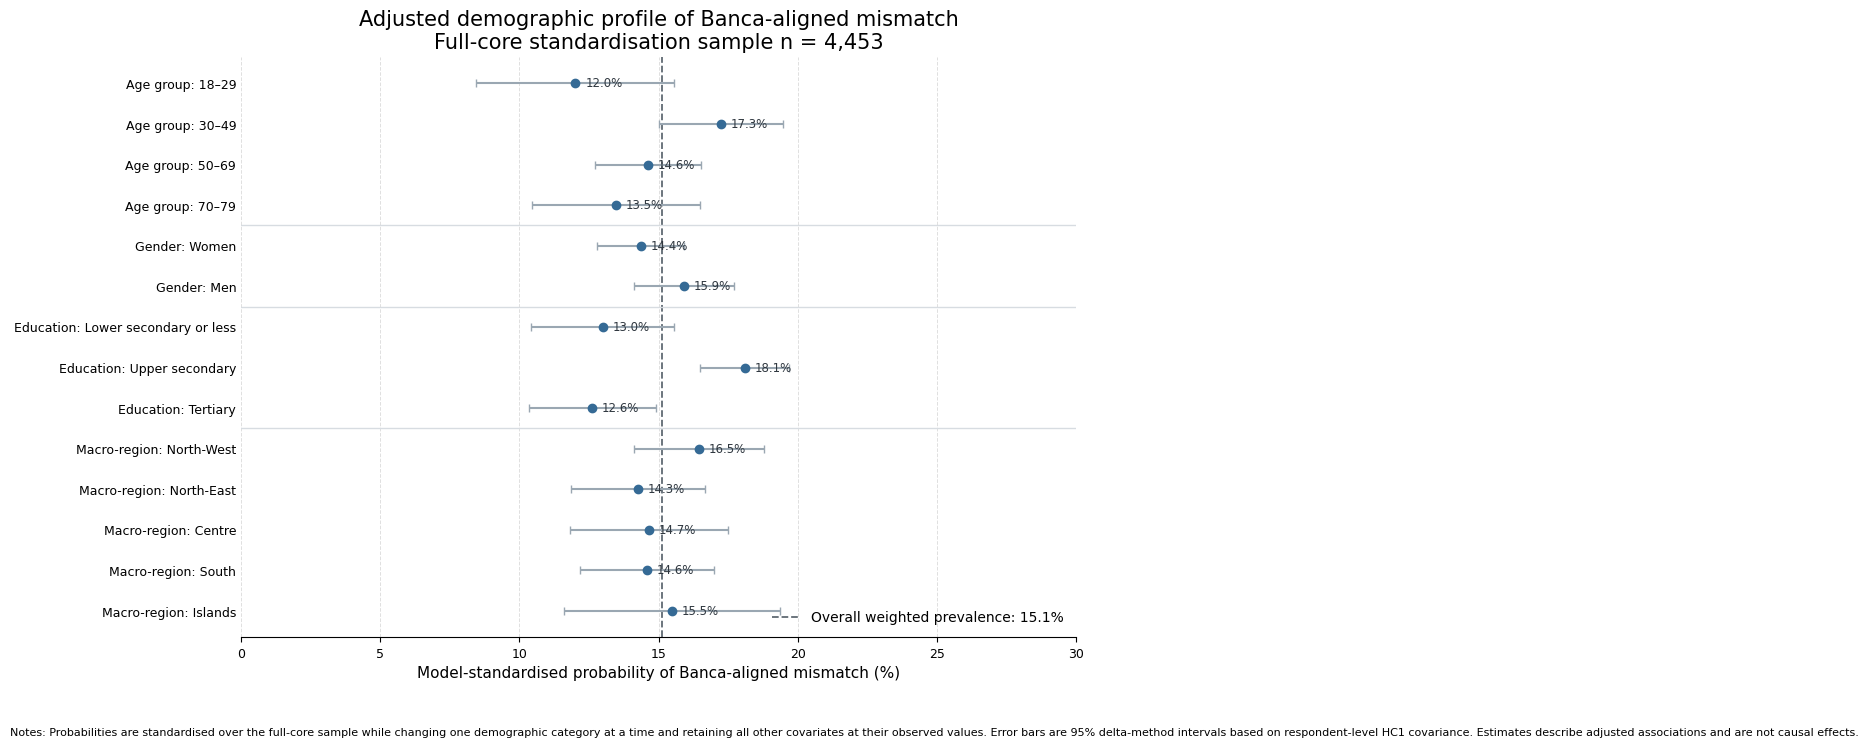

Adjusted demographic-profile figure saved successfully.


In [ ]:
# ============================================================
# Part 5: adjusted demographic dot plot
# ============================================================

demographic_plot = (
    module_4_3_adjusted_mismatch_demographics
    .copy()
)

y_positions = np.arange(
    len(demographic_plot)
)

x_values = demographic_plot[
    "adjusted_percent"
].to_numpy()

lower_errors = (
    x_values
    - demographic_plot[
        "confidence_low_percent"
    ].to_numpy()
)

upper_errors = (
    demographic_plot[
        "confidence_high_percent"
    ].to_numpy()
    - x_values
)

with plt.rc_context(
    {
        "font.size": 10,
        "axes.titlesize": 15,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    }
):
    (
        demographic_figure,
        demographic_axis,
    ) = plt.subplots(
        figsize=(11, 7.5)
    )

    demographic_axis.errorbar(
        x_values,
        y_positions,
        xerr=np.vstack(
            [
                lower_errors,
                upper_errors,
            ]
        ),
        fmt="o",
        color="#356A95",
        ecolor="#9AA7B2",
        elinewidth=1.5,
        capsize=3,
        markersize=6,
        zorder=3,
    )

    demographic_axis.axvline(
        overall_profile_percent,
        color="#606A73",
        linestyle="--",
        linewidth=1.3,
        zorder=1,
    )

    for y_position, percentage in zip(
        y_positions,
        x_values,
    ):
        demographic_axis.text(
            percentage + 0.35,
            y_position,
            f"{percentage:.1f}%",
            va="center",
            ha="left",
            fontsize=8.5,
            color="#303840",
        )

    for separator in [
        3.5,
        5.5,
        8.5,
    ]:
        demographic_axis.axhline(
            separator,
            color="#D7DCE1",
            linewidth=1.0,
        )

    x_upper = min(
        100.0,
        max(
            30.0,
            5.0
            * np.ceil(
                (
                    demographic_plot[
                        "confidence_high_percent"
                    ].max()
                    + 3.0
                )
                / 5.0
            ),
        ),
    )

    demographic_axis.set_xlim(
        0,
        x_upper,
    )

    demographic_axis.set_yticks(
        y_positions
    )

    demographic_axis.set_yticklabels(
        demographic_plot[
            "display_label"
        ]
    )

    demographic_axis.invert_yaxis()

    demographic_axis.set_xlabel(
        "Model-standardised probability of "
        "Banca-aligned mismatch (%)"
    )

    demographic_axis.set_title(
        "Adjusted demographic profile of "
        "Banca-aligned mismatch\n"
        "Full-core standardisation sample "
        f"n = {len(profile_data):,}"
    )

    demographic_axis.set_axisbelow(
        True
    )

    demographic_axis.xaxis.grid(
        True,
        linestyle="--",
        linewidth=0.7,
        alpha=0.4,
    )

    demographic_axis.yaxis.grid(
        False
    )

    for spine in [
        "top",
        "right",
        "left",
    ]:
        demographic_axis.spines[
            spine
        ].set_visible(False)

    demographic_axis.tick_params(
        axis="y",
        length=0,
    )

    demographic_axis.legend(
        handles=[
            Line2D(
                [0],
                [0],
                color="#606A73",
                linestyle="--",
                linewidth=1.3,
                label=(
                    "Overall weighted prevalence: "
                    f"{overall_profile_percent:.1f}%"
                ),
            )
        ],
        loc="lower right",
        frameon=False,
    )

    demographic_figure.text(
        0.01,
        0.01,
        "Notes: Probabilities are standardised over "
        "the full-core sample while changing one "
        "demographic category at a time and retaining "
        "all other covariates at their observed values. "
        "Error bars are 95% delta-method intervals based "
        "on respondent-level HC1 covariance. Estimates "
        "describe adjusted associations and are not "
        "causal effects.",
        ha="left",
        va="bottom",
        fontsize=8,
    )

    demographic_figure.tight_layout(
        rect=(0, 0.065, 1, 1)
    )

demographic_png_path = (
    figures_directory
    / "module_4_3_adjusted_mismatch_demographics.png"
)

demographic_pdf_path = (
    figures_directory
    / "module_4_3_adjusted_mismatch_demographics.pdf"
)

demographic_figure.savefig(
    demographic_png_path,
    dpi=300,
    bbox_inches="tight",
)

demographic_figure.savefig(
    demographic_pdf_path,
    bbox_inches="tight",
)

plt.show()

assert (
    demographic_png_path.stat().st_size
    > 0
)

assert (
    demographic_pdf_path.stat().st_size
    > 0
)

print(
    "Adjusted demographic-profile figure "
    "saved successfully."
)

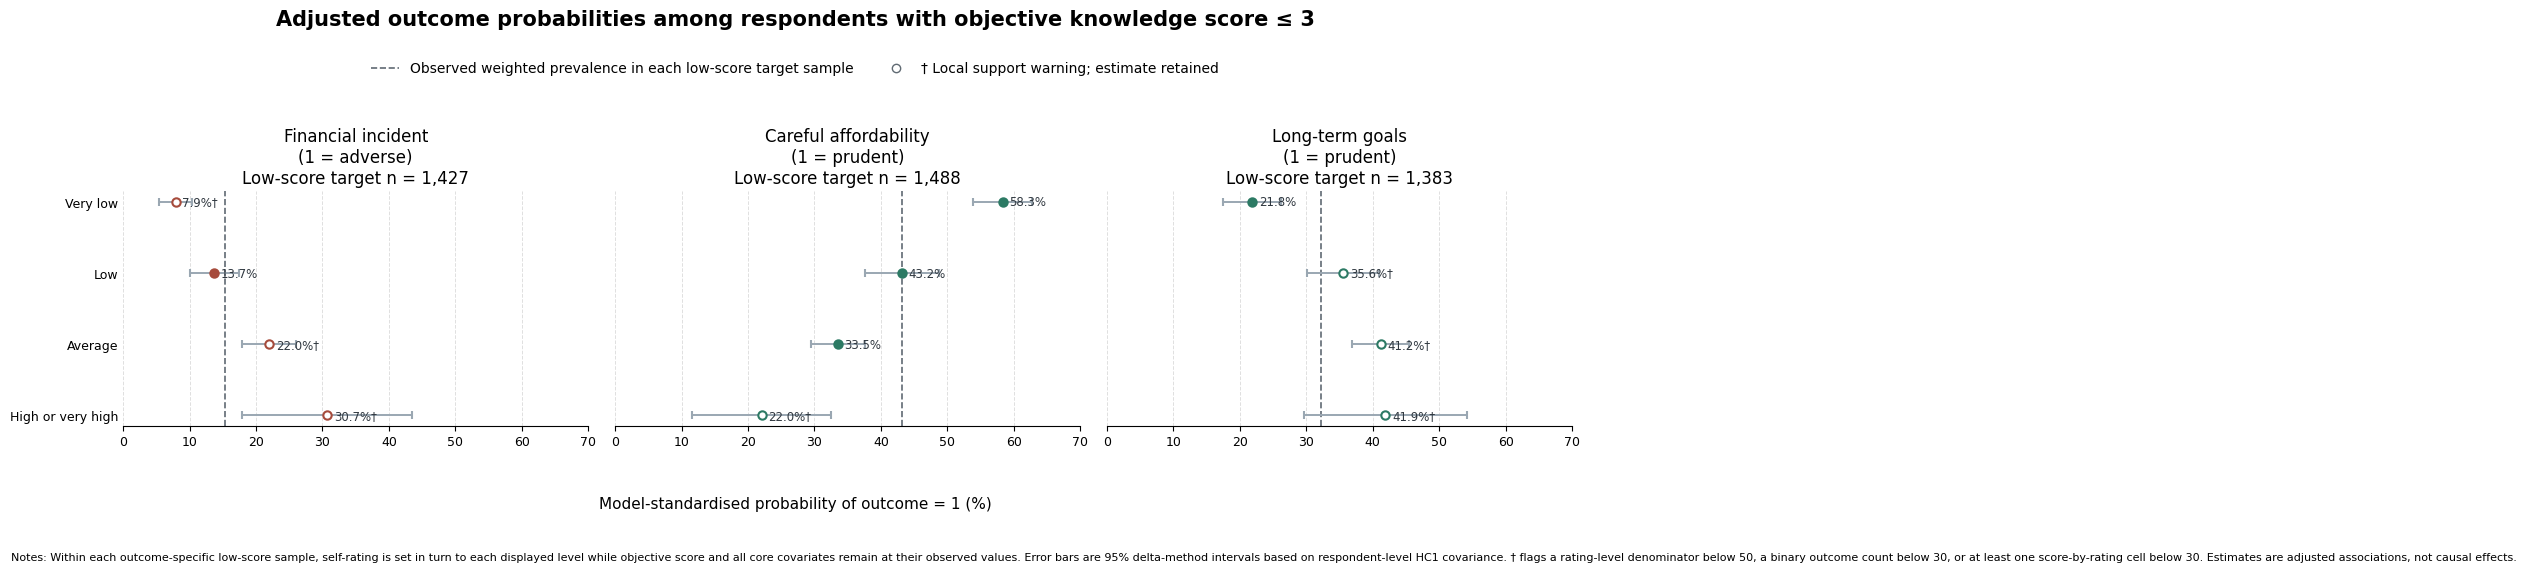

Primary-outcome marginal-probability figure saved successfully.


In [ ]:
# ============================================================
# Part 6: three-panel primary-outcome figure
# ============================================================

primary_plot = (
    module_4_3_primary_outcome_margins
    .copy()
)

rating_y_positions = np.arange(
    len(rating_levels)
)

primary_colours = {
    "financial_incident_any_full_core": (
        "#A64B3C"
    ),
    "careful_before_purchase_full_core": (
        "#2C7A64"
    ),
    "sets_long_term_goals_full_core": (
        "#2C7A64"
    ),
}

common_x_upper = min(
    100.0,
    max(
        70.0,
        10.0
        * np.ceil(
            (
                primary_plot[
                    "confidence_high_percent"
                ].max()
                + 5.0
            )
            / 10.0
        ),
    ),
)

with plt.rc_context(
    {
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    }
):
    (
        outcome_figure,
        outcome_axes,
    ) = plt.subplots(
        1,
        3,
        figsize=(16, 5.7),
        sharex=True,
        sharey=True,
    )

    for axis, specification in zip(
        outcome_axes,
        outcome_specifications_4_3[:3],
    ):
        model_id = specification[
            "model_id"
        ]

        panel_table = (
            primary_plot.loc[
                primary_plot[
                    "model_id"
                ].eq(model_id)
            ]
            .sort_values(
                "rating_order"
            )
        )

        panel_colour = (
            primary_colours[
                model_id
            ]
        )

        reference_percent = float(
            panel_table[
                "observed_target_weighted_percent"
            ].iloc[0]
        )

        target_n = int(
            panel_table[
                "target_unweighted_n"
            ].iloc[0]
        )

        axis.axvline(
            reference_percent,
            color="#606A73",
            linestyle="--",
            linewidth=1.2,
            zorder=1,
        )

        for y_position, (_, row) in zip(
            rating_y_positions,
            panel_table.iterrows(),
        ):
            estimate = float(
                row["adjusted_percent"]
            )

            lower_error = (
                estimate
                - float(
                    row[
                        "confidence_low_percent"
                    ]
                )
            )

            upper_error = (
                float(
                    row[
                        "confidence_high_percent"
                    ]
                )
                - estimate
            )

            support_warning = bool(
                row["support_warning"]
            )

            axis.errorbar(
                estimate,
                y_position,
                xerr=np.array(
                    [
                        [lower_error],
                        [upper_error],
                    ]
                ),
                fmt="o",
                color=panel_colour,
                ecolor="#9AA7B2",
                markerfacecolor=(
                    "white"
                    if support_warning
                    else panel_colour
                ),
                markeredgecolor=(
                    panel_colour
                ),
                markeredgewidth=1.5,
                elinewidth=1.4,
                capsize=3,
                markersize=6,
                zorder=3,
            )

            warning_symbol = (
                "†"
                if support_warning
                else ""
            )

            axis.text(
                estimate + 1.0,
                y_position,
                (
                    f"{estimate:.1f}%"
                    f"{warning_symbol}"
                ),
                va="center",
                ha="left",
                fontsize=8.5,
                color="#303840",
            )

        axis.set_xlim(
            0,
            common_x_upper,
        )

        axis.set_yticks(
            rating_y_positions
        )

        axis.set_title(
            f"{specification['panel_title']}\n"
            f"Low-score target n = {target_n:,}"
        )

        axis.set_axisbelow(
            True
        )

        axis.xaxis.grid(
            True,
            linestyle="--",
            linewidth=0.7,
            alpha=0.4,
        )

        axis.yaxis.grid(
            False
        )

        for spine in [
            "top",
            "right",
            "left",
        ]:
            axis.spines[
                spine
            ].set_visible(False)

        axis.tick_params(
            axis="y",
            length=0,
        )

    outcome_axes[0].set_yticklabels(
        rating_levels
    )

    outcome_axes[0].invert_yaxis()

    outcome_figure.suptitle(
        "Adjusted outcome probabilities among "
        "respondents with objective knowledge "
        "score ≤ 3",
        fontsize=15,
        fontweight="semibold",
        y=0.98,
    )

    outcome_figure.supxlabel(
        "Model-standardised probability "
        "of outcome = 1 (%)",
        fontsize=11,
        y=0.10,
    )

    outcome_figure.legend(
        handles=[
            Line2D(
                [0],
                [0],
                color="#606A73",
                linestyle="--",
                linewidth=1.2,
                label=(
                    "Observed weighted prevalence "
                    "in each low-score target sample"
                ),
            ),
            Line2D(
                [0],
                [0],
                marker="o",
                color="#606A73",
                markerfacecolor="white",
                linestyle="None",
                label=(
                    "† Local support warning; "
                    "estimate retained"
                ),
            ),
        ],
        loc="upper center",
        bbox_to_anchor=(
            0.5,
            0.91,
        ),
        frameon=False,
        ncol=2,
    )

    outcome_figure.text(
        0.01,
        0.01,
        "Notes: Within each outcome-specific low-score "
        "sample, self-rating is set in turn to each "
        "displayed level while objective score and all "
        "core covariates remain at their observed values. "
        "Error bars are 95% delta-method intervals based "
        "on respondent-level HC1 covariance. † flags a "
        "rating-level denominator below 50, a binary "
        "outcome count below 30, or at least one "
        "score-by-rating cell below 30. Estimates are "
        "adjusted associations, not causal effects.",
        ha="left",
        va="bottom",
        fontsize=8,
    )

    outcome_figure.tight_layout(
        rect=(
            0,
            0.13,
            1,
            0.86,
        )
    )

outcome_png_path = (
    figures_directory
    / "module_4_3_primary_outcome_margins.png"
)

outcome_pdf_path = (
    figures_directory
    / "module_4_3_primary_outcome_margins.pdf"
)

outcome_figure.savefig(
    outcome_png_path,
    dpi=300,
    bbox_inches="tight",
)

outcome_figure.savefig(
    outcome_pdf_path,
    bbox_inches="tight",
)

plt.show()

assert (
    outcome_png_path.stat().st_size
    > 0
)

assert (
    outcome_pdf_path.stat().st_size
    > 0
)

print(
    "Primary-outcome marginal-probability "
    "figure saved successfully."
)

In [ ]:
# ============================================================
# Part 7: save and validate focused Module 4.3 outputs
# ============================================================

module_4_3_tables = {
    "module_4_3_adjusted_mismatch_demographics.csv": (
        module_4_3_adjusted_mismatch_demographics
    ),
    "module_4_3_primary_outcome_margins.csv": (
        module_4_3_primary_outcome_margins
    ),
    "module_4_3_primary_outcome_contrasts.csv": (
        module_4_3_primary_outcome_contrasts
    ),
    "module_4_3_secondary_shopping_margins.csv": (
        module_4_3_secondary_shopping_margins
    ),
}

module_4_3_figures = [
    demographic_png_path,
    demographic_pdf_path,
    outcome_png_path,
    outcome_pdf_path,
]

manifest_rows = []

for filename, table in (
    module_4_3_tables.items()
):
    output_path = (
        tables_directory
        / filename
    )

    table.to_csv(
        output_path,
        index=False,
        encoding="utf-8",
    )

    reloaded_table = pd.read_csv(
        output_path,
        keep_default_na=False,
    )

    assert_same_csv_values(
        table,
        reloaded_table,
    )

    assert (
        output_path.stat().st_size
        > 0
    )

    manifest_rows.append(
        {
            "output_type": "Table",
            "filename": filename,
            "rows": table.shape[0],
            "columns": table.shape[1],
            "size_bytes": (
                output_path.stat().st_size
            ),
            "validation": "Passed",
        }
    )

for figure_path in (
    module_4_3_figures
):
    assert figure_path.exists()

    assert (
        figure_path.stat().st_size
        > 0
    )

    manifest_rows.append(
        {
            "output_type": "Figure",
            "filename": (
                figure_path.name
            ),
            "rows": np.nan,
            "columns": np.nan,
            "size_bytes": (
                figure_path.stat().st_size
            ),
            "validation": "Passed",
        }
    )

module_4_3_manifest = (
    pd.DataFrame(
        manifest_rows
    )
)

manifest_path = (
    tables_directory
    / "module_4_3_output_manifest.csv"
)

module_4_3_manifest.to_csv(
    manifest_path,
    index=False,
    encoding="utf-8",
)

assert manifest_path.exists()

assert (
    manifest_path.stat().st_size
    > 0
)

display(
    module_4_3_manifest
)

print(
    "Module 4.3 completed: adjusted mismatch "
    "profiling, primary low-score outcome margins, "
    "three pre-specified contrasts, and the secondary "
    "shopping table were saved and validated."
)

,output_type,filename,rows,columns,size_bytes,validation
0,Table,module_4_3_adjusted_mismatch_demographics.csv,14.0,14.0,2645,Passed
1,Table,module_4_3_primary_outcome_margins.csv,12.0,22.0,4758,Passed
2,Table,module_4_3_primary_outcome_contrasts.csv,3.0,14.0,1360,Passed
3,Table,module_4_3_secondary_shopping_margins.csv,4.0,22.0,2031,Passed
4,Figure,module_4_3_adjusted_mismatch_demographics.png,NaN,NaN,417655,Passed
5,Figure,module_4_3_adjusted_mismatch_demographics.pdf,NaN,NaN,22915,Passed
6,Figure,module_4_3_primary_outcome_margins.png,NaN,NaN,368361,Passed
7,Figure,module_4_3_primary_outcome_margins.pdf,NaN,NaN,32240,Passed


Module 4.3 completed: adjusted mismatch profiling, primary low-score outcome margins, three pre-specified contrasts, and the secondary shopping table were saved and validated.


## 4.4 — Focused Robustness Checks

**Purpose.** Assess whether the three pre-specified Average-minus-Low outcome contrasts and the adjusted demographic profile remain substantively stable across the approved common-sample and adjustment specifications.

The analysis reuses the models fitted in Module 4.2. Full-core estimates are compared with exposure-complete and income-complete core anchors, and each anchor is compared with its paired extended model on identical respondents and weights. The broader mismatch definition is used only as a pattern sensitivity.

No model is refitted, no new hypothesis test or figure is added, and all support warnings are retained. Robustness results qualify the main stakeholder findings rather than creating a separate analytical narrative.


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


# ============================================================
# Module 4.4 — Focused robustness checks
# Part 1: validate the frozen inputs
# ============================================================

required_objects_4_4 = [
    "PROJECT_ROOT",
    "model_df",
    "model_registry",
    "module_4_2_fit_store",
    "module_4_2_fit_diagnostics",
    "registry_row_for_model",
    "standardised_probability",
    "weighted_binary_percent",
    "assert_same_csv_values",
    "WALD_95_CRITICAL_VALUE",
]

missing_objects_4_4 = [
    name for name in required_objects_4_4
    if name not in globals()
]

assert not missing_objects_4_4, (
    "Run Modules 4.1, 4.2, and 4.3 before Module 4.4. "
    f"Missing objects: {missing_objects_4_4}"
)

tables_directory = Path(PROJECT_ROOT) / "outputs" / "tables"
tables_directory.mkdir(parents=True, exist_ok=True)

assert len(module_4_2_fit_store) == 26
assert module_4_2_fit_diagnostics["diagnostic_pass"].all()


outcomes_4_4 = [
    (
        1,
        "financial_incident_any",
        "Reported at least one financial incident",
        "Adverse event",
    ),
    (
        2,
        "careful_before_purchase",
        "Carefully considers affordability",
        "Prudent behaviour",
    ),
    (
        3,
        "sets_long_term_goals",
        "Sets and pursues long-term financial goals",
        "Prudent behaviour",
    ),
]


outcome_scenarios_4_4 = [
    (
        1,
        "full_core",
        "Full core model",
        "Primary result",
        None,
    ),
    (
        2,
        "exposure_complete_anchor",
        "Exposure-complete core anchor",
        "Restricted-sample anchor",
        None,
    ),
    (
        3,
        "exposure_aware",
        "Exposure-aware adjustment",
        "Extended adjustment",
        "exposure_complete_anchor",
    ),
    (
        4,
        "income_complete_anchor",
        "Income-complete core anchor",
        "Restricted-sample anchor",
        None,
    ),
    (
        5,
        "income_adjusted",
        "Income-adjusted model",
        "Extended adjustment",
        "income_complete_anchor",
    ),
]


profile_scenarios_4_4 = [
    (
        1,
        "profile_banca_full_core",
        "Full core model",
        "Primary result",
        None,
    ),
    (
        2,
        "profile_banca_exposure_complete_anchor",
        "Exposure-complete core anchor",
        "Restricted-sample anchor",
        None,
    ),
    (
        3,
        "profile_banca_exposure_aware",
        "Exposure-aware adjustment",
        "Extended adjustment",
        "profile_banca_exposure_complete_anchor",
    ),
    (
        4,
        "profile_banca_income_complete_anchor",
        "Income-complete core anchor",
        "Restricted-sample anchor",
        None,
    ),
    (
        5,
        "profile_banca_income_adjusted",
        "Income-adjusted model",
        "Extended adjustment",
        "profile_banca_income_complete_anchor",
    ),
    (
        6,
        "profile_broad_full_core_sensitivity",
        "Broad-definition full core",
        "Definition sensitivity",
        None,
    ),
]


required_models_4_4 = {
    f"{dependent_variable}_{suffix}"
    for _, dependent_variable, _, _ in outcomes_4_4
    for _, suffix, _, _, _ in outcome_scenarios_4_4
} | {
    model_id
    for _, model_id, _, _, _ in profile_scenarios_4_4
}

assert required_models_4_4.issubset(module_4_2_fit_store)


def assert_paired_samples(model_id, anchor_model_id):
    model_index = module_4_2_fit_store[
        model_id
    ]["analysis_index"]

    anchor_index = module_4_2_fit_store[
        anchor_model_id
    ]["analysis_index"]

    assert model_index.equals(anchor_index), (
        f"{model_id} and {anchor_model_id} "
        "do not use identical samples."
    )


for _, dependent_variable, _, _ in outcomes_4_4:
    for (
        _,
        suffix,
        _,
        role,
        anchor_suffix,
    ) in outcome_scenarios_4_4:

        if role == "Extended adjustment":
            assert_paired_samples(
                f"{dependent_variable}_{suffix}",
                f"{dependent_variable}_{anchor_suffix}",
            )


for (
    _,
    model_id,
    _,
    role,
    anchor_model_id,
) in profile_scenarios_4_4:

    if role == "Extended adjustment":
        assert_paired_samples(
            model_id,
            anchor_model_id,
        )


print(
    "Module 4.4 inputs validated: the 26 fits are available, "
    "diagnostics passed, and every extended model matches "
    "its paired anchor."
)

Module 4.4 inputs validated: the 26 fits are available, diagnostics passed, and every extended model matches its paired anchor.


In [ ]:
# ============================================================
# Part 2: Average-minus-Low outcome contrasts
# ============================================================


def rating_support_4_4(
    target_data,
    outcome_variable,
    rating_level,
):
    observed = target_data[
        "self_rating_model"
    ].eq(rating_level)

    observed_n = int(observed.sum())
    assert observed_n > 0

    minimum_score_cell_n = min(
        int(
            (
                observed
                & target_data[
                    "objective_knowledge_score"
                ].eq(score)
            ).sum()
        )
        for score in range(4)
    )

    observed_outcome = target_data.loc[
        observed,
        outcome_variable,
    ].astype(int)

    minimum_binary_n = int(
        min(
            observed_outcome.eq(1).sum(),
            observed_outcome.eq(0).sum(),
        )
    )

    reasons = []

    if observed_n < 50:
        reasons.append(
            "Rating-level target n < 50"
        )

    if minimum_score_cell_n < 30:
        reasons.append(
            "At least one score-by-rating cell n < 30"
        )

    if minimum_binary_n < 30:
        reasons.append(
            "One binary outcome count n < 30"
        )

    return (
        observed_n,
        minimum_score_cell_n,
        minimum_binary_n,
        reasons,
    )


def average_minus_low_4_4(
    model_id,
    outcome_variable,
):
    stored_fit = module_4_2_fit_store[model_id]

    analysis_data = model_df.loc[
        stored_fit["sample_mask"]
    ]

    target_data = analysis_data.loc[
        analysis_data[
            "objective_knowledge_score"
        ].le(3)
    ].copy()

    assert len(target_data) > 0

    margins = {}
    support = {}

    for rating_level in ["Low", "Average"]:
        scenario_data = target_data.copy()
        scenario_data[
            "self_rating_model"
        ] = rating_level

        margins[rating_level] = (
            standardised_probability(
                model_id,
                scenario_data,
            )
        )

        support[rating_level] = (
            rating_support_4_4(
                target_data,
                outcome_variable,
                rating_level,
            )
        )

    difference = (
        margins["Average"]["estimate"]
        - margins["Low"]["estimate"]
    )

    gradient = (
        margins["Average"]["gradient"]
        - margins["Low"]["gradient"]
    )

    covariance = stored_fit[
        "robust_covariance"
    ].to_numpy(dtype=float)

    variance = float(
        gradient
        @ covariance
        @ gradient
    )

    assert variance >= -1e-12

    standard_error = float(
        np.sqrt(max(variance, 0.0))
    )

    reasons = list(
        dict.fromkeys(
            reason
            for rating_level in ["Average", "Low"]
            for reason in support[rating_level][3]
        )
    )

    return {
        "target_unweighted_n": len(target_data),
        "average_rating_unweighted_n": (
            support["Average"][0]
        ),
        "low_rating_unweighted_n": (
            support["Low"][0]
        ),
        "average_adjusted_percent": (
            100
            * margins["Average"]["estimate"]
        ),
        "low_adjusted_percent": (
            100
            * margins["Low"]["estimate"]
        ),
        "difference_percentage_points": (
            100 * difference
        ),
        "standard_error_pp": (
            100 * standard_error
        ),
        "confidence_low_pp": (
            100
            * (
                difference
                - WALD_95_CRITICAL_VALUE
                * standard_error
            )
        ),
        "confidence_high_pp": (
            100
            * (
                difference
                + WALD_95_CRITICAL_VALUE
                * standard_error
            )
        ),
        "minimum_score_cell_unweighted_n": min(
            support["Average"][1],
            support["Low"][1],
        ),
        "minimum_binary_outcome_count": min(
            support["Average"][2],
            support["Low"][2],
        ),
        "support_warning": bool(reasons),
        "support_warning_reason": (
            "; ".join(reasons)
            if reasons
            else "No"
        ),
    }


outcome_contrast_rows = []

for (
    outcome_order,
    dependent_variable,
    outcome_label,
    meaning,
) in outcomes_4_4:

    for (
        scenario_order,
        suffix,
        scenario_label,
        role,
        anchor_suffix,
    ) in outcome_scenarios_4_4:

        model_id = (
            f"{dependent_variable}_{suffix}"
        )

        registry_row = registry_row_for_model(
            model_id
        )

        outcome_contrast_rows.append(
            {
                "outcome_order": outcome_order,
                "scenario_order": scenario_order,
                "model_id": model_id,
                "outcome_label": outcome_label,
                "outcome_1_meaning": meaning,
                "scenario_label": scenario_label,
                "scenario_role": role,
                "sample_basis": (
                    registry_row["sample_basis"]
                ),
                "adjustment_specification": (
                    registry_row[
                        "adjustment_specification"
                    ]
                ),
                "paired_anchor_model_id": (
                    f"{dependent_variable}_"
                    f"{anchor_suffix}"
                    if anchor_suffix is not None
                    else "None"
                ),
                "target_definition": (
                    "Objective knowledge score <= 3"
                ),
                **average_minus_low_4_4(
                    model_id,
                    dependent_variable,
                ),
            }
        )


module_4_4_outcome_contrast_robustness = (
    pd.DataFrame(outcome_contrast_rows)
    .sort_values(
        [
            "outcome_order",
            "scenario_order",
        ]
    )
    .reset_index(drop=True)
)

assert (
    module_4_4_outcome_contrast_robustness.shape[0]
    == 15
)

assert (
    module_4_4_outcome_contrast_robustness[
        "confidence_low_pp"
    ]
    <= module_4_4_outcome_contrast_robustness[
        "difference_percentage_points"
    ]
).all()

assert (
    module_4_4_outcome_contrast_robustness[
        "difference_percentage_points"
    ]
    <= module_4_4_outcome_contrast_robustness[
        "confidence_high_pp"
    ]
).all()


contrast_lookup = (
    module_4_4_outcome_contrast_robustness
    .set_index("model_id")[
        "difference_percentage_points"
    ]
)

module_4_4_outcome_contrast_robustness[
    "shift_from_paired_anchor_pp"
] = [
    (
        row["difference_percentage_points"]
        - contrast_lookup.loc[
            row["paired_anchor_model_id"]
        ]
        if (
            row["scenario_role"]
            == "Extended adjustment"
        )
        else np.nan
    )
    for _, row in (
        module_4_4_outcome_contrast_robustness
        .iterrows()
    )
]


def contrast_value_4_4(
    outcome_rows,
    scenario_order,
):
    values = outcome_rows.loc[
        outcome_rows[
            "scenario_order"
        ].eq(scenario_order),
        "difference_percentage_points",
    ]

    assert len(values) == 1
    return float(values.iloc[0])


outcome_summary_rows = []

for (
    outcome_order,
    _,
    outcome_label,
    _,
) in outcomes_4_4:

    rows = (
        module_4_4_outcome_contrast_robustness
        .loc[
            module_4_4_outcome_contrast_robustness[
                "outcome_order"
            ].eq(outcome_order)
        ]
    )

    estimates = rows[
        "difference_percentage_points"
    ]

    full_core = contrast_value_4_4(
        rows,
        1,
    )

    exposure_anchor = contrast_value_4_4(
        rows,
        2,
    )

    exposure_adjusted = contrast_value_4_4(
        rows,
        3,
    )

    income_anchor = contrast_value_4_4(
        rows,
        4,
    )

    income_adjusted = contrast_value_4_4(
        rows,
        5,
    )

    outcome_summary_rows.append(
        {
            "outcome_order": outcome_order,
            "outcome_label": outcome_label,
            "full_core_contrast_pp": (
                full_core
            ),
            "exposure_anchor_contrast_pp": (
                exposure_anchor
            ),
            "exposure_adjusted_contrast_pp": (
                exposure_adjusted
            ),
            "exposure_adjustment_shift_pp": (
                exposure_adjusted
                - exposure_anchor
            ),
            "income_anchor_contrast_pp": (
                income_anchor
            ),
            "income_adjusted_contrast_pp": (
                income_adjusted
            ),
            "income_adjustment_shift_pp": (
                income_adjusted
                - income_anchor
            ),
            "minimum_contrast_pp": (
                estimates.min()
            ),
            "maximum_contrast_pp": (
                estimates.max()
            ),
            "direction_consistent_across_specifications": bool(
                (
                    np.sign(estimates)
                    == np.sign(full_core)
                ).all()
            ),
            "full_core_support_warning": bool(
                rows.loc[
                    rows[
                        "scenario_order"
                    ].eq(1),
                    "support_warning",
                ].iloc[0]
            ),
            "support_warning_scenario_n": int(
                rows["support_warning"].sum()
            ),
            "any_support_warning": bool(
                rows["support_warning"].any()
            ),
            "interpretation_rule": (
                "Adjustment shifts are descriptive; "
                "intervals refer to each contrast, "
                "not to differences between fitted models"
            ),
        }
    )


module_4_4_outcome_contrast_summary = (
    pd.DataFrame(outcome_summary_rows)
)

assert (
    module_4_4_outcome_contrast_summary.shape[0]
    == 3
)


outcome_display = (
    module_4_4_outcome_contrast_summary.copy()
)

numeric_outcome_columns = [
    column
    for column in outcome_display.columns
    if column.endswith("_pp")
]

outcome_display[
    numeric_outcome_columns
] = outcome_display[
    numeric_outcome_columns
].round(1)


display(
    outcome_display[
        [
            "outcome_label",
            "full_core_contrast_pp",
            "exposure_anchor_contrast_pp",
            "exposure_adjusted_contrast_pp",
            "exposure_adjustment_shift_pp",
            "income_anchor_contrast_pp",
            "income_adjusted_contrast_pp",
            "income_adjustment_shift_pp",
            "direction_consistent_across_specifications",
            "full_core_support_warning",
            "support_warning_scenario_n",
        ]
    ]
)

print(
    "The three pre-specified outcome contrasts "
    "were checked across all five approved specifications."
)

,outcome_label,full_core_contrast_pp,exposure_anchor_contrast_pp,exposure_adjusted_contrast_pp,exposure_adjustment_shift_pp,income_anchor_contrast_pp,income_adjusted_contrast_pp,income_adjustment_shift_pp,direction_consistent_across_specifications,full_core_support_warning,support_warning_scenario_n
0,Reported at least one financial incident,8.2,8.5,8.1,-0.4,12.9,11.2,-1.7,True,True,5
1,Carefully considers affordability,-9.7,-9.5,-10.0,-0.4,-6.2,-4.9,1.3,True,False,4
2,Sets and pursues long-term financial goals,5.6,6.4,5.6,-0.8,12.8,13.6,0.8,True,True,5


The three pre-specified outcome contrasts were checked across all five approved specifications.


In [ ]:
# ============================================================
# Part 3: mismatch-profile and definition sensitivity
# ============================================================

demographic_specifications_4_4 = [
    {
        "demographic_order": 1,
        "variable": "age_model_group",
        "demographic_label": "Age group",
        "categories": [
            "18–29",
            "30–49",
            "50–69",
            "70–79",
        ],
    },
    {
        "demographic_order": 2,
        "variable": "gender",
        "demographic_label": "Gender",
        "categories": [
            "Women",
            "Men",
        ],
    },
    {
        "demographic_order": 3,
        "variable": "education_group",
        "demographic_label": "Education",
        "categories": [
            "Lower secondary or less",
            "Upper secondary",
            "Tertiary",
        ],
    },
    {
        "demographic_order": 4,
        "variable": "macro_region",
        "demographic_label": "Macro-region",
        "categories": [
            "North-West",
            "North-East",
            "Centre",
            "South",
            "Islands",
        ],
    },
]

profile_margin_rows = []

for (
    scenario_order,
    model_id,
    scenario_label,
    role,
    anchor_model_id,
) in profile_scenarios_4_4:

    registry_row = registry_row_for_model(
        model_id
    )

    stored_fit = module_4_2_fit_store[
        model_id
    ]

    profile_data = model_df.loc[
        stored_fit["sample_mask"]
    ].copy()

    dependent_variable = registry_row[
        "dependent_variable"
    ]

    overall_percent = weighted_binary_percent(
        profile_data,
        dependent_variable,
    )

    for demographic in demographic_specifications_4_4:
        variable = demographic["variable"]

        for category_order, category in enumerate(
            demographic["categories"],
            start=1,
        ):
            observed = profile_data[
                variable
            ].eq(category)

            assert observed.any()

            scenario_data = profile_data.copy()
            scenario_data[variable] = category

            margin = standardised_probability(
                model_id,
                scenario_data,
            )

            profile_margin_rows.append(
                {
                    "scenario_order": (
                        scenario_order
                    ),
                    "model_id": model_id,
                    "scenario_label": (
                        scenario_label
                    ),
                    "scenario_role": role,
                    "paired_anchor_model_id": (
                        anchor_model_id
                        if anchor_model_id
                        else "None"
                    ),
                    "dependent_variable": (
                        dependent_variable
                    ),
                    "sample_basis": (
                        registry_row[
                            "sample_basis"
                        ]
                    ),
                    "adjustment_specification": (
                        registry_row[
                            "adjustment_specification"
                        ]
                    ),
                    "standardisation_sample_unweighted_n": (
                        len(profile_data)
                    ),
                    "overall_weighted_percent": (
                        overall_percent
                    ),
                    "demographic_order": (
                        demographic[
                            "demographic_order"
                        ]
                    ),
                    "demographic_label": (
                        demographic[
                            "demographic_label"
                        ]
                    ),
                    "variable": variable,
                    "category_order": (
                        category_order
                    ),
                    "category": category,
                    "observed_category_unweighted_n": int(
                        observed.sum()
                    ),
                    "adjusted_percent": (
                        100
                        * margin["estimate"]
                    ),
                    "standard_error_pp": (
                        100
                        * margin["standard_error"]
                    ),
                    "confidence_low_percent": (
                        100
                        * margin[
                            "confidence_low"
                        ]
                    ),
                    "confidence_high_percent": (
                        100
                        * margin[
                            "confidence_high"
                        ]
                    ),
                    "confidence_interval_clipped": (
                        margin[
                            "confidence_interval_clipped"
                        ]
                    ),
                }
            )


module_4_4_mismatch_profile_robustness = (
    pd.DataFrame(profile_margin_rows)
    .sort_values(
        [
            "scenario_order",
            "demographic_order",
            "category_order",
        ]
    )
    .reset_index(drop=True)
)

assert (
    module_4_4_mismatch_profile_robustness.shape[0]
    == 84
)

assert (
    module_4_4_mismatch_profile_robustness[
        "adjusted_percent"
    ].between(0, 100).all()
)


profile_lookup = (
    module_4_4_mismatch_profile_robustness
    .set_index(
        [
            "model_id",
            "variable",
            "category",
        ]
    )["adjusted_percent"]
)


module_4_4_mismatch_profile_robustness[
    "shift_from_paired_anchor_pp"
] = [
    (
        row["adjusted_percent"]
        - profile_lookup.loc[
            row["paired_anchor_model_id"],
            row["variable"],
            row["category"],
        ]
        if (
            row["scenario_role"]
            == "Extended adjustment"
        )
        else np.nan
    )
    for _, row in (
        module_4_4_mismatch_profile_robustness
        .iterrows()
    )
]


primary_profile = (
    module_4_4_mismatch_profile_robustness
    .loc[
        module_4_4_mismatch_profile_robustness[
            "model_id"
        ].eq("profile_banca_full_core")
    ]
)

profile_dimension_rows = []


for (
    scenario_order,
    model_id,
    scenario_label,
    role,
    _,
) in profile_scenarios_4_4:

    scenario_rows = (
        module_4_4_mismatch_profile_robustness
        .loc[
            module_4_4_mismatch_profile_robustness[
                "model_id"
            ].eq(model_id)
        ]
    )

    for demographic in demographic_specifications_4_4:
        variable = demographic["variable"]

        rows = scenario_rows.loc[
            scenario_rows[
                "variable"
            ].eq(variable)
        ]

        primary_rows = primary_profile.loc[
            primary_profile[
                "variable"
            ].eq(variable)
        ]

        top = rows.loc[
            rows[
                "adjusted_percent"
            ].idxmax()
        ]

        bottom = rows.loc[
            rows[
                "adjusted_percent"
            ].idxmin()
        ]

        primary_top = primary_rows.loc[
            primary_rows[
                "adjusted_percent"
            ].idxmax(),
            "category",
        ]

        profile_dimension_rows.append(
            {
                "scenario_order": (
                    scenario_order
                ),
                "model_id": model_id,
                "scenario_label": (
                    scenario_label
                ),
                "scenario_role": role,
                "demographic_order": (
                    demographic[
                        "demographic_order"
                    ]
                ),
                "demographic_label": (
                    demographic[
                        "demographic_label"
                    ]
                ),
                "variable": variable,
                "top_category": (
                    top["category"]
                ),
                "top_adjusted_percent": (
                    top[
                        "adjusted_percent"
                    ]
                ),
                "bottom_category": (
                    bottom["category"]
                ),
                "bottom_adjusted_percent": (
                    bottom[
                        "adjusted_percent"
                    ]
                ),
                "within_dimension_spread_pp": (
                    top[
                        "adjusted_percent"
                    ]
                    - bottom[
                        "adjusted_percent"
                    ]
                ),
                "primary_top_category": (
                    primary_top
                ),
                "top_category_matches_primary": bool(
                    top["category"]
                    == primary_top
                ),
                "maximum_absolute_paired_shift_pp": (
                    rows[
                        "shift_from_paired_anchor_pp"
                    ].abs().max()
                    if role
                    == "Extended adjustment"
                    else np.nan
                ),
                "definition_comparison_rule": (
                    "Pattern and ranking only; "
                    "level is not equivalent"
                    if role
                    == "Definition sensitivity"
                    else (
                        "Same primary "
                        "mismatch definition"
                    )
                ),
            }
        )


module_4_4_profile_dimension_summary = (
    pd.DataFrame(
        profile_dimension_rows
    )
    .sort_values(
        [
            "scenario_order",
            "demographic_order",
        ]
    )
)

assert (
    module_4_4_profile_dimension_summary.shape[0]
    == 24
)


def profile_value_4_4(
    model_id,
    variable,
    column,
):
    value = (
        module_4_4_profile_dimension_summary
        .loc[
            module_4_4_profile_dimension_summary[
                "model_id"
            ].eq(model_id)
            & module_4_4_profile_dimension_summary[
                "variable"
            ].eq(variable),
            column,
        ]
    )

    assert len(value) == 1
    return value.iloc[0]


profile_compact_rows = []

for demographic in demographic_specifications_4_4:
    variable = demographic["variable"]

    profile_compact_rows.append(
        {
            "demographic_order": (
                demographic[
                    "demographic_order"
                ]
            ),
            "demographic_label": (
                demographic[
                    "demographic_label"
                ]
            ),
            "primary_top_category": (
                profile_value_4_4(
                    "profile_banca_full_core",
                    variable,
                    "top_category",
                )
            ),
            "primary_spread_pp": (
                profile_value_4_4(
                    "profile_banca_full_core",
                    variable,
                    "within_dimension_spread_pp",
                )
            ),
            "exposure_adjusted_top_category": (
                profile_value_4_4(
                    "profile_banca_exposure_aware",
                    variable,
                    "top_category",
                )
            ),
            "exposure_pair_maximum_shift_pp": (
                profile_value_4_4(
                    "profile_banca_exposure_aware",
                    variable,
                    "maximum_absolute_paired_shift_pp",
                )
            ),
            "income_adjusted_top_category": (
                profile_value_4_4(
                    "profile_banca_income_adjusted",
                    variable,
                    "top_category",
                )
            ),
            "income_pair_maximum_shift_pp": (
                profile_value_4_4(
                    "profile_banca_income_adjusted",
                    variable,
                    "maximum_absolute_paired_shift_pp",
                )
            ),
            "broad_definition_top_category": (
                profile_value_4_4(
                    "profile_broad_full_core_sensitivity",
                    variable,
                    "top_category",
                )
            ),
        }
    )


module_4_4_profile_compact_summary = (
    pd.DataFrame(profile_compact_rows)
)

assert (
    module_4_4_profile_compact_summary.shape[0]
    == 4
)


profile_display = (
    module_4_4_profile_compact_summary.copy()
)

profile_numeric_columns = [
    "primary_spread_pp",
    "exposure_pair_maximum_shift_pp",
    "income_pair_maximum_shift_pp",
]

profile_display[
    profile_numeric_columns
] = profile_display[
    profile_numeric_columns
].round(1)


display(
    profile_display.drop(
        columns="demographic_order"
    )
)

print(
    "Profile stability was summarised without new pairwise tests; "
    "the broader mismatch definition was compared only as a "
    "pattern sensitivity."
)

,demographic_label,primary_top_category,primary_spread_pp,exposure_adjusted_top_category,exposure_pair_maximum_shift_pp,income_adjusted_top_category,income_pair_maximum_shift_pp,broad_definition_top_category
0,Age group,30–49,5.2,30–49,0.4,18–29,0.9,30–49
1,Gender,Men,1.6,Men,0.0,Men,0.2,Men
2,Education,Upper secondary,5.5,Upper secondary,0.2,Upper secondary,1.5,Upper secondary
3,Macro-region,North-West,2.2,North-West,0.1,North-West,0.5,North-West


Profile stability was summarised without new pairwise tests; the broader mismatch definition was compared only as a pattern sensitivity.


In [ ]:
# ============================================================
# Part 4: save and validate focused outputs
# ============================================================

module_4_4_tables = {
    "module_4_4_outcome_contrast_robustness.csv": (
        module_4_4_outcome_contrast_robustness
    ),
    "module_4_4_outcome_contrast_summary.csv": (
        module_4_4_outcome_contrast_summary
    ),
    "module_4_4_mismatch_profile_robustness.csv": (
        module_4_4_mismatch_profile_robustness
    ),
    "module_4_4_profile_compact_summary.csv": (
        module_4_4_profile_compact_summary
    ),
}


manifest_rows = []

for filename, table in module_4_4_tables.items():
    output_path = (
        tables_directory
        / filename
    )

    table.to_csv(
        output_path,
        index=False,
        encoding="utf-8",
    )

    reloaded = pd.read_csv(
        output_path,
        keep_default_na=False,
    )

    assert_same_csv_values(
        table,
        reloaded,
    )

    assert (
        output_path.stat().st_size
        > 0
    )

    manifest_rows.append(
        {
            "output_type": "Table",
            "filename": filename,
            "rows": table.shape[0],
            "columns": table.shape[1],
            "size_bytes": (
                output_path.stat().st_size
            ),
            "validation": "Passed",
        }
    )


module_4_4_manifest = pd.DataFrame(
    manifest_rows
)

manifest_path = (
    tables_directory
    / "module_4_4_output_manifest.csv"
)

module_4_4_manifest.to_csv(
    manifest_path,
    index=False,
    encoding="utf-8",
)

assert manifest_path.exists()
assert manifest_path.stat().st_size > 0

display(module_4_4_manifest)

print(
    "Module 4.4 completed: paired outcome contrasts and "
    "compact profile sensitivities were saved and validated. "
    "No model was refitted and no new figure or hypothesis "
    "test was added."
)

,output_type,filename,rows,columns,size_bytes,validation
0,Table,module_4_4_outcome_contrast_robustness.csv,15,25,6585,Passed
1,Table,module_4_4_outcome_contrast_summary.csv,3,16,1416,Passed
2,Table,module_4_4_mismatch_profile_robustness.csv,84,22,26317,Passed
3,Table,module_4_4_profile_compact_summary.csv,4,9,658,Passed


Module 4.4 completed: paired outcome contrasts and compact profile sensitivities were saved and validated. No model was refitted and no new figure or hypothesis test was added.


Saved: /content/drive/MyDrive/The_Confidence_Trap/outputs/figures/module_4_3_primary_outcome_margins_report.pdf
Saved: /content/drive/MyDrive/The_Confidence_Trap/outputs/figures/module_4_3_primary_outcome_margins_report.png


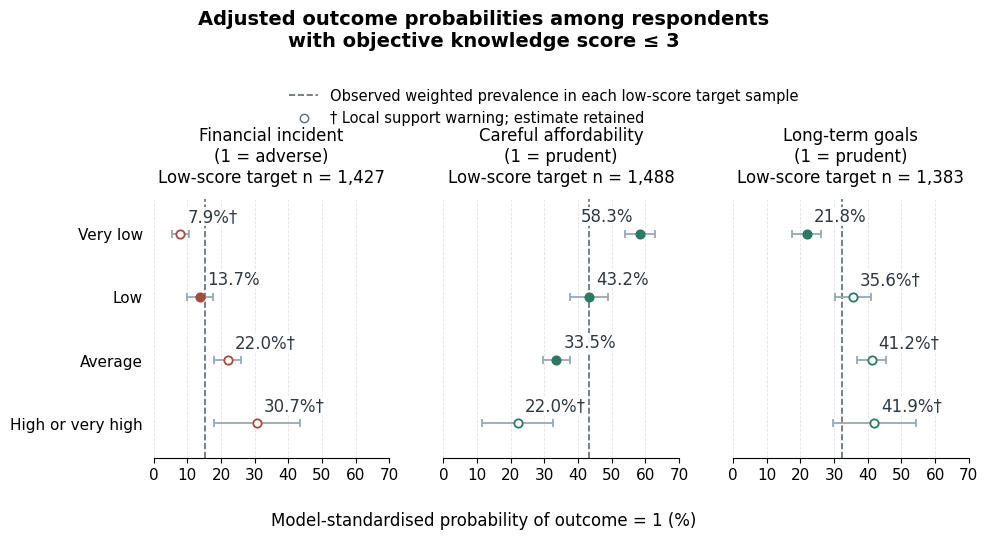

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def build_report_figure(table):
    table = table.copy()

    ratings = [
        "Very low",
        "Low",
        "Average",
        "High or very high",
    ]

    panels = [
        (
            "financial_incident_any_full_core",
            "Financial incident\n(1 = adverse)",
            "#A64B3C",
        ),
        (
            "careful_before_purchase_full_core",
            "Careful affordability\n(1 = prudent)",
            "#2C7A64",
        ),
        (
            "sets_long_term_goals_full_core",
            "Long-term goals\n(1 = prudent)",
            "#2C7A64",
        ),
    ]

    assert len(table) == 12
    assert set(table["model_id"]) == {p[0] for p in panels}
    assert not table.duplicated(
        ["model_id", "self_rating_level"]
    ).any()

    # Preserve the support warnings stored in the original CSV.
    flags = (
        table["support_warning"]
        .astype(str)
        .str.strip()
        .str.lower()
    )
    assert flags.isin(["true", "false"]).all()
    table["support_warning"] = flags.eq("true")

    upper_x = min(
        100.0,
        max(
            70.0,
            10 * np.ceil(
                (table["confidence_high_percent"].max() + 5) / 10
            ),
        ),
    )

    style = {
        "font.size": 12,
        "axes.titlesize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
    }

    with plt.rc_context(style):
        fig, axes = plt.subplots(
            1, 3,
            figsize=(10, 5.5),
            sharex=True,
            sharey=True,
        )

        for ax, (model_id, title, colour) in zip(axes, panels):
            rows = (
                table.loc[table["model_id"].eq(model_id)]
                .set_index("self_rating_level")
                .loc[ratings]
            )

            assert len(rows) == 4
            assert rows["target_unweighted_n"].nunique() == 1
            assert (
                rows["observed_target_weighted_percent"].nunique()
                == 1
            )

            values = rows[
                [
                    "adjusted_percent",
                    "confidence_low_percent",
                    "confidence_high_percent",
                ]
            ].to_numpy(float)

            assert np.isfinite(values).all()
            assert ((values >= 0) & (values <= 100)).all()
            assert (values[:, 1] <= values[:, 0]).all()
            assert (values[:, 0] <= values[:, 2]).all()

            ax.axvline(
                rows["observed_target_weighted_percent"].iloc[0],
                color="#606A73",
                linestyle="--",
                linewidth=1.2,
                zorder=1,
            )

            for y, (_, row) in enumerate(rows.iterrows()):
                estimate = float(row["adjusted_percent"])
                warning = bool(row["support_warning"])

                errors = np.array([
                    [estimate - row["confidence_low_percent"]],
                    [row["confidence_high_percent"] - estimate],
                ])

                ax.errorbar(
                    estimate,
                    y,
                    xerr=errors,
                    fmt="o",
                    color=colour,
                    ecolor="#9AA7B2",
                    markerfacecolor="white" if warning else colour,
                    markeredgecolor=colour,
                    markeredgewidth=1.3,
                    elinewidth=1.3,
                    capsize=3,
                    markersize=6,
                    zorder=3,
                )

                right_side = estimate <= 0.70 * upper_x

                ax.annotate(
                    f"{estimate:.1f}%" + ("†" if warning else ""),
                    (estimate, y),
                    xytext=(5 if right_side else -5, 6),
                    textcoords="offset points",
                    va="bottom",
                    ha="left" if right_side else "right",
                    fontsize=12,
                    color="#303840",
                    bbox={
                        "facecolor": "white",
                        "edgecolor": "none",
                        "alpha": 0.9,
                        "pad": 0.2,
                    },
                )

            target_n = int(rows["target_unweighted_n"].iloc[0])

            ax.set_title(
                f"{title}\nLow-score target n = {target_n:,}",
                pad=12,
            )

            ax.set_xlim(0, upper_x)
            ax.set_xticks(np.arange(0, upper_x + 1, 10))
            ax.set_yticks(range(4))
            ax.set_axisbelow(True)

            ax.xaxis.grid(
                True,
                linestyle="--",
                linewidth=0.6,
                alpha=0.35,
            )

            ax.tick_params(axis="y", length=0, pad=8)

            for spine in ["top", "right", "left"]:
                ax.spines[spine].set_visible(False)

        axes[0].set_yticklabels(ratings)
        axes[0].set_ylim(3.55, -0.55)

        fig.suptitle(
            "Adjusted outcome probabilities among respondents\n"
            "with objective knowledge score ≤ 3",
            fontsize=14,
            fontweight="semibold",
            y=0.985,
        )

        fig.legend(
            handles=[
                Line2D(
                    [0], [0],
                    color="#606A73",
                    linestyle="--",
                    linewidth=1.2,
                    label=(
                        "Observed weighted prevalence in each "
                        "low-score target sample"
                    ),
                ),
                Line2D(
                    [0], [0],
                    marker="o",
                    color="#606A73",
                    markerfacecolor="white",
                    linestyle="None",
                    label=(
                        "† Local support warning; estimate retained"
                    ),
                ),
            ],
            loc="upper center",
            bbox_to_anchor=(0.56, 0.865),
            frameon=False,
            ncol=1,
            fontsize=10.5,
        )

        fig.supxlabel(
            "Model-standardised probability of outcome = 1 (%)",
            fontsize=12,
            y=0.04,
        )

        fig.subplots_adjust(
            left=0.17,
            right=0.985,
            bottom=0.17,
            top=0.64,
            wspace=0.23,
        )

    return fig


# Read the saved margins: no models or intervals are recalculated.
report_root = PROJECT_ROOT

csv_path = (
    report_root
    / "outputs/tables/module_4_3_primary_outcome_margins.csv"
)

if not csv_path.is_file():
    raise FileNotFoundError(
        f"Saved margins not found: {csv_path}"
    )

report_margins = pd.read_csv(
    csv_path,
    float_precision="round_trip",
)

report_figure = build_report_figure(report_margins)

report_directory = report_root / "outputs/figures"
report_directory.mkdir(parents=True, exist_ok=True)

with plt.rc_context({"pdf.fonttype": 42, "ps.fonttype": 42}):
    for extension in ["pdf", "png"]:
        destination = report_directory / (
            "module_4_3_primary_outcome_margins_report."
            + extension
        )

        report_figure.savefig(
            destination,
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.08,
        )

        assert destination.stat().st_size > 0
        print(f"Saved: {destination}")

plt.show()